# Blending Ensemble Learning for Short-Term Direction Prediction in the SPY ETF

## A Machine Learning Framework for Classification, Probability Aggregation, and Out-of-Sample Trading Evaluation

---

**CQF Final Project — Machine Learning Track**

**Candidate:** Shi Jie Shui  
**Asset:** SPDR S&P 500 ETF Trust (SPY)  
**Programming Language:** Python  
**Development Environment:** Google Colab  
**Submission Date:** July 2026

# 1 Project Overview and Research Design

## 1.1 Background and Motivation

Predicting short-term financial market direction is a challenging classification problem because asset returns are noisy, non-stationary, and affected by changing market regimes. Individual machine-learning models may capture different aspects of the underlying data-generating process, but their performance can be unstable when used in isolation.

Ensemble learning offers a potential solution by combining heterogeneous models with different inductive biases. In particular, a blending ensemble trains several base classifiers on an initial training sample and then uses their out-of-sample probability predictions as inputs to a second-stage meta-model.

This project investigates whether a blending ensemble can improve the out-of-sample prediction of the next-day direction of the SPDR S&P 500 ETF Trust (SPY), relative to individual classifiers and simpler ensemble benchmarks.

## 1.2 Research Question

**Can a blending ensemble of heterogeneous machine-learning classifiers improve the out-of-sample prediction of next-day SPY price direction and generate superior risk-adjusted trading performance relative to individual models and simple voting ensembles?**

## 1.3 Project Objectives

The main objectives of this project are to:

1. Construct a reproducible and leakage-controlled dataset for predicting the next-day direction of SPY.
2. Engineer a diverse set of price, return, volatility, trend, momentum, volume, and market-context features.
3. Develop and tune heterogeneous base classifiers using time-series cross-validation.
4. Construct a blending ensemble using probability predictions from the base classifiers.
5. Compare the blending ensemble with individual models, majority-class benchmarks, and soft-voting ensembles.
6. Evaluate both classification performance and probability calibration.
7. Translate model probabilities into implementable trading signals and evaluate performance after transaction costs.
8. Examine model robustness across feature sets, probability thresholds, and market regimes.

## 1.4 Scope of the Study

The primary prediction asset is the SPDR S&P 500 ETF Trust (SPY). The project uses daily market data and forecasts whether the next trading day's adjusted closing price return will be positive.

The provisional sample design is:

| Dataset | Period | Primary Purpose |
|---|---|---|
| Base training set | 2014-01-01 to 2021-12-31 | Feature selection, model training, and hyperparameter optimisation |
| Blending set | 2022-01-01 to 2023-12-31 | Generation of meta-features and training of the meta-model |
| Final test set | 2024-01-01 to 2025-12-31 | Final out-of-sample evaluation |

The prediction horizon is one trading day. All features observed at time \(t\) must be available by the end of that trading day, while the target is based on the return from time \(t\) to time \(t+1\).

## 1.5 Initial Target Definition

Let $P_t$ denote the adjusted closing price of SPY on trading day $t$. The one-day-ahead logarithmic return is defined as:

$$
r_{t+1}
=
\ln
\left(
\frac{P_{t+1}}{P_t}
\right).
$$

Using information available at the end of trading day $t$, the objective is to predict the sign of the return realised between trading days $t$ and $t+1$.

The baseline binary target is defined as:

$$
y_t
=
\begin{cases}
1, & \text{if } r_{t+1} > 0, \\
0, & \text{if } r_{t+1} \leq 0.
\end{cases}
$$

Therefore, $y_t=1$ represents a positive next-day return, whereas $y_t=0$ represents a non-positive next-day return.

As a robustness analysis, an economically meaningful return threshold $c$ may later be introduced:

$$
y_t^{(c)}
=
\begin{cases}
1, & \text{if } r_{t+1} > c, \\
0, & \text{if } r_{t+1} \leq c.
\end{cases}
$$

The baseline specification uses $c=0$. Any alternative threshold will be selected using the training or blending data only and will not be chosen based on final test-set performance.

## 1.6 Validation and Data-Leakage Principles

The following rules are imposed throughout the project:

- All observations remain in chronological order.
- The final test set is not used for feature selection, hyperparameter optimisation, probability calibration, ensemble construction, or threshold selection.
- Missing-value imputation, scaling, and feature selection are fitted only on the relevant training sample.
- Backward filling with future observations is prohibited.
- Rolling features use current and historical information only.
- Trading positions are formed using lagged model signals.
- Model selection is based on time-series validation rather than random cross-validation.
- Final test results are reported once the modelling framework has been fixed.

## 1.7 High-Level Workflow

```text
Problem Formulation
        ↓
Data Collection and Validation
        ↓
Exploratory Data Analysis
        ↓
Feature Engineering
        ↓
Chronological Sample Splitting
        ↓
Base-Model Training and Optimisation
        ↓
Soft-Voting Benchmarks
        ↓
Blending Ensemble Construction
        ↓
Out-of-Sample Classification Evaluation
        ↓
Trading Backtest and Transaction-Cost Analysis
        ↓
Robustness, Stability, and Model-Governance Analysis

# 2 Computational Environment and Reproducibility

This section initialises the computational environment, records the main software versions, fixes random seeds, and creates a consistent project directory structure.

The project is developed in Google Colab using Python. The main numerical, data-processing, machine-learning, optimisation, and explainability libraries are installed and imported at the beginning of the notebook.

Random seeds are fixed where supported to improve reproducibility. However, complete numerical determinism cannot be guaranteed for every parallel, hardware-dependent, or library-specific algorithm.

The software environment, package versions, random seed, and project configuration are recorded and saved as external files. This allows the computational setup used in the analysis to be identified and reconstructed.

In [2]:
# Install the main packages required for the project.
# Package versions will be recorded after installation for reproducibility.

%pip install -q yfinance ta optuna xgboost shap

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 5.8 MB/s eta 0:00:00


In [3]:
# Standard-library imports
import os
import sys
import json
import random
import platform
import warnings
from datetime import datetime
from pathlib import Path

# Core numerical and data libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Machine-learning libraries
import sklearn
import xgboost
import optuna
import shap
import yfinance
import ta

# -------------------------------------------------------------------
# Global reproducibility settings
# -------------------------------------------------------------------

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# -------------------------------------------------------------------
# Project directory structure
# -------------------------------------------------------------------

PROJECT_ROOT = Path("/content/cqf_final_project")

DIRECTORIES = {
    "data_raw": PROJECT_ROOT / "data" / "raw",
    "data_processed": PROJECT_ROOT / "data" / "processed",
    "figures": PROJECT_ROOT / "outputs" / "figures",
    "tables": PROJECT_ROOT / "outputs" / "tables",
    "models": PROJECT_ROOT / "outputs" / "models",
    "logs": PROJECT_ROOT / "outputs" / "logs",
}

for directory in DIRECTORIES.values():
    directory.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------
# Record the computational environment
# -------------------------------------------------------------------

environment_info = {
    "timestamp_utc": datetime.utcnow().isoformat(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "random_seed": RANDOM_SEED,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
    "optuna_version": optuna.__version__,
    "shap_version": shap.__version__,
    "yfinance_version": yfinance.__version__,
}

environment_path = DIRECTORIES["logs"] / "environment_info.json"

with open(environment_path, "w", encoding="utf-8") as file:
    json.dump(environment_info, file, indent=4)

print("Environment initialised successfully.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Environment record saved to: {environment_path}")

display(pd.Series(environment_info, name="Environment Information"))

Environment initialised successfully.
Project root: /content/cqf_final_project
Environment record saved to: /content/cqf_final_project/outputs/logs/environment_info.json


,Environment Information
timestamp_utc,2026-07-23T06:04:27.552168
python_version,"3.12.13 (main, Mar 4 2026, 09:23:07) [GCC 11...."
platform,Linux-6.6.122+-x86_64-with-glibc2.35
random_seed,42
numpy_version,2.0.2
pandas_version,2.2.2
scikit_learn_version,1.6.1
xgboost_version,3.3.0
optuna_version,4.9.0
shap_version,0.52.0


# 3 Project Configuration and Primary Data Acquisition



## 3.1 Project Configuration

The project configuration is defined before any exploratory analysis or model development. Fixing the asset, prediction horizon, sample periods, transaction-cost assumptions, and validation structure in advance reduces the risk of making design choices in response to final test-set performance.

The modelling sample begins on 1 January 2014. However, raw SPY data are downloaded from 1 January 2012 to provide a sufficiently long warm-up period for rolling features such as moving averages, volatility estimates, and momentum indicators.

The final test period remains completely isolated from feature selection, hyperparameter optimisation, probability calibration, ensemble construction, and trading-threshold selection.

In [4]:
# Suppress one harmless deprecation warning generated internally by Jupyter.
# Other modelling and numerical warnings remain visible.

warnings.filterwarnings(
    "ignore",
    message=r".*datetime\.datetime\.utcnow\(\) is deprecated.*",
    category=DeprecationWarning,
)

In [5]:
# Restore warning visibility so that important modelling warnings are not hidden.
warnings.filterwarnings("default")

# Keep ordinary numerical and modelling warnings visible, while suppressing
# two harmless deprecation warnings generated by Colab and Matplotlib.

try:
    from pyparsing import PyparsingDeprecationWarning
except ImportError:
    PyparsingDeprecationWarning = DeprecationWarning

warnings.filterwarnings(
    "ignore",
    category=PyparsingDeprecationWarning,
)

warnings.filterwarnings(
    "ignore",
    message=r".*datetime\.datetime\.utcnow\(\) is deprecated.*",
    category=DeprecationWarning,
)
# -------------------------------------------------------------------
# Fixed project configuration
# -------------------------------------------------------------------

CONFIG = {
    "project_code": "ML",
    "project_title": (
        "Blending Ensemble Learning for Short-Term "
        "Direction Prediction in the SPY ETF"
    ),
    "primary_ticker": "SPY",
    "data_source": "Yahoo Finance via yfinance",
    "frequency": "1d",
    "prediction_horizon_days": 1,

    # A pre-sample period is retained for rolling-feature warm-up.
    "raw_download_start": "2012-01-01",
    "model_sample_start": "2014-01-01",

    # yfinance treats the end date as exclusive.
    "download_end_exclusive": "2026-01-01",

    # Chronological modelling samples
    "base_train_start": "2014-01-01",
    "base_train_end": "2021-12-31",
    "blend_start": "2022-01-01",
    "blend_end": "2023-12-31",
    "final_test_start": "2024-01-01",
    "final_test_end": "2025-12-31",

    # Baseline modelling assumptions
    "annualisation_factor": 252,
    "baseline_classification_threshold": 0.50,
    "baseline_return_threshold": 0.00,
    "baseline_one_way_cost_bps": 5.0,
    "transaction_cost_scenarios_bps": [0.0, 5.0, 10.0, 20.0],
    "primary_strategy": "Long/Cash",
    "random_seed": RANDOM_SEED,
}

# -------------------------------------------------------------------
# Validate the chronological structure
# -------------------------------------------------------------------

raw_start = pd.Timestamp(CONFIG["raw_download_start"])
model_start = pd.Timestamp(CONFIG["model_sample_start"])
train_start = pd.Timestamp(CONFIG["base_train_start"])
train_end = pd.Timestamp(CONFIG["base_train_end"])
blend_start = pd.Timestamp(CONFIG["blend_start"])
blend_end = pd.Timestamp(CONFIG["blend_end"])
test_start = pd.Timestamp(CONFIG["final_test_start"])
test_end = pd.Timestamp(CONFIG["final_test_end"])
download_end = pd.Timestamp(CONFIG["download_end_exclusive"])

assert raw_start < model_start
assert model_start == train_start
assert train_start <= train_end
assert train_end < blend_start
assert blend_start <= blend_end
assert blend_end < test_start
assert test_start <= test_end
assert test_end < download_end

# -------------------------------------------------------------------
# Save the fixed configuration
# -------------------------------------------------------------------

config_path = DIRECTORIES["logs"] / "project_config.json"

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(CONFIG, file, indent=4)

print("Project configuration validated and saved.")
print(f"Configuration file: {config_path}")

display(
    pd.Series(CONFIG, name="Project Configuration")
)

Project configuration validated and saved.
Configuration file: /content/cqf_final_project/outputs/logs/project_config.json


,Project Configuration
project_code,ML
project_title,Blending Ensemble Learning for Short-Term Dire...
primary_ticker,SPY
data_source,Yahoo Finance via yfinance
frequency,1d
prediction_horizon_days,1
raw_download_start,2012-01-01
model_sample_start,2014-01-01
download_end_exclusive,2026-01-01
base_train_start,2014-01-01


## 3.2 Data Source and Price Conventions

Daily SPY market data are obtained through the `yfinance` package. The raw dataset contains unadjusted open, high, low, and close prices, the adjusted closing price, trading volume, dividends, and stock-split information where available.

Automatic price adjustment is disabled during acquisition so that the original market fields and the adjusted closing price are both retained. A consistent adjusted OHLC dataset will subsequently be constructed using the adjustment factor implied by the adjusted and unadjusted closing prices.

The raw data snapshot is saved before cleaning or transformation. This allows the analysis to be reproduced from a fixed local dataset even if the external data provider subsequently revises its historical records.

In [6]:
import hashlib
from datetime import timezone

# -------------------------------------------------------------------
# Download the raw SPY dataset
# -------------------------------------------------------------------

ticker = CONFIG["primary_ticker"]

spy_raw = yfinance.download(
    tickers=ticker,
    start=CONFIG["raw_download_start"],
    end=CONFIG["download_end_exclusive"],
    interval=CONFIG["frequency"],
    auto_adjust=False,
    actions=True,
    repair=False,
    keepna=False,
    progress=False,
    threads=False,
    timeout=30,
    multi_level_index=False,
)

if spy_raw is None or spy_raw.empty:
    raise RuntimeError(
        "The SPY download returned no observations. "
        "Check the internet connection and data-source availability."
    )

# Handle a possible MultiIndex defensively.
if isinstance(spy_raw.columns, pd.MultiIndex):
    spy_raw.columns = spy_raw.columns.get_level_values(0)

# Standardise the index and column labels.
spy_raw.index = pd.to_datetime(spy_raw.index)

if spy_raw.index.tz is not None:
    spy_raw.index = spy_raw.index.tz_localize(None)

spy_raw.index.name = "Date"
spy_raw.columns = [str(column).strip() for column in spy_raw.columns]
spy_raw = spy_raw.sort_index()

# Remove exact duplicate dates only; no missing values are filled here.
duplicate_count_before = int(spy_raw.index.duplicated().sum())
spy_raw = spy_raw.loc[~spy_raw.index.duplicated(keep="first")].copy()

required_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume",
]

missing_required_columns = [
    column
    for column in required_columns
    if column not in spy_raw.columns
]

if missing_required_columns:
    raise ValueError(
        "Required columns are missing from the downloaded data: "
        f"{missing_required_columns}"
    )

# Convert the main market fields to numeric values.
for column in required_columns:
    spy_raw[column] = pd.to_numeric(
        spy_raw[column],
        errors="coerce",
    )

# -------------------------------------------------------------------
# Save an unchanged raw-data snapshot
# -------------------------------------------------------------------

raw_filename = (
    f"{ticker}_raw_"
    f"{CONFIG['raw_download_start']}_to_"
    f"{CONFIG['final_test_end']}.csv"
)

raw_data_path = DIRECTORIES["data_raw"] / raw_filename
spy_raw.to_csv(raw_data_path)

# Create a file hash so that the exact data snapshot can be identified.
with open(raw_data_path, "rb") as file:
    raw_file_hash = hashlib.sha256(file.read()).hexdigest()

raw_metadata = {
    "ticker": ticker,
    "source": CONFIG["data_source"],
    "downloaded_at_utc": datetime.now(timezone.utc).isoformat(),
    "download_start": CONFIG["raw_download_start"],
    "download_end_exclusive": CONFIG["download_end_exclusive"],
    "first_observation": str(spy_raw.index.min().date()),
    "last_observation": str(spy_raw.index.max().date()),
    "number_of_rows": int(len(spy_raw)),
    "columns": list(spy_raw.columns),
    "duplicate_dates_removed": duplicate_count_before,
    "sha256": raw_file_hash,
}

metadata_path = DIRECTORIES["logs"] / "spy_raw_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(raw_metadata, file, indent=4)

print("Raw SPY data downloaded and archived successfully.")
print(f"Raw data file: {raw_data_path}")
print(f"Metadata file: {metadata_path}")
print(f"SHA-256: {raw_file_hash}")

display(spy_raw.head(5))

Raw SPY data downloaded and archived successfully.
Raw data file: /content/cqf_final_project/data/raw/SPY_raw_2012-01-01_to_2025-12-31.csv
Metadata file: /content/cqf_final_project/outputs/logs/spy_raw_metadata.json
SHA-256: 2f78fbdeaf932bca752881b587c7833a4caeea1f1d692a8e332a67c2b0d47c93


,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,,
2012-01-03,99.056984,0.000000,127.500000,0.000000,128.380005,127.430000,127.760002,0.000000,193697900
2012-01-04,99.212379,0.000000,127.699997,0.000000,127.809998,126.709999,127.199997,0.000000,127186500
2012-01-05,99.476562,0.000000,128.039993,0.000000,128.229996,126.430000,127.010002,0.000000,173895000
2012-01-06,99.220154,0.000000,127.709999,0.000000,128.220001,127.290001,128.199997,0.000000,148050000
2012-01-09,99.460983,0.000000,128.020004,0.000000,128.179993,127.410004,128.000000,0.000000,99530200


In [7]:
# -------------------------------------------------------------------
# Structural and data-quality checks
# -------------------------------------------------------------------

price_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
]

missing_values = (
    spy_raw.isna()
    .sum()
    .rename("Missing Values")
    .to_frame()
)

nonpositive_price_count = int(
    (spy_raw[price_columns] <= 0)
    .any(axis=1)
    .sum()
)

negative_volume_count = int(
    (spy_raw["Volume"] < 0).sum()
)

if "Dividends" in spy_raw.columns:
    dividend_event_count = int(
        (spy_raw["Dividends"] != 0).sum()
    )
else:
    dividend_event_count = 0

if "Stock Splits" in spy_raw.columns:
    split_event_count = int(
        (spy_raw["Stock Splits"] != 0).sum()
    )
else:
    split_event_count = 0

quality_summary = pd.Series(
    {
        "Number of rows": len(spy_raw),
        "Number of columns": spy_raw.shape[1],
        "First observation": spy_raw.index.min(),
        "Last observation": spy_raw.index.max(),
        "Index is chronological": spy_raw.index.is_monotonic_increasing,
        "Duplicate dates remaining": spy_raw.index.duplicated().sum(),
        "Total missing cells": int(spy_raw.isna().sum().sum()),
        "Rows with non-positive prices": nonpositive_price_count,
        "Rows with negative volume": negative_volume_count,
        "Dividend event rows": dividend_event_count,
        "Stock-split event rows": split_event_count,
    },
    name="Raw Data Quality Summary",
)

display(quality_summary)
display(missing_values)
display(spy_raw.tail(5))

,Raw Data Quality Summary
Number of rows,3520
Number of columns,9
First observation,2012-01-03 00:00:00
Last observation,2025-12-31 00:00:00
Index is chronological,True
Duplicate dates remaining,0
Total missing cells,0
Rows with non-positive prices,0
Rows with negative volume,0
Dividend event rows,56


,Missing Values
Adj Close,0
Capital Gains,0
Close,0
Dividends,0
High,0
Low,0
Open,0
Stock Splits,0
Volume,0


,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,,
2025-12-24,686.730530,0.000000,690.380005,0.000000,690.830017,687.799988,687.950012,0.000000,39445600
2025-12-26,686.660889,0.000000,690.309998,0.000000,691.659973,689.270020,690.640015,0.000000,41613300
2025-12-29,684.213867,0.000000,687.849976,0.000000,689.200012,686.070007,687.539978,0.000000,62559500
2025-12-30,683.378357,0.000000,687.010010,0.000000,688.559998,686.580017,687.450012,0.000000,47160700
2025-12-31,678.315247,0.000000,681.919983,0.000000,687.359985,681.710022,687.140015,0.000000,74144800


## 3.3 Raw Data Integrity Assessment

The downloaded dataset contains 3,520 daily SPY observations between 3 January 2012 and 31 December 2025. The index is strictly chronological, and no duplicated trading dates remain after the acquisition procedure.

No missing observations are present in the downloaded market fields. All open, high, low, close, and adjusted close prices are strictly positive, while no negative trading volumes are observed. These checks indicate that no missing-value imputation is required at the raw-data stage.

The dataset contains 56 dividend-event dates and no stock-split events during the sample period. Dividend adjustments are therefore important when constructing intertemporal returns and trend-related features. Using unadjusted closing prices would incorrectly treat the mechanical ex-dividend price reduction as an economic loss.

The original downloaded file is retained without feature transformations, together with acquisition metadata and a SHA-256 file hash. This archived snapshot serves as the immutable raw-data source for the subsequent analysis.

In [8]:
# -------------------------------------------------------------------
# Save the raw-data audit results
# -------------------------------------------------------------------

quality_summary_path = (
    DIRECTORIES["tables"] / "raw_data_quality_summary.csv"
)
missing_values_path = (
    DIRECTORIES["tables"] / "raw_data_missing_values.csv"
)

quality_summary.to_csv(
    quality_summary_path,
    header=True,
)

missing_values.to_csv(
    missing_values_path,
)

print("Raw-data audit tables saved successfully.")
print(f"Quality summary: {quality_summary_path}")
print(f"Missing-value report: {missing_values_path}")

Raw-data audit tables saved successfully.
Quality summary: /content/cqf_final_project/outputs/tables/raw_data_quality_summary.csv
Missing-value report: /content/cqf_final_project/outputs/tables/raw_data_missing_values.csv


## 3.4 Construction of a Consistent Adjusted OHLC Dataset

The raw Yahoo Finance dataset reports unadjusted open, high, low, and close prices together with an adjusted closing price. The adjusted close incorporates historical corporate-action adjustments and is therefore more suitable for constructing intertemporal returns.

To maintain a consistent price convention across all OHLC fields, an adjustment factor is defined as:

$$
A_t
=
\frac{P_t^{\mathrm{adj}}}
{P_t^{\mathrm{close}}},
$$

where $P_t^{\mathrm{adj}}$ is the reported adjusted closing price and $P_t^{\mathrm{close}}$ is the unadjusted closing price.

The adjusted OHLC fields are then constructed as:

$$
P_{t,j}^{\mathrm{adj}}
=
A_t P_{t,j},
$$

where $j$ represents the open, high, low, or close field.

Because the same strictly positive adjustment factor is applied to every OHLC field on a given day, the within-day ordering of prices is preserved. Trading volume is retained in its original form because no stock-split event occurs within the sample period.

In [9]:
# -------------------------------------------------------------------
# Construct a consistent adjusted OHLC dataset
# -------------------------------------------------------------------

spy_adjusted = pd.DataFrame(
    index=spy_raw.index.copy()
)

# The adjustment factor reconciles raw close with adjusted close.
spy_adjusted["Adjustment_Factor"] = (
    spy_raw["Adj Close"] / spy_raw["Close"]
)

invalid_adjustment_factor = (
    spy_adjusted["Adjustment_Factor"].isna()
    | ~np.isfinite(spy_adjusted["Adjustment_Factor"])
    | (spy_adjusted["Adjustment_Factor"] <= 0)
)

if invalid_adjustment_factor.any():
    invalid_dates = spy_adjusted.index[
        invalid_adjustment_factor
    ].tolist()

    raise ValueError(
        "Invalid price-adjustment factors detected on: "
        f"{invalid_dates[:10]}"
    )

# Adjust all OHLC fields using the same daily factor.
for raw_column, adjusted_column in {
    "Open": "Open_Adj",
    "High": "High_Adj",
    "Low": "Low_Adj",
    "Close": "Close_Adj",
}.items():
    spy_adjusted[adjusted_column] = (
        spy_raw[raw_column]
        * spy_adjusted["Adjustment_Factor"]
    )

# Retain the reported adjusted close as an independent validation field.
spy_adjusted["Adj_Close_Reported"] = spy_raw["Adj Close"]

# Volume remains in its original market-data convention.
spy_adjusted["Volume"] = spy_raw["Volume"]

# Retain corporate-action fields for audit purposes.
for optional_column in [
    "Dividends",
    "Stock Splits",
    "Capital Gains",
]:
    if optional_column in spy_raw.columns:
        spy_adjusted[optional_column] = spy_raw[optional_column]

spy_adjusted.index.name = "Date"

display(spy_adjusted.head())

,Adjustment_Factor,Open_Adj,High_Adj,Low_Adj,Close_Adj,Adj_Close_Reported,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,,
2012-01-03,0.776918,99.258984,99.740675,99.002600,99.056984,99.056984,193697900,0.000000,0.000000,0.000000
2012-01-04,0.776918,98.823921,99.297841,98.443233,99.212379,99.212379,127186500,0.000000,0.000000,0.000000
2012-01-05,0.776918,98.676344,99.624179,98.225730,99.476562,99.476562,173895000,0.000000,0.000000,0.000000
2012-01-06,0.776918,99.600842,99.616383,98.893850,99.220154,99.220154,148050000,0.000000,0.000000,0.000000
2012-01-09,0.776918,99.445442,99.585281,98.987063,99.460983,99.460983,99530200,0.000000,0.000000,0.000000


In [10]:
# -------------------------------------------------------------------
# Validate the adjusted OHLC construction
# -------------------------------------------------------------------

adjusted_price_columns = [
    "Open_Adj",
    "High_Adj",
    "Low_Adj",
    "Close_Adj",
]

# Difference between reconstructed and reported adjusted close.
close_reconstruction_error = (
    spy_adjusted["Close_Adj"]
    - spy_adjusted["Adj_Close_Reported"]
).abs()

# Standard OHLC consistency conditions.
high_condition = (
    spy_adjusted["High_Adj"]
    >= spy_adjusted[
        ["Open_Adj", "Close_Adj", "Low_Adj"]
    ].max(axis=1)
)

low_condition = (
    spy_adjusted["Low_Adj"]
    <= spy_adjusted[
        ["Open_Adj", "Close_Adj", "High_Adj"]
    ].min(axis=1)
)

finite_condition = np.isfinite(
    spy_adjusted[adjusted_price_columns]
).all(axis=1)

positive_condition = (
    spy_adjusted[adjusted_price_columns] > 0
).all(axis=1)

adjustment_validation = pd.Series(
    {
        "Number of observations": len(spy_adjusted),
        "Maximum close reconstruction error":
            close_reconstruction_error.max(),
        "Mean close reconstruction error":
            close_reconstruction_error.mean(),
        "High-price ordering violations":
            int((~high_condition).sum()),
        "Low-price ordering violations":
            int((~low_condition).sum()),
        "Rows with non-finite adjusted prices":
            int((~finite_condition).sum()),
        "Rows with non-positive adjusted prices":
            int((~positive_condition).sum()),
        "Minimum adjustment factor":
            spy_adjusted["Adjustment_Factor"].min(),
        "Maximum adjustment factor":
            spy_adjusted["Adjustment_Factor"].max(),
    },
    name="Adjusted OHLC Validation",
)

display(adjustment_validation)

# Fail explicitly if a material integrity issue is detected.
assert close_reconstruction_error.max() < 1e-8
assert high_condition.all()
assert low_condition.all()
assert finite_condition.all()
assert positive_condition.all()

print("Adjusted OHLC validation completed successfully.")

,Adjusted OHLC Validation
Number of observations,"3,520.000000"
Maximum close reconstruction error,0.000000
Mean close reconstruction error,0.000000
High-price ordering violations,0.000000
Low-price ordering violations,0.000000
Rows with non-finite adjusted prices,0.000000
Rows with non-positive adjusted prices,0.000000
Minimum adjustment factor,0.776917
Maximum adjustment factor,0.994714


Adjusted OHLC validation completed successfully.


In [11]:
# -------------------------------------------------------------------
# Save the validated adjusted-price dataset
# -------------------------------------------------------------------

adjusted_data_path = (
    DIRECTORIES["data_processed"]
    / "SPY_adjusted_ohlcv_2012_2025.csv"
)

spy_adjusted.to_csv(adjusted_data_path)

adjustment_validation_path = (
    DIRECTORIES["tables"]
    / "adjusted_ohlc_validation.csv"
)

adjustment_validation.to_csv(
    adjustment_validation_path,
    header=True,
)

print("Adjusted market dataset saved successfully.")
print(f"Adjusted data: {adjusted_data_path}")
print(
    "Validation table: "
    f"{adjustment_validation_path}"
)

Adjusted market dataset saved successfully.
Adjusted data: /content/cqf_final_project/data/processed/SPY_adjusted_ohlcv_2012_2025.csv
Validation table: /content/cqf_final_project/outputs/tables/adjusted_ohlc_validation.csv


### Adjusted-Price Validation Results

The reconstructed adjusted closing price matches the adjusted closing price reported by the external data provider within numerical floating-point precision. No violations of the daily high-low price ordering are detected, and all adjusted prices remain finite and strictly positive.

The validated adjusted OHLC dataset is therefore used as the primary price input for return construction and feature engineering. The unadjusted dataset remains archived separately and is not overwritten.

## 3.5 Return and Target Construction

Daily simple and logarithmic returns are constructed from the adjusted closing price. The contemporaneous logarithmic return is defined as:

$$
r_t
=
\ln
\left(
\frac{P_t}{P_{t-1}}
\right),
$$

where $P_t$ denotes the adjusted closing price on trading day $t$.

For a prediction made using information available at the end of day $t$, the relevant one-day-ahead return is:

$$
r_{t+1}
=
\ln
\left(
\frac{P_{t+1}}{P_t}
\right).
$$

The baseline target is defined as:

$$
y_t
=
\begin{cases}
1, & \text{if } r_{t+1} > 0, \\
0, & \text{if } r_{t+1} \leq 0.
\end{cases}
$$

Each row is therefore indexed by the information date $t$. The features in that row must be observable no later than the end of day $t$, while the target records the direction of the return realised from day $t$ to day $t+1$.

The final observation cannot be assigned a target because its next-day price is unavailable. It is explicitly removed rather than being incorrectly classified as a non-positive return.

In [12]:
# -------------------------------------------------------------------
# Construct contemporaneous and forward returns
# -------------------------------------------------------------------

model_base = spy_adjusted[
    [
        "Open_Adj",
        "High_Adj",
        "Low_Adj",
        "Close_Adj",
        "Volume",
    ]
].copy()

# Contemporaneous returns realised from t-1 to t.
model_base["Simple_Return"] = (
    model_base["Close_Adj"].pct_change()
)

model_base["Log_Return"] = np.log(
    model_base["Close_Adj"]
    / model_base["Close_Adj"].shift(1)
)

# Forward returns realised from t to t+1.
model_base["Forward_Simple_Return"] = (
    model_base["Close_Adj"].shift(-1)
    / model_base["Close_Adj"]
    - 1
)

model_base["Forward_Log_Return"] = np.log(
    model_base["Close_Adj"].shift(-1)
    / model_base["Close_Adj"]
)

# Construct the target only where a next-day return is available.
return_threshold = CONFIG["baseline_return_threshold"]

model_base["Target"] = pd.Series(
    pd.NA,
    index=model_base.index,
    dtype="Int64",
)

valid_target_mask = (
    model_base["Forward_Log_Return"].notna()
)

model_base.loc[
    valid_target_mask,
    "Target",
] = (
    model_base.loc[
        valid_target_mask,
        "Forward_Log_Return",
    ]
    > return_threshold
).astype("int64")

display(
    model_base[
        [
            "Close_Adj",
            "Log_Return",
            "Forward_Log_Return",
            "Target",
        ]
    ].tail(8)
)

,Close_Adj,Log_Return,Forward_Log_Return,Target
Date,,,,
2025-12-19,676.992310,0.009023,0.006211,1
2025-12-22,681.209900,0.006211,0.004560,1
2025-12-23,684.323303,0.004560,0.003512,1
2025-12-24,686.730530,0.003512,-0.000101,0
2025-12-26,686.660889,-0.000101,-0.003570,0
2025-12-29,684.213867,-0.003570,-0.001222,0
2025-12-30,683.378357,-0.001222,-0.007437,0
2025-12-31,678.315247,-0.007437,NaN,<NA>


In [13]:
# -------------------------------------------------------------------
# Validate return and target construction
# -------------------------------------------------------------------

model_window_mask = (
    (
        model_base.index
        >= pd.Timestamp(CONFIG["model_sample_start"])
    )
    & (
        model_base.index
        <= pd.Timestamp(CONFIG["final_test_end"])
    )
)

model_window = model_base.loc[
    model_window_mask
].copy()

unlabelled_dates = model_window.index[
    model_window["Target"].isna()
]

# Remove observations without an observable forward target.
model_data = model_window.dropna(
    subset=["Target"]
).copy()

model_data["Target"] = (
    model_data["Target"].astype("int64")
)

# Verify equivalence between simple and logarithmic returns.
return_identity_error = (
    np.log1p(model_data["Simple_Return"])
    - model_data["Log_Return"]
).abs()

target_validation = pd.Series(
    {
        "Rows before removing unavailable targets":
            len(model_window),
        "Rows with unavailable forward targets":
            len(unlabelled_dates),
        "Rows retained for modelling":
            len(model_data),
        "First modelling observation":
            model_data.index.min(),
        "Last labelled observation":
            model_data.index.max(),
        "Maximum return-identity error":
            return_identity_error.max(),
        "Missing contemporaneous returns":
            int(model_data["Log_Return"].isna().sum()),
        "Missing forward returns":
            int(
                model_data[
                    "Forward_Log_Return"
                ].isna().sum()
            ),
        "Invalid target values":
            int(
                (
                    ~model_data["Target"].isin([0, 1])
                ).sum()
            ),
        "Non-finite return observations":
            int(
                (
                    ~np.isfinite(
                        model_data[
                            [
                                "Simple_Return",
                                "Log_Return",
                                "Forward_Simple_Return",
                                "Forward_Log_Return",
                            ]
                        ]
                    )
                )
                .any(axis=1)
                .sum()
            ),
    },
    name="Return and Target Validation",
)

display(target_validation)

if len(unlabelled_dates) > 0:
    print(
        "Dates removed because the next-day target "
        "was unavailable:"
    )
    display(
        pd.Series(
            unlabelled_dates,
            name="Unlabelled Dates",
        )
    )

assert return_identity_error.max() < 1e-12
assert model_data["Log_Return"].notna().all()
assert model_data["Forward_Log_Return"].notna().all()
assert model_data["Target"].isin([0, 1]).all()

print("Return and target validation completed successfully.")

,Return and Target Validation
Rows before removing unavailable targets,3018
Rows with unavailable forward targets,1
Rows retained for modelling,3017
First modelling observation,2014-01-02 00:00:00
Last labelled observation,2025-12-30 00:00:00
Maximum return-identity error,0.000000
Missing contemporaneous returns,0
Missing forward returns,0
Invalid target values,0
Non-finite return observations,0


Dates removed because the next-day target was unavailable:


,Unlabelled Dates
0,2025-12-31


Return and target validation completed successfully.


## 3.6 Chronological Sample Partition

The labelled observations are divided into three non-overlapping chronological samples.

The base training sample is used to develop features, estimate preprocessing transformations, tune hyperparameters, and train the individual classifiers. Time-series cross-validation is performed only within this period.

The blending sample is reserved for generating out-of-sample base-model probabilities and estimating the second-stage meta-model. It may also be used for probability-threshold selection and other explicitly defined development decisions.

The final test sample is reserved for the final out-of-sample comparison of individual models, voting ensembles, and the blending ensemble. Its labels and performance statistics are not used during model development.

This structure produces the following information flow:

```text
Base Training Sample
        ↓
Fit preprocessing and base classifiers
        ↓
Blending Sample
        ↓
Generate base-model probabilities and fit the meta-model
        ↓
Final Test Sample
        ↓
Evaluate the fixed modelling framework once

In [14]:
# -------------------------------------------------------------------
# Assign chronological sample labels
# -------------------------------------------------------------------

sample_conditions = [
    (
        model_data.index
        >= pd.Timestamp(CONFIG["base_train_start"])
    )
    & (
        model_data.index
        <= pd.Timestamp(CONFIG["base_train_end"])
    ),
    (
        model_data.index
        >= pd.Timestamp(CONFIG["blend_start"])
    )
    & (
        model_data.index
        <= pd.Timestamp(CONFIG["blend_end"])
    ),
    (
        model_data.index
        >= pd.Timestamp(CONFIG["final_test_start"])
    )
    & (
        model_data.index
        <= pd.Timestamp(CONFIG["final_test_end"])
    ),
]

sample_names = [
    "Base Training",
    "Blending",
    "Final Test",
]

model_data["Sample"] = np.select(
    sample_conditions,
    sample_names,
    default="Unassigned",
)

if (model_data["Sample"] == "Unassigned").any():
    unassigned_dates = model_data.index[
        model_data["Sample"] == "Unassigned"
    ]

    raise ValueError(
        "Some observations were not assigned to a sample: "
        f"{list(unassigned_dates[:10])}"
    )

model_data["Sample"] = pd.Categorical(
    model_data["Sample"],
    categories=sample_names,
    ordered=True,
)

# -------------------------------------------------------------------
# Structural sample summary
# -------------------------------------------------------------------

sample_structure = (
    model_data
    .groupby("Sample", observed=True)
    .agg(
        Start_Date=("Close_Adj", lambda x: x.index.min()),
        End_Date=("Close_Adj", lambda x: x.index.max()),
        Observations=("Close_Adj", "size"),
    )
)

display(sample_structure)

,Start_Date,End_Date,Observations
Sample,,,
Base Training,2014-01-02,2021-12-31,2015
Blending,2022-01-03,2023-12-29,501
Final Test,2024-01-02,2025-12-30,501


In [15]:
# -------------------------------------------------------------------
# Examine class balance in development samples only
# -------------------------------------------------------------------

development_mask = (
    model_data["Sample"] != "Final Test"
)

development_class_summary = (
    model_data.loc[development_mask]
    .groupby("Sample", observed=True)["Target"]
    .agg(
        Observations="size",
        Positive_Observations="sum",
        Positive_Rate="mean",
    )
)

development_class_summary[
    "Non_Positive_Observations"
] = (
    development_class_summary["Observations"]
    - development_class_summary["Positive_Observations"]
)

development_class_summary = (
    development_class_summary[
        [
            "Observations",
            "Positive_Observations",
            "Non_Positive_Observations",
            "Positive_Rate",
        ]
    ]
)

final_test_structure = pd.Series(
    {
        "Start date":
            model_data.loc[
                model_data["Sample"] == "Final Test"
            ].index.min(),
        "End date":
            model_data.loc[
                model_data["Sample"] == "Final Test"
            ].index.max(),
        "Number of observations":
            int(
                (
                    model_data["Sample"]
                    == "Final Test"
                ).sum()
            ),
        "Class distribution displayed":
            False,
        "Permitted use":
            "Final evaluation only",
    },
    name="Final Test Lock",
)

display(development_class_summary)
display(final_test_structure)

,Observations,Positive_Observations,Non_Positive_Observations,Positive_Rate
Sample,,,,
Base Training,2015,1126,889,0.558809
Blending,501,248,253,0.495010


,Final Test Lock
Start date,2024-01-02 00:00:00
End date,2025-12-30 00:00:00
Number of observations,501
Class distribution displayed,False
Permitted use,Final evaluation only


In [16]:
# -------------------------------------------------------------------
# Validate sample boundaries and non-overlap
# -------------------------------------------------------------------

base_train_data = model_data.loc[
    model_data["Sample"] == "Base Training"
].copy()

blend_data = model_data.loc[
    model_data["Sample"] == "Blending"
].copy()

final_test_data = model_data.loc[
    model_data["Sample"] == "Final Test"
].copy()

assert not base_train_data.empty
assert not blend_data.empty
assert not final_test_data.empty

assert (
    base_train_data.index.max()
    < blend_data.index.min()
)

assert (
    blend_data.index.max()
    < final_test_data.index.min()
)

assert base_train_data.index.intersection(
    blend_data.index
).empty

assert base_train_data.index.intersection(
    final_test_data.index
).empty

assert blend_data.index.intersection(
    final_test_data.index
).empty

assert (
    len(base_train_data)
    + len(blend_data)
    + len(final_test_data)
    == len(model_data)
)

print("Chronological sample partition validated successfully.")

Chronological sample partition validated successfully.


## 3.7 Base Modelling Dataset and Test-Set Lock

The validated adjusted prices, contemporaneous returns, forward returns, binary targets, and chronological sample labels are archived before feature engineering begins.

The final test observations are retained in the dataset for later evaluation, but test-period labels and performance statistics are not used to revise the modelling framework. Any modelling decision made before final evaluation must be supported by the base training or blending samples.

In [17]:
# -------------------------------------------------------------------
# Save the validated base modelling dataset and audit tables
# -------------------------------------------------------------------

model_base_path = (
    DIRECTORIES["data_processed"]
    / "SPY_base_modelling_dataset_2014_2025.csv"
)

target_validation_path = (
    DIRECTORIES["tables"]
    / "return_and_target_validation.csv"
)

sample_structure_path = (
    DIRECTORIES["tables"]
    / "chronological_sample_structure.csv"
)

development_class_path = (
    DIRECTORIES["tables"]
    / "development_class_balance.csv"
)

model_data.to_csv(model_base_path)

target_validation.to_csv(
    target_validation_path,
    header=True,
)

sample_structure.to_csv(
    sample_structure_path
)

development_class_summary.to_csv(
    development_class_path
)

print("Base modelling dataset and audit tables saved.")
print(f"Dataset: {model_base_path}")
print(f"Target audit: {target_validation_path}")
print(f"Sample structure: {sample_structure_path}")
print(f"Development class balance: {development_class_path}")

Base modelling dataset and audit tables saved.
Dataset: /content/cqf_final_project/data/processed/SPY_base_modelling_dataset_2014_2025.csv
Target audit: /content/cqf_final_project/outputs/tables/return_and_target_validation.csv
Sample structure: /content/cqf_final_project/outputs/tables/chronological_sample_structure.csv
Development class balance: /content/cqf_final_project/outputs/tables/development_class_balance.csv


## 3.8 Return, Target, and Sample-Partition Results

The initial modelling window contains 3,018 trading-day observations. The final observation, dated 31 December 2025, does not have an observable next-day price and is therefore excluded from the labelled dataset. This leaves 3,017 valid modelling observations between 2 January 2014 and 30 December 2025.

The return calculations satisfy the numerical identity between simple and logarithmic returns within floating-point precision. No missing, non-finite, or invalid return observations remain, and the binary target contains only the values zero and one.

The chronological partition produces 2,015 base-training observations, 501 blending observations, and 501 final-test observations. The three samples are mutually exclusive and preserve the temporal order of the data.

The positive-class proportion is approximately 55.88% in the base-training sample and 49.50% in the blending sample. The base-training period therefore exhibits moderate upward-class dominance, while the blending period is approximately balanced. The difference of approximately 6.38 percentage points provides preliminary evidence that the unconditional direction distribution is not constant through time.

Consequently, raw classification accuracy is not sufficient for model comparison. Balanced accuracy, ROC-AUC, class-specific precision and recall, macro F1, and probability-based metrics will be used alongside trading performance.

The final-test sample remains locked. Its class distribution and predictive performance are not used for feature selection, hyperparameter optimisation, probability calibration, ensemble construction, or decision-threshold selection.

# 4 Exploratory Data Analysis



## 4.1 Analytical Scope

Exploratory data analysis is conducted on the development sample, which consists of the base-training and blending periods. The final-test sample remains excluded from development-stage statistical analysis.

The analysis focuses on the adjusted SPY price, daily returns, trading volume, volatility dynamics, class balance, and temporal distributional stability. Particular attention is given to characteristics that affect machine-learning design, including non-normality, heavy tails, volatility clustering, class imbalance, and potential regime changes.

The base-training and blending periods are reported separately where appropriate. This comparison provides an initial assessment of whether the data-generating process remains stable across the two model-development stages.

Feature screening and hyperparameter optimisation will subsequently be performed using the base-training sample only. The blending sample is reserved primarily for generating base-model probabilities and training the meta-model.

In [18]:
# -------------------------------------------------------------------
# Prepare development-stage datasets for exploratory analysis
# -------------------------------------------------------------------

from scipy import stats

development_data = model_data.loc[
    model_data["Sample"].isin(
        ["Base Training", "Blending"]
    )
].copy()

base_train_data = model_data.loc[
    model_data["Sample"] == "Base Training"
].copy()

blend_data = model_data.loc[
    model_data["Sample"] == "Blending"
].copy()

eda_scope = pd.DataFrame(
    {
        "Start Date": [
            base_train_data.index.min(),
            blend_data.index.min(),
            development_data.index.min(),
        ],
        "End Date": [
            base_train_data.index.max(),
            blend_data.index.max(),
            development_data.index.max(),
        ],
        "Observations": [
            len(base_train_data),
            len(blend_data),
            len(development_data),
        ],
    },
    index=[
        "Base Training",
        "Blending",
        "Combined Development",
    ],
)

display(eda_scope)

,Start Date,End Date,Observations
Base Training,2014-01-02,2021-12-31,2015
Blending,2022-01-03,2023-12-29,501
Combined Development,2014-01-02,2023-12-29,2516


## 4.2 Descriptive Statistics of Daily Returns

Daily logarithmic returns are examined separately for the base-training and blending samples. In addition to the conventional mean and standard deviation, the analysis reports skewness, excess kurtosis, extreme observations, and annualised moments.

Under an independent and identically distributed normal-return assumption, skewness would be close to zero and excess kurtosis would be close to zero. Material departures from these values indicate asymmetry or heavy tails and may reduce the suitability of modelling assumptions based on Gaussian disturbances.

In [19]:
# -------------------------------------------------------------------
# Compute return-distribution statistics
# -------------------------------------------------------------------

def calculate_return_statistics(
    data: pd.DataFrame,
    annualisation_factor: int = 252,
) -> pd.Series:
    """Calculate descriptive statistics for daily log returns."""

    returns = (
        data["Log_Return"]
        .dropna()
        .astype(float)
    )

    if returns.empty:
        raise ValueError(
            "No valid log-return observations are available."
        )

    return pd.Series(
        {
            "Observations": len(returns),
            "Mean Daily Return": returns.mean(),
            "Median Daily Return": returns.median(),
            "Daily Volatility": returns.std(ddof=1),
            "Annualised Mean Return":
                returns.mean() * annualisation_factor,
            "Annualised Volatility":
                returns.std(ddof=1)
                * np.sqrt(annualisation_factor),
            "Skewness":
                stats.skew(
                    returns,
                    bias=False,
                    nan_policy="omit",
                ),
            "Excess Kurtosis":
                stats.kurtosis(
                    returns,
                    fisher=True,
                    bias=False,
                    nan_policy="omit",
                ),
            "Minimum Daily Return": returns.min(),
            "Maximum Daily Return": returns.max(),
            "First Quartile": returns.quantile(0.25),
            "Third Quartile": returns.quantile(0.75),
            "Positive Return Rate":
                (returns > 0).mean(),
        }
    )


return_statistics = pd.DataFrame(
    {
        "Base Training": calculate_return_statistics(
            base_train_data,
            CONFIG["annualisation_factor"],
        ),
        "Blending": calculate_return_statistics(
            blend_data,
            CONFIG["annualisation_factor"],
        ),
        "Combined Development":
            calculate_return_statistics(
                development_data,
                CONFIG["annualisation_factor"],
            ),
    }
).T

display(return_statistics)

,Observations,Mean Daily Return,Median Daily Return,Daily Volatility,Annualised Mean Return,Annualised Volatility,Skewness,Excess Kurtosis,Minimum Daily Return,Maximum Daily Return,First Quartile,Third Quartile,Positive Return Rate
Base Training,"2,015.000000",0.000543,0.000707,0.010754,0.136837,0.170709,-1.035070,19.077135,-0.115887,0.086731,-0.003122,0.005342,0.558313
Blending,501.000000,0.000064,0.000000,0.012298,0.016052,0.195231,-0.130664,1.278007,-0.044456,0.053497,-0.007108,0.007511,0.497006
Combined Development,"2,516.000000",0.000448,0.000596,0.011078,0.112785,0.175850,-0.799553,13.957093,-0.115887,0.086731,-0.003727,0.005710,0.546105


In [20]:
# -------------------------------------------------------------------
# Save EDA summary tables
# -------------------------------------------------------------------

eda_scope_path = (
    DIRECTORIES["tables"]
    / "eda_development_scope.csv"
)

return_statistics_path = (
    DIRECTORIES["tables"]
    / "eda_return_statistics.csv"
)

eda_scope.to_csv(eda_scope_path)
return_statistics.to_csv(return_statistics_path)

print("EDA summary tables saved successfully.")
print(f"Scope table: {eda_scope_path}")
print(f"Return statistics: {return_statistics_path}")

EDA summary tables saved successfully.
Scope table: /content/cqf_final_project/outputs/tables/eda_development_scope.csv
Return statistics: /content/cqf_final_project/outputs/tables/eda_return_statistics.csv


## 4.3 Adjusted Price Dynamics

The adjusted closing price is plotted over the combined development period. The boundary between the base-training and blending samples is marked explicitly.

The price level is used for descriptive interpretation only. Machine-learning features will generally be constructed from returns, ratios, rolling transformations, or other approximately scale-independent quantities rather than the non-stationary raw price level.

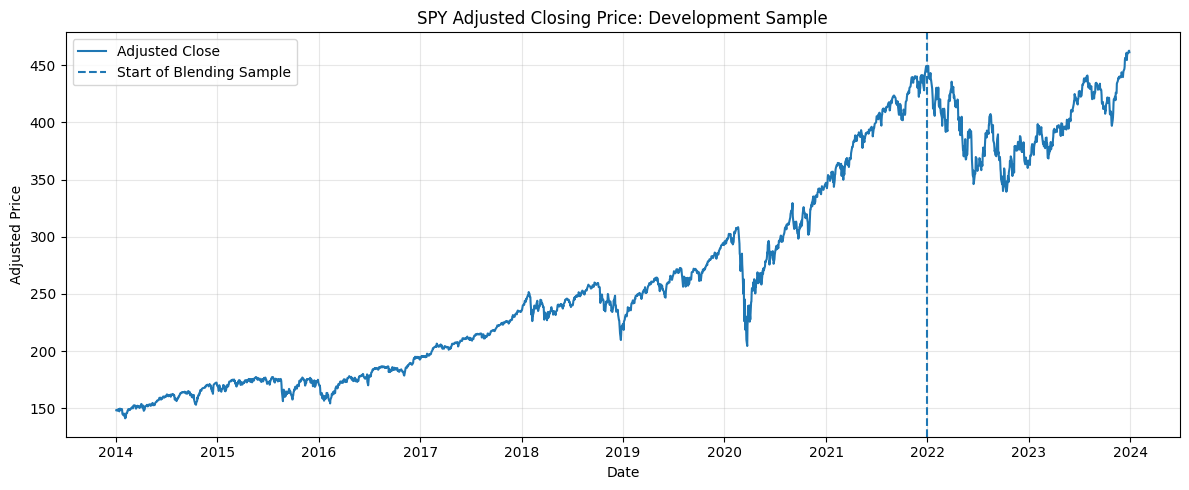

Figure saved to: /content/cqf_final_project/outputs/figures/eda_adjusted_close_development.png


In [21]:
# -------------------------------------------------------------------
# Plot the adjusted SPY price over the development period
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    development_data.index,
    development_data["Close_Adj"],
    label="Adjusted Close",
)

ax.axvline(
    pd.Timestamp(CONFIG["blend_start"]),
    linestyle="--",
    linewidth=1.5,
    label="Start of Blending Sample",
)

ax.set_title(
    "SPY Adjusted Closing Price: Development Sample"
)
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Price")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

price_figure_path = (
    DIRECTORIES["figures"]
    / "eda_adjusted_close_development.png"
)

fig.savefig(
    price_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {price_figure_path}")

## 4.4 Daily Return Dynamics

Daily logarithmic returns fluctuate around a comparatively small unconditional mean, but their dispersion is not expected to remain constant over time. Clusters of large absolute returns may indicate conditional heteroskedasticity and changing market regimes.

This behaviour motivates the construction of rolling volatility, range-based volatility, and regime-related features. It also supports the use of chronological validation rather than randomly shuffled observations.

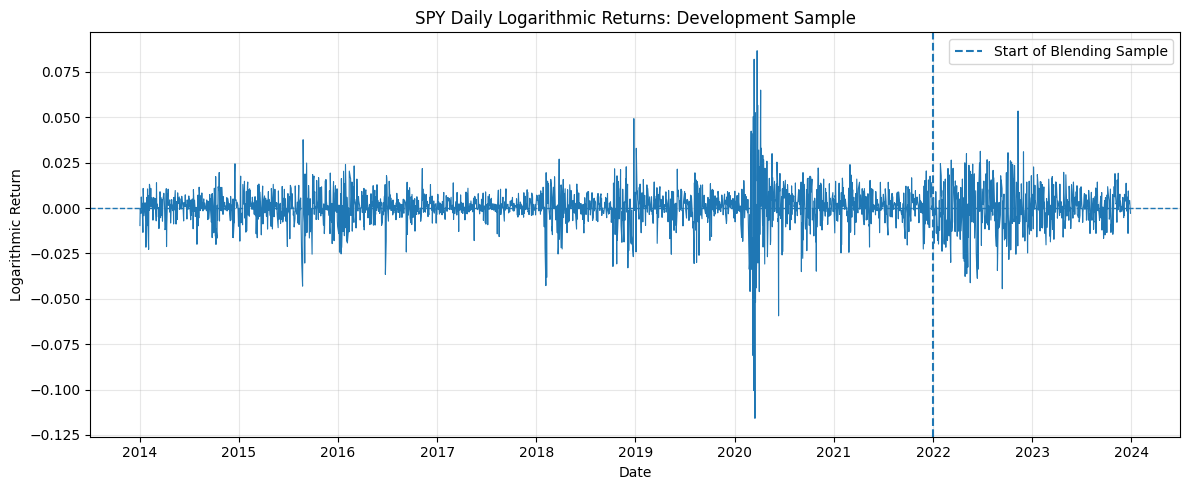

Figure saved to: /content/cqf_final_project/outputs/figures/eda_log_returns_development.png


In [22]:
# -------------------------------------------------------------------
# Plot daily logarithmic returns
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    development_data.index,
    development_data["Log_Return"],
    linewidth=0.8,
)

ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

ax.axvline(
    pd.Timestamp(CONFIG["blend_start"]),
    linestyle="--",
    linewidth=1.5,
    label="Start of Blending Sample",
)

ax.set_title(
    "SPY Daily Logarithmic Returns: Development Sample"
)
ax.set_xlabel("Date")
ax.set_ylabel("Logarithmic Return")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

returns_figure_path = (
    DIRECTORIES["figures"]
    / "eda_log_returns_development.png"
)

fig.savefig(
    returns_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {returns_figure_path}")

## 4.5 Initial EDA Results and Implications

The base-training sample has a positive average daily logarithmic return of approximately 0.054%, corresponding to an annualised arithmetic mean of approximately 13.68%. Its annualised volatility is approximately 17.07%.

The return distribution in the base-training period is strongly negatively skewed and highly leptokurtic. The skewness of approximately -1.04 indicates a relatively heavy left tail, while the excess kurtosis of approximately 19.08 is far above the Gaussian benchmark of zero. The minimum daily logarithmic return is approximately -11.59%, reflecting the extreme market conditions observed during the 2020 COVID-19 shock.

The blending period differs materially from the base-training period. Its average return is substantially lower, while annualised volatility rises to approximately 19.52%. The positive-return frequency falls from approximately 55.83% to 49.70%. These changes indicate that both the return distribution and the unconditional class probability vary through time.

The adjusted price series exhibits a clear long-term trend and several major drawdowns. Raw price levels will therefore not be used directly as conventional stationary predictors. Feature engineering will instead focus on returns, rolling ratios, momentum measures, volatility estimates, trading ranges, and volume transformations.

The return time series also displays volatility clustering: large absolute returns tend to occur in consecutive periods rather than independently. This motivates the inclusion of rolling and range-based volatility features and supports the use of chronological validation.

Extreme observations are retained in the primary dataset because they represent economically meaningful market events. Robust scaling and training-sample-only outlier treatments may later be examined as sensitivity tests, but no observation is removed solely because its return is unusually large.

## 4.6 Return Distribution and Normality Diagnostics

The shape of the return distribution is examined using histograms, a fitted Gaussian density, quantile-quantile diagnostics, and formal normality tests.

The Gaussian density is used only as a descriptive benchmark. Rejection of normality would not directly determine the choice of classifier, but it would demonstrate that the financial data contain tail behaviour and asymmetry that simple distributional assumptions may fail to capture.

Formal tests are expected to be sensitive in samples of this size. Their statistics are therefore interpreted together with skewness, excess kurtosis, extreme quantiles, and graphical evidence rather than as isolated decision rules.

In [23]:
# -------------------------------------------------------------------
# Normality diagnostics for development-stage returns
# -------------------------------------------------------------------

def calculate_normality_diagnostics(
    data: pd.DataFrame,
) -> pd.Series:
    """Calculate graphical-support and formal normality statistics."""

    returns = (
        data["Log_Return"]
        .dropna()
        .astype(float)
    )

    if len(returns) < 20:
        raise ValueError(
            "At least 20 observations are required "
            "for normality diagnostics."
        )

    jarque_bera_result = stats.jarque_bera(returns)
    dagostino_result = stats.normaltest(returns)

    return pd.Series(
        {
            "Observations": len(returns),
            "Skewness": stats.skew(
                returns,
                bias=False,
            ),
            "Excess Kurtosis": stats.kurtosis(
                returns,
                fisher=True,
                bias=False,
            ),
            "Jarque-Bera Statistic":
                jarque_bera_result.statistic,
            "Jarque-Bera p-value":
                jarque_bera_result.pvalue,
            "D'Agostino Statistic":
                dagostino_result.statistic,
            "D'Agostino p-value":
                dagostino_result.pvalue,
            "0.5% Quantile":
                returns.quantile(0.005),
            "1% Quantile":
                returns.quantile(0.01),
            "99% Quantile":
                returns.quantile(0.99),
            "99.5% Quantile":
                returns.quantile(0.995),
        }
    )


normality_diagnostics = pd.DataFrame(
    {
        "Base Training":
            calculate_normality_diagnostics(
                base_train_data
            ),
        "Blending":
            calculate_normality_diagnostics(
                blend_data
            ),
        "Combined Development":
            calculate_normality_diagnostics(
                development_data
            ),
    }
).T

display(normality_diagnostics)

,Observations,Skewness,Excess Kurtosis,Jarque-Bera Statistic,Jarque-Bera p-value,D'Agostino Statistic,D'Agostino p-value,0.5% Quantile,1% Quantile,99% Quantile,99.5% Quantile
Base Training,"2,015.000000",-1.035070,19.077135,"30,753.961018",0.000000,749.778748,0.000000,-0.042408,-0.030770,0.024433,0.033012
Blending,501.000000,-0.130664,1.278007,34.208579,0.000000,16.744844,0.000231,-0.038182,-0.034435,0.026660,0.030765
Combined Development,"2,516.000000",-0.799553,13.957093,"20,601.330690",0.000000,745.835859,0.000000,-0.039744,-0.032486,0.026018,0.032379


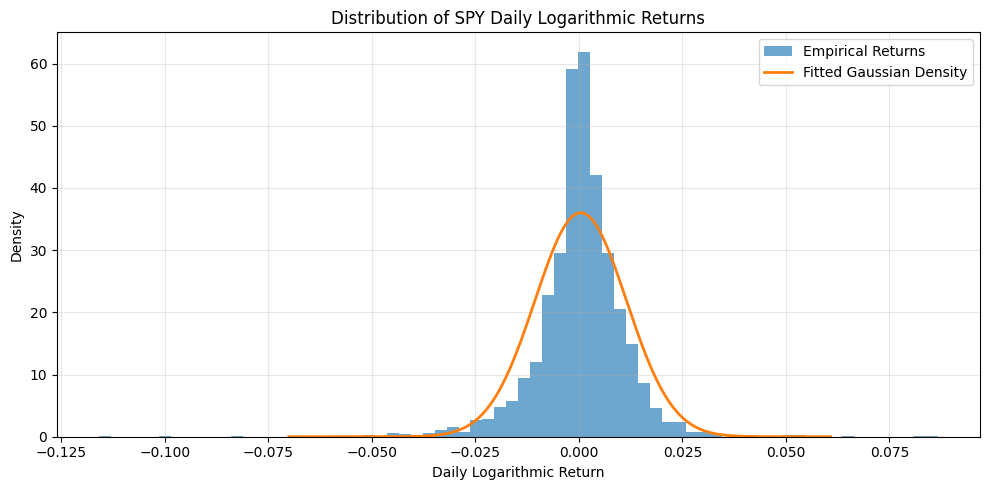

Figure saved to: /content/cqf_final_project/outputs/figures/eda_return_distribution.png


In [24]:
# -------------------------------------------------------------------
# Plot the development-sample return distribution
# -------------------------------------------------------------------

development_returns = (
    development_data["Log_Return"]
    .dropna()
    .astype(float)
)

return_mean = development_returns.mean()
return_std = development_returns.std(ddof=1)

density_grid = np.linspace(
    development_returns.quantile(0.001),
    development_returns.quantile(0.999),
    500,
)

normal_density = stats.norm.pdf(
    density_grid,
    loc=return_mean,
    scale=return_std,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    development_returns,
    bins=70,
    density=True,
    alpha=0.65,
    label="Empirical Returns",
)

ax.plot(
    density_grid,
    normal_density,
    linewidth=2,
    label="Fitted Gaussian Density",
)

ax.set_title(
    "Distribution of SPY Daily Logarithmic Returns"
)
ax.set_xlabel("Daily Logarithmic Return")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

return_distribution_path = (
    DIRECTORIES["figures"]
    / "eda_return_distribution.png"
)

fig.savefig(
    return_distribution_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {return_distribution_path}")

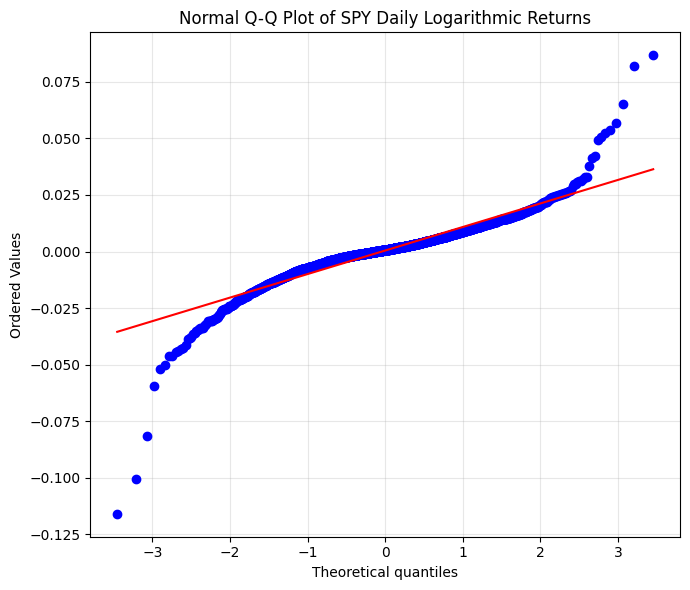

Figure saved to: /content/cqf_final_project/outputs/figures/eda_return_normal_qq_plot.png


In [25]:
# -------------------------------------------------------------------
# Normal quantile-quantile diagnostic
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

stats.probplot(
    development_returns,
    dist="norm",
    plot=ax,
)

ax.set_title(
    "Normal Q-Q Plot of SPY Daily Logarithmic Returns"
)
ax.grid(alpha=0.3)

fig.tight_layout()

qq_figure_path = (
    DIRECTORIES["figures"]
    / "eda_return_normal_qq_plot.png"
)

fig.savefig(
    qq_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {qq_figure_path}")

## 4.7 Volatility Clustering and Serial Dependence

Financial returns often exhibit limited linear autocorrelation but substantial dependence in their magnitude. This means that the direction of the next return may be difficult to predict directly, while volatility and market regimes may remain persistent.

Rolling annualised volatility is examined over 21-day and 63-day windows. The shorter window reacts more quickly to changing market conditions, while the longer window provides a smoother medium-term estimate.

Autocorrelations are calculated for both raw returns and squared returns. Persistent autocorrelation in squared returns provides evidence of volatility clustering and supports the use of lagged volatility and range-based features.

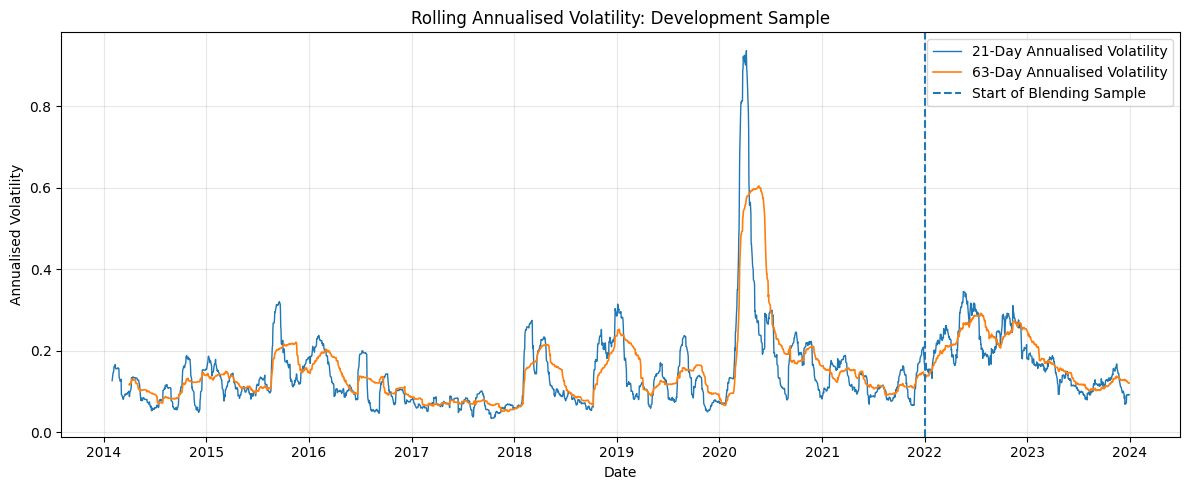

Figure saved to: /content/cqf_final_project/outputs/figures/eda_rolling_volatility.png


In [26]:
# -------------------------------------------------------------------
# Calculate rolling annualised volatility
# -------------------------------------------------------------------

development_data["Volatility_21D"] = (
    development_data["Log_Return"]
    .rolling(window=21, min_periods=21)
    .std(ddof=1)
    * np.sqrt(CONFIG["annualisation_factor"])
)

development_data["Volatility_63D"] = (
    development_data["Log_Return"]
    .rolling(window=63, min_periods=63)
    .std(ddof=1)
    * np.sqrt(CONFIG["annualisation_factor"])
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    development_data.index,
    development_data["Volatility_21D"],
    linewidth=1.0,
    label="21-Day Annualised Volatility",
)

ax.plot(
    development_data.index,
    development_data["Volatility_63D"],
    linewidth=1.2,
    label="63-Day Annualised Volatility",
)

ax.axvline(
    pd.Timestamp(CONFIG["blend_start"]),
    linestyle="--",
    linewidth=1.5,
    label="Start of Blending Sample",
)

ax.set_title(
    "Rolling Annualised Volatility: Development Sample"
)
ax.set_xlabel("Date")
ax.set_ylabel("Annualised Volatility")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

rolling_volatility_path = (
    DIRECTORIES["figures"]
    / "eda_rolling_volatility.png"
)

fig.savefig(
    rolling_volatility_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {rolling_volatility_path}")

In [27]:
# -------------------------------------------------------------------
# Calculate autocorrelation of returns and squared returns
# -------------------------------------------------------------------

maximum_lag = 20
autocorrelation_lags = range(1, maximum_lag + 1)

return_series = (
    development_data["Log_Return"]
    .dropna()
    .astype(float)
)

squared_return_series = return_series.pow(2)

autocorrelation_table = pd.DataFrame(
    {
        "Lag": list(autocorrelation_lags),
        "Return Autocorrelation": [
            return_series.autocorr(lag=lag)
            for lag in autocorrelation_lags
        ],
        "Squared-Return Autocorrelation": [
            squared_return_series.autocorr(lag=lag)
            for lag in autocorrelation_lags
        ],
    }
).set_index("Lag")

display(autocorrelation_table)

,Return Autocorrelation,Squared-Return Autocorrelation
Lag,,
1,-0.119369,0.462006
2,0.071205,0.547147
3,-0.008495,0.365950
4,-0.060192,0.347873
5,0.045351,0.326168
6,-0.108411,0.378611
7,0.141110,0.282396
8,-0.119856,0.332259
9,0.125227,0.255625


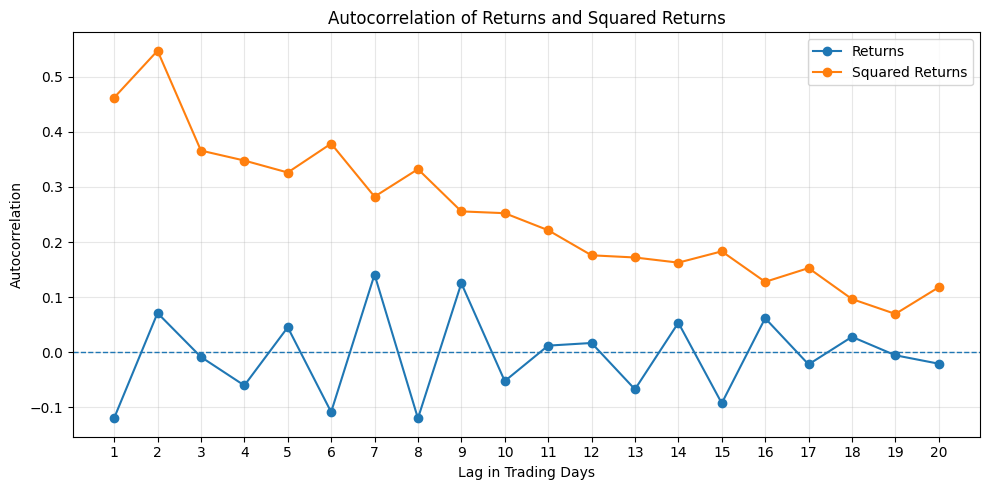

Figure saved to: /content/cqf_final_project/outputs/figures/eda_return_autocorrelations.png


In [28]:
# -------------------------------------------------------------------
# Plot return and squared-return autocorrelations
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    autocorrelation_table.index,
    autocorrelation_table[
        "Return Autocorrelation"
    ],
    marker="o",
    label="Returns",
)

ax.plot(
    autocorrelation_table.index,
    autocorrelation_table[
        "Squared-Return Autocorrelation"
    ],
    marker="o",
    label="Squared Returns",
)

ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

ax.set_title(
    "Autocorrelation of Returns and Squared Returns"
)
ax.set_xlabel("Lag in Trading Days")
ax.set_ylabel("Autocorrelation")
ax.set_xticks(list(autocorrelation_lags))
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

autocorrelation_figure_path = (
    DIRECTORIES["figures"]
    / "eda_return_autocorrelations.png"
)

fig.savefig(
    autocorrelation_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{autocorrelation_figure_path}"
)

## 4.8 Distributional Stability Across Development Periods

The base-training and blending samples are compared to assess whether their return distributions remain stable.

Welch's test is used to compare means without imposing equal variances. The Brown-Forsythe version of Levene's test compares dispersion using deviations from the median and is less sensitive to heavy-tailed observations than a conventional variance test based on the mean.

The two-sample Kolmogorov-Smirnov test compares the full empirical distributions. The Wasserstein distance provides an additional scale-sensitive measure of distributional separation.

Statistical significance is interpreted together with economic effect sizes because large samples may produce small p-values for differences that are economically modest.

In [29]:
# -------------------------------------------------------------------
# Compare base-training and blending return distributions
# -------------------------------------------------------------------

base_returns = (
    base_train_data["Log_Return"]
    .dropna()
    .astype(float)
)

blend_returns = (
    blend_data["Log_Return"]
    .dropna()
    .astype(float)
)

welch_result = stats.ttest_ind(
    base_returns,
    blend_returns,
    equal_var=False,
)

brown_forsythe_result = stats.levene(
    base_returns,
    blend_returns,
    center="median",
)

ks_result = stats.ks_2samp(
    base_returns,
    blend_returns,
    alternative="two-sided",
    mode="auto",
)

wasserstein_distance = stats.wasserstein_distance(
    base_returns,
    blend_returns,
)

pooled_standard_deviation = np.sqrt(
    (
        (len(base_returns) - 1)
        * base_returns.var(ddof=1)
        + (len(blend_returns) - 1)
        * blend_returns.var(ddof=1)
    )
    / (
        len(base_returns)
        + len(blend_returns)
        - 2
    )
)

cohens_d = (
    blend_returns.mean()
    - base_returns.mean()
) / pooled_standard_deviation

distribution_shift_summary = pd.Series(
    {
        "Base Mean": base_returns.mean(),
        "Blending Mean": blend_returns.mean(),
        "Mean Difference":
            blend_returns.mean()
            - base_returns.mean(),
        "Cohen's d": cohens_d,
        "Base Daily Volatility":
            base_returns.std(ddof=1),
        "Blending Daily Volatility":
            blend_returns.std(ddof=1),
        "Volatility Ratio":
            blend_returns.std(ddof=1)
            / base_returns.std(ddof=1),
        "Welch Statistic":
            welch_result.statistic,
        "Welch p-value":
            welch_result.pvalue,
        "Brown-Forsythe Statistic":
            brown_forsythe_result.statistic,
        "Brown-Forsythe p-value":
            brown_forsythe_result.pvalue,
        "Kolmogorov-Smirnov Statistic":
            ks_result.statistic,
        "Kolmogorov-Smirnov p-value":
            ks_result.pvalue,
        "Wasserstein Distance":
            wasserstein_distance,
    },
    name="Development-Sample Distribution Shift",
)

display(distribution_shift_summary)

,Development-Sample Distribution Shift
Base Mean,0.000543
Blending Mean,0.000064
Mean Difference,-0.000479
Cohen's d,-0.043266
Base Daily Volatility,0.010754
Blending Daily Volatility,0.012298
Volatility Ratio,1.143643
Welch Statistic,0.799630
Welch p-value,0.424196
Brown-Forsythe Statistic,37.387585


## 4.9 Annual Return, Volatility, and Class-Balance Variation

Annual statistics are calculated within the development sample to examine the stability of returns, volatility, and the positive-class frequency.

Substantial year-to-year variation would indicate that the classification base rate and the scale of market movements are regime dependent. This would favour rolling or expanding validation, probability calibration, and ensemble models that combine different predictive structures.

In [30]:
# -------------------------------------------------------------------
# Calculate annual development-sample statistics
# -------------------------------------------------------------------

annual_regime_summary = (
    development_data
    .assign(Year=development_data.index.year)
    .groupby("Year")
    .agg(
        Observations=("Log_Return", "size"),
        Mean_Daily_Return=("Log_Return", "mean"),
        Daily_Volatility=("Log_Return", "std"),
        Positive_Class_Rate=("Target", "mean"),
    )
)

annual_regime_summary["Annualised_Return"] = (
    annual_regime_summary["Mean_Daily_Return"]
    * CONFIG["annualisation_factor"]
)

annual_regime_summary["Annualised_Volatility"] = (
    annual_regime_summary["Daily_Volatility"]
    * np.sqrt(CONFIG["annualisation_factor"])
)

annual_regime_summary = annual_regime_summary[
    [
        "Observations",
        "Annualised_Return",
        "Annualised_Volatility",
        "Positive_Class_Rate",
    ]
]

display(annual_regime_summary)

,Observations,Annualised_Return,Annualised_Volatility,Positive_Class_Rate
Year,,,,
2014,252,0.126314,0.112569,0.591270
2015,252,0.012267,0.154508,0.480159
2016,252,0.113310,0.130781,0.547619
2017,251,0.197216,0.067447,0.569721
2018,251,-0.046953,0.170807,0.529880
2019,252,0.271734,0.125289,0.595238
2020,253,0.167656,0.336478,0.573123
2021,252,0.252537,0.129940,0.583333
2022,251,-0.201391,0.242592,0.430279


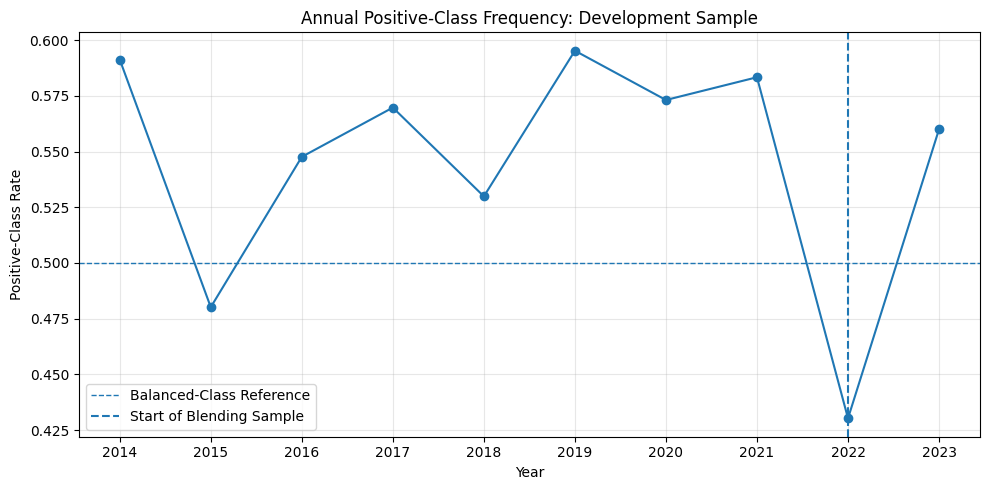

Figure saved to: /content/cqf_final_project/outputs/figures/eda_annual_positive_class_rate.png


In [31]:
# -------------------------------------------------------------------
# Plot annual positive-class frequency
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    annual_regime_summary.index,
    annual_regime_summary["Positive_Class_Rate"],
    marker="o",
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.0,
    label="Balanced-Class Reference",
)

ax.axvline(
    2022,
    linestyle="--",
    linewidth=1.5,
    label="Start of Blending Sample",
)

ax.set_title(
    "Annual Positive-Class Frequency: Development Sample"
)
ax.set_xlabel("Year")
ax.set_ylabel("Positive-Class Rate")
ax.set_xticks(annual_regime_summary.index)
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

annual_class_figure_path = (
    DIRECTORIES["figures"]
    / "eda_annual_positive_class_rate.png"
)

fig.savefig(
    annual_class_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {annual_class_figure_path}")

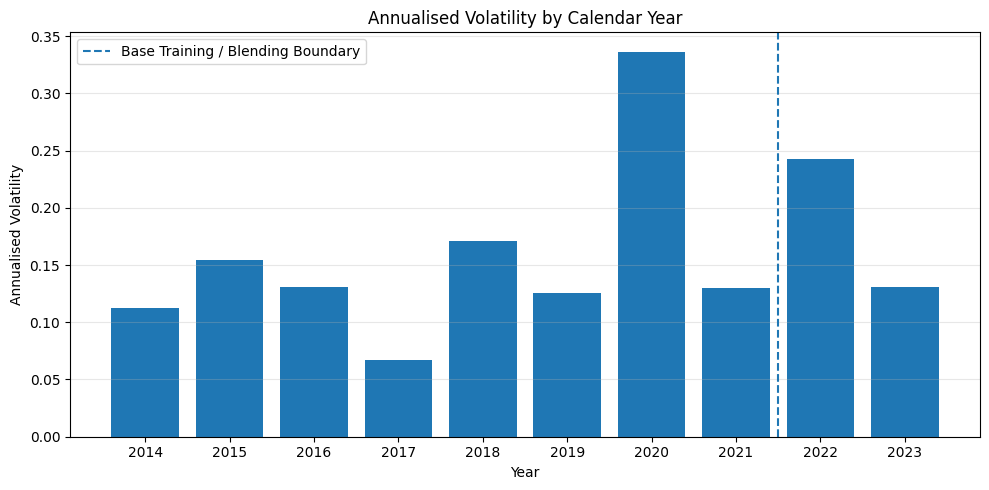

Figure saved to: /content/cqf_final_project/outputs/figures/eda_annualised_volatility.png


In [32]:
# -------------------------------------------------------------------
# Plot annualised volatility by calendar year
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    annual_regime_summary.index,
    annual_regime_summary["Annualised_Volatility"],
)

ax.axvline(
    2021.5,
    linestyle="--",
    linewidth=1.5,
    label="Base Training / Blending Boundary",
)

ax.set_title(
    "Annualised Volatility by Calendar Year"
)
ax.set_xlabel("Year")
ax.set_ylabel("Annualised Volatility")
ax.set_xticks(annual_regime_summary.index)
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

annual_volatility_figure_path = (
    DIRECTORIES["figures"]
    / "eda_annualised_volatility.png"
)

fig.savefig(
    annual_volatility_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{annual_volatility_figure_path}"
)

In [33]:
# -------------------------------------------------------------------
# Save extended EDA results
# -------------------------------------------------------------------

normality_diagnostics.to_csv(
    DIRECTORIES["tables"]
    / "eda_normality_diagnostics.csv"
)

autocorrelation_table.to_csv(
    DIRECTORIES["tables"]
    / "eda_return_autocorrelations.csv"
)

distribution_shift_summary.to_csv(
    DIRECTORIES["tables"]
    / "eda_distribution_shift_summary.csv",
    header=True,
)

annual_regime_summary.to_csv(
    DIRECTORIES["tables"]
    / "eda_annual_regime_summary.csv"
)

print("Extended EDA tables saved successfully.")

Extended EDA tables saved successfully.


## 4.10 Extended EDA Results

The development-sample return distribution is strongly non-Gaussian. In the base-training sample, skewness is approximately -1.04 and excess kurtosis is approximately 19.08. The combined development sample retains substantial negative skewness and excess kurtosis of approximately 13.96.

Both the Jarque-Bera and D'Agostino tests reject normality at conventional significance levels. The histogram exhibits a higher central peak and heavier tails than the fitted Gaussian density, while the normal Q-Q plot shows pronounced deviations in both tails. The deviation is particularly severe in the left tail, indicating that extreme negative returns occur more frequently than predicted by a normal distribution.

Raw daily returns exhibit alternating positive and negative autocorrelations. Although the individual coefficients are generally moderate, the pattern suggests that short-term reversal and continuation effects may vary by lag.

The dependence in squared returns is considerably stronger. The first two squared-return autocorrelations are approximately 0.46 and 0.55, and positive dependence remains visible through the twentieth lag. This provides strong descriptive evidence of volatility clustering.

The mean return does not differ significantly between the base-training and blending samples. Welch's test produces a p-value of approximately 0.42, while the standardised mean difference is economically small, with Cohen's d of approximately -0.04.

However, the blending-period daily volatility is approximately 14.36% higher than the base-training-period volatility. The Brown-Forsythe test rejects equality of dispersion, and the Kolmogorov-Smirnov test rejects equality of the full return distributions. The modelling framework must therefore accommodate changes in volatility, tail behaviour, and unconditional class probabilities even when the difference in average returns is limited.

Annual results reinforce the presence of regime variation. The highest annualised volatility occurs in 2020, while 2017 represents an unusually low-volatility year. The blending sample includes a negative-return, high-volatility regime in 2022 followed by a positive-return, lower-volatility regime in 2023.

These findings support the use of rolling volatility, range-based estimators, momentum and reversal features, chronological validation, robust preprocessing, and heterogeneous classifiers. They also indicate that final model evaluation should include stability and regime-based analysis rather than relying only on full-sample averages.

## 4.11 Volume Dynamics and Return-Volume Relationships

Trading volume may contain information about market participation, liquidity, disagreement, and the intensity of price movements. However, the raw volume level is non-stationary and may reflect long-run growth in market activity.

The analysis therefore focuses on transformed volume measures, including logarithmic volume changes, volume relative to its rolling mean, and rolling volume z-scores.

The relationship between volume and returns is assessed using Spearman rank correlation because both return and volume variables are non-Gaussian and contain extreme observations. Particular attention is given to the association between abnormal volume and absolute return magnitude rather than only the direction of returns.

All rolling volume transformations are calculated using current and historical observations only.

In [34]:
# -------------------------------------------------------------------
# Construct volume-related variables for exploratory analysis
# -------------------------------------------------------------------

volume_eda_source = model_base[
    [
        "Log_Return",
        "Volume",
    ]
].copy()

volume_eda_source["Absolute_Return"] = (
    volume_eda_source["Log_Return"].abs()
)

volume_eda_source["Log_Volume"] = np.log(
    volume_eda_source["Volume"].replace(0, np.nan)
)

volume_eda_source["Log_Volume_Change"] = (
    volume_eda_source["Log_Volume"].diff()
)

volume_rolling_mean_20 = (
    volume_eda_source["Volume"]
    .rolling(window=20, min_periods=20)
    .mean()
)

volume_eda_source["Volume_Ratio_20"] = (
    volume_eda_source["Volume"]
    / volume_rolling_mean_20
    - 1
)

log_volume_mean_20 = (
    volume_eda_source["Log_Volume"]
    .rolling(window=20, min_periods=20)
    .mean()
)

log_volume_std_20 = (
    volume_eda_source["Log_Volume"]
    .rolling(window=20, min_periods=20)
    .std(ddof=1)
)

volume_eda_source["Volume_Z_20"] = (
    (
        volume_eda_source["Log_Volume"]
        - log_volume_mean_20
    )
    / log_volume_std_20
)

# Join the pre-defined sample labels and exclude the final test period.
volume_eda_data = volume_eda_source.join(
    model_data[["Sample"]],
    how="inner",
)

development_volume_data = volume_eda_data.loc[
    volume_eda_data["Sample"].isin(
        ["Base Training", "Blending"]
    )
].copy()

display(
    development_volume_data[
        [
            "Log_Return",
            "Absolute_Return",
            "Log_Volume_Change",
            "Volume_Ratio_20",
            "Volume_Z_20",
            "Sample",
        ]
    ].head()
)

,Log_Return,Absolute_Return,Log_Volume_Change,Volume_Ratio_20,Volume_Z_20,Sample
Date,,,,,,
2014-01-02,-0.009630,0.009630,0.328721,0.120131,0.475956,Base Training
2014-01-03,-0.000164,0.000164,-0.385202,-0.222809,-0.423177,Base Training
2014-01-06,-0.002902,0.002902,0.283133,0.031012,0.275033,Base Training
2014-01-07,0.006123,0.006123,-0.226370,-0.161202,-0.238224,Base Training
2014-01-08,0.000218,0.000218,0.114373,-0.071525,0.007727,Base Training


In [35]:
# -------------------------------------------------------------------
# Calculate robust return-volume dependence statistics
# -------------------------------------------------------------------

def calculate_spearman_relationship(
    data: pd.DataFrame,
    x_column: str,
    y_column: str,
) -> tuple[float, float, int]:
    """Return Spearman correlation, p-value, and valid sample size."""

    valid_data = data[
        [x_column, y_column]
    ].replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna()

    if len(valid_data) < 20:
        raise ValueError(
            "Insufficient valid observations for "
            f"{x_column} and {y_column}."
        )

    result = stats.spearmanr(
        valid_data[x_column],
        valid_data[y_column],
    )

    return (
        float(result.statistic),
        float(result.pvalue),
        int(len(valid_data)),
    )


def calculate_volume_relationships(
    data: pd.DataFrame,
) -> pd.Series:
    """Summarise return-volume relationships for one sample."""

    abs_return_volume_ratio = (
        calculate_spearman_relationship(
            data,
            "Absolute_Return",
            "Volume_Ratio_20",
        )
    )

    abs_return_volume_change = (
        calculate_spearman_relationship(
            data.assign(
                Absolute_Log_Volume_Change=
                    data["Log_Volume_Change"].abs()
            ),
            "Absolute_Return",
            "Absolute_Log_Volume_Change",
        )
    )

    signed_return_volume_change = (
        calculate_spearman_relationship(
            data,
            "Log_Return",
            "Log_Volume_Change",
        )
    )

    return pd.Series(
        {
            "Observations":
                abs_return_volume_ratio[2],
            "Abs Return vs Volume Ratio":
                abs_return_volume_ratio[0],
            "Abs Return vs Volume Ratio p-value":
                abs_return_volume_ratio[1],
            "Abs Return vs Abs Volume Change":
                abs_return_volume_change[0],
            "Abs Return vs Abs Volume Change p-value":
                abs_return_volume_change[1],
            "Return vs Volume Change":
                signed_return_volume_change[0],
            "Return vs Volume Change p-value":
                signed_return_volume_change[1],
        }
    )


volume_relationship_summary = pd.DataFrame(
    {
        "Base Training":
            calculate_volume_relationships(
                development_volume_data.loc[
                    development_volume_data["Sample"]
                    == "Base Training"
                ]
            ),
        "Blending":
            calculate_volume_relationships(
                development_volume_data.loc[
                    development_volume_data["Sample"]
                    == "Blending"
                ]
            ),
        "Combined Development":
            calculate_volume_relationships(
                development_volume_data
            ),
    }
).T

display(volume_relationship_summary)

,Observations,Abs Return vs Volume Ratio,Abs Return vs Volume Ratio p-value,Abs Return vs Abs Volume Change,Abs Return vs Abs Volume Change p-value,Return vs Volume Change,Return vs Volume Change p-value
Base Training,"2,015.000000",0.337647,0.000000,0.120865,0.000000,-0.291772,0.000000
Blending,501.000000,0.328440,0.000000,0.047224,0.291446,-0.205486,0.000004
Combined Development,"2,516.000000",0.341152,0.000000,0.089646,0.000007,-0.270771,0.000000


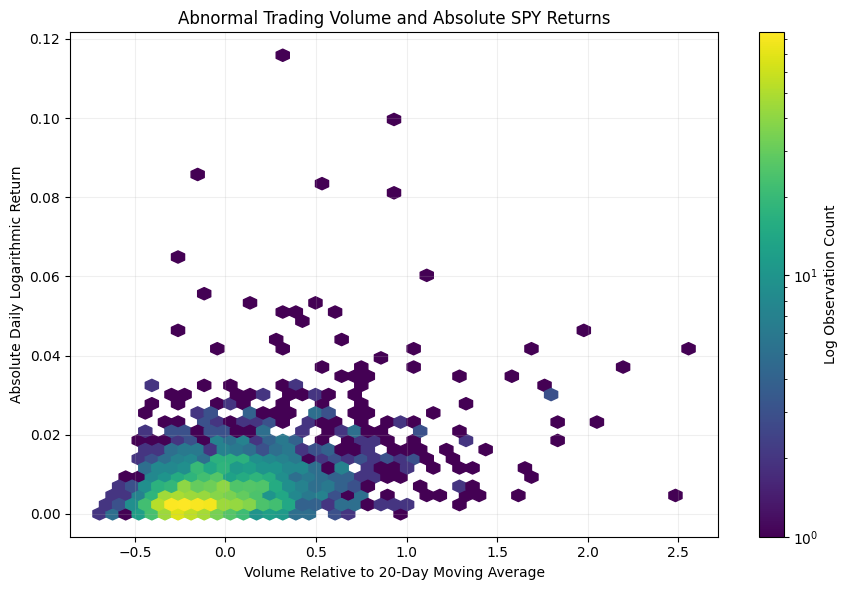

Figure saved to: /content/cqf_final_project/outputs/figures/eda_volume_return_relationship.png


In [36]:
# -------------------------------------------------------------------
# Plot abnormal volume against absolute return magnitude
# -------------------------------------------------------------------

volume_scatter_data = (
    development_volume_data[
        [
            "Volume_Ratio_20",
            "Absolute_Return",
        ]
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

fig, ax = plt.subplots(figsize=(9, 6))

hexbin = ax.hexbin(
    volume_scatter_data["Volume_Ratio_20"],
    volume_scatter_data["Absolute_Return"],
    gridsize=45,
    mincnt=1,
    bins="log",
)

fig.colorbar(
    hexbin,
    ax=ax,
    label="Log Observation Count",
)

ax.set_title(
    "Abnormal Trading Volume and Absolute SPY Returns"
)
ax.set_xlabel(
    "Volume Relative to 20-Day Moving Average"
)
ax.set_ylabel(
    "Absolute Daily Logarithmic Return"
)
ax.grid(alpha=0.2)

fig.tight_layout()

volume_return_figure_path = (
    DIRECTORIES["figures"]
    / "eda_volume_return_relationship.png"
)

fig.savefig(
    volume_return_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{volume_return_figure_path}"
)

In [37]:
# -------------------------------------------------------------------
# Define volume regimes using base-training quantile boundaries
# -------------------------------------------------------------------

base_volume_ratio = (
    development_volume_data.loc[
        development_volume_data["Sample"]
        == "Base Training",
        "Volume_Ratio_20",
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

volume_quantile_boundaries = (
    base_volume_ratio
    .quantile([0.20, 0.40, 0.60, 0.80])
    .to_numpy()
)

volume_bins = np.concatenate(
    (
        [-np.inf],
        volume_quantile_boundaries,
        [np.inf],
    )
)

volume_labels = [
    "Q1: Lowest",
    "Q2",
    "Q3",
    "Q4",
    "Q5: Highest",
]

development_volume_data["Volume_Regime"] = pd.cut(
    development_volume_data["Volume_Ratio_20"],
    bins=volume_bins,
    labels=volume_labels,
    include_lowest=True,
)

volume_regime_summary = (
    development_volume_data
    .dropna(
        subset=[
            "Volume_Regime",
            "Absolute_Return",
            "Log_Return",
        ]
    )
    .groupby(
        "Volume_Regime",
        observed=True,
    )
    .agg(
        Observations=("Log_Return", "size"),
        Mean_Absolute_Return=(
            "Absolute_Return",
            "mean",
        ),
        Daily_Volatility=(
            "Log_Return",
            "std",
        ),
        Positive_Return_Rate=(
            "Log_Return",
            lambda values: (values > 0).mean(),
        ),
    )
)

display(volume_regime_summary)

,Observations,Mean_Absolute_Return,Daily_Volatility,Positive_Return_Rate
Volume_Regime,,,,
Q1: Lowest,462,0.004658,0.006621,0.670996
Q2,497,0.005142,0.008262,0.605634
Q3,532,0.006126,0.008431,0.578947
Q4,535,0.007620,0.009995,0.553271
Q5: Highest,490,0.012579,0.017200,0.324490


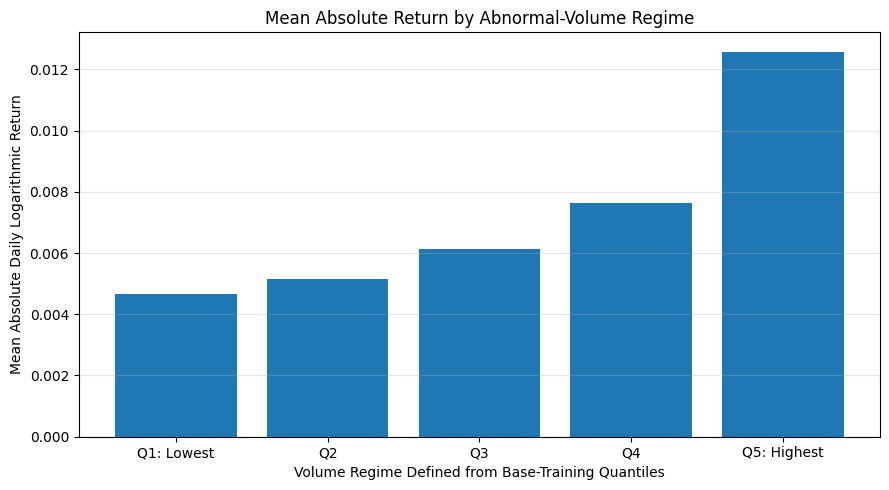

Figure saved to: /content/cqf_final_project/outputs/figures/eda_volume_regime_absolute_returns.png


In [38]:
# -------------------------------------------------------------------
# Plot return magnitude across volume regimes
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    volume_regime_summary.index.astype(str),
    volume_regime_summary[
        "Mean_Absolute_Return"
    ],
)

ax.set_title(
    "Mean Absolute Return by Abnormal-Volume Regime"
)
ax.set_xlabel(
    "Volume Regime Defined from Base-Training Quantiles"
)
ax.set_ylabel(
    "Mean Absolute Daily Logarithmic Return"
)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

volume_regime_figure_path = (
    DIRECTORIES["figures"]
    / "eda_volume_regime_absolute_returns.png"
)

fig.savefig(
    volume_regime_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{volume_regime_figure_path}"
)

## 4.12 Volume-Analysis Results

Abnormal trading volume has a stable positive association with the magnitude of daily SPY returns. The Spearman correlation between absolute returns and volume relative to its 20-day moving average is approximately 0.34 in the base-training sample and 0.33 in the blending sample.

The relationship between absolute returns and absolute changes in logarithmic volume is weaker. It is statistically significant in the base-training period but becomes small and statistically insignificant in the blending period. Relative volume therefore appears more stable than the one-day change in volume.

Signed returns are negatively associated with logarithmic volume changes. The correlation is approximately -0.29 in the base-training sample and -0.21 in the blending sample. This suggests that sharp increases in market activity are more frequently associated with negative price movements than with positive movements.

The volume-regime analysis reinforces this asymmetry. Mean absolute returns increase monotonically from approximately 0.47% in the lowest-volume regime to approximately 1.26% in the highest-volume regime. Daily volatility similarly rises from approximately 0.66% to 1.72%.

At the same time, the positive-return frequency declines from approximately 67.10% in the lowest-volume regime to approximately 32.45% in the highest-volume regime. Unusually high volume is therefore associated not only with larger price movements but also with a greater probability of negative contemporaneous returns.

These relationships do not establish next-day predictability by themselves. Nevertheless, they support the inclusion of relative-volume, volume z-score, volume-change, price-volume interaction, and liquidity-related variables in the initial feature set. Their predictive value will be assessed through chronological validation rather than contemporaneous correlation alone.

## 4.13 EDA Conclusions for Model Design

The exploratory analysis produces several direct implications for the modelling framework.

First, raw price levels are strongly trending and will not be treated as conventional stationary predictors. Features will instead be constructed from price ratios, returns, moving-average distances, rolling statistics, and other scale-independent transformations.

Second, daily returns are non-Gaussian, negatively skewed, and heavy-tailed. Robust preprocessing will therefore be considered for models that are sensitive to feature scale and extreme observations. However, genuine market-stress observations will not be removed mechanically.

Third, squared returns exhibit persistent serial dependence, while rolling volatility changes materially across time. The feature set will include multiple volatility horizons, range-based estimators, downside variation, and volatility-regime ratios.

Fourth, the unconditional positive-class frequency changes substantially across calendar years and between the base-training and blending periods. Balanced accuracy, class-specific metrics, probability calibration, and threshold stability are therefore more informative than raw accuracy alone.

Fifth, the return distributions of the base-training and blending periods differ even though their mean-return difference is small. Hyperparameters and preprocessing transformations will be selected using chronological validation, and final results will be examined across market regimes.

Finally, transformed volume measures will be retained as candidate features when they demonstrate a stable association with return magnitude or direction. Raw trading volume will not be used without normalisation because its long-run level is non-stationary.

These findings motivate an initial feature set containing return, intraday, trend, momentum, volatility, range, volume, and regime-related variables. Feature screening will subsequently be performed using the base-training sample only.

In [39]:
# -------------------------------------------------------------------
# Save volume-related EDA outputs
# -------------------------------------------------------------------

volume_relationship_summary.to_csv(
    DIRECTORIES["tables"]
    / "eda_volume_relationship_summary.csv"
)

volume_regime_summary.to_csv(
    DIRECTORIES["tables"]
    / "eda_volume_regime_summary.csv"
)

print("Volume-related EDA results saved successfully.")

Volume-related EDA results saved successfully.


# 5 Feature Engineering and Transformation


## 5.1 Feature-Engineering Principles

The initial feature set is constructed exclusively from historical SPY price and volume information. External market-context variables will be introduced later as an extension so that their incremental contribution can be evaluated explicitly.

Each feature attached to trading day $t$ uses only information available on or before day $t$. No feature contains a negative shift, a forward return, or a transformation fitted using future observations.

The raw price level is excluded from the modelling feature matrix because it is strongly trending and scale dependent. Price information is instead represented through logarithmic returns, ratios, moving-average distances, momentum indicators, range measures, and rolling statistics.

The feature set is organised into the following economic families:

| Feature family | Economic information |
|---|---|
| Return and reversal | Recent return continuation and mean reversion |
| Intraday structure | Overnight gaps, intraday moves, ranges, and candle structure |
| Trend | Moving-average distances, crossovers, and price slopes |
| Momentum | RSI, stochastic indicators, Williams %R, and CCI |
| Volatility | Rolling, downside, range-based, and relative volatility |
| Volume and liquidity | Relative volume, abnormal volume, OBV, and price-volume interactions |
| Calendar | Potential day-of-week and seasonal effects |

A broad candidate set is created first and subsequently reduced using the base-training sample only. Missing-value treatment, scaling, correlation filtering, feature selection, and model-specific transformations are not fitted on the blending or final-test samples.

In [40]:
# -------------------------------------------------------------------
# Helper functions for leakage-controlled feature engineering
# -------------------------------------------------------------------

def safe_divide(
    numerator: pd.Series,
    denominator: pd.Series,
) -> pd.Series:
    """Divide two aligned series while treating zero denominators as missing."""

    clean_denominator = denominator.replace(0, np.nan)
    return numerator / clean_denominator


def rolling_log_price_slope(
    price: pd.Series,
    window: int,
) -> pd.Series:
    """Estimate a rolling linear slope of the logarithmic price."""

    x_values = np.arange(window, dtype=float)
    x_centred = x_values - x_values.mean()
    denominator = np.sum(x_centred ** 2)

    log_price = np.log(price)

    return log_price.rolling(
        window=window,
        min_periods=window,
    ).apply(
        lambda values: (
            np.dot(
                x_centred,
                values - values.mean(),
            )
            / denominator
        ),
        raw=True,
    )


def build_spy_features(
    price_data: pd.DataFrame,
    annualisation_factor: int = 252,
) -> tuple[pd.DataFrame, dict[str, list[str]]]:
    """
    Construct backward-looking SPY features.

    Every output value at date t depends only on observations dated t or earlier.
    """

    required_columns = [
        "Open_Adj",
        "High_Adj",
        "Low_Adj",
        "Close_Adj",
        "Volume",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in price_data.columns
    ]

    if missing_columns:
        raise ValueError(
            "Required adjusted market fields are missing: "
            f"{missing_columns}"
        )

    data = price_data[required_columns].copy().sort_index()

    open_price = data["Open_Adj"].astype(float)
    high_price = data["High_Adj"].astype(float)
    low_price = data["Low_Adj"].astype(float)
    close_price = data["Close_Adj"].astype(float)
    volume = data["Volume"].astype(float)

    log_return = np.log(
        close_price / close_price.shift(1)
    )

    features = pd.DataFrame(index=data.index)
    feature_groups: dict[str, list[str]] = {}

    def add_feature(
        name: str,
        values: pd.Series,
        group: str,
    ) -> None:
        features[name] = values.astype(float)
        feature_groups.setdefault(group, []).append(name)

    # ---------------------------------------------------------------
    # Return, momentum, and reversal features
    # ---------------------------------------------------------------

    add_feature(
        "RET_1D",
        log_return,
        "Return and Reversal",
    )

    for lag in [1, 2, 3, 5, 10, 20]:
        add_feature(
            f"RET_LAG_{lag}",
            log_return.shift(lag),
            "Return and Reversal",
        )

    for horizon in [2, 3, 5, 10, 20, 63]:
        add_feature(
            f"RET_{horizon}D",
            np.log(
                close_price
                / close_price.shift(horizon)
            ),
            "Return and Reversal",
        )

    # ---------------------------------------------------------------
    # Intraday price structure
    # ---------------------------------------------------------------

    previous_close = close_price.shift(1)

    add_feature(
        "INTRADAY_RETURN",
        np.log(close_price / open_price),
        "Intraday Structure",
    )

    add_feature(
        "OVERNIGHT_GAP",
        np.log(open_price / previous_close),
        "Intraday Structure",
    )

    add_feature(
        "LOG_HIGH_LOW_RANGE",
        np.log(high_price / low_price),
        "Intraday Structure",
    )

    add_feature(
        "CLOSE_LOCATION_VALUE",
        safe_divide(
            (
                (close_price - low_price)
                - (high_price - close_price)
            ),
            high_price - low_price,
        ),
        "Intraday Structure",
    )

    daily_body_high = pd.concat(
        [open_price, close_price],
        axis=1,
    ).max(axis=1)

    daily_body_low = pd.concat(
        [open_price, close_price],
        axis=1,
    ).min(axis=1)

    add_feature(
        "UPPER_SHADOW_RATIO",
        safe_divide(
            high_price - daily_body_high,
            close_price,
        ),
        "Intraday Structure",
    )

    add_feature(
        "LOWER_SHADOW_RATIO",
        safe_divide(
            daily_body_low - low_price,
            close_price,
        ),
        "Intraday Structure",
    )

    # ---------------------------------------------------------------
    # Trend features
    # ---------------------------------------------------------------

    simple_moving_averages = {}

    for window in [5, 10, 20, 50, 100]:
        simple_moving_averages[window] = (
            close_price
            .rolling(
                window=window,
                min_periods=window,
            )
            .mean()
        )

        add_feature(
            f"CLOSE_TO_SMA_{window}",
            (
                close_price
                / simple_moving_averages[window]
                - 1
            ),
            "Trend",
        )

    for short_window, long_window in [
        (5, 20),
        (10, 50),
        (20, 100),
    ]:
        add_feature(
            f"SMA_{short_window}_TO_{long_window}",
            (
                simple_moving_averages[short_window]
                / simple_moving_averages[long_window]
                - 1
            ),
            "Trend",
        )

    ema_12 = close_price.ewm(
        span=12,
        adjust=False,
        min_periods=12,
    ).mean()

    ema_26 = close_price.ewm(
        span=26,
        adjust=False,
        min_periods=26,
    ).mean()

    macd = ema_12 - ema_26

    macd_signal = macd.ewm(
        span=9,
        adjust=False,
        min_periods=9,
    ).mean()

    add_feature(
        "EMA_12_TO_26",
        ema_12 / ema_26 - 1,
        "Trend",
    )

    add_feature(
        "MACD_NORMALISED",
        macd / close_price,
        "Trend",
    )

    add_feature(
        "MACD_SIGNAL_NORMALISED",
        macd_signal / close_price,
        "Trend",
    )

    for window in [20, 63]:
        add_feature(
            f"LOG_PRICE_SLOPE_{window}",
            rolling_log_price_slope(
                close_price,
                window,
            ),
            "Trend",
        )

    # ---------------------------------------------------------------
    # Momentum oscillators
    # ---------------------------------------------------------------

    price_change = close_price.diff()
    gain = price_change.clip(lower=0)
    loss = -price_change.clip(upper=0)

    average_gain = gain.ewm(
        alpha=1 / 14,
        adjust=False,
        min_periods=14,
    ).mean()

    average_loss = loss.ewm(
        alpha=1 / 14,
        adjust=False,
        min_periods=14,
    ).mean()

    relative_strength = safe_divide(
        average_gain,
        average_loss,
    )

    rsi_14 = (
        100
        - 100 / (1 + relative_strength)
    )

    add_feature(
        "RSI_14",
        rsi_14,
        "Momentum",
    )

    rolling_high_14 = high_price.rolling(
        window=14,
        min_periods=14,
    ).max()

    rolling_low_14 = low_price.rolling(
        window=14,
        min_periods=14,
    ).min()

    stochastic_k_14 = 100 * safe_divide(
        close_price - rolling_low_14,
        rolling_high_14 - rolling_low_14,
    )

    add_feature(
        "STOCHASTIC_K_14",
        stochastic_k_14,
        "Momentum",
    )

    add_feature(
        "STOCHASTIC_D_3",
        stochastic_k_14.rolling(
            window=3,
            min_periods=3,
        ).mean(),
        "Momentum",
    )

    add_feature(
        "WILLIAMS_R_14",
        -100
        * safe_divide(
            rolling_high_14 - close_price,
            rolling_high_14 - rolling_low_14,
        ),
        "Momentum",
    )

    typical_price = (
        high_price
        + low_price
        + close_price
    ) / 3

    typical_price_mean_20 = typical_price.rolling(
        window=20,
        min_periods=20,
    ).mean()

    mean_deviation_20 = typical_price.rolling(
        window=20,
        min_periods=20,
    ).apply(
        lambda values: np.mean(
            np.abs(
                values - np.mean(values)
            )
        ),
        raw=True,
    )

    add_feature(
        "CCI_20",
        safe_divide(
            typical_price - typical_price_mean_20,
            0.015 * mean_deviation_20,
        ),
        "Momentum",
    )

    # ---------------------------------------------------------------
    # Volatility and range features
    # ---------------------------------------------------------------

    rolling_volatility = {}

    for window in [5, 10, 21, 63]:
        rolling_volatility[window] = (
            log_return
            .rolling(
                window=window,
                min_periods=window,
            )
            .std(ddof=1)
            * np.sqrt(annualisation_factor)
        )

        add_feature(
            f"VOLATILITY_{window}",
            rolling_volatility[window],
            "Volatility",
        )

    negative_return_squared = (
        np.minimum(log_return, 0) ** 2
    )

    for window in [21, 63]:
        downside_volatility = np.sqrt(
            negative_return_squared.rolling(
                window=window,
                min_periods=window,
            ).mean()
        ) * np.sqrt(annualisation_factor)

        add_feature(
            f"DOWNSIDE_VOLATILITY_{window}",
            downside_volatility,
            "Volatility",
        )

    log_high_low = np.log(
        high_price / low_price
    )

    parkinson_variance = (
        log_high_low ** 2
        / (4 * np.log(2))
    )

    for window in [10, 21]:
        add_feature(
            f"PARKINSON_VOLATILITY_{window}",
            np.sqrt(
                parkinson_variance
                .rolling(
                    window=window,
                    min_periods=window,
                )
                .mean()
            )
            * np.sqrt(annualisation_factor),
            "Volatility",
        )

    log_close_open = np.log(
        close_price / open_price
    )

    garman_klass_variance = (
        0.5 * log_high_low ** 2
        - (
            2 * np.log(2) - 1
        )
        * log_close_open ** 2
    ).clip(lower=0)

    for window in [10, 21]:
        add_feature(
            f"GARMAN_KLASS_VOLATILITY_{window}",
            np.sqrt(
                garman_klass_variance
                .rolling(
                    window=window,
                    min_periods=window,
                )
                .mean()
            )
            * np.sqrt(annualisation_factor),
            "Volatility",
        )

    true_range = pd.concat(
        [
            high_price - low_price,
            (high_price - previous_close).abs(),
            (low_price - previous_close).abs(),
        ],
        axis=1,
    ).max(axis=1)

    atr_14 = true_range.rolling(
        window=14,
        min_periods=14,
    ).mean()

    add_feature(
        "ATR_14_NORMALISED",
        atr_14 / close_price,
        "Volatility",
    )

    add_feature(
        "VOLATILITY_RATIO_5_21",
        safe_divide(
            rolling_volatility[5],
            rolling_volatility[21],
        ),
        "Volatility",
    )

    add_feature(
        "VOLATILITY_RATIO_21_63",
        safe_divide(
            rolling_volatility[21],
            rolling_volatility[63],
        ),
        "Volatility",
    )

    for window in [21, 63]:
        add_feature(
            f"RETURN_SKEWNESS_{window}",
            log_return.rolling(
                window=window,
                min_periods=window,
            ).skew(),
            "Volatility",
        )

        add_feature(
            f"RETURN_KURTOSIS_{window}",
            log_return.rolling(
                window=window,
                min_periods=window,
            ).kurt(),
            "Volatility",
        )

    # ---------------------------------------------------------------
    # Volume and liquidity features
    # ---------------------------------------------------------------

    clean_volume = volume.replace(0, np.nan)
    log_volume = np.log(clean_volume)

    add_feature(
        "LOG_VOLUME_CHANGE_1",
        log_volume.diff(),
        "Volume and Liquidity",
    )

    add_feature(
        "LOG_VOLUME_CHANGE_5",
        log_volume - log_volume.shift(5),
        "Volume and Liquidity",
    )

    volume_z_20 = None

    for window in [5, 20, 60]:
        rolling_volume_mean = clean_volume.rolling(
            window=window,
            min_periods=window,
        ).mean()

        add_feature(
            f"VOLUME_RATIO_{window}",
            clean_volume / rolling_volume_mean - 1,
            "Volume and Liquidity",
        )

    for window in [20, 60]:
        rolling_log_volume_mean = log_volume.rolling(
            window=window,
            min_periods=window,
        ).mean()

        rolling_log_volume_std = log_volume.rolling(
            window=window,
            min_periods=window,
        ).std(ddof=1)

        volume_z_score = safe_divide(
            log_volume - rolling_log_volume_mean,
            rolling_log_volume_std,
        )

        add_feature(
            f"VOLUME_Z_{window}",
            volume_z_score,
            "Volume and Liquidity",
        )

        if window == 20:
            volume_z_20 = volume_z_score

    signed_volume = (
        np.sign(log_return)
        .fillna(0)
        * clean_volume.fillna(0)
    )

    obv = signed_volume.cumsum()

    add_feature(
        "OBV_CHANGE_20_NORMALISED",
        safe_divide(
            obv - obv.shift(20),
            clean_volume.rolling(
                window=20,
                min_periods=20,
            ).sum(),
        ),
        "Volume and Liquidity",
    )

    add_feature(
        "RETURN_VOLUME_INTERACTION",
        log_return * volume_z_20,
        "Volume and Liquidity",
    )

    dollar_volume = close_price * clean_volume

    add_feature(
        "AMIHUD_ILLIQUIDITY_20",
        (
            safe_divide(
                log_return.abs(),
                dollar_volume,
            )
            .rolling(
                window=20,
                min_periods=20,
            )
            .mean()
            * 1e8
        ),
        "Volume and Liquidity",
    )

    # ---------------------------------------------------------------
    # Calendar features
    # ---------------------------------------------------------------

    day_of_week = pd.Series(
        data.index.dayofweek,
        index=data.index,
        dtype=float,
    )

    month = pd.Series(
        data.index.month,
        index=data.index,
        dtype=float,
    )

    add_feature(
        "DAY_OF_WEEK_SIN",
        np.sin(2 * np.pi * day_of_week / 5),
        "Calendar",
    )

    add_feature(
        "DAY_OF_WEEK_COS",
        np.cos(2 * np.pi * day_of_week / 5),
        "Calendar",
    )

    add_feature(
        "MONTH_SIN",
        np.sin(2 * np.pi * month / 12),
        "Calendar",
    )

    add_feature(
        "MONTH_COS",
        np.cos(2 * np.pi * month / 12),
        "Calendar",
    )

    features = features.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    return features, feature_groups

In [41]:
# -------------------------------------------------------------------
# Generate the full backward-looking feature set
# -------------------------------------------------------------------

full_feature_matrix, feature_groups = build_spy_features(
    spy_adjusted,
    annualisation_factor=CONFIG["annualisation_factor"],
)

feature_manifest = pd.DataFrame(
    [
        {
            "Feature": feature_name,
            "Feature Group": group_name,
        }
        for group_name, feature_names
        in feature_groups.items()
        for feature_name in feature_names
    ]
)

feature_group_summary = (
    feature_manifest
    .groupby("Feature Group")
    .size()
    .rename("Number of Features")
    .to_frame()
    .sort_values(
        "Number of Features",
        ascending=False,
    )
)

display(feature_group_summary)
display(feature_manifest.head(20))

print(
    "Total number of candidate features: "
    f"{full_feature_matrix.shape[1]}"
)

,Number of Features
Feature Group,
Volatility,17
Return and Reversal,13
Trend,13
Volume and Liquidity,10
Intraday Structure,6
Momentum,5
Calendar,4


,Feature,Feature Group
0,RET_1D,Return and Reversal
1,RET_LAG_1,Return and Reversal
2,RET_LAG_2,Return and Reversal
3,RET_LAG_3,Return and Reversal
4,RET_LAG_5,Return and Reversal
5,RET_LAG_10,Return and Reversal
6,RET_LAG_20,Return and Reversal
7,RET_2D,Return and Reversal
8,RET_3D,Return and Reversal
9,RET_5D,Return and Reversal


Total number of candidate features: 68


In [42]:
# -------------------------------------------------------------------
# Future-append invariance test
# -------------------------------------------------------------------

leakage_test_cutoff = pd.Timestamp(
    CONFIG["base_train_end"]
)

truncated_market_data = spy_adjusted.loc[
    :leakage_test_cutoff
].copy()

truncated_feature_matrix, _ = build_spy_features(
    truncated_market_data,
    annualisation_factor=CONFIG["annualisation_factor"],
)

comparison_index = (
    truncated_feature_matrix.index
    .intersection(full_feature_matrix.index)
)

full_historical_features = full_feature_matrix.loc[
    comparison_index
]

truncated_historical_features = (
    truncated_feature_matrix.loc[
        comparison_index
    ]
)

missing_pattern_mismatches = int(
    (
        full_historical_features.isna()
        != truncated_historical_features.isna()
    )
    .sum()
    .sum()
)

feature_differences = (
    full_historical_features
    - truncated_historical_features
).abs()

maximum_historical_difference = (
    feature_differences
    .max(skipna=True)
    .max(skipna=True)
)

leakage_audit = pd.Series(
    {
        "Test cutoff": leakage_test_cutoff,
        "Compared historical rows":
            len(comparison_index),
        "Compared features":
            full_feature_matrix.shape[1],
        "Missing-pattern mismatches":
            missing_pattern_mismatches,
        "Maximum historical difference":
            maximum_historical_difference,
    },
    name="Future-Append Invariance Test",
)

display(leakage_audit)

assert missing_pattern_mismatches == 0
assert maximum_historical_difference < 1e-12

print(
    "Feature leakage audit completed successfully."
)

,Future-Append Invariance Test
Test cutoff,2021-12-31 00:00:00
Compared historical rows,2517
Compared features,68
Missing-pattern mismatches,0
Maximum historical difference,0.000000


Feature leakage audit completed successfully.


In [43]:
# -------------------------------------------------------------------
# Restrict features to the labelled modelling dates
# -------------------------------------------------------------------

feature_columns = list(full_feature_matrix.columns)

feature_matrix = full_feature_matrix.reindex(
    model_data.index
).copy()

feature_dataset = feature_matrix.join(
    model_data[
        [
            "Close_Adj",
            "Forward_Simple_Return",
            "Forward_Log_Return",
            "Target",
            "Sample",
        ]
    ],
    how="inner",
)

base_training_feature_matrix = feature_matrix.loc[
    model_data["Sample"] == "Base Training"
]

non_finite_feature_cells = int(
    (
        ~np.isfinite(
            feature_matrix.astype(float)
        )
        & feature_matrix.notna()
    )
    .sum()
    .sum()
)

constant_features = [
    column
    for column in feature_columns
    if (
        base_training_feature_matrix[column]
        .dropna()
        .nunique()
        <= 1
    )
]

feature_quality_audit = pd.Series(
    {
        "Candidate features":
            len(feature_columns),
        "Labelled observations":
            len(feature_dataset),
        "Rows with at least one missing feature":
            int(feature_matrix.isna().any(axis=1).sum()),
        "Total missing feature cells":
            int(feature_matrix.isna().sum().sum()),
        "Non-finite non-missing cells":
            non_finite_feature_cells,
        "Constant features in base training":
            len(constant_features),
        "First feature observation":
            feature_dataset.index.min(),
        "Last feature observation":
            feature_dataset.index.max(),
    },
    name="Feature-Engineering Quality Audit",
)

display(feature_quality_audit)

if constant_features:
    print("Constant features detected:")
    display(
        pd.Series(
            constant_features,
            name="Constant Features",
        )
    )

,Feature-Engineering Quality Audit
Candidate features,68
Labelled observations,3017
Rows with at least one missing feature,0
Total missing feature cells,0
Non-finite non-missing cells,0
Constant features in base training,0
First feature observation,2014-01-02 00:00:00
Last feature observation,2025-12-30 00:00:00


In [44]:
# -------------------------------------------------------------------
# Archive the initial candidate feature set
# -------------------------------------------------------------------

feature_dataset_path = (
    DIRECTORIES["data_processed"]
    / "SPY_candidate_feature_dataset.csv"
)

feature_manifest_path = (
    DIRECTORIES["tables"]
    / "feature_manifest.csv"
)

feature_group_summary_path = (
    DIRECTORIES["tables"]
    / "feature_group_summary.csv"
)

leakage_audit_path = (
    DIRECTORIES["tables"]
    / "feature_leakage_audit.csv"
)

feature_quality_audit_path = (
    DIRECTORIES["tables"]
    / "feature_quality_audit.csv"
)

feature_dataset.to_csv(feature_dataset_path)
feature_manifest.to_csv(
    feature_manifest_path,
    index=False,
)
feature_group_summary.to_csv(
    feature_group_summary_path,
)
leakage_audit.to_csv(
    leakage_audit_path,
    header=True,
)
feature_quality_audit.to_csv(
    feature_quality_audit_path,
    header=True,
)

print("Candidate feature dataset archived successfully.")
print(f"Feature dataset: {feature_dataset_path}")
print(f"Feature manifest: {feature_manifest_path}")
print(f"Leakage audit: {leakage_audit_path}")

Candidate feature dataset archived successfully.
Feature dataset: /content/cqf_final_project/data/processed/SPY_candidate_feature_dataset.csv
Feature manifest: /content/cqf_final_project/outputs/tables/feature_manifest.csv
Leakage audit: /content/cqf_final_project/outputs/tables/feature_leakage_audit.csv


## 5.2 Candidate Feature Set and Leakage-Audit Results

The initial feature-engineering procedure produces 68 candidate predictors across seven economic families. The largest group consists of 17 volatility-related features, followed by 13 return-and-reversal features, 13 trend features, 10 volume-and-liquidity features, six intraday-structure features, five momentum features, and four calendar features.

The two-year pre-sample period provides sufficient historical information for all rolling transformations. Consequently, every one of the 3,017 labelled observations has a complete feature vector. No missing, infinite, non-finite, or constant feature is detected within the modelling sample.

A future-append invariance test is used to verify the temporal integrity of the feature-engineering procedure. Features are first calculated using data ending on 31 December 2021 and then recalculated after appending later observations. Across 2,517 historical rows and all 68 features, the missing-value patterns remain identical and the maximum numerical difference is zero.

The test confirms that appending future market observations does not revise previously calculated feature values. The current feature functions are therefore backward-looking and suitable for chronological modelling.

Data completeness does not imply that all features should be retained. Several predictors are mathematically related or economically similar. Structural identities, pairwise correlations, matrix rank, and multicollinearity are therefore examined before model estimation.

## 5.3 Structural Redundancy and Multicollinearity

The broad candidate feature set intentionally contains multiple representations of returns, trend, momentum, and volatility. Some redundancy is useful for nonlinear classifiers, but exact algebraic relationships can make a linear design matrix rank deficient.

The redundancy analysis is conducted using the base-training sample only. It contains three components:

1. verification of exact identities implied by feature definitions;
2. matrix-rank and condition-number diagnostics;
3. pairwise Pearson and Spearman correlation analysis.

Exact structural redundancies are removed using pre-defined mathematical rules rather than predictive performance. Additional correlation filtering and supervised feature selection will later be incorporated into the model-development process.

In [45]:
# -------------------------------------------------------------------
# Prepare the base-training feature matrix for redundancy diagnostics
# -------------------------------------------------------------------

base_training_mask = (
    model_data["Sample"] == "Base Training"
)

X_base_full = feature_matrix.loc[
    base_training_mask,
    feature_columns,
].copy()

y_base = model_data.loc[
    base_training_mask,
    "Target",
].astype("int64").copy()

assert X_base_full.index.equals(y_base.index)
assert X_base_full.notna().all().all()
assert np.isfinite(X_base_full.to_numpy()).all()

base_feature_matrix_summary = pd.Series(
    {
        "Base-training observations": len(X_base_full),
        "Candidate features": X_base_full.shape[1],
        "Missing feature cells":
            int(X_base_full.isna().sum().sum()),
        "Non-finite feature cells":
            int(
                (
                    ~np.isfinite(X_base_full.to_numpy())
                ).sum()
            ),
        "Positive-class rate": y_base.mean(),
    },
    name="Base-Training Feature Matrix",
)

display(base_feature_matrix_summary)

,Base-Training Feature Matrix
Base-training observations,"2,015.000000"
Candidate features,68.000000
Missing feature cells,0.000000
Non-finite feature cells,0.000000
Positive-class rate,0.558809


In [46]:
# -------------------------------------------------------------------
# Audit exact algebraic relationships implied by feature definitions
# -------------------------------------------------------------------

structural_identity_audit = pd.Series(
    {
        (
            "RET_1D minus "
            "(OVERNIGHT_GAP + INTRADAY_RETURN)"
        ):
            (
                X_base_full["RET_1D"]
                - (
                    X_base_full["OVERNIGHT_GAP"]
                    + X_base_full["INTRADAY_RETURN"]
                )
            ).abs().max(),

        (
            "RET_2D minus "
            "(RET_1D + RET_LAG_1)"
        ):
            (
                X_base_full["RET_2D"]
                - (
                    X_base_full["RET_1D"]
                    + X_base_full["RET_LAG_1"]
                )
            ).abs().max(),

        (
            "RET_3D minus "
            "(RET_1D + RET_LAG_1 + RET_LAG_2)"
        ):
            (
                X_base_full["RET_3D"]
                - (
                    X_base_full["RET_1D"]
                    + X_base_full["RET_LAG_1"]
                    + X_base_full["RET_LAG_2"]
                )
            ).abs().max(),

        (
            "WILLIAMS_R_14 minus "
            "(STOCHASTIC_K_14 - 100)"
        ):
            (
                X_base_full["WILLIAMS_R_14"]
                - (
                    X_base_full["STOCHASTIC_K_14"]
                    - 100
                )
            ).abs().max(),
    },
    name="Maximum Absolute Identity Error",
)

display(structural_identity_audit)

assert structural_identity_audit.max() < 1e-12

print("Structural feature identities verified successfully.")

,Maximum Absolute Identity Error
RET_1D minus (OVERNIGHT_GAP + INTRADAY_RETURN),0.000000
RET_2D minus (RET_1D + RET_LAG_1),0.000000
RET_3D minus (RET_1D + RET_LAG_1 + RET_LAG_2),0.000000
WILLIAMS_R_14 minus (STOCHASTIC_K_14 - 100),0.000000


Structural feature identities verified successfully.


In [47]:
# -------------------------------------------------------------------
# Diagnose matrix rank and numerical conditioning
# -------------------------------------------------------------------

def calculate_matrix_diagnostics(
    feature_data: pd.DataFrame,
) -> pd.Series:
    """Calculate numerical rank and condition diagnostics."""

    feature_standard_deviation = (
        feature_data.std(ddof=0)
    )

    zero_scale_features = (
        feature_standard_deviation[
            feature_standard_deviation <= 0
        ].index.tolist()
    )

    if zero_scale_features:
        raise ValueError(
            "Zero-scale features detected: "
            f"{zero_scale_features}"
        )

    standardised_matrix = (
        (
            feature_data
            - feature_data.mean()
        )
        / feature_standard_deviation
    ).to_numpy(dtype=float)

    singular_values = np.linalg.svd(
        standardised_matrix,
        compute_uv=False,
    )

    numerical_rank = np.linalg.matrix_rank(
        standardised_matrix,
        tol=1e-10,
    )

    smallest_singular_value = (
        singular_values[-1]
    )

    if smallest_singular_value <= np.finfo(float).eps:
        condition_number = np.inf
    else:
        condition_number = (
            singular_values[0]
            / smallest_singular_value
        )

    return pd.Series(
        {
            "Observations":
                standardised_matrix.shape[0],
            "Features":
                standardised_matrix.shape[1],
            "Numerical rank":
                numerical_rank,
            "Rank deficiency":
                (
                    standardised_matrix.shape[1]
                    - numerical_rank
                ),
            "Largest singular value":
                singular_values[0],
            "Smallest singular value":
                smallest_singular_value,
            "Condition number":
                condition_number,
        }
    )


full_matrix_diagnostics = (
    calculate_matrix_diagnostics(X_base_full)
)

display(
    full_matrix_diagnostics.rename(
        "Full Candidate Matrix"
    )
)

,Full Candidate Matrix
Observations,"2,015.000000"
Features,68.000000
Numerical rank,64.000000
Rank deficiency,4.000000
Largest singular value,209.283486
Smallest singular value,0.000000
Condition number,"15,596,448,041,856,778.000000"


In [48]:
# -------------------------------------------------------------------
# Extract highly correlated feature pairs
# -------------------------------------------------------------------

def extract_high_correlation_pairs(
    correlation_matrix: pd.DataFrame,
    threshold: float,
) -> pd.DataFrame:
    """Return unique feature pairs above an absolute threshold."""

    upper_triangle_mask = np.triu(
        np.ones(
            correlation_matrix.shape,
            dtype=bool,
        ),
        k=1,
    )

    upper_triangle = correlation_matrix.where(
        upper_triangle_mask
    )

    correlation_pairs = (
        upper_triangle
        .stack()
        .rename("Correlation")
        .reset_index()
        .rename(
            columns={
                "level_0": "Feature_A",
                "level_1": "Feature_B",
            }
        )
    )

    correlation_pairs[
        "Absolute_Correlation"
    ] = correlation_pairs["Correlation"].abs()

    correlation_pairs = correlation_pairs.loc[
        correlation_pairs[
            "Absolute_Correlation"
        ] >= threshold
    ].copy()

    return correlation_pairs.sort_values(
        "Absolute_Correlation",
        ascending=False,
    ).reset_index(drop=True)


pearson_correlation = X_base_full.corr(
    method="pearson"
)

spearman_correlation = X_base_full.corr(
    method="spearman"
)

high_pearson_pairs = extract_high_correlation_pairs(
    pearson_correlation,
    threshold=0.95,
)

high_spearman_pairs = extract_high_correlation_pairs(
    spearman_correlation,
    threshold=0.95,
)

feature_group_lookup = (
    feature_manifest
    .set_index("Feature")["Feature Group"]
    .to_dict()
)

for correlation_table in [
    high_pearson_pairs,
    high_spearman_pairs,
]:
    correlation_table["Group_A"] = (
        correlation_table["Feature_A"]
        .map(feature_group_lookup)
    )

    correlation_table["Group_B"] = (
        correlation_table["Feature_B"]
        .map(feature_group_lookup)
    )

print(
    "Pearson pairs with absolute correlation "
    f"at least 0.95: {len(high_pearson_pairs)}"
)

print(
    "Spearman pairs with absolute correlation "
    f"at least 0.95: {len(high_spearman_pairs)}"
)

display(high_pearson_pairs.head(30))
display(high_spearman_pairs.head(30))

Pearson pairs with absolute correlation at least 0.95: 15
Spearman pairs with absolute correlation at least 0.95: 9


,Feature_A,Feature_B,Correlation,Absolute_Correlation,Group_A,Group_B
0,STOCHASTIC_K_14,WILLIAMS_R_14,1.000000,1.000000,Momentum,Momentum
1,EMA_12_TO_26,MACD_NORMALISED,0.996928,0.996928,Trend,Trend
2,PARKINSON_VOLATILITY_21,GARMAN_KLASS_VOLATILITY_21,0.996384,0.996384,Volatility,Volatility
3,PARKINSON_VOLATILITY_10,GARMAN_KLASS_VOLATILITY_10,0.994435,0.994435,Volatility,Volatility
4,VOLATILITY_63,DOWNSIDE_VOLATILITY_63,0.991240,0.991240,Volatility,Volatility
5,SMA_10_TO_50,MACD_SIGNAL_NORMALISED,0.986431,0.986431,Trend,Trend
6,VOLATILITY_21,GARMAN_KLASS_VOLATILITY_21,0.974394,0.974394,Volatility,Volatility
7,VOLATILITY_21,DOWNSIDE_VOLATILITY_21,0.973984,0.973984,Volatility,Volatility
8,VOLATILITY_21,PARKINSON_VOLATILITY_21,0.973550,0.973550,Volatility,Volatility
9,GARMAN_KLASS_VOLATILITY_10,ATR_14_NORMALISED,0.961845,0.961845,Volatility,Volatility


,Feature_A,Feature_B,Correlation,Absolute_Correlation,Group_A,Group_B
0,STOCHASTIC_K_14,WILLIAMS_R_14,1.000000,1.000000,Momentum,Momentum
1,EMA_12_TO_26,MACD_NORMALISED,0.999949,0.999949,Trend,Trend
2,PARKINSON_VOLATILITY_21,GARMAN_KLASS_VOLATILITY_21,0.994051,0.994051,Volatility,Volatility
3,SMA_10_TO_50,MACD_SIGNAL_NORMALISED,0.991704,0.991704,Trend,Trend
4,PARKINSON_VOLATILITY_10,GARMAN_KLASS_VOLATILITY_10,0.990423,0.990423,Volatility,Volatility
5,VOLUME_RATIO_60,VOLUME_Z_60,0.984596,0.984596,Volume and Liquidity,Volume and Liquidity
6,VOLUME_RATIO_20,VOLUME_Z_20,0.981946,0.981946,Volume and Liquidity,Volume and Liquidity
7,VOLATILITY_63,DOWNSIDE_VOLATILITY_63,0.981328,0.981328,Volatility,Volatility
8,VOLATILITY_21,PARKINSON_VOLATILITY_21,0.956047,0.956047,Volatility,Volatility


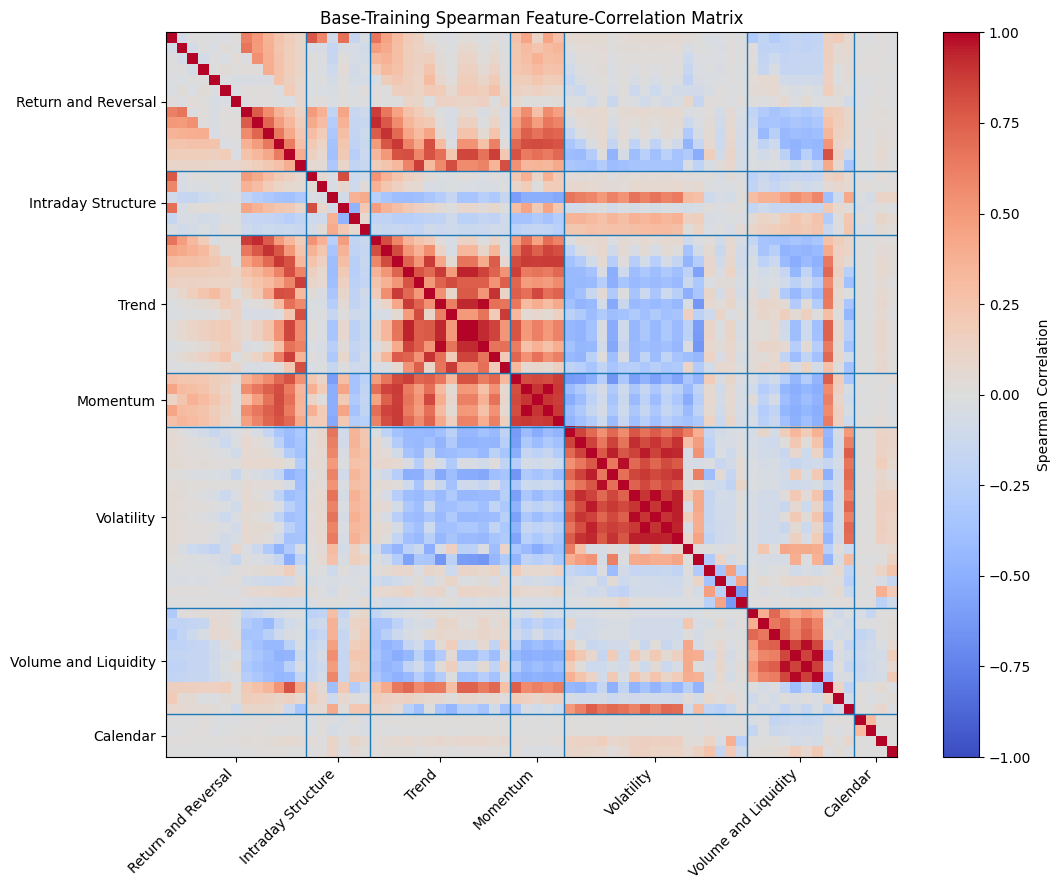

Figure saved to: /content/cqf_final_project/outputs/figures/feature_spearman_correlation_matrix.png


In [49]:
# -------------------------------------------------------------------
# Plot the base-training Spearman correlation matrix
# -------------------------------------------------------------------

ordered_feature_columns = [
    feature_name
    for group_features in feature_groups.values()
    for feature_name in group_features
]

ordered_spearman_correlation = (
    spearman_correlation.loc[
        ordered_feature_columns,
        ordered_feature_columns,
    ]
)

fig, ax = plt.subplots(figsize=(11, 9))

correlation_image = ax.imshow(
    ordered_spearman_correlation,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    aspect="auto",
)

group_sizes = [
    len(group_features)
    for group_features in feature_groups.values()
]

group_boundaries = np.cumsum(group_sizes)

for boundary in group_boundaries[:-1]:
    ax.axhline(
        boundary - 0.5,
        linewidth=1,
    )
    ax.axvline(
        boundary - 0.5,
        linewidth=1,
    )

group_start_positions = np.concatenate(
    ([0], group_boundaries[:-1])
)

group_midpoints = (
    group_start_positions
    + np.array(group_sizes) / 2
    - 0.5
)

group_labels = list(feature_groups.keys())

ax.set_xticks(group_midpoints)
ax.set_xticklabels(
    group_labels,
    rotation=45,
    ha="right",
)

ax.set_yticks(group_midpoints)
ax.set_yticklabels(group_labels)

ax.set_title(
    "Base-Training Spearman Feature-Correlation Matrix"
)

fig.colorbar(
    correlation_image,
    ax=ax,
    label="Spearman Correlation",
)

fig.tight_layout()

feature_correlation_figure_path = (
    DIRECTORIES["figures"]
    / "feature_spearman_correlation_matrix.png"
)

fig.savefig(
    feature_correlation_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{feature_correlation_figure_path}"
)

## 5.4 Pre-Registered Structural Feature Reduction

Four features are removed because they are exact algebraic transformations of other retained predictors.

`RET_1D` is excluded because it equals the sum of the overnight gap and the intraday return. Retaining the two components preserves the same information while allowing overnight and regular-session effects to enter the models separately.

`RET_2D` and `RET_3D` are excluded because they can be reconstructed exactly from the contemporaneous return components and the corresponding lagged one-day returns.

`WILLIAMS_R_14` is excluded because it is an affine transformation of `STOCHASTIC_K_14` and therefore contains no additional information.

These exclusions are determined from feature definitions rather than classification results. No blending or final-test information is used.

In [50]:
# -------------------------------------------------------------------
# Remove pre-registered exact structural redundancies
# -------------------------------------------------------------------

structural_drop_reasons = {
    "RET_1D": (
        "Exact sum of OVERNIGHT_GAP "
        "and INTRADAY_RETURN."
    ),
    "RET_2D": (
        "Exact combination of RET_1D "
        "and RET_LAG_1."
    ),
    "RET_3D": (
        "Exact combination of RET_1D, "
        "RET_LAG_1, and RET_LAG_2."
    ),
    "WILLIAMS_R_14": (
        "Affine transformation of "
        "STOCHASTIC_K_14."
    ),
}

structural_drop_features = list(
    structural_drop_reasons.keys()
)

missing_structural_features = [
    feature
    for feature in structural_drop_features
    if feature not in feature_columns
]

if missing_structural_features:
    raise ValueError(
        "Expected structural features are missing: "
        f"{missing_structural_features}"
    )

structurally_screened_features = [
    feature
    for feature in feature_columns
    if feature not in structural_drop_features
]

structural_screening_table = pd.DataFrame(
    {
        "Feature": structural_drop_features,
        "Decision": "Remove",
        "Reason": [
            structural_drop_reasons[feature]
            for feature in structural_drop_features
        ],
    }
)

display(structural_screening_table)

print(
    "Features before structural screening: "
    f"{len(feature_columns)}"
)

print(
    "Features after structural screening: "
    f"{len(structurally_screened_features)}"
)

,Feature,Decision,Reason
0,RET_1D,Remove,Exact sum of OVERNIGHT_GAP and INTRADAY_RETURN.
1,RET_2D,Remove,Exact combination of RET_1D and RET_LAG_1.
2,RET_3D,Remove,"Exact combination of RET_1D, RET_LAG_1, and RE..."
3,WILLIAMS_R_14,Remove,Affine transformation of STOCHASTIC_K_14.


Features before structural screening: 68
Features after structural screening: 64


In [51]:
# -------------------------------------------------------------------
# Re-evaluate matrix conditioning after structural screening
# -------------------------------------------------------------------

X_base_structural = X_base_full[
    structurally_screened_features
].copy()

structural_matrix_diagnostics = (
    calculate_matrix_diagnostics(
        X_base_structural
    )
)

matrix_diagnostic_comparison = pd.DataFrame(
    {
        "Full Candidate Matrix":
            full_matrix_diagnostics,
        "After Structural Screening":
            structural_matrix_diagnostics,
    }
).T

display(matrix_diagnostic_comparison)

,Observations,Features,Numerical rank,Rank deficiency,Largest singular value,Smallest singular value,Condition number
Full Candidate Matrix,"2,015.000000",68.000000,64.000000,4.000000,209.283486,0.000000,"15,596,448,041,856,778.000000"
After Structural Screening,"2,015.000000",64.000000,64.000000,0.000000,205.879401,0.230679,892.492531


In [52]:
# -------------------------------------------------------------------
# Save redundancy diagnostics and structural screening decisions
# -------------------------------------------------------------------

feature_selection_manifest = (
    feature_manifest.copy()
)

feature_selection_manifest["Structural_Status"] = (
    np.where(
        feature_selection_manifest["Feature"].isin(
            structural_drop_features
        ),
        "Removed",
        "Retained",
    )
)

feature_selection_manifest[
    "Structural_Reason"
] = (
    feature_selection_manifest["Feature"]
    .map(structural_drop_reasons)
    .fillna(
        "No exact pre-registered structural redundancy."
    )
)

structural_screening_table.to_csv(
    DIRECTORIES["tables"]
    / "structural_feature_screening.csv",
    index=False,
)

feature_selection_manifest.to_csv(
    DIRECTORIES["tables"]
    / "feature_selection_manifest_stage_1.csv",
    index=False,
)

high_pearson_pairs.to_csv(
    DIRECTORIES["tables"]
    / "high_pearson_correlation_pairs.csv",
    index=False,
)

high_spearman_pairs.to_csv(
    DIRECTORIES["tables"]
    / "high_spearman_correlation_pairs.csv",
    index=False,
)

matrix_diagnostic_comparison.to_csv(
    DIRECTORIES["tables"]
    / "feature_matrix_diagnostics.csv",
)

structural_identity_audit.to_csv(
    DIRECTORIES["tables"]
    / "structural_identity_audit.csv",
    header=True,
)

print(
    "Feature-redundancy diagnostics and structural "
    "screening decisions saved successfully."
)

Feature-redundancy diagnostics and structural screening decisions saved successfully.


## 5.5 Redundancy-Diagnostic Results and Preprocessing Implications

The full candidate matrix contains 68 features but has a numerical rank of only 64. The rank deficiency of four is consistent with the four exact algebraic identities identified from the feature definitions.

After removing `RET_1D`, `RET_2D`, `RET_3D`, and `WILLIAMS_R_14`, the remaining 64-feature matrix becomes full rank. The smallest singular value rises from approximately zero to 0.231, while the condition number falls from approximately $2.43 \times 10^{16}$ to 892.49.

The structural screening therefore removes the exact singularities successfully. However, the remaining condition number indicates that substantial near-collinearity remains.

The correlation analysis identifies 15 Pearson feature pairs and nine Spearman feature pairs with absolute correlation of at least 0.95. These relationships are concentrated within economically related feature families. Examples include alternative range-based volatility estimators, moving-average and MACD representations, total and downside volatility, and alternative transformations of abnormal volume.

High correlation is treated differently across model families. Linear and kernel-based models will use a correlation filter fitted separately within each training fold. Tree-based models will retain the structurally screened feature set because they are less sensitive to linear multicollinearity and may select among redundant variables through nonlinear splitting.

The full-base-training correlation results are used for diagnosis only. They do not define a fixed feature subset for cross-validation or final model estimation.

## 5.6 Leakage-Controlled Correlation Filtering

A custom correlation filter is constructed for models that are sensitive to multicollinearity and feature redundancy.

The filter is unsupervised and does not use the target variable. When two predictors exceed the specified absolute-correlation threshold, the variable with the higher average absolute correlation with the remaining feature set is removed. Ties are resolved deterministically.

The filter is placed inside the machine-learning pipeline. During time-series cross-validation, it is fitted separately on each training fold and then applied unchanged to the corresponding validation fold. This prevents validation-period information from affecting feature selection.

In [53]:
# -------------------------------------------------------------------
# Leakage-controlled correlation filter for sklearn pipelines
# -------------------------------------------------------------------

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Remove highly correlated features using training data only.

    When a pair exceeds the threshold, the feature with the higher
    mean absolute correlation with the remaining predictors is removed.
    """

    def __init__(
        self,
        threshold: float = 0.95,
        method: str = "pearson",
    ):
        self.threshold = threshold
        self.method = method

    def _convert_to_dataframe(
        self,
        X,
        fitting: bool,
    ) -> pd.DataFrame:
        """Convert input data to a DataFrame while preserving names."""

        if isinstance(X, pd.DataFrame):
            return X.copy()

        X_array = np.asarray(X)

        if X_array.ndim != 2:
            raise ValueError(
                "CorrelationFilter requires a two-dimensional input."
            )

        if fitting:
            columns = [
                f"feature_{index}"
                for index in range(X_array.shape[1])
            ]
        else:
            check_is_fitted(self, "feature_names_in_")
            columns = list(self.feature_names_in_)

        return pd.DataFrame(
            X_array,
            columns=columns,
        )

    def fit(self, X, y=None):
        """Learn which features to retain from the training sample."""

        if not 0 < self.threshold < 1:
            raise ValueError(
                "threshold must be strictly between zero and one."
            )

        if self.method not in {"pearson", "spearman"}:
            raise ValueError(
                "method must be either 'pearson' or 'spearman'."
            )

        X_dataframe = self._convert_to_dataframe(
            X,
            fitting=True,
        )

        if X_dataframe.isna().any().any():
            raise ValueError(
                "CorrelationFilter received missing values. "
                "Imputation must occur before correlation filtering."
            )

        self.feature_names_in_ = np.asarray(
            X_dataframe.columns,
            dtype=object,
        )

        correlation_matrix = (
            X_dataframe
            .corr(method=self.method)
            .abs()
            .fillna(0.0)
        )

        remaining_features = list(X_dataframe.columns)
        screening_history = []

        while len(remaining_features) > 1:
            current_correlation = correlation_matrix.loc[
                remaining_features,
                remaining_features,
            ]

            upper_triangle = current_correlation.where(
                np.triu(
                    np.ones(
                        current_correlation.shape,
                        dtype=bool,
                    ),
                    k=1,
                )
            )

            stacked_correlations = upper_triangle.stack()

            if stacked_correlations.empty:
                break

            maximum_correlation = (
                stacked_correlations.max()
            )

            if maximum_correlation < self.threshold:
                break

            feature_a, feature_b = (
                stacked_correlations.idxmax()
            )

            comparison_features_a = [
                feature
                for feature in remaining_features
                if feature != feature_a
            ]

            comparison_features_b = [
                feature
                for feature in remaining_features
                if feature != feature_b
            ]

            mean_correlation_a = (
                current_correlation.loc[
                    feature_a,
                    comparison_features_a,
                ].mean()
            )

            mean_correlation_b = (
                current_correlation.loc[
                    feature_b,
                    comparison_features_b,
                ].mean()
            )

            if mean_correlation_a > mean_correlation_b:
                dropped_feature = feature_a
                retained_feature = feature_b

            elif mean_correlation_b > mean_correlation_a:
                dropped_feature = feature_b
                retained_feature = feature_a

            else:
                # Deterministic tie-breaking rule.
                dropped_feature = sorted(
                    [feature_a, feature_b]
                )[-1]

                retained_feature = (
                    feature_b
                    if dropped_feature == feature_a
                    else feature_a
                )

            screening_history.append(
                {
                    "Feature_A": feature_a,
                    "Feature_B": feature_b,
                    "Pair_Correlation":
                        maximum_correlation,
                    "Dropped_Feature":
                        dropped_feature,
                    "Retained_Feature":
                        retained_feature,
                    "Dropped_Mean_Absolute_Correlation":
                        max(
                            mean_correlation_a,
                            mean_correlation_b,
                        ),
                }
            )

            remaining_features.remove(
                dropped_feature
            )

        self.features_to_keep_ = np.asarray(
            remaining_features,
            dtype=object,
        )

        self.features_to_drop_ = np.asarray(
            [
                row["Dropped_Feature"]
                for row in screening_history
            ],
            dtype=object,
        )

        self.screening_history_ = pd.DataFrame(
            screening_history
        )

        self.n_features_in_ = len(
            self.feature_names_in_
        )

        self.n_features_out_ = len(
            self.features_to_keep_
        )

        return self

    def transform(self, X):
        """Apply the fitted feature subset without recalculation."""

        check_is_fitted(
            self,
            [
                "feature_names_in_",
                "features_to_keep_",
            ],
        )

        X_dataframe = self._convert_to_dataframe(
            X,
            fitting=False,
        )

        missing_columns = [
            feature
            for feature in self.features_to_keep_
            if feature not in X_dataframe.columns
        ]

        if missing_columns:
            raise ValueError(
                "Input data are missing fitted features: "
                f"{missing_columns}"
            )

        return X_dataframe.loc[
            :,
            self.features_to_keep_,
        ].copy()

    def get_feature_names_out(
        self,
        input_features=None,
    ):
        """Return the retained feature names."""

        check_is_fitted(
            self,
            "features_to_keep_",
        )

        return self.features_to_keep_.copy()

In [54]:
# -------------------------------------------------------------------
# Reference correlation screening on the full base-training sample
# -------------------------------------------------------------------

reference_correlation_filter = CorrelationFilter(
    threshold=0.95,
    method="pearson",
)

X_base_correlation_filtered = (
    reference_correlation_filter.fit_transform(
        X_base_structural
    )
)

reference_filter_summary = pd.Series(
    {
        "Input features":
            X_base_structural.shape[1],
        "Retained features":
            X_base_correlation_filtered.shape[1],
        "Removed features":
            len(
                reference_correlation_filter
                .features_to_drop_
            ),
        "Correlation threshold":
            reference_correlation_filter.threshold,
        "Correlation method":
            reference_correlation_filter.method,
    },
    name="Reference Correlation Filter",
)

display(reference_filter_summary)

display(
    reference_correlation_filter
    .screening_history_
)

,Reference Correlation Filter
Input features,64
Retained features,54
Removed features,10
Correlation threshold,0.950000
Correlation method,pearson


,Feature_A,Feature_B,Pair_Correlation,Dropped_Feature,Retained_Feature,Dropped_Mean_Absolute_Correlation
0,EMA_12_TO_26,MACD_NORMALISED,0.996928,MACD_NORMALISED,EMA_12_TO_26,0.414855
1,PARKINSON_VOLATILITY_21,GARMAN_KLASS_VOLATILITY_21,0.996384,PARKINSON_VOLATILITY_21,GARMAN_KLASS_VOLATILITY_21,0.341614
2,PARKINSON_VOLATILITY_10,GARMAN_KLASS_VOLATILITY_10,0.994435,PARKINSON_VOLATILITY_10,GARMAN_KLASS_VOLATILITY_10,0.380425
3,VOLATILITY_63,DOWNSIDE_VOLATILITY_63,0.991240,DOWNSIDE_VOLATILITY_63,VOLATILITY_63,0.221104
4,SMA_10_TO_50,MACD_SIGNAL_NORMALISED,0.986431,MACD_SIGNAL_NORMALISED,SMA_10_TO_50,0.350030
5,VOLATILITY_21,GARMAN_KLASS_VOLATILITY_21,0.974394,VOLATILITY_21,GARMAN_KLASS_VOLATILITY_21,0.312750
6,GARMAN_KLASS_VOLATILITY_10,ATR_14_NORMALISED,0.961845,GARMAN_KLASS_VOLATILITY_10,ATR_14_NORMALISED,0.346168
7,DOWNSIDE_VOLATILITY_21,ATR_14_NORMALISED,0.956715,DOWNSIDE_VOLATILITY_21,ATR_14_NORMALISED,0.332229
8,VOLATILITY_10,ATR_14_NORMALISED,0.954290,VOLATILITY_10,ATR_14_NORMALISED,0.328633
9,CLOSE_TO_SMA_50,EMA_12_TO_26,0.951908,CLOSE_TO_SMA_50,EMA_12_TO_26,0.398807


In [55]:
# -------------------------------------------------------------------
# Diagnose the reference correlation-filtered matrix
# -------------------------------------------------------------------

filtered_pearson_correlation = (
    X_base_correlation_filtered.corr(
        method="pearson"
    )
)

filtered_spearman_correlation = (
    X_base_correlation_filtered.corr(
        method="spearman"
    )
)

remaining_high_pearson_pairs = (
    extract_high_correlation_pairs(
        filtered_pearson_correlation,
        threshold=0.95,
    )
)

remaining_high_spearman_pairs = (
    extract_high_correlation_pairs(
        filtered_spearman_correlation,
        threshold=0.95,
    )
)

correlation_filtered_diagnostics = (
    calculate_matrix_diagnostics(
        X_base_correlation_filtered
    )
)

extended_matrix_comparison = pd.DataFrame(
    {
        "Full Candidate Matrix":
            full_matrix_diagnostics,
        "After Structural Screening":
            structural_matrix_diagnostics,
        "After Reference Correlation Filtering":
            correlation_filtered_diagnostics,
    }
).T

display(extended_matrix_comparison)

print(
    "Remaining Pearson pairs at or above 0.95: "
    f"{len(remaining_high_pearson_pairs)}"
)

print(
    "Remaining Spearman pairs at or above 0.95: "
    f"{len(remaining_high_spearman_pairs)}"
)

,Observations,Features,Numerical rank,Rank deficiency,Largest singular value,Smallest singular value,Condition number
Full Candidate Matrix,"2,015.000000",68.000000,64.000000,4.000000,209.283486,0.000000,"15,596,448,041,856,778.000000"
After Structural Screening,"2,015.000000",64.000000,64.000000,0.000000,205.879401,0.230679,892.492531
After Reference Correlation Filtering,"2,015.000000",54.000000,54.000000,0.000000,176.147037,0.267014,659.691038


Remaining Pearson pairs at or above 0.95: 0
Remaining Spearman pairs at or above 0.95: 2


In [56]:
# -------------------------------------------------------------------
# Save reference correlation-filter diagnostics
# -------------------------------------------------------------------

reference_correlation_filter.screening_history_.to_csv(
    DIRECTORIES["tables"]
    / "reference_correlation_filter_history.csv",
    index=False,
)

reference_filter_summary.to_csv(
    DIRECTORIES["tables"]
    / "reference_correlation_filter_summary.csv",
    header=True,
)

extended_matrix_comparison.to_csv(
    DIRECTORIES["tables"]
    / "extended_feature_matrix_diagnostics.csv",
)

pd.Series(
    reference_correlation_filter.features_to_keep_,
    name="Retained Feature",
).to_csv(
    DIRECTORIES["tables"]
    / "reference_correlation_retained_features.csv",
    index=False,
)

print(
    "Reference correlation-filter diagnostics saved successfully."
)

Reference correlation-filter diagnostics saved successfully.


## 5.7 Correlation-Filter Diagnostic Results

Applying the reference Pearson correlation filter to the complete base-training sample reduces the structurally screened feature set from 64 to 54 predictors.

The filter removes 10 predictors from highly correlated pairs. The removed variables are concentrated in the trend and volatility families, including alternative MACD representations, closely related range-based volatility estimators, total and downside volatility measures, and overlapping moving-average features.

After reference filtering, the matrix remains full rank. Its condition number declines from approximately 892.49 to 659.69. No Pearson correlation pair remains above the absolute threshold of 0.95, although two Spearman pairs remain above that level because the filter is fitted using Pearson rather than rank correlation.

The remaining condition number indicates that economically related predictors continue to share information, but the matrix no longer contains exact or near-exact Pearson relationships above the selected threshold.

The 54-feature reference set is used only for diagnostic interpretation. During cross-validation, the correlation filter is refitted independently within each training fold. The retained feature list may therefore differ slightly across folds.

# 6 Model Development and Validation Framework

## 6.1 Purged Expanding-Window Cross-Validation

Model development is conducted exclusively within the base-training period. Randomly shuffled cross-validation is not used because it would destroy the chronological structure of the observations and allow future market regimes to influence earlier validation results.

Five expanding-window folds are constructed. Each validation fold contains 250 consecutive trading days, while all available earlier observations form the corresponding training sample.

A one-observation gap is imposed between each training and validation sample. This gap is required because the target attached to day $t$ is calculated from the return realised between days $t$ and $t+1$. Without purging, the final training label could incorporate the price observed on the first validation date.

The cross-validation structure therefore satisfies:

```text
Training observations
        ↓
One-day purging gap
        ↓
Chronologically later validation observations

In [57]:

# -------------------------------------------------------------------
# Construct purged expanding-window cross-validation folds
# -------------------------------------------------------------------

from sklearn.model_selection import TimeSeriesSplit

N_CV_SPLITS = 5
CV_TEST_SIZE = 250
CV_GAP = CONFIG["prediction_horizon_days"]

base_time_series_cv = TimeSeriesSplit(
    n_splits=N_CV_SPLITS,
    test_size=CV_TEST_SIZE,
    gap=CV_GAP,
)

X_base_model = X_base_structural.copy()
y_base_model = y_base.copy()

cv_splits = list(
    base_time_series_cv.split(
        X_base_model,
        y_base_model,
    )
)

cv_fold_records = []

for fold_number, (train_indices, validation_indices) in enumerate(
    cv_splits,
    start=1,
):
    train_dates = X_base_model.index[train_indices]
    validation_dates = X_base_model.index[validation_indices]

    gap_observations = (
        validation_indices.min()
        - train_indices.max()
        - 1
    )

    purged_indices = np.arange(
        train_indices.max() + 1,
        validation_indices.min(),
    )

    purged_dates = (
        X_base_model.index[purged_indices]
        if len(purged_indices) > 0
        else pd.DatetimeIndex([])
    )

    cv_fold_records.append(
        {
            "Fold": fold_number,
            "Training Start": train_dates.min(),
            "Training End": train_dates.max(),
            "Training Observations": len(train_indices),
            "Purged Observations": gap_observations,
            "Purged Start": (
                purged_dates.min()
                if len(purged_dates) > 0
                else pd.NaT
            ),
            "Purged End": (
                purged_dates.max()
                if len(purged_dates) > 0
                else pd.NaT
            ),
            "Validation Start": validation_dates.min(),
            "Validation End": validation_dates.max(),
            "Validation Observations": len(validation_indices),
            "Training Positive Rate":
                y_base_model.iloc[train_indices].mean(),
            "Validation Positive Rate":
                y_base_model.iloc[validation_indices].mean(),
        }
    )

cv_fold_structure = pd.DataFrame(
    cv_fold_records
).set_index("Fold")

display(cv_fold_structure)

,Training Start,Training End,Training Observations,Purged Observations,Purged Start,Purged End,Validation Start,Validation End,Validation Observations,Training Positive Rate,Validation Positive Rate
Fold,,,,,,,,,,,
1,2014-01-02,2017-01-12,764,1,2017-01-13,2017-01-13,2017-01-17,2018-01-11,250,0.539267,0.584000
2,2014-01-02,2018-01-10,1014,1,2018-01-11,2018-01-11,2018-01-12,2019-01-10,250,0.549310,0.528000
3,2014-01-02,2019-01-09,1264,1,2019-01-10,2019-01-10,2019-01-11,2020-01-08,250,0.545095,0.588000
4,2014-01-02,2020-01-07,1514,1,2020-01-08,2020-01-08,2020-01-09,2021-01-05,250,0.552180,0.576000
5,2014-01-02,2021-01-04,1764,1,2021-01-05,2021-01-05,2021-01-06,2021-12-31,250,0.555556,0.580000


In [58]:
# -------------------------------------------------------------------
# Validate the purged time-series folds
# -------------------------------------------------------------------

all_validation_indices = []

for fold_number, (train_indices, validation_indices) in enumerate(
    cv_splits,
    start=1,
):
    assert len(train_indices) > 0
    assert len(validation_indices) == CV_TEST_SIZE

    assert train_indices.max() < validation_indices.min()

    observed_gap = (
        validation_indices.min()
        - train_indices.max()
        - 1
    )

    assert observed_gap == CV_GAP

    assert (
        X_base_model.index[train_indices].max()
        < X_base_model.index[validation_indices].min()
    )

    assert np.intersect1d(
        train_indices,
        validation_indices,
    ).size == 0

    all_validation_indices.extend(
        validation_indices.tolist()
    )

assert len(all_validation_indices) == len(
    set(all_validation_indices)
)

print(
    "Purged expanding-window cross-validation "
    "validated successfully."
)

Purged expanding-window cross-validation validated successfully.


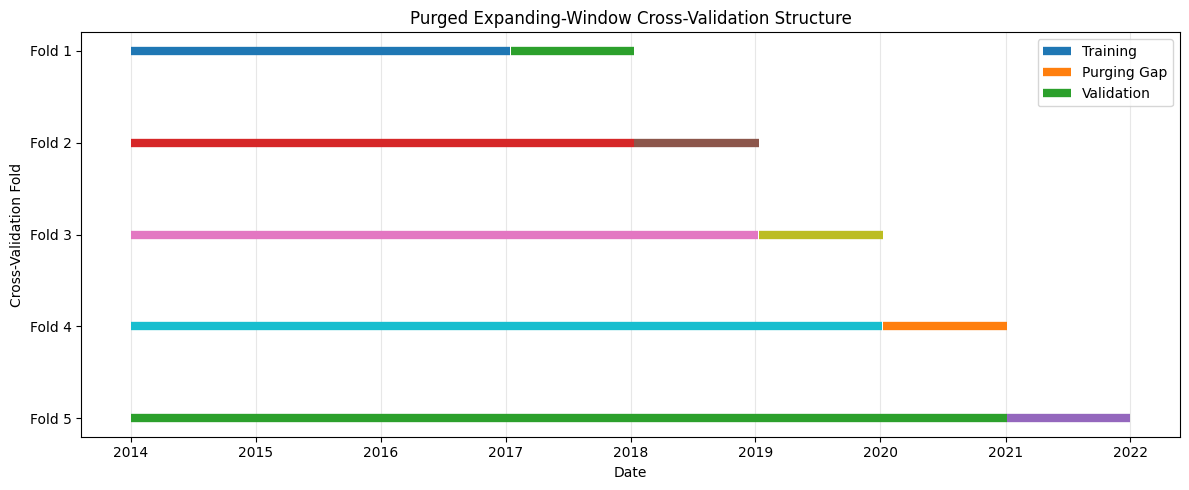

Figure saved to: /content/cqf_final_project/outputs/figures/model_purged_time_series_cv.png


In [59]:
# -------------------------------------------------------------------
# Visualise the cross-validation structure
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

for fold_number, (train_indices, validation_indices) in enumerate(
    cv_splits,
    start=1,
):
    y_position = N_CV_SPLITS - fold_number + 1

    train_dates = X_base_model.index[train_indices]
    validation_dates = X_base_model.index[validation_indices]

    purged_start_index = train_indices.max() + 1
    purged_end_index = validation_indices.min() - 1

    ax.plot(
        [train_dates.min(), train_dates.max()],
        [y_position, y_position],
        linewidth=6,
        solid_capstyle="butt",
        label="Training" if fold_number == 1 else None,
    )

    if purged_start_index <= purged_end_index:
        purged_dates = X_base_model.index[
            purged_start_index:purged_end_index + 1
        ]

        ax.plot(
            [purged_dates.min(), purged_dates.max()],
            [y_position, y_position],
            linewidth=6,
            solid_capstyle="butt",
            label="Purging Gap" if fold_number == 1 else None,
        )

    ax.plot(
        [validation_dates.min(), validation_dates.max()],
        [y_position, y_position],
        linewidth=6,
        solid_capstyle="butt",
        label="Validation" if fold_number == 1 else None,
    )

ax.set_yticks(range(1, N_CV_SPLITS + 1))
ax.set_yticklabels(
    [
        f"Fold {fold}"
        for fold in range(N_CV_SPLITS, 0, -1)
    ]
)

ax.set_title(
    "Purged Expanding-Window Cross-Validation Structure"
)
ax.set_xlabel("Date")
ax.set_ylabel("Cross-Validation Fold")
ax.legend()
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()

cv_structure_figure_path = (
    DIRECTORIES["figures"]
    / "model_purged_time_series_cv.png"
)

fig.savefig(
    cv_structure_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{cv_structure_figure_path}"
)

In [60]:
cv_fold_structure.to_csv(
    DIRECTORIES["tables"]
    / "model_cross_validation_fold_structure.csv"
)

print(
    "Cross-validation fold structure saved successfully."
)

Cross-validation fold structure saved successfully.


## 6.2 Model Families and Preprocessing Pipelines

The initial comparison includes a prior-probability dummy classifier and four heterogeneous machine-learning models.

Logistic regression provides an interpretable linear probability benchmark. Elastic-net regularisation is used to combine coefficient shrinkage and sparse selection.

A radial-basis-function support-vector machine captures smooth nonlinear decision boundaries. Its decision scores are converted into probabilities using time-aware sigmoid calibration.

Random forest represents a bagging-based tree ensemble and can capture nonlinear relationships and interactions without feature scaling.

XGBoost represents a sequential gradient-boosting framework with regularisation, shrinkage, row subsampling, and column subsampling.

Linear and kernel models use the leakage-controlled correlation filter and robust scaling. Tree-based models use the 64 structurally screened predictors without correlation filtering because tree splits are less sensitive to linear multicollinearity.

The models in this section use reasonable initial parameters. Their results are diagnostic baselines rather than final tuned estimates.

In [61]:
# -------------------------------------------------------------------
# Define initial benchmark and base-model pipelines
# -------------------------------------------------------------------

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

# Logistic regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        (
            "correlation_filter",
            CorrelationFilter(
                threshold=0.95,
                method="pearson",
            ),
        ),
        (
            "scaler",
            RobustScaler(
                quantile_range=(10.0, 90.0),
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                C=1.0,
                l1_ratio=0.5,
                class_weight="balanced",
                max_iter=5000,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

# SVM preprocessing and classifier
svm_uncalibrated_pipeline = Pipeline(
    steps=[
        (
            "correlation_filter",
            CorrelationFilter(
                threshold=0.95,
                method="pearson",
            ),
        ),
        (
            "scaler",
            RobustScaler(
                quantile_range=(10.0, 90.0),
            ),
        ),
        (
            "classifier",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced",
                probability=False,
            ),
        ),
    ]
)

# Time-aware calibration performed inside each outer training fold.
svm_calibration_cv = TimeSeriesSplit(
    n_splits=3,
    gap=CV_GAP,
)

svm_calibrated_model = CalibratedClassifierCV(
    estimator=svm_uncalibrated_pipeline,
    method="sigmoid",
    cv=svm_calibration_cv,
    ensemble=True,
)

random_forest_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_SEED,
)

xgboost_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.00,
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_SEED,
)

dummy_model = DummyClassifier(
    strategy="prior",
    random_state=RANDOM_SEED,
)

initial_models = {
    "Dummy Prior": dummy_model,
    "Elastic-Net Logistic": logistic_pipeline,
    "Calibrated RBF SVM": svm_calibrated_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model,
}

print("Initial model families created:")
for model_name in initial_models:
    print(f"- {model_name}")

Initial model families created:
- Dummy Prior
- Elastic-Net Logistic
- Calibrated RBF SVM
- Random Forest
- XGBoost


## 6.3 Evaluation Metrics

Models are evaluated using both class predictions and probability forecasts.

Accuracy is reported for completeness but is not treated as the principal selection metric because the positive-class frequency varies across time.

Balanced accuracy assigns equal importance to the two classes. Macro F1 similarly gives equal weight to the class-specific F1 scores.

ROC-AUC measures ranking performance across all possible thresholds. Average precision provides an additional probability-ranking measure that is sensitive to positive-class retrieval.

The Brier score and logarithmic loss assess the quality and calibration of predicted probabilities. Lower values indicate better probability forecasts.

The primary development metric is ROC-AUC, while balanced accuracy, macro F1, Brier score, and log loss are used as complementary diagnostics. Final model selection will not rely on a single statistic.

In [62]:
# -------------------------------------------------------------------
# Define probability and classification evaluation functions
# -------------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    matthews_corrcoef,
)


def calculate_classification_metrics(
    y_true,
    predicted_probability,
    threshold: float = 0.50,
) -> pd.Series:
    """Calculate classification and probability metrics."""

    y_true_array = np.asarray(y_true, dtype=int)
    probability_array = np.asarray(
        predicted_probability,
        dtype=float,
    )

    probability_array = np.clip(
        probability_array,
        1e-12,
        1 - 1e-12,
    )

    predicted_class = (
        probability_array >= threshold
    ).astype(int)

    if np.unique(y_true_array).size == 2:
        roc_auc = roc_auc_score(
            y_true_array,
            probability_array,
        )

        average_precision = average_precision_score(
            y_true_array,
            probability_array,
        )
    else:
        roc_auc = np.nan
        average_precision = np.nan

    return pd.Series(
        {
            "Observations": len(y_true_array),
            "Positive Rate": y_true_array.mean(),
            "Predicted Positive Rate":
                predicted_class.mean(),
            "Accuracy":
                accuracy_score(
                    y_true_array,
                    predicted_class,
                ),
            "Balanced Accuracy":
                balanced_accuracy_score(
                    y_true_array,
                    predicted_class,
                ),
            "ROC-AUC": roc_auc,
            "Average Precision":
                average_precision,
            "Macro F1":
                f1_score(
                    y_true_array,
                    predicted_class,
                    average="macro",
                    zero_division=0,
                ),
            "Positive Precision":
                precision_score(
                    y_true_array,
                    predicted_class,
                    zero_division=0,
                ),
            "Positive Recall":
                recall_score(
                    y_true_array,
                    predicted_class,
                    zero_division=0,
                ),
            "Matthews Correlation":
                matthews_corrcoef(
                    y_true_array,
                    predicted_class,
                ),
            "Brier Score":
                brier_score_loss(
                    y_true_array,
                    probability_array,
                ),
            "Log Loss":
                log_loss(
                    y_true_array,
                    probability_array,
                    labels=[0, 1],
                ),
        }
    )

## 6.4 Initial Walk-Forward Model Evaluation

Each initial model is fitted independently within every expanding-window training fold. Predictions are generated only for the chronologically later validation observations.

The preprocessing pipeline, correlation filter, scaler, classifier, and probability calibration are refitted within each fold. No fitted object is carried from one fold to another.

The resulting out-of-fold probabilities provide a common development-stage comparison before hyperparameter optimisation. These probabilities are not the blending probabilities used to train the final meta-model; the latter will be generated later from models fitted on the complete base-training sample and evaluated on the separate blending period.

In [63]:
# -------------------------------------------------------------------
# Evaluate models using purged walk-forward validation
# -------------------------------------------------------------------

def get_positive_class_probability(
    fitted_estimator,
    X,
) -> np.ndarray:
    """Extract the probability assigned to class one."""

    if not hasattr(fitted_estimator, "predict_proba"):
        raise AttributeError(
            "The fitted estimator does not provide predict_proba()."
        )

    probability_matrix = fitted_estimator.predict_proba(X)

    classes = np.asarray(
        fitted_estimator.classes_
    )

    positive_class_locations = np.where(
        classes == 1
    )[0]

    if len(positive_class_locations) != 1:
        raise ValueError(
            "The fitted estimator does not contain a unique class 1."
        )

    return probability_matrix[
        :,
        positive_class_locations[0],
    ]


def evaluate_models_walk_forward(
    models: dict,
    X: pd.DataFrame,
    y: pd.Series,
    splits: list,
    threshold: float = 0.50,
):
    """Evaluate multiple estimators on identical time-series folds."""

    fold_metric_records = []
    prediction_records = []

    for model_name, estimator in models.items():
        print(f"Evaluating {model_name}...")

        for fold_number, (
            train_indices,
            validation_indices,
        ) in enumerate(
            splits,
            start=1,
        ):
            X_train = X.iloc[train_indices]
            y_train = y.iloc[train_indices]

            X_validation = X.iloc[validation_indices]
            y_validation = y.iloc[validation_indices]

            fitted_estimator = clone(estimator)

            fitted_estimator.fit(
                X_train,
                y_train,
            )

            validation_probability = (
                get_positive_class_probability(
                    fitted_estimator,
                    X_validation,
                )
            )

            fold_metrics = (
                calculate_classification_metrics(
                    y_validation,
                    validation_probability,
                    threshold=threshold,
                )
            )

            fold_record = {
                "Model": model_name,
                "Fold": fold_number,
                "Training Start":
                    X_train.index.min(),
                "Training End":
                    X_train.index.max(),
                "Validation Start":
                    X_validation.index.min(),
                "Validation End":
                    X_validation.index.max(),
            }

            fold_record.update(
                fold_metrics.to_dict()
            )

            fold_metric_records.append(
                fold_record
            )

            validation_predictions = pd.DataFrame(
                {
                    "Date": X_validation.index,
                    "Model": model_name,
                    "Fold": fold_number,
                    "Actual": y_validation.to_numpy(),
                    "Probability":
                        validation_probability,
                    "Prediction":
                        (
                            validation_probability
                            >= threshold
                        ).astype(int),
                }
            )

            prediction_records.append(
                validation_predictions
            )

            print(
                f"  Fold {fold_number}: "
                f"ROC-AUC={fold_metrics['ROC-AUC']:.4f}, "
                f"Balanced Accuracy="
                f"{fold_metrics['Balanced Accuracy']:.4f}"
            )

    fold_metrics_table = pd.DataFrame(
        fold_metric_records
    )

    oof_predictions = pd.concat(
        prediction_records,
        ignore_index=True,
    )

    pooled_metric_records = []

    for model_name in models:
        model_predictions = (
            oof_predictions.loc[
                oof_predictions["Model"]
                == model_name
            ]
            .sort_values("Date")
        )

        pooled_metrics = (
            calculate_classification_metrics(
                model_predictions["Actual"],
                model_predictions["Probability"],
                threshold=threshold,
            )
        )

        pooled_record = {
            "Model": model_name,
        }

        pooled_record.update(
            pooled_metrics.to_dict()
        )

        pooled_metric_records.append(
            pooled_record
        )

    pooled_metrics_table = (
        pd.DataFrame(
            pooled_metric_records
        )
        .set_index("Model")
        .sort_values(
            "ROC-AUC",
            ascending=False,
        )
    )

    return (
        fold_metrics_table,
        oof_predictions,
        pooled_metrics_table,
    )


(
    initial_fold_metrics,
    initial_oof_predictions,
    initial_pooled_metrics,
) = evaluate_models_walk_forward(
    models=initial_models,
    X=X_base_model,
    y=y_base_model,
    splits=cv_splits,
    threshold=CONFIG[
        "baseline_classification_threshold"
    ],
)

Evaluating Dummy Prior...
  Fold 1: ROC-AUC=0.5000, Balanced Accuracy=0.5000
  Fold 2: ROC-AUC=0.5000, Balanced Accuracy=0.5000
  Fold 3: ROC-AUC=0.5000, Balanced Accuracy=0.5000
  Fold 4: ROC-AUC=0.5000, Balanced Accuracy=0.5000
  Fold 5: ROC-AUC=0.5000, Balanced Accuracy=0.5000
Evaluating Elastic-Net Logistic...
  Fold 1: ROC-AUC=0.4543, Balanced Accuracy=0.4817
  Fold 2: ROC-AUC=0.4539, Balanced Accuracy=0.4617
  Fold 3: ROC-AUC=0.5066, Balanced Accuracy=0.4749
  Fold 4: ROC-AUC=0.4847, Balanced Accuracy=0.5039
  Fold 5: ROC-AUC=0.4802, Balanced Accuracy=0.4980
Evaluating Calibrated RBF SVM...
  Fold 1: ROC-AUC=0.5069, Balanced Accuracy=0.5155
  Fold 2: ROC-AUC=0.4818, Balanced Accuracy=0.4983
  Fold 3: ROC-AUC=0.4778, Balanced Accuracy=0.4956
  Fold 4: ROC-AUC=0.5368, Balanced Accuracy=0.5000
  Fold 5: ROC-AUC=0.5369, Balanced Accuracy=0.5000
Evaluating Random Forest...
  Fold 1: ROC-AUC=0.5429, Balanced Accuracy=0.5511
  Fold 2: ROC-AUC=0.4808, Balanced Accuracy=0.4892
  Fold 3: R

In [64]:
# -------------------------------------------------------------------
# Summarise mean and dispersion across validation folds
# -------------------------------------------------------------------

summary_metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "ROC-AUC",
    "Average Precision",
    "Macro F1",
    "Matthews Correlation",
    "Brier Score",
    "Log Loss",
]

initial_cv_summary = (
    initial_fold_metrics
    .groupby("Model")[
        summary_metric_columns
    ]
    .agg(["mean", "std"])
)

display(initial_pooled_metrics)
display(initial_cv_summary)

,Observations,Positive Rate,Predicted Positive Rate,Accuracy,Balanced Accuracy,ROC-AUC,Average Precision,Macro F1,Positive Precision,Positive Recall,Matthews Correlation,Brier Score,Log Loss
Model,,,,,,,,,,,,,
Calibrated RBF SVM,"1,250.000000",0.571200,0.812800,0.544000,0.499446,0.504288,0.586286,0.465130,0.570866,0.812325,-0.001406,0.248150,0.689449
XGBoost,"1,250.000000",0.571200,0.520800,0.509600,0.506775,0.504288,0.561802,0.505414,0.577573,0.526611,0.013424,0.269151,0.737019
Random Forest,"1,250.000000",0.571200,0.517600,0.506400,0.503974,0.497539,0.557523,0.502477,0.574961,0.521008,0.007873,0.255772,0.705161
Dummy Prior,"1,250.000000",0.571200,1.000000,0.571200,0.500000,0.496734,0.571876,0.363544,0.571200,1.000000,0.000000,0.245540,0.684207
Elastic-Net Logistic,"1,250.000000",0.571200,0.291200,0.451200,0.480538,0.472080,0.548493,0.440609,0.538462,0.274510,-0.042400,0.280590,0.761382


Accuracy          Balanced Accuracy           ROC-AUC  \
                         mean      std              mean      std     mean   
Model                                                                        
Calibrated RBF SVM   0.544000 0.049234          0.501870 0.007816 0.508044   
Dummy Prior          0.571200 0.024560          0.500000 0.000000 0.500000   
Elastic-Net Logistic 0.451200 0.010733          0.484032 0.017162 0.475940   
Random Forest        0.506400 0.034479          0.508510 0.042745 0.507649   
XGBoost              0.509600 0.038946          0.510667 0.043510 0.514258   

                              Average Precision          Macro F1           \
                          std              mean      std     mean      std   
Model                                                                        
Calibrated RBF SVM   0.028597          0.596792 0.036272 0.399330 0.034802   
Dummy Prior          0.000000          0.571200 0.024560 0.363417 0.010147   
Elastic-Net Logistic 0.022293          0.561241 0.035720 0.432778 0.032882   
Random Forest        0.036776          0.573705 0.047652 0.492367 0.037051   
XGBoost              0.056647          0.574719 0.048451 0.498717 0.036953   

                     Matthews Correlation          Brier Score           \
                                     mean      std        mean      std   
Model                                                                     
Calibrated RBF SVM               0.002052 0.021272    0.248150 0.005778   
Dummy Prior                      0.000000 0.000000    0.245540 0.002338   
Elastic-Net Logistic            -0.032894 0.034806    0.280590 0.020536   
Random Forest                    0.019141 0.088874    0.255772 0.003647   
XGBoost                          0.022503 0.089133    0.269151 0.007912   

                     Log Loss           
                         mean      std  
Model                                   
Calibrated RBF SVM   0.689449 0.011631  
Dummy Prior          0.684207 0.004690  
Elastic-Net Logistic 0.761382 0.050481  
Random Forest        0.705161 0.007461  
XGBoost              0.737019 0.018399

In [65]:
# -------------------------------------------------------------------
# Save initial walk-forward evaluation outputs
# -------------------------------------------------------------------

initial_fold_metrics.to_csv(
    DIRECTORIES["tables"]
    / "initial_model_fold_metrics.csv",
    index=False,
)

initial_oof_predictions.to_csv(
    DIRECTORIES["tables"]
    / "initial_model_oof_predictions.csv",
    index=False,
)

initial_pooled_metrics.to_csv(
    DIRECTORIES["tables"]
    / "initial_model_pooled_metrics.csv"
)

initial_cv_summary.to_csv(
    DIRECTORIES["tables"]
    / "initial_model_cv_summary.csv"
)

print(
    "Initial walk-forward model results "
    "saved successfully."
)

Initial walk-forward model results saved successfully.


## 6.5 Initial Model Results and Prediction Diversity

The initial walk-forward results show that none of the untuned classifiers produces a consistently strong directional signal across all validation periods.

XGBoost achieves the highest mean fold-level ROC-AUC at approximately 0.515, followed by the calibrated RBF support-vector machine and random forest. The elastic-net logistic model underperforms the prior-probability benchmark, suggesting that the relationship between the current predictors and the target is unlikely to be well represented by a single stable linear decision boundary.

The individual fold results vary materially through time. For example, XGBoost performs strongly in the first validation fold but is close to or below the random benchmark in several later folds. This variation is consistent with the regime changes identified during exploratory analysis.

The initial probability forecasts also differ substantially across model families. The support-vector machine predicts the positive class much more frequently than the other nonlinear models, while the logistic model produces comparatively few positive classifications. These differences motivate further probability diagnostics and indicate that the models may contribute heterogeneous information to an ensemble.

The fold-level mean ROC-AUC is treated as the main initial ranking statistic. Pooled out-of-fold results are reported as supplementary diagnostics because probability levels may differ across independently fitted validation folds.

These models have not yet been optimised. The current results provide baseline performance, probability behaviour, and model-diversity evidence for the subsequent hyperparameter-optimisation stage.

In [66]:
# -------------------------------------------------------------------
# Summarise fold-level performance and stability
# -------------------------------------------------------------------

initial_model_stability = (
    initial_fold_metrics
    .groupby("Model")
    .agg(
        Mean_ROC_AUC=("ROC-AUC", "mean"),
        Std_ROC_AUC=("ROC-AUC", "std"),
        Minimum_ROC_AUC=("ROC-AUC", "min"),
        Maximum_ROC_AUC=("ROC-AUC", "max"),
        Mean_Balanced_Accuracy=(
            "Balanced Accuracy",
            "mean",
        ),
        Mean_Macro_F1=("Macro F1", "mean"),
        Mean_Brier_Score=("Brier Score", "mean"),
        Mean_Log_Loss=("Log Loss", "mean"),
        Mean_Predicted_Positive_Rate=(
            "Predicted Positive Rate",
            "mean",
        ),
    )
    .sort_values(
        "Mean_ROC_AUC",
        ascending=False,
    )
)

display(initial_model_stability)

,Mean_ROC_AUC,Std_ROC_AUC,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_Balanced_Accuracy,Mean_Macro_F1,Mean_Brier_Score,Mean_Log_Loss,Mean_Predicted_Positive_Rate
Model,,,,,,,,,
XGBoost,0.514258,0.056647,0.461726,0.609787,0.510667,0.498717,0.269151,0.737019,0.520800
Calibrated RBF SVM,0.508044,0.028597,0.477776,0.536946,0.501870,0.399330,0.248150,0.689449,0.812800
Random Forest,0.507649,0.036776,0.477908,0.552447,0.508510,0.492367,0.255772,0.705161,0.517600
Dummy Prior,0.500000,0.000000,0.500000,0.500000,0.500000,0.363417,0.245540,0.684207,1.000000
Elastic-Net Logistic,0.475940,0.022293,0.453903,0.506572,0.484032,0.432778,0.280590,0.761382,0.291200


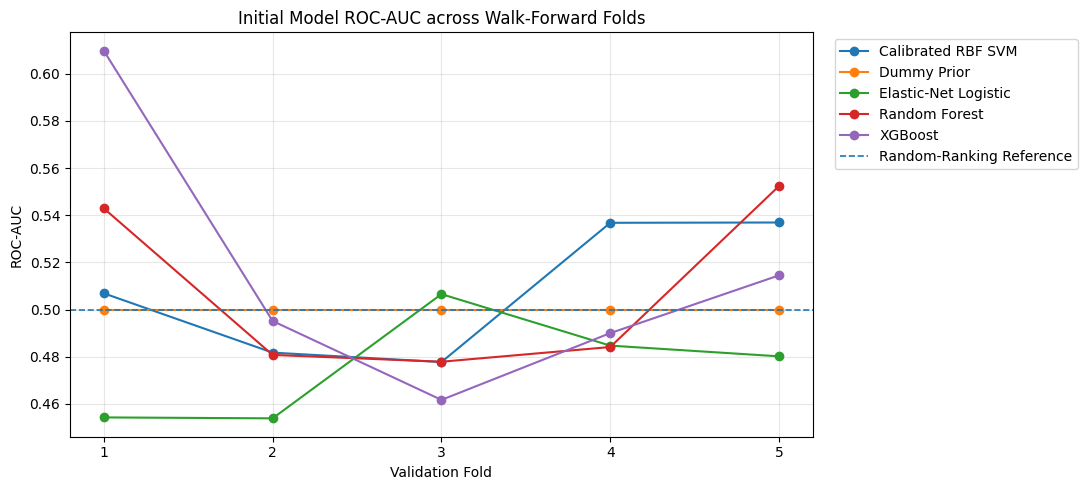

Figure saved to: /content/cqf_final_project/outputs/figures/initial_model_fold_roc_auc.png


In [67]:
# -------------------------------------------------------------------
# Plot fold-level ROC-AUC performance
# -------------------------------------------------------------------

fold_auc_table = (
    initial_fold_metrics
    .pivot(
        index="Fold",
        columns="Model",
        values="ROC-AUC",
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 5))

for model_name in fold_auc_table.columns:
    ax.plot(
        fold_auc_table.index,
        fold_auc_table[model_name],
        marker="o",
        label=model_name,
    )

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1.2,
    label="Random-Ranking Reference",
)

ax.set_title(
    "Initial Model ROC-AUC across Walk-Forward Folds"
)
ax.set_xlabel("Validation Fold")
ax.set_ylabel("ROC-AUC")
ax.set_xticks(fold_auc_table.index)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.grid(alpha=0.3)

fig.tight_layout()

initial_fold_auc_figure_path = (
    DIRECTORIES["figures"]
    / "initial_model_fold_roc_auc.png"
)

fig.savefig(
    initial_fold_auc_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{initial_fold_auc_figure_path}"
)

In [68]:
# -------------------------------------------------------------------
# Summarise out-of-fold probability behaviour
# -------------------------------------------------------------------

initial_probability_summary = (
    initial_oof_predictions
    .groupby("Model")
    .agg(
        Observations=("Probability", "size"),
        Mean_Probability=("Probability", "mean"),
        Probability_Standard_Deviation=(
            "Probability",
            "std",
        ),
        Minimum_Probability=("Probability", "min"),
        Probability_05_Percentile=(
            "Probability",
            lambda values: values.quantile(0.05),
        ),
        Median_Probability=("Probability", "median"),
        Probability_95_Percentile=(
            "Probability",
            lambda values: values.quantile(0.95),
        ),
        Maximum_Probability=("Probability", "max"),
        Predicted_Positive_Rate=(
            "Prediction",
            "mean",
        ),
    )
    .sort_values(
        "Mean_Probability",
        ascending=False,
    )
)

display(initial_probability_summary)

,Observations,Mean_Probability,Probability_Standard_Deviation,Minimum_Probability,Probability_05_Percentile,Median_Probability,Probability_95_Percentile,Maximum_Probability,Predicted_Positive_Rate
Model,,,,,,,,,
Dummy Prior,1250,0.548281,0.005669,0.539267,0.539267,0.549310,0.555556,0.555556,1.000000
Calibrated RBF SVM,1250,0.533322,0.041983,0.386794,0.442248,0.550545,0.575560,0.603214,0.812800
Random Forest,1250,0.504625,0.075452,0.276479,0.378666,0.504411,0.633307,0.737458,0.517600
XGBoost,1250,0.504604,0.144131,0.123674,0.267882,0.508820,0.737572,0.876583,0.520800
Elastic-Net Logistic,1250,0.447110,0.118978,0.103387,0.237085,0.442375,0.649901,0.858229,0.291200


In [69]:
# -------------------------------------------------------------------
# Construct aligned out-of-fold prediction matrices
# -------------------------------------------------------------------

non_dummy_model_names = [
    model_name
    for model_name in initial_models
    if model_name != "Dummy Prior"
]

probability_wide = (
    initial_oof_predictions
    .pivot(
        index="Date",
        columns="Model",
        values="Probability",
    )
    .sort_index()
)

prediction_wide = (
    initial_oof_predictions
    .pivot(
        index="Date",
        columns="Model",
        values="Prediction",
    )
    .sort_index()
)

assert probability_wide.notna().all().all()
assert prediction_wide.notna().all().all()

model_probability_correlation = (
    probability_wide[
        non_dummy_model_names
    ]
    .corr(method="spearman")
)

pairwise_prediction_disagreement = pd.DataFrame(
    index=non_dummy_model_names,
    columns=non_dummy_model_names,
    dtype=float,
)

for model_a in non_dummy_model_names:
    for model_b in non_dummy_model_names:
        pairwise_prediction_disagreement.loc[
            model_a,
            model_b,
        ] = (
            prediction_wide[model_a]
            != prediction_wide[model_b]
        ).mean()

display(model_probability_correlation)
display(pairwise_prediction_disagreement)

Model,Elastic-Net Logistic,Calibrated RBF SVM,Random Forest,XGBoost
Model,,,,
Elastic-Net Logistic,1.000000,0.023251,0.427829,0.372701
Calibrated RBF SVM,0.023251,1.000000,0.315242,0.178104
Random Forest,0.427829,0.315242,1.000000,0.785867
XGBoost,0.372701,0.178104,0.785867,1.000000


,Elastic-Net Logistic,Calibrated RBF SVM,Random Forest,XGBoost
Elastic-Net Logistic,0.000000,0.596800,0.375200,0.397600
Calibrated RBF SVM,0.596800,0.000000,0.359200,0.410400
Random Forest,0.375200,0.359200,0.000000,0.201600
XGBoost,0.397600,0.410400,0.201600,0.000000


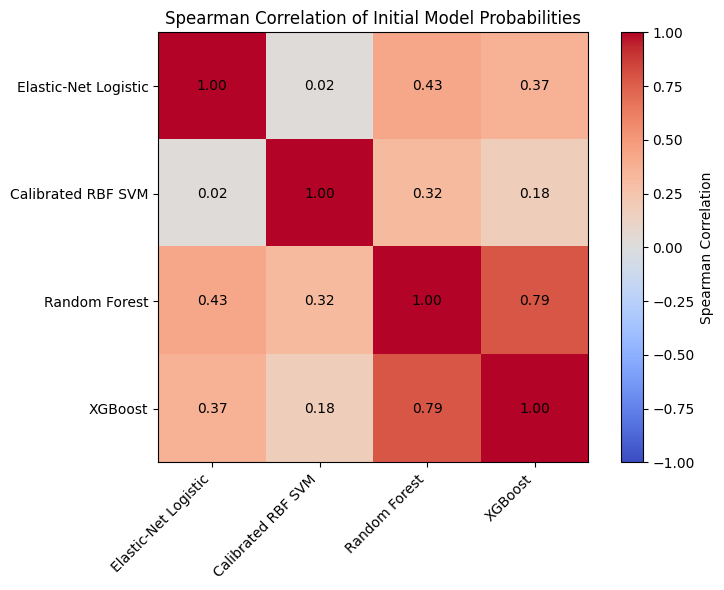

Figure saved to: /content/cqf_final_project/outputs/figures/initial_model_probability_correlation.png


In [70]:
# -------------------------------------------------------------------
# Plot model probability correlation
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

correlation_image = ax.imshow(
    model_probability_correlation,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

ax.set_xticks(
    range(len(model_probability_correlation.columns))
)

ax.set_xticklabels(
    model_probability_correlation.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    range(len(model_probability_correlation.index))
)

ax.set_yticklabels(
    model_probability_correlation.index
)

for row_index in range(
    model_probability_correlation.shape[0]
):
    for column_index in range(
        model_probability_correlation.shape[1]
    ):
        ax.text(
            column_index,
            row_index,
            (
                f"{model_probability_correlation.iloc[
                    row_index,
                    column_index
                ]:.2f}"
            ),
            ha="center",
            va="center",
        )

ax.set_title(
    "Spearman Correlation of Initial Model Probabilities"
)

fig.colorbar(
    correlation_image,
    ax=ax,
    label="Spearman Correlation",
)

fig.tight_layout()

initial_model_correlation_figure_path = (
    DIRECTORIES["figures"]
    / "initial_model_probability_correlation.png"
)

fig.savefig(
    initial_model_correlation_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{initial_model_correlation_figure_path}"
)

In [71]:
# -------------------------------------------------------------------
# Save initial model diagnostic outputs
# -------------------------------------------------------------------

initial_model_stability.to_csv(
    DIRECTORIES["tables"]
    / "initial_model_stability_summary.csv"
)

initial_probability_summary.to_csv(
    DIRECTORIES["tables"]
    / "initial_model_probability_summary.csv"
)

model_probability_correlation.to_csv(
    DIRECTORIES["tables"]
    / "initial_model_probability_correlation.csv"
)

pairwise_prediction_disagreement.to_csv(
    DIRECTORIES["tables"]
    / "initial_model_prediction_disagreement.csv"
)

fold_auc_table.to_csv(
    DIRECTORIES["tables"]
    / "initial_model_fold_auc_table.csv"
)

print(
    "Initial model stability and diversity "
    "diagnostics saved successfully."
)

Initial model stability and diversity diagnostics saved successfully.


## 6.6 Automated Hyperparameter Optimisation


### 6.6.1 Optimisation Design and Search Procedure

The initial walk-forward experiment confirms that the candidate model families produce materially different probability forecasts, but none of the untuned models delivers a consistently strong signal across all validation folds.

Classifier-specific hyperparameter optimisation is therefore conducted using Optuna. The optimisation remains restricted to the base-training sample and uses the same purged expanding-window folds employed in the initial comparison.

For a parameter vector $\theta$, the optimisation objective is the mean fold-level ROC-AUC:

$$
J(\theta)
=
\frac{1}{K}
\sum_{k=1}^{K}
\operatorname{AUC}_{k}(\theta),
$$

where $K=5$ is the number of chronological validation folds.

The standard deviation, minimum, and maximum fold-level ROC-AUC are recorded as stability diagnostics but are not directly incorporated into the objective. This preserves a transparent primary optimisation criterion while allowing unstable high-scoring trials to be identified during the subsequent analysis.

Optuna uses the Tree-structured Parzen Estimator sampler. The method constructs separate probability models for relatively strong and relatively weak trials and proposes parameter values that are expected to improve the objective. In simplified form, promising parameters are associated with a high ratio:

$$
\frac{l(\theta)}{g(\theta)},
$$

where $l(\theta)$ represents the density of parameters among stronger trials and $g(\theta)$ represents the corresponding density among weaker trials.

A median pruner is also used. After each validation fold, trials whose intermediate mean ROC-AUC is materially below the historical median may be terminated. This reduces computational cost without using the blending or final-test samples.

The following classifier-specific parameters are considered:

| Model | Main optimised parameters |
|---|---|
| Elastic-Net Logistic Regression | Regularisation strength, L1 ratio, class weighting, correlation threshold |
| RBF Support-Vector Machine | Penalty strength, kernel width, class weighting, tolerance, correlation threshold |
| Random Forest | Number and depth of trees, minimum node sizes, feature subsampling, observation subsampling, class weighting |
| XGBoost | Number of trees, learning rate, tree depth, child weight, row and column subsampling, split penalty and regularisation |

The SVM is optimised using its continuous decision function rather than repeatedly performing probability calibration inside every trial. Once the optimal structural parameters are selected, the chosen SVM will be refitted with chronological probability calibration.

For reproducibility, all studies use a fixed random seed. Trial histories, selected parameters, fold-level diagnostics, execution times, convergence paths, and parameter-importance estimates are archived.

In [72]:
# -------------------------------------------------------------------
# Optuna configuration and shared optimisation utilities
# -------------------------------------------------------------------

import gc
import time
from sklearn.exceptions import ConvergenceWarning

optuna.logging.set_verbosity(
    optuna.logging.WARNING
)

OPTUNA_TRIALS_PER_MODEL = 30

OPTUNA_MODEL_NAMES = [
    "Elastic-Net Logistic",
    "RBF SVM",
    "Random Forest",
    "XGBoost",
]

print(
    "Optuna trials per model: "
    f"{OPTUNA_TRIALS_PER_MODEL}"
)

print(
    "Total planned trials: "
    f"{OPTUNA_TRIALS_PER_MODEL * len(OPTUNA_MODEL_NAMES)}"
)

Optuna trials per model: 30
Total planned trials: 120


In [73]:
# -------------------------------------------------------------------
# Extract a continuous classification score
# -------------------------------------------------------------------

def extract_continuous_classification_score(
    fitted_estimator,
    X,
) -> np.ndarray:
    """
    Extract the positive-class probability or continuous decision score.

    ROC-AUC is invariant to monotonic transformations, so an uncalibrated
    SVM decision function can be used during hyperparameter optimisation.
    """

    if hasattr(fitted_estimator, "predict_proba"):
        probability_matrix = fitted_estimator.predict_proba(X)

        classes = np.asarray(
            fitted_estimator.classes_
        )

        positive_locations = np.where(
            classes == 1
        )[0]

        if len(positive_locations) != 1:
            raise ValueError(
                "A unique positive class could not be identified."
            )

        return probability_matrix[
            :,
            positive_locations[0],
        ]

    if hasattr(fitted_estimator, "decision_function"):
        decision_score = fitted_estimator.decision_function(X)

        decision_score = np.asarray(
            decision_score,
            dtype=float,
        )

        if decision_score.ndim != 1:
            raise ValueError(
                "Only binary decision scores are supported."
            )

        return decision_score

    raise AttributeError(
        "The estimator provides neither predict_proba() "
        "nor decision_function()."
    )


def extract_retained_feature_count(
    fitted_estimator,
) -> float:
    """Return the fitted correlation-filter output size where available."""

    if isinstance(fitted_estimator, Pipeline):
        if (
            "correlation_filter"
            in fitted_estimator.named_steps
        ):
            correlation_filter = (
                fitted_estimator.named_steps[
                    "correlation_filter"
                ]
            )

            if hasattr(
                correlation_filter,
                "n_features_out_",
            ):
                return float(
                    correlation_filter.n_features_out_
                )

    return np.nan

In [74]:
# -------------------------------------------------------------------
# Build a classifier-specific estimator for one Optuna trial
# -------------------------------------------------------------------

def build_optuna_estimator(
    trial: optuna.trial.Trial,
    model_name: str,
):
    """Construct a model from classifier-specific Optuna parameters."""

    if model_name == "Elastic-Net Logistic":
        class_weight_mode = trial.suggest_categorical(
            "class_weight",
            ["none", "balanced"],
        )

        class_weight = (
            None
            if class_weight_mode == "none"
            else "balanced"
        )

        return Pipeline(
            steps=[
                (
                    "correlation_filter",
                    CorrelationFilter(
                        threshold=trial.suggest_float(
                            "correlation_threshold",
                            0.90,
                            0.99,
                            step=0.01,
                        ),
                        method="pearson",
                    ),
                ),
                (
                    "scaler",
                    RobustScaler(
                        quantile_range=(10.0, 90.0),
                    ),
                ),
                (
                    "classifier",
                    LogisticRegression(
                        penalty="elasticnet",
                        solver="saga",
                        C=trial.suggest_float(
                            "C",
                            1e-3,
                            50.0,
                            log=True,
                        ),
                        l1_ratio=trial.suggest_float(
                            "l1_ratio",
                            0.0,
                            1.0,
                        ),
                        class_weight=class_weight,
                        max_iter=8000,
                        tol=trial.suggest_float(
                            "tolerance",
                            1e-5,
                            1e-3,
                            log=True,
                        ),
                        random_state=RANDOM_SEED,
                    ),
                ),
            ]
        )

    if model_name == "RBF SVM":
        class_weight_mode = trial.suggest_categorical(
            "class_weight",
            ["none", "balanced"],
        )

        class_weight = (
            None
            if class_weight_mode == "none"
            else "balanced"
        )

        return Pipeline(
            steps=[
                (
                    "correlation_filter",
                    CorrelationFilter(
                        threshold=trial.suggest_float(
                            "correlation_threshold",
                            0.90,
                            0.99,
                            step=0.01,
                        ),
                        method="pearson",
                    ),
                ),
                (
                    "scaler",
                    RobustScaler(
                        quantile_range=(10.0, 90.0),
                    ),
                ),
                (
                    "classifier",
                    SVC(
                        kernel="rbf",
                        C=trial.suggest_float(
                            "C",
                            1e-2,
                            100.0,
                            log=True,
                        ),
                        gamma=trial.suggest_float(
                            "gamma",
                            1e-4,
                            1.0,
                            log=True,
                        ),
                        class_weight=class_weight,
                        shrinking=trial.suggest_categorical(
                            "shrinking",
                            [True, False],
                        ),
                        tol=trial.suggest_float(
                            "tolerance",
                            1e-4,
                            1e-2,
                            log=True,
                        ),
                        probability=False,
                        cache_size=2000,
                    ),
                ),
            ]
        )

    if model_name == "Random Forest":
        class_weight_mode = trial.suggest_categorical(
            "class_weight",
            [
                "none",
                "balanced",
                "balanced_subsample",
            ],
        )

        class_weight_mapping = {
            "none": None,
            "balanced": "balanced",
            "balanced_subsample":
                "balanced_subsample",
        }

        depth_mode = trial.suggest_categorical(
            "max_depth",
            [
                "none",
                "4",
                "6",
                "8",
                "10",
                "12",
                "16",
            ],
        )

        max_depth = (
            None
            if depth_mode == "none"
            else int(depth_mode)
        )

        max_features_mode = trial.suggest_categorical(
            "max_features",
            [
                "sqrt",
                "log2",
                "0.30",
                "0.50",
                "0.70",
            ],
        )

        if max_features_mode in {"sqrt", "log2"}:
            max_features = max_features_mode
        else:
            max_features = float(
                max_features_mode
            )

        return RandomForestClassifier(
            n_estimators=trial.suggest_int(
                "n_estimators",
                300,
                900,
                step=100,
            ),
            max_depth=max_depth,
            min_samples_split=trial.suggest_int(
                "min_samples_split",
                2,
                30,
            ),
            min_samples_leaf=trial.suggest_int(
                "min_samples_leaf",
                1,
                15,
            ),
            max_features=max_features,
            max_samples=trial.suggest_float(
                "max_samples",
                0.60,
                1.00,
                step=0.05,
            ),
            class_weight=class_weight_mapping[
                class_weight_mode
            ],
            bootstrap=True,
            n_jobs=-1,
            random_state=RANDOM_SEED,
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=trial.suggest_int(
                "n_estimators",
                200,
                900,
                step=50,
            ),
            learning_rate=trial.suggest_float(
                "learning_rate",
                0.01,
                0.15,
                log=True,
            ),
            max_depth=trial.suggest_int(
                "max_depth",
                2,
                6,
            ),
            min_child_weight=trial.suggest_float(
                "min_child_weight",
                1.0,
                20.0,
                log=True,
            ),
            subsample=trial.suggest_float(
                "subsample",
                0.60,
                1.00,
                step=0.05,
            ),
            colsample_bytree=trial.suggest_float(
                "colsample_bytree",
                0.60,
                1.00,
                step=0.05,
            ),
            gamma=trial.suggest_float(
                "gamma",
                0.0,
                5.0,
            ),
            reg_alpha=trial.suggest_float(
                "reg_alpha",
                1e-6,
                10.0,
                log=True,
            ),
            reg_lambda=trial.suggest_float(
                "reg_lambda",
                1e-3,
                20.0,
                log=True,
            ),
            scale_pos_weight=trial.suggest_float(
                "scale_pos_weight",
                0.70,
                1.50,
                step=0.05,
            ),
            tree_method="hist",
            n_jobs=-1,
            verbosity=0,
            random_state=RANDOM_SEED,
        )

    raise ValueError(
        f"Unsupported model name: {model_name}"
    )

In [75]:
# -------------------------------------------------------------------
# Purged walk-forward Optuna objective
# -------------------------------------------------------------------

def optuna_walk_forward_objective(
    trial: optuna.trial.Trial,
    model_name: str,
    X: pd.DataFrame,
    y: pd.Series,
    splits: list,
) -> float:
    """
    Evaluate one parameter trial using the fixed purged time-series folds.
    """

    estimator = build_optuna_estimator(
        trial=trial,
        model_name=model_name,
    )

    fold_auc_values = []
    retained_feature_counts = []
    convergence_warning_count = 0

    trial_start_time = time.perf_counter()

    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        splits,
        start=1,
    ):
        X_train = X.iloc[train_indices]
        y_train = y.iloc[train_indices]

        X_validation = X.iloc[
            validation_indices
        ]

        y_validation = y.iloc[
            validation_indices
        ]

        if y_validation.nunique() != 2:
            raise ValueError(
                f"Validation fold {fold_number} "
                "does not contain both target classes."
            )

        fitted_estimator = clone(estimator)

        with warnings.catch_warnings(
            record=True
        ) as captured_warnings:
            warnings.simplefilter(
                "always",
                ConvergenceWarning,
            )

            fitted_estimator.fit(
                X_train,
                y_train,
            )

        convergence_warning_count += sum(
            issubclass(
                captured_warning.category,
                ConvergenceWarning,
            )
            for captured_warning
            in captured_warnings
        )

        validation_score = (
            extract_continuous_classification_score(
                fitted_estimator,
                X_validation,
            )
        )

        fold_auc = roc_auc_score(
            y_validation,
            validation_score,
        )

        fold_auc_values.append(
            float(fold_auc)
        )

        retained_feature_count = (
            extract_retained_feature_count(
                fitted_estimator
            )
        )

        if np.isfinite(
            retained_feature_count
        ):
            retained_feature_counts.append(
                retained_feature_count
            )

        intermediate_mean_auc = float(
            np.mean(fold_auc_values)
        )

        trial.report(
            intermediate_mean_auc,
            step=fold_number,
        )

        if trial.should_prune():
            raise optuna.TrialPruned()

    trial_runtime_seconds = (
        time.perf_counter()
        - trial_start_time
    )

    mean_auc = float(
        np.mean(fold_auc_values)
    )

    standard_deviation_auc = float(
        np.std(
            fold_auc_values,
            ddof=1,
        )
    )

    trial.set_user_attr(
        "std_auc",
        standard_deviation_auc,
    )

    trial.set_user_attr(
        "minimum_auc",
        float(np.min(fold_auc_values)),
    )

    trial.set_user_attr(
        "maximum_auc",
        float(np.max(fold_auc_values)),
    )

    trial.set_user_attr(
        "runtime_seconds",
        float(trial_runtime_seconds),
    )

    trial.set_user_attr(
        "convergence_warnings",
        int(convergence_warning_count),
    )

    if retained_feature_counts:
        trial.set_user_attr(
            "mean_retained_features",
            float(
                np.mean(
                    retained_feature_counts
                )
            ),
        )

    for fold_number, fold_auc in enumerate(
        fold_auc_values,
        start=1,
    ):
        trial.set_user_attr(
            f"fold_{fold_number}_auc",
            float(fold_auc),
        )

    return mean_auc

In [77]:
# -------------------------------------------------------------------
# Run classifier-specific Optuna studies
# -------------------------------------------------------------------

def optuna_progress_callback(
    study: optuna.study.Study,
    trial: optuna.trial.FrozenTrial,
) -> None:
    """Print compact progress information every five trials."""

    completed_trials = len(
        [
            completed_trial
            for completed_trial in study.trials
            if completed_trial.state
            == optuna.trial.TrialState.COMPLETE
        ]
    )

    if (
        completed_trials > 0
        and completed_trials % 5 == 0
    ):
        print(
            f"{study.study_name}: "
            f"{completed_trials} completed trials; "
            f"best mean ROC-AUC="
            f"{study.best_value:.4f}"
        )


optuna_studies = {}

for model_index, model_name in enumerate(
    OPTUNA_MODEL_NAMES
):
    print(
        "\n"
        + "=" * 70
    )

    print(
        f"Optimising {model_name}"
    )

    sampler = optuna.samplers.TPESampler(
        seed=RANDOM_SEED + model_index,
        n_startup_trials=10,
    )

    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2,
        interval_steps=1,
    )

    study = optuna.create_study(
        study_name=(
            model_name
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
        ),
        direction="maximize",
        sampler=sampler,
        pruner=pruner,
    )

    study.optimize(
        lambda trial: (
            optuna_walk_forward_objective(
                trial=trial,
                model_name=model_name,
                X=X_base_model,
                y=y_base_model,
                splits=cv_splits,
            )
        ),
        n_trials=OPTUNA_TRIALS_PER_MODEL,
        callbacks=[
            optuna_progress_callback
        ],
        gc_after_trial=True,
        show_progress_bar=False,
    )

    optuna_studies[model_name] = study

    print(
        f"Best mean ROC-AUC: "
        f"{study.best_value:.6f}"
    )

    print(
        "Best parameters:"
    )

    display(
        pd.Series(
            study.best_params,
            name=model_name,
        )
    )

    gc.collect()


Optimising Elastic-Net Logistic
elastic_net_logistic: 5 completed trials; best mean ROC-AUC=0.5000
elastic_net_logistic: 10 completed trials; best mean ROC-AUC=0.5000
elastic_net_logistic: 15 completed trials; best mean ROC-AUC=0.5000
elastic_net_logistic: 20 completed trials; best mean ROC-AUC=0.5000
elastic_net_logistic: 25 completed trials; best mean ROC-AUC=0.5000
Best mean ROC-AUC: 0.500000
Best parameters:


,Elastic-Net Logistic
class_weight,none
correlation_threshold,0.910000
C,0.007275
l1_ratio,0.304242
tolerance,0.000112



Optimising RBF SVM
rbf_svm: 5 completed trials; best mean ROC-AUC=0.5273
rbf_svm: 10 completed trials; best mean ROC-AUC=0.5273
rbf_svm: 10 completed trials; best mean ROC-AUC=0.5273
rbf_svm: 15 completed trials; best mean ROC-AUC=0.5317
rbf_svm: 15 completed trials; best mean ROC-AUC=0.5317
rbf_svm: 15 completed trials; best mean ROC-AUC=0.5317
rbf_svm: 15 completed trials; best mean ROC-AUC=0.5317
Best mean ROC-AUC: 0.531668
Best parameters:


,RBF SVM
class_weight,balanced
correlation_threshold,0.940000
C,83.588221
gamma,0.092834
shrinking,True
tolerance,0.002724



Optimising Random Forest
random_forest: 5 completed trials; best mean ROC-AUC=0.5199
random_forest: 10 completed trials; best mean ROC-AUC=0.5199
random_forest: 15 completed trials; best mean ROC-AUC=0.5199
random_forest: 20 completed trials; best mean ROC-AUC=0.5199
random_forest: 25 completed trials; best mean ROC-AUC=0.5199
random_forest: 30 completed trials; best mean ROC-AUC=0.5207
Best mean ROC-AUC: 0.520676
Best parameters:


,Random Forest
class_weight,balanced_subsample
max_depth,16
max_features,0.70
n_estimators,500
min_samples_split,2
min_samples_leaf,4
max_samples,0.700000



Optimising XGBoost
xgboost: 5 completed trials; best mean ROC-AUC=0.5143
xgboost: 10 completed trials; best mean ROC-AUC=0.5223
xgboost: 15 completed trials; best mean ROC-AUC=0.5223
xgboost: 20 completed trials; best mean ROC-AUC=0.5448
xgboost: 25 completed trials; best mean ROC-AUC=0.5448
xgboost: 30 completed trials; best mean ROC-AUC=0.5448
Best mean ROC-AUC: 0.544832
Best parameters:


,XGBoost
n_estimators,900.000000
learning_rate,0.077535
max_depth,4.000000
min_child_weight,19.833302
subsample,0.800000
colsample_bytree,0.900000
gamma,1.673093
reg_alpha,0.000039
reg_lambda,0.121345
scale_pos_weight,1.350000


### 6.6.2 Hyperparameter-Optimisation Results



In [78]:
# -------------------------------------------------------------------
# Summarise the best Optuna trial for each model
# -------------------------------------------------------------------

optuna_summary_records = []
best_parameter_records = []

for model_name, study in optuna_studies.items():
    best_trial = study.best_trial

    completed_trial_count = sum(
        trial.state
        == optuna.trial.TrialState.COMPLETE
        for trial in study.trials
    )

    pruned_trial_count = sum(
        trial.state
        == optuna.trial.TrialState.PRUNED
        for trial in study.trials
    )

    optuna_summary_records.append(
        {
            "Model": model_name,
            "Best Mean ROC-AUC":
                best_trial.value,
            "Best ROC-AUC Standard Deviation":
                best_trial.user_attrs.get(
                    "std_auc",
                    np.nan,
                ),
            "Best Minimum Fold ROC-AUC":
                best_trial.user_attrs.get(
                    "minimum_auc",
                    np.nan,
                ),
            "Best Maximum Fold ROC-AUC":
                best_trial.user_attrs.get(
                    "maximum_auc",
                    np.nan,
                ),
            "Best Trial Runtime Seconds":
                best_trial.user_attrs.get(
                    "runtime_seconds",
                    np.nan,
                ),
            "Convergence Warnings":
                best_trial.user_attrs.get(
                    "convergence_warnings",
                    np.nan,
                ),
            "Mean Retained Features":
                best_trial.user_attrs.get(
                    "mean_retained_features",
                    np.nan,
                ),
            "Completed Trials":
                completed_trial_count,
            "Pruned Trials":
                pruned_trial_count,
            "Best Trial Number":
                best_trial.number,
        }
    )

    for parameter_name, parameter_value in (
        best_trial.params.items()
    ):
        best_parameter_records.append(
            {
                "Model": model_name,
                "Parameter": parameter_name,
                "Selected Value":
                    parameter_value,
            }
        )

optuna_model_summary = (
    pd.DataFrame(
        optuna_summary_records
    )
    .set_index("Model")
    .sort_values(
        "Best Mean ROC-AUC",
        ascending=False,
    )
)

optuna_best_parameters = pd.DataFrame(
    best_parameter_records
)

display(optuna_model_summary)
display(optuna_best_parameters)

,Best Mean ROC-AUC,Best ROC-AUC Standard Deviation,Best Minimum Fold ROC-AUC,Best Maximum Fold ROC-AUC,Best Trial Runtime Seconds,Convergence Warnings,Mean Retained Features,Completed Trials,Pruned Trials,Best Trial Number
Model,,,,,,,,,,
XGBoost,0.544832,0.039235,0.502889,0.596417,8.587766,0,NaN,30,0,17
RBF SVM,0.531668,0.019406,0.505137,0.556650,1.629971,0,53.800000,19,11,17
Random Forest,0.520676,0.034503,0.475596,0.563422,85.087296,0,NaN,30,0,25
Elastic-Net Logistic,0.500000,0.000000,0.500000,0.500000,0.601489,0,48.000000,28,2,2


,Model,Parameter,Selected Value
0,Elastic-Net Logistic,class_weight,none
1,Elastic-Net Logistic,correlation_threshold,0.910000
2,Elastic-Net Logistic,C,0.007275
3,Elastic-Net Logistic,l1_ratio,0.304242
4,Elastic-Net Logistic,tolerance,0.000112
5,RBF SVM,class_weight,balanced
6,RBF SVM,correlation_threshold,0.940000
7,RBF SVM,C,83.588221
8,RBF SVM,gamma,0.092834
9,RBF SVM,shrinking,True


In [79]:
# -------------------------------------------------------------------
# Compare untuned and Optuna-optimised development performance
# -------------------------------------------------------------------

initial_auc_lookup = (
    initial_model_stability[
        "Mean_ROC_AUC"
    ].to_dict()
)

model_name_mapping = {
    "Elastic-Net Logistic":
        "Elastic-Net Logistic",
    "RBF SVM":
        "Calibrated RBF SVM",
    "Random Forest":
        "Random Forest",
    "XGBoost":
        "XGBoost",
}

tuning_comparison_records = []

for tuned_model_name in OPTUNA_MODEL_NAMES:
    initial_model_name = model_name_mapping[
        tuned_model_name
    ]

    tuned_mean_auc = (
        optuna_model_summary.loc[
            tuned_model_name,
            "Best Mean ROC-AUC",
        ]
    )

    initial_mean_auc = initial_auc_lookup[
        initial_model_name
    ]

    tuning_comparison_records.append(
        {
            "Model": tuned_model_name,
            "Initial Mean ROC-AUC":
                initial_mean_auc,
            "Best Optuna Mean ROC-AUC":
                tuned_mean_auc,
            "Absolute Improvement":
                tuned_mean_auc
                - initial_mean_auc,
        }
    )

tuning_comparison = (
    pd.DataFrame(
        tuning_comparison_records
    )
    .set_index("Model")
    .sort_values(
        "Best Optuna Mean ROC-AUC",
        ascending=False,
    )
)

display(tuning_comparison)

,Initial Mean ROC-AUC,Best Optuna Mean ROC-AUC,Absolute Improvement
Model,,,
XGBoost,0.514258,0.544832,0.030575
RBF SVM,0.508044,0.531668,0.023624
Random Forest,0.507649,0.520676,0.013027
Elastic-Net Logistic,0.475940,0.500000,0.024060


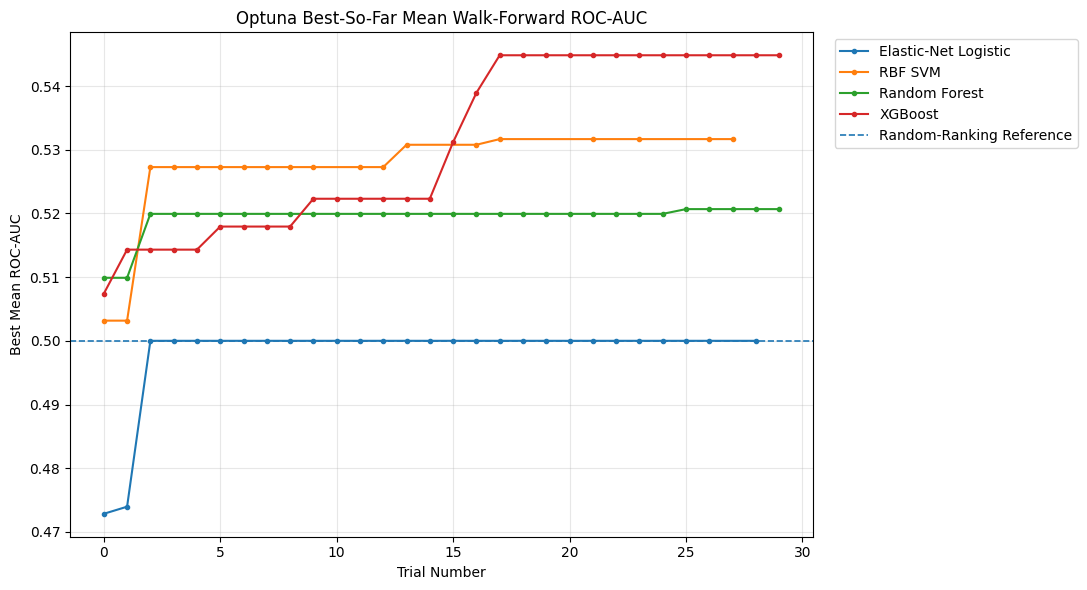

Figure saved to: /content/cqf_final_project/outputs/figures/optuna_model_convergence.png


In [80]:
# -------------------------------------------------------------------
# Plot best-so-far optimisation paths
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

for model_name, study in optuna_studies.items():
    completed_trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
        )
    ]

    trial_numbers = [
        trial.number
        for trial in completed_trials
    ]

    trial_values = np.asarray(
        [
            trial.value
            for trial in completed_trials
        ],
        dtype=float,
    )

    best_so_far = np.maximum.accumulate(
        trial_values
    )

    ax.plot(
        trial_numbers,
        best_so_far,
        marker="o",
        markersize=3,
        label=model_name,
    )

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1.2,
    label="Random-Ranking Reference",
)

ax.set_title(
    "Optuna Best-So-Far Mean Walk-Forward ROC-AUC"
)
ax.set_xlabel("Trial Number")
ax.set_ylabel("Best Mean ROC-AUC")
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.grid(alpha=0.3)

fig.tight_layout()

optuna_convergence_figure_path = (
    DIRECTORIES["figures"]
    / "optuna_model_convergence.png"
)

fig.savefig(
    optuna_convergence_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{optuna_convergence_figure_path}"
)

In [81]:
# -------------------------------------------------------------------
# Estimate classifier-specific Optuna parameter importance
# -------------------------------------------------------------------

optuna_importance_records = []

for model_name, study in optuna_studies.items():
    completed_trials = [
        trial
        for trial in study.trials
        if trial.state
        == optuna.trial.TrialState.COMPLETE
    ]

    if len(completed_trials) < 5:
        continue

    try:
        parameter_importance = (
            optuna.importance
            .get_param_importances(
                study
            )
        )

        for parameter_name, importance_value in (
            parameter_importance.items()
        ):
            optuna_importance_records.append(
                {
                    "Model": model_name,
                    "Parameter": parameter_name,
                    "Importance":
                        importance_value,
                }
            )

    except Exception as importance_error:
        print(
            f"Parameter importance could not be "
            f"calculated for {model_name}: "
            f"{importance_error}"
        )

optuna_parameter_importance = (
    pd.DataFrame(
        optuna_importance_records
    )
)

if not optuna_parameter_importance.empty:
    optuna_parameter_importance = (
        optuna_parameter_importance
        .sort_values(
            [
                "Model",
                "Importance",
            ],
            ascending=[
                True,
                False,
            ],
        )
    )

    display(
        optuna_parameter_importance
        .groupby("Model")
        .head(10)
    )

,Model,Parameter,Importance
0,Elastic-Net Logistic,C,0.366248
1,Elastic-Net Logistic,l1_ratio,0.301939
2,Elastic-Net Logistic,correlation_threshold,0.213801
3,Elastic-Net Logistic,tolerance,0.080003
4,Elastic-Net Logistic,class_weight,0.038008
5,RBF SVM,gamma,0.661966
6,RBF SVM,C,0.141468
7,RBF SVM,shrinking,0.109788
8,RBF SVM,tolerance,0.044245
9,RBF SVM,correlation_threshold,0.041153


Automated hyperparameter optimisation improves the development-stage ranking performance of all four model families, although the magnitude and stability of the improvement differ materially.

XGBoost produces the strongest optimised result. Its mean walk-forward ROC-AUC increases from 0.5143 to 0.5448, an absolute improvement of approximately 0.0306. The best trial records a fold-level standard deviation of 0.0392, with individual fold ROC-AUC values ranging from 0.5029 to 0.5964. The minimum fold performance remains slightly above the random-ranking benchmark, although the dispersion indicates some sensitivity to market regime.

The optimised RBF support-vector machine achieves a mean ROC-AUC of 0.5317, compared with approximately 0.5080 before optimisation. Its fold-level standard deviation is only 0.0194 and its minimum fold ROC-AUC is 0.5051. It therefore provides the most stable optimised nonlinear signal among the candidate model families.

Random forest improves from 0.5076 to 0.5207. However, its fold-level results range from 0.4756 to 0.5634. The model therefore captures useful nonlinear structure on average but remains sensitive to the composition of the validation period.

The optimal elastic-net logistic specification produces a mean ROC-AUC of exactly 0.5000. The selected model uses strong regularisation and effectively suppresses the unstable linear relationships that caused the untuned logistic model to underperform. This result suggests that the predictive structure is predominantly nonlinear rather than a stable linear combination of the candidate features.

The parameter-importance estimates are economically and statistically coherent. The RBF SVM is dominated by the kernel-width parameter, gamma, which controls the locality and curvature of the nonlinear decision boundary. Random-forest performance is most sensitive to tree depth and feature subsampling. XGBoost is primarily influenced by the minimum child weight, split-gain penalty, and number of boosting rounds, highlighting the importance of controlling tree complexity and weak-signal accumulation.

The optimal XGBoost trial selects 900 boosting rounds, which is the upper boundary of the pre-registered search interval. However, this choice is accompanied by a relatively large minimum child weight and positive split-gain penalty. The resulting specification combines a large number of weak sequential learners with explicit restrictions on unnecessary node expansion. The original search range is retained rather than expanded after observing the result, thereby avoiding repeated search-space modification in response to development performance.

The optimisation results remain development-stage estimates. Hyperparameters have been selected exclusively from the base-training sample using purged chronological validation. The blending and final-test periods have not influenced parameter selection.

In [82]:
# -------------------------------------------------------------------
# Archive Optuna studies and optimisation diagnostics
# -------------------------------------------------------------------

optuna_model_summary.to_csv(
    DIRECTORIES["tables"]
    / "optuna_model_summary.csv"
)

optuna_best_parameters.to_csv(
    DIRECTORIES["tables"]
    / "optuna_best_parameters.csv",
    index=False,
)

tuning_comparison.to_csv(
    DIRECTORIES["tables"]
    / "optuna_initial_vs_tuned_comparison.csv"
)

if not optuna_parameter_importance.empty:
    optuna_parameter_importance.to_csv(
        DIRECTORIES["tables"]
        / "optuna_parameter_importance.csv",
        index=False,
    )

for model_name, study in optuna_studies.items():
    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    study_trials_table = (
        study.trials_dataframe()
    )

    study_trials_table.to_csv(
        DIRECTORIES["tables"]
        / (
            f"optuna_trials_"
            f"{safe_model_name}.csv"
        ),
        index=False,
    )

    best_parameter_path = (
        DIRECTORIES["models"]
        / (
            f"optuna_best_parameters_"
            f"{safe_model_name}.json"
        )
    )

    with open(
        best_parameter_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            study.best_params,
            file,
            indent=4,
            ensure_ascii=False,
            default=str,
        )

print(
    "Optuna optimisation results archived successfully."
)

Optuna optimisation results archived successfully.


## 6.7 Reconstruction and Validation of the Optimised Models

The optimal hyperparameters are now used to reconstruct each model family.

The optimised models are evaluated again using the same five purged expanding-window folds. This second evaluation has three purposes:

1. to verify that the stored Optuna parameters can be reproduced outside the optimisation objective;
2. to generate complete out-of-fold probability forecasts for later ensemble analysis;
3. to compare the optimised probability quality, class behaviour, and fold-level stability with the original model specifications.

The support-vector machine requires an additional step. During Optuna optimisation, its continuous decision function was used because ROC-AUC depends only on ranking and does not require calibrated probabilities. For the reconstructed model, sigmoid probability calibration is performed using chronological inner folds within each outer training sample.

All preprocessing operations remain inside the model pipelines. Correlation filtering, scaling, classification, and probability calibration are therefore refitted independently within every outer training fold.

In [83]:
# -------------------------------------------------------------------
# Reconstruct the optimised model pipelines
# -------------------------------------------------------------------

def decode_class_weight(
    parameter_value,
):
    """Convert the stored Optuna class-weight label."""

    if parameter_value == "none":
        return None

    return parameter_value


def decode_max_depth(
    parameter_value,
):
    """Convert the categorical random-forest depth parameter."""

    if str(parameter_value).lower() == "none":
        return None

    return int(parameter_value)


def decode_max_features(
    parameter_value,
):
    """Convert the categorical random-forest feature parameter."""

    if parameter_value in {"sqrt", "log2"}:
        return parameter_value

    return float(parameter_value)


def build_optimised_model_set(
    studies: dict,
) -> dict:
    """Reconstruct all optimised model families."""

    # ---------------------------------------------------------------
    # Elastic-net logistic regression
    # ---------------------------------------------------------------

    logistic_parameters = (
        studies["Elastic-Net Logistic"].best_params
    )

    optimised_logistic_model = Pipeline(
        steps=[
            (
                "correlation_filter",
                CorrelationFilter(
                    threshold=float(
                        logistic_parameters[
                            "correlation_threshold"
                        ]
                    ),
                    method="pearson",
                ),
            ),
            (
                "scaler",
                RobustScaler(
                    quantile_range=(10.0, 90.0),
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    penalty="elasticnet",
                    solver="saga",
                    C=float(
                        logistic_parameters["C"]
                    ),
                    l1_ratio=float(
                        logistic_parameters[
                            "l1_ratio"
                        ]
                    ),
                    class_weight=decode_class_weight(
                        logistic_parameters[
                            "class_weight"
                        ]
                    ),
                    max_iter=8000,
                    tol=float(
                        logistic_parameters[
                            "tolerance"
                        ]
                    ),
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )

    # ---------------------------------------------------------------
    # Chronologically calibrated RBF SVM
    # ---------------------------------------------------------------

    svm_parameters = (
        studies["RBF SVM"].best_params
    )

    optimised_svm_base_pipeline = Pipeline(
        steps=[
            (
                "correlation_filter",
                CorrelationFilter(
                    threshold=float(
                        svm_parameters[
                            "correlation_threshold"
                        ]
                    ),
                    method="pearson",
                ),
            ),
            (
                "scaler",
                RobustScaler(
                    quantile_range=(10.0, 90.0),
                ),
            ),
            (
                "classifier",
                SVC(
                    kernel="rbf",
                    C=float(
                        svm_parameters["C"]
                    ),
                    gamma=float(
                        svm_parameters["gamma"]
                    ),
                    class_weight=decode_class_weight(
                        svm_parameters[
                            "class_weight"
                        ]
                    ),
                    shrinking=bool(
                        svm_parameters[
                            "shrinking"
                        ]
                    ),
                    tol=float(
                        svm_parameters[
                            "tolerance"
                        ]
                    ),
                    probability=False,
                    cache_size=2000,
                ),
            ),
        ]
    )

    optimised_svm_calibration_cv = TimeSeriesSplit(
        n_splits=3,
        gap=CV_GAP,
    )

    optimised_svm_model = CalibratedClassifierCV(
        estimator=optimised_svm_base_pipeline,
        method="sigmoid",
        cv=optimised_svm_calibration_cv,
        ensemble=True,
    )

    # ---------------------------------------------------------------
    # Random forest
    # ---------------------------------------------------------------

    random_forest_parameters = (
        studies["Random Forest"].best_params
    )

    optimised_random_forest_model = (
        RandomForestClassifier(
            n_estimators=int(
                random_forest_parameters[
                    "n_estimators"
                ]
            ),
            max_depth=decode_max_depth(
                random_forest_parameters[
                    "max_depth"
                ]
            ),
            min_samples_split=int(
                random_forest_parameters[
                    "min_samples_split"
                ]
            ),
            min_samples_leaf=int(
                random_forest_parameters[
                    "min_samples_leaf"
                ]
            ),
            max_features=decode_max_features(
                random_forest_parameters[
                    "max_features"
                ]
            ),
            max_samples=float(
                random_forest_parameters[
                    "max_samples"
                ]
            ),
            class_weight=decode_class_weight(
                random_forest_parameters[
                    "class_weight"
                ]
            ),
            bootstrap=True,
            n_jobs=-1,
            random_state=RANDOM_SEED,
        )
    )

    # ---------------------------------------------------------------
    # XGBoost
    # ---------------------------------------------------------------

    xgboost_parameters = (
        studies["XGBoost"].best_params
    )

    optimised_xgboost_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=int(
            xgboost_parameters[
                "n_estimators"
            ]
        ),
        learning_rate=float(
            xgboost_parameters[
                "learning_rate"
            ]
        ),
        max_depth=int(
            xgboost_parameters[
                "max_depth"
            ]
        ),
        min_child_weight=float(
            xgboost_parameters[
                "min_child_weight"
            ]
        ),
        subsample=float(
            xgboost_parameters[
                "subsample"
            ]
        ),
        colsample_bytree=float(
            xgboost_parameters[
                "colsample_bytree"
            ]
        ),
        gamma=float(
            xgboost_parameters[
                "gamma"
            ]
        ),
        reg_alpha=float(
            xgboost_parameters[
                "reg_alpha"
            ]
        ),
        reg_lambda=float(
            xgboost_parameters[
                "reg_lambda"
            ]
        ),
        scale_pos_weight=float(
            xgboost_parameters[
                "scale_pos_weight"
            ]
        ),
        tree_method="hist",
        n_jobs=-1,
        verbosity=0,
        random_state=RANDOM_SEED,
    )

    return {
        "Elastic-Net Logistic":
            optimised_logistic_model,
        "Calibrated RBF SVM":
            optimised_svm_model,
        "Random Forest":
            optimised_random_forest_model,
        "XGBoost":
            optimised_xgboost_model,
    }


optimised_models = build_optimised_model_set(
    optuna_studies
)

print("Optimised model families reconstructed:")

for model_name in optimised_models:
    print(f"- {model_name}")

Optimised model families reconstructed:
- Elastic-Net Logistic
- Calibrated RBF SVM
- Random Forest
- XGBoost


In [84]:
# -------------------------------------------------------------------
# Generate optimised walk-forward predictions
# -------------------------------------------------------------------

(
    optimised_fold_metrics,
    optimised_oof_predictions,
    optimised_pooled_metrics,
) = evaluate_models_walk_forward(
    models=optimised_models,
    X=X_base_model,
    y=y_base_model,
    splits=cv_splits,
    threshold=CONFIG[
        "baseline_classification_threshold"
    ],
)

Evaluating Elastic-Net Logistic...
  Fold 1: ROC-AUC=0.5000, Balanced Accuracy=0.5000
  Fold 2: ROC-AUC=0.5000, Balanced Accuracy=0.5000
  Fold 3: ROC-AUC=0.5000, Balanced Accuracy=0.5000
  Fold 4: ROC-AUC=0.5000, Balanced Accuracy=0.5000
  Fold 5: ROC-AUC=0.5000, Balanced Accuracy=0.5000
Evaluating Calibrated RBF SVM...
  Fold 1: ROC-AUC=0.5169, Balanced Accuracy=0.5140
  Fold 2: ROC-AUC=0.5226, Balanced Accuracy=0.5000
  Fold 3: ROC-AUC=0.5448, Balanced Accuracy=0.5000
  Fold 4: ROC-AUC=0.5064, Balanced Accuracy=0.5000
  Fold 5: ROC-AUC=0.5466, Balanced Accuracy=0.5000
Evaluating Random Forest...
  Fold 1: ROC-AUC=0.5634, Balanced Accuracy=0.5497
  Fold 2: ROC-AUC=0.5186, Balanced Accuracy=0.4988
  Fold 3: ROC-AUC=0.4756, Balanced Accuracy=0.4507
  Fold 4: ROC-AUC=0.5018, Balanced Accuracy=0.5225
  Fold 5: ROC-AUC=0.5440, Balanced Accuracy=0.5537
Evaluating XGBoost...
  Fold 1: ROC-AUC=0.5964, Balanced Accuracy=0.5694
  Fold 2: ROC-AUC=0.5029, Balanced Accuracy=0.5162
  Fold 3: ROC-A

In [85]:
# -------------------------------------------------------------------
# Summarise optimised fold-level performance
# -------------------------------------------------------------------

optimised_model_stability = (
    optimised_fold_metrics
    .groupby("Model")
    .agg(
        Mean_ROC_AUC=("ROC-AUC", "mean"),
        Std_ROC_AUC=("ROC-AUC", "std"),
        Minimum_ROC_AUC=("ROC-AUC", "min"),
        Maximum_ROC_AUC=("ROC-AUC", "max"),
        Mean_Balanced_Accuracy=(
            "Balanced Accuracy",
            "mean",
        ),
        Mean_Macro_F1=(
            "Macro F1",
            "mean",
        ),
        Mean_Brier_Score=(
            "Brier Score",
            "mean",
        ),
        Mean_Log_Loss=(
            "Log Loss",
            "mean",
        ),
        Mean_Predicted_Positive_Rate=(
            "Predicted Positive Rate",
            "mean",
        ),
    )
    .sort_values(
        "Mean_ROC_AUC",
        ascending=False,
    )
)

display(optimised_pooled_metrics)
display(optimised_model_stability)

,Observations,Positive Rate,Predicted Positive Rate,Accuracy,Balanced Accuracy,ROC-AUC,Average Precision,Macro F1,Positive Precision,Positive Recall,Matthews Correlation,Brier Score,Log Loss
Model,,,,,,,,,,,,,
XGBoost,"1,250.000000",0.571200,0.540000,0.540000,0.535014,0.534410,0.581532,0.534241,0.602963,0.570028,0.069537,0.285515,0.796326
Calibrated RBF SVM,"1,250.000000",0.571200,0.951200,0.565600,0.501377,0.520128,0.583678,0.402557,0.571909,0.952381,0.006326,0.245635,0.684396
Random Forest,"1,250.000000",0.571200,0.548800,0.516800,0.510055,0.511035,0.574130,0.509740,0.580175,0.557423,0.020000,0.252629,0.698669
Elastic-Net Logistic,"1,250.000000",0.571200,1.000000,0.571200,0.500000,0.496734,0.571876,0.363544,0.571200,1.000000,0.000000,0.245546,0.684219


,Mean_ROC_AUC,Std_ROC_AUC,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_Balanced_Accuracy,Mean_Macro_F1,Mean_Brier_Score,Mean_Log_Loss,Mean_Predicted_Positive_Rate
Model,,,,,,,,,
XGBoost,0.544832,0.039235,0.502889,0.596417,0.539015,0.529425,0.285515,0.796326,0.540000
Calibrated RBF SVM,0.527472,0.017640,0.506420,0.546601,0.502786,0.395741,0.245635,0.684396,0.951200
Random Forest,0.520676,0.034503,0.475596,0.563422,0.515073,0.496331,0.252629,0.698669,0.548800
Elastic-Net Logistic,0.500000,0.000000,0.500000,0.500000,0.500000,0.363417,0.245546,0.684219,1.000000


In [86]:
# -------------------------------------------------------------------
# Compare initial and optimised walk-forward results
# -------------------------------------------------------------------

optimisation_validation_records = []

for model_name in optimised_models:
    initial_result = (
        initial_model_stability.loc[
            model_name
        ]
    )

    optimised_result = (
        optimised_model_stability.loc[
            model_name
        ]
    )

    optimisation_validation_records.append(
        {
            "Model": model_name,

            "Initial Mean ROC-AUC":
                initial_result[
                    "Mean_ROC_AUC"
                ],

            "Optimised Mean ROC-AUC":
                optimised_result[
                    "Mean_ROC_AUC"
                ],

            "Mean ROC-AUC Improvement":
                optimised_result[
                    "Mean_ROC_AUC"
                ]
                - initial_result[
                    "Mean_ROC_AUC"
                ],

            "Initial ROC-AUC Std":
                initial_result[
                    "Std_ROC_AUC"
                ],

            "Optimised ROC-AUC Std":
                optimised_result[
                    "Std_ROC_AUC"
                ],

            "Initial Minimum ROC-AUC":
                initial_result[
                    "Minimum_ROC_AUC"
                ],

            "Optimised Minimum ROC-AUC":
                optimised_result[
                    "Minimum_ROC_AUC"
                ],

            "Initial Balanced Accuracy":
                initial_result[
                    "Mean_Balanced_Accuracy"
                ],

            "Optimised Balanced Accuracy":
                optimised_result[
                    "Mean_Balanced_Accuracy"
                ],

            "Initial Brier Score":
                initial_result[
                    "Mean_Brier_Score"
                ],

            "Optimised Brier Score":
                optimised_result[
                    "Mean_Brier_Score"
                ],

            "Initial Log Loss":
                initial_result[
                    "Mean_Log_Loss"
                ],

            "Optimised Log Loss":
                optimised_result[
                    "Mean_Log_Loss"
                ],
        }
    )

optimisation_validation_comparison = (
    pd.DataFrame(
        optimisation_validation_records
    )
    .set_index("Model")
    .sort_values(
        "Optimised Mean ROC-AUC",
        ascending=False,
    )
)

display(
    optimisation_validation_comparison
)

,Initial Mean ROC-AUC,Optimised Mean ROC-AUC,Mean ROC-AUC Improvement,Initial ROC-AUC Std,Optimised ROC-AUC Std,Initial Minimum ROC-AUC,Optimised Minimum ROC-AUC,Initial Balanced Accuracy,Optimised Balanced Accuracy,Initial Brier Score,Optimised Brier Score,Initial Log Loss,Optimised Log Loss
Model,,,,,,,,,,,,,
XGBoost,0.514258,0.544832,0.030575,0.056647,0.039235,0.461726,0.502889,0.510667,0.539015,0.269151,0.285515,0.737019,0.796326
Calibrated RBF SVM,0.508044,0.527472,0.019427,0.028597,0.017640,0.477776,0.506420,0.501870,0.502786,0.248150,0.245635,0.689449,0.684396
Random Forest,0.507649,0.520676,0.013027,0.036776,0.034503,0.477908,0.475596,0.508510,0.515073,0.255772,0.252629,0.705161,0.698669
Elastic-Net Logistic,0.475940,0.500000,0.024060,0.022293,0.000000,0.453903,0.500000,0.484032,0.500000,0.280590,0.245546,0.761382,0.684219


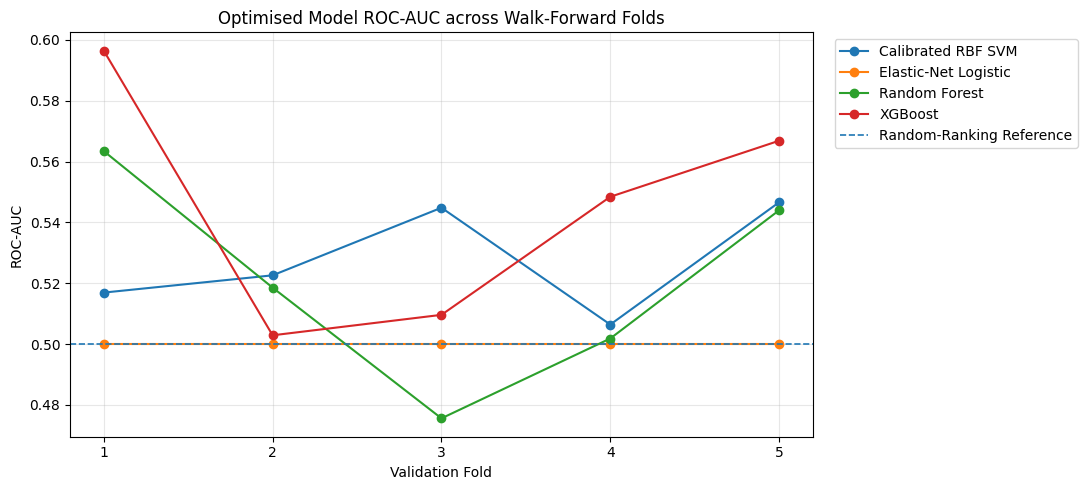

Figure saved to: /content/cqf_final_project/outputs/figures/optimised_model_fold_roc_auc.png


In [87]:
# -------------------------------------------------------------------
# Plot optimised fold-level ROC-AUC
# -------------------------------------------------------------------

optimised_fold_auc_table = (
    optimised_fold_metrics
    .pivot(
        index="Fold",
        columns="Model",
        values="ROC-AUC",
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 5))

for model_name in optimised_fold_auc_table.columns:
    ax.plot(
        optimised_fold_auc_table.index,
        optimised_fold_auc_table[
            model_name
        ],
        marker="o",
        label=model_name,
    )

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1.2,
    label="Random-Ranking Reference",
)

ax.set_title(
    "Optimised Model ROC-AUC across Walk-Forward Folds"
)

ax.set_xlabel("Validation Fold")
ax.set_ylabel("ROC-AUC")
ax.set_xticks(
    optimised_fold_auc_table.index
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.grid(alpha=0.3)

fig.tight_layout()

optimised_fold_auc_figure_path = (
    DIRECTORIES["figures"]
    / "optimised_model_fold_roc_auc.png"
)

fig.savefig(
    optimised_fold_auc_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{optimised_fold_auc_figure_path}"
)

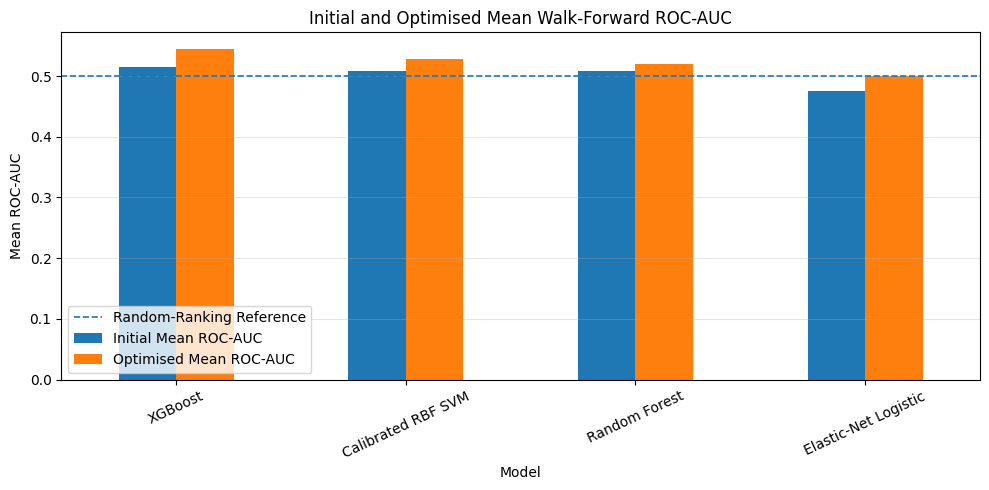

Figure saved to: /content/cqf_final_project/outputs/figures/initial_vs_optimised_mean_roc_auc.png


In [88]:
# -------------------------------------------------------------------
# Plot initial-versus-optimised mean ROC-AUC
# -------------------------------------------------------------------

mean_auc_comparison_plot_data = (
    optimisation_validation_comparison[
        [
            "Initial Mean ROC-AUC",
            "Optimised Mean ROC-AUC",
        ]
    ]
)

ax = mean_auc_comparison_plot_data.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1.2,
    label="Random-Ranking Reference",
)

ax.set_title(
    "Initial and Optimised Mean Walk-Forward ROC-AUC"
)

ax.set_xlabel("Model")
ax.set_ylabel("Mean ROC-AUC")
ax.tick_params(
    axis="x",
    rotation=25,
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.3,
)

fig = ax.get_figure()
fig.tight_layout()

optimisation_comparison_figure_path = (
    DIRECTORIES["figures"]
    / "initial_vs_optimised_mean_roc_auc.png"
)

fig.savefig(
    optimisation_comparison_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{optimisation_comparison_figure_path}"
)

## 6.8 Optimised Probability Behaviour and Model Diversity

Hyperparameter optimisation changes not only the ranking accuracy of the models but also the dispersion and calibration of their probability forecasts.

Probability behaviour is therefore examined before constructing the ensemble. A model with a relatively strong ROC-AUC may still produce excessively concentrated, extreme, or systematically biased probabilities.

Ensemble performance also depends on diversity. Highly correlated base models provide limited incremental information, whereas models with different functional forms may identify distinct market patterns. However, diversity alone is not sufficient: a model must also contribute at least some predictive or calibration value.

The optimised out-of-fold probabilities are used to measure pairwise Spearman correlation and classification disagreement. These diagnostics will guide the subsequent comparison between simple voting, weighted voting, and blending.

In [89]:
# -------------------------------------------------------------------
# Summarise optimised out-of-fold probability behaviour
# -------------------------------------------------------------------

optimised_probability_summary = (
    optimised_oof_predictions
    .groupby("Model")
    .agg(
        Observations=(
            "Probability",
            "size",
        ),
        Mean_Probability=(
            "Probability",
            "mean",
        ),
        Probability_Standard_Deviation=(
            "Probability",
            "std",
        ),
        Minimum_Probability=(
            "Probability",
            "min",
        ),
        Probability_05_Percentile=(
            "Probability",
            lambda values:
                values.quantile(0.05),
        ),
        Median_Probability=(
            "Probability",
            "median",
        ),
        Probability_95_Percentile=(
            "Probability",
            lambda values:
                values.quantile(0.95),
        ),
        Maximum_Probability=(
            "Probability",
            "max",
        ),
        Predicted_Positive_Rate=(
            "Prediction",
            "mean",
        ),
    )
    .sort_values(
        "Mean_Probability",
        ascending=False,
    )
)

display(
    optimised_probability_summary
)

,Observations,Mean_Probability,Probability_Standard_Deviation,Minimum_Probability,Probability_05_Percentile,Median_Probability,Probability_95_Percentile,Maximum_Probability,Predicted_Positive_Rate
Model,,,,,,,,,
Elastic-Net Logistic,1250,0.548517,0.005509,0.539362,0.539362,0.550562,0.555365,0.555365,1.000000
Calibrated RBF SVM,1250,0.538204,0.020333,0.446903,0.500288,0.541557,0.565035,0.600625,0.951200
XGBoost,1250,0.523279,0.226755,0.029325,0.162678,0.527990,0.880845,0.973785,0.540000
Random Forest,1250,0.512379,0.075569,0.277649,0.390184,0.510577,0.635547,0.745323,0.548800


In [90]:
# -------------------------------------------------------------------
# Construct aligned optimised OOF prediction matrices
# -------------------------------------------------------------------

optimised_probability_wide = (
    optimised_oof_predictions
    .pivot(
        index="Date",
        columns="Model",
        values="Probability",
    )
    .sort_index()
)

optimised_prediction_wide = (
    optimised_oof_predictions
    .pivot(
        index="Date",
        columns="Model",
        values="Prediction",
    )
    .sort_index()
)

assert (
    optimised_probability_wide
    .notna()
    .all()
    .all()
)

assert (
    optimised_prediction_wide
    .notna()
    .all()
    .all()
)

optimised_model_probability_correlation = (
    optimised_probability_wide
    .corr(method="spearman")
)

optimised_prediction_disagreement = pd.DataFrame(
    index=optimised_models.keys(),
    columns=optimised_models.keys(),
    dtype=float,
)

for model_a in optimised_models:
    for model_b in optimised_models:
        optimised_prediction_disagreement.loc[
            model_a,
            model_b,
        ] = (
            optimised_prediction_wide[model_a]
            != optimised_prediction_wide[model_b]
        ).mean()

display(
    optimised_model_probability_correlation
)

display(
    optimised_prediction_disagreement
)

Model,Calibrated RBF SVM,Elastic-Net Logistic,Random Forest,XGBoost
Model,,,,
Calibrated RBF SVM,1.000000,0.444389,0.492897,0.283947
Elastic-Net Logistic,0.444389,1.000000,0.240632,-0.014579
Random Forest,0.492897,0.240632,1.000000,0.682806
XGBoost,0.283947,-0.014579,0.682806,1.000000


,Elastic-Net Logistic,Calibrated RBF SVM,Random Forest,XGBoost
Elastic-Net Logistic,0.000000,0.048800,0.451200,0.460000
Calibrated RBF SVM,0.048800,0.000000,0.408800,0.430400
Random Forest,0.451200,0.408800,0.000000,0.256800
XGBoost,0.460000,0.430400,0.256800,0.000000


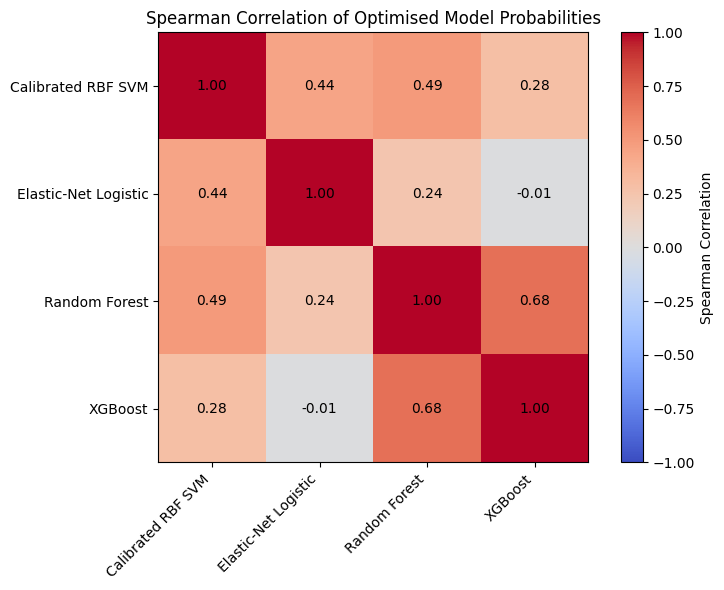

Figure saved to: /content/cqf_final_project/outputs/figures/optimised_model_probability_correlation.png


In [91]:
# -------------------------------------------------------------------
# Plot optimised model probability correlation
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

optimised_correlation_image = ax.imshow(
    optimised_model_probability_correlation,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

ax.set_xticks(
    range(
        len(
            optimised_model_probability_correlation
            .columns
        )
    )
)

ax.set_xticklabels(
    optimised_model_probability_correlation
    .columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    range(
        len(
            optimised_model_probability_correlation
            .index
        )
    )
)

ax.set_yticklabels(
    optimised_model_probability_correlation
    .index
)

for row_index in range(
    optimised_model_probability_correlation.shape[0]
):
    for column_index in range(
        optimised_model_probability_correlation.shape[1]
    ):
        ax.text(
            column_index,
            row_index,
            (
                f"{optimised_model_probability_correlation.iloc[
                    row_index,
                    column_index
                ]:.2f}"
            ),
            ha="center",
            va="center",
        )

ax.set_title(
    "Spearman Correlation of Optimised Model Probabilities"
)

fig.colorbar(
    optimised_correlation_image,
    ax=ax,
    label="Spearman Correlation",
)

fig.tight_layout()

optimised_probability_correlation_path = (
    DIRECTORIES["figures"]
    / "optimised_model_probability_correlation.png"
)

fig.savefig(
    optimised_probability_correlation_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{optimised_probability_correlation_path}"
)

In [92]:
# -------------------------------------------------------------------
# Archive reconstructed optimised-model results
# -------------------------------------------------------------------

optimised_fold_metrics.to_csv(
    DIRECTORIES["tables"]
    / "optimised_model_fold_metrics.csv",
    index=False,
)

optimised_oof_predictions.to_csv(
    DIRECTORIES["tables"]
    / "optimised_model_oof_predictions.csv",
    index=False,
)

optimised_pooled_metrics.to_csv(
    DIRECTORIES["tables"]
    / "optimised_model_pooled_metrics.csv"
)

optimised_model_stability.to_csv(
    DIRECTORIES["tables"]
    / "optimised_model_stability_summary.csv"
)

optimisation_validation_comparison.to_csv(
    DIRECTORIES["tables"]
    / "initial_vs_optimised_validation_comparison.csv"
)

optimised_probability_summary.to_csv(
    DIRECTORIES["tables"]
    / "optimised_model_probability_summary.csv"
)

optimised_model_probability_correlation.to_csv(
    DIRECTORIES["tables"]
    / "optimised_model_probability_correlation.csv"
)

optimised_prediction_disagreement.to_csv(
    DIRECTORIES["tables"]
    / "optimised_model_prediction_disagreement.csv"
)

optimised_fold_auc_table.to_csv(
    DIRECTORIES["tables"]
    / "optimised_model_fold_auc_table.csv"
)

print(
    "Optimised model validation and diversity "
    "outputs archived successfully."
)

Optimised model validation and diversity outputs archived successfully.


### Optimised Probability and Diversity Results

Hyperparameter optimisation improves ranking performance more clearly than probability calibration.

XGBoost produces the highest mean fold-level ROC-AUC of 0.5448 and the highest mean balanced accuracy of 0.5390. However, its out-of-fold probabilities are considerably more dispersed than those of the other models. The probability standard deviation is approximately 0.227, while the fifth and ninety-fifth percentiles are approximately 0.163 and 0.881. Its Brier score and logarithmic loss also deteriorate relative to the initial specification. XGBoost therefore provides the strongest ranking signal but also the most aggressive and least calibrated probability estimates.

The calibrated RBF SVM achieves a lower mean ROC-AUC of 0.5275 but is substantially more stable across time. Its fold-level ROC-AUC standard deviation is only 0.0176, and all five validation folds remain above the random-ranking benchmark. Nevertheless, its probabilities are compressed into a narrow range, with a standard deviation of approximately 0.020. At the default threshold of 0.50, it predicts the positive class for approximately 95.1% of the out-of-fold observations. The model contains ranking information, but the raw 0.50 classification threshold is unsuitable for its current probability distribution.

Random forest occupies an intermediate position. Its mean ROC-AUC is 0.5207, and its probability dispersion is less extreme than that of XGBoost. However, one validation fold falls below 0.50, indicating some remaining regime sensitivity.

The strongly regularised elastic-net logistic model produces probabilities close to the unconditional positive-class frequency. Its probability standard deviation is approximately 0.006, and every observation is classified as positive at the 0.50 threshold. The model therefore provides almost no independent directional ranking signal after optimisation.

The probability-correlation matrix nevertheless confirms meaningful diversity among the nonlinear learners. Random forest and XGBoost have a Spearman correlation of approximately 0.68, whereas the correlations of XGBoost with the calibrated SVM and logistic model are approximately 0.28 and -0.01. Classification disagreements are also material.

All four models are initially retained in the meta-feature matrix so that the meta-model can determine whether the near-constant linear benchmark has incremental value. A three-model specification excluding elastic-net logistic regression will subsequently be evaluated as a robustness comparison.

# 7 Blending Ensemble Construction


## 7.1 Holdout Blending Design and Meta-Feature Generation

A chronological single-holdout blending design is used.

Each optimised base learner is fitted on the complete base-training sample from 2014 to 2021. The fitted models are then applied without modification to the separate blending sample from 2022 to 2023.

For each blending observation at date t, the meta-feature vector is:

$$
z_t =
[
p_t^{Logistic},
p_t^{SVM},
p_t^{RF},
p_t^{XGB}
].
$$

Each component is the estimated probability of a positive next-day SPY return produced by one base learner.

The resulting blending matrix contains 501 observations and four probability features. Because the blending observations were not used to estimate the base learners, these probabilities are out-of-sample with respect to the first-stage models.

The blending labels may subsequently be used to estimate and compare second-stage ensemble rules. The candidate ensemble specifications will include:

1. an equal-weight soft-voting benchmark;
2. a performance-weighted probability average;
3. a regularised logistic meta-model;
4. a three-model robustness specification that excludes the near-constant elastic-net base learner.

The final-test sample remains locked. Neither its labels nor its performance statistics are used during meta-feature generation, ensemble selection, threshold selection, or meta-model estimation.

For the primary single-holdout implementation, the base learners used to generate the blending probabilities are retained for the later final-test prediction. They are not refitted on the blending observations before final evaluation. This preserves consistency between the probability-generating process used to train the meta-model and the one used during final testing.

In [93]:
# -------------------------------------------------------------------
# Prepare the independent blending sample
# -------------------------------------------------------------------

blending_mask = (
    model_data["Sample"] == "Blending"
)

X_blend_model = feature_matrix.loc[
    blending_mask,
    X_base_model.columns,
].copy()

y_blend_model = model_data.loc[
    blending_mask,
    "Target",
].astype("int64").copy()

assert X_blend_model.index.equals(
    y_blend_model.index
)

assert list(X_blend_model.columns) == list(
    X_base_model.columns
)

assert X_blend_model.notna().all().all()

assert np.isfinite(
    X_blend_model.to_numpy()
).all()

assert (
    X_base_model.index.max()
    < X_blend_model.index.min()
)

blending_sample_summary = pd.Series(
    {
        "Base-training observations":
            len(X_base_model),

        "Blending observations":
            len(X_blend_model),

        "Number of input features":
            X_blend_model.shape[1],

        "Base-training end date":
            X_base_model.index.max(),

        "Blending start date":
            X_blend_model.index.min(),

        "Blending end date":
            X_blend_model.index.max(),

        "Blending positive-class rate":
            y_blend_model.mean(),

        "Final-test labels accessed":
            False,
    },
    name="Blending Sample Design",
)

display(blending_sample_summary)

,Blending Sample Design
Base-training observations,2015
Blending observations,501
Number of input features,64
Base-training end date,2021-12-31 00:00:00
Blending start date,2022-01-03 00:00:00
Blending end date,2023-12-29 00:00:00
Blending positive-class rate,0.495010
Final-test labels accessed,False


In [94]:
# -------------------------------------------------------------------
# Fit optimised base learners on the complete base-training sample
# and generate out-of-sample blending probabilities
# -------------------------------------------------------------------

fitted_blending_base_models = {}

blending_prediction_records = []
blending_metric_records = []

for model_name, estimator in optimised_models.items():

    print(
        f"Fitting {model_name} on the complete "
        "base-training sample..."
    )

    fitting_start_time = time.perf_counter()

    fitted_estimator = clone(estimator)

    fitted_estimator.fit(
        X_base_model,
        y_base_model,
    )

    fitting_runtime_seconds = (
        time.perf_counter()
        - fitting_start_time
    )

    blending_probability = (
        get_positive_class_probability(
            fitted_estimator,
            X_blend_model,
        )
    )

    assert len(blending_probability) == len(
        X_blend_model
    )

    assert np.isfinite(
        blending_probability
    ).all()

    assert (
        (blending_probability >= 0.0)
        & (blending_probability <= 1.0)
    ).all()

    blending_metrics = (
        calculate_classification_metrics(
            y_true=y_blend_model,
            predicted_probability=
                blending_probability,
            threshold=CONFIG[
                "baseline_classification_threshold"
            ],
        )
    )

    metric_record = {
        "Model": model_name,
        "Base-Model Fit Runtime Seconds":
            fitting_runtime_seconds,
    }

    metric_record.update(
        blending_metrics.to_dict()
    )

    blending_metric_records.append(
        metric_record
    )

    model_prediction_table = pd.DataFrame(
        {
            "Date": X_blend_model.index,
            "Model": model_name,
            "Actual":
                y_blend_model.to_numpy(),
            "Probability":
                blending_probability,
            "Prediction":
                (
                    blending_probability
                    >= CONFIG[
                        "baseline_classification_threshold"
                    ]
                ).astype(int),
        }
    )

    blending_prediction_records.append(
        model_prediction_table
    )

    fitted_blending_base_models[
        model_name
    ] = fitted_estimator

    print(
        f"  ROC-AUC="
        f"{blending_metrics['ROC-AUC']:.4f}; "
        f"Balanced Accuracy="
        f"{blending_metrics['Balanced Accuracy']:.4f}; "
        f"Brier Score="
        f"{blending_metrics['Brier Score']:.4f}"
    )


blending_base_predictions = pd.concat(
    blending_prediction_records,
    ignore_index=True,
)

blending_base_model_metrics = (
    pd.DataFrame(
        blending_metric_records
    )
    .set_index("Model")
    .sort_values(
        "ROC-AUC",
        ascending=False,
    )
)

display(blending_base_model_metrics)

Fitting Elastic-Net Logistic on the complete base-training sample...
  ROC-AUC=0.5000; Balanced Accuracy=0.5000; Brier Score=0.2541
Fitting Calibrated RBF SVM on the complete base-training sample...
  ROC-AUC=0.5036; Balanced Accuracy=0.5020; Brier Score=0.2554
Fitting Random Forest on the complete base-training sample...
  ROC-AUC=0.5017; Balanced Accuracy=0.4863; Brier Score=0.2582
Fitting XGBoost on the complete base-training sample...
  ROC-AUC=0.5459; Balanced Accuracy=0.5179; Brier Score=0.3058


,Base-Model Fit Runtime Seconds,Observations,Positive Rate,Predicted Positive Rate,Accuracy,Balanced Accuracy,ROC-AUC,Average Precision,Macro F1,Positive Precision,Positive Recall,Matthews Correlation,Brier Score,Log Loss
Model,,,,,,,,,,,,,,
XGBoost,7.245098,501.000000,0.495010,0.796407,0.514970,0.517930,0.545853,0.544290,0.469957,0.506266,0.814516,0.044526,0.305751,0.858500
Calibrated RBF SVM,2.356039,501.000000,0.495010,0.998004,0.497006,0.501976,0.503554,0.506138,0.335488,0.496000,1.000000,0.044277,0.255389,0.704056
Random Forest,39.419143,501.000000,0.495010,0.832335,0.483034,0.486349,0.501673,0.509475,0.420990,0.486811,0.818548,-0.036540,0.258173,0.709978
Elastic-Net Logistic,0.452868,501.000000,0.495010,1.000000,0.495010,0.500000,0.500000,0.495010,0.331108,0.495010,1.000000,0.000000,0.254131,0.701466


In [95]:
# -------------------------------------------------------------------
# Construct the blending meta-feature matrix
# -------------------------------------------------------------------

META_FEATURE_NAME_MAP = {
    "Elastic-Net Logistic":
        "P_Logistic",

    "Calibrated RBF SVM":
        "P_SVM",

    "Random Forest":
        "P_RF",

    "XGBoost":
        "P_XGB",
}

blend_probability_wide = (
    blending_base_predictions
    .pivot(
        index="Date",
        columns="Model",
        values="Probability",
    )
    .sort_index()
)

blend_meta_features = (
    blend_probability_wide
    .rename(
        columns=META_FEATURE_NAME_MAP
    )
    .reindex(
        index=X_blend_model.index,
        columns=list(
            META_FEATURE_NAME_MAP.values()
        ),
    )
)

blend_meta_target = (
    y_blend_model
    .rename("Target")
    .copy()
)

blend_meta_dataset = (
    blend_meta_features
    .join(
        blend_meta_target,
        how="inner",
    )
)

assert blend_meta_features.shape == (
    len(X_blend_model),
    len(META_FEATURE_NAME_MAP),
)

assert blend_meta_features.index.equals(
    blend_meta_target.index
)

assert blend_meta_features.notna().all().all()

assert np.isfinite(
    blend_meta_features.to_numpy()
).all()

display(blend_meta_dataset.head())

blend_meta_feature_summary = (
    blend_meta_features
    .agg(
        [
            "mean",
            "std",
            "min",
            "median",
            "max",
        ]
    )
    .T
)

display(blend_meta_feature_summary)

print(
    "Blending meta-feature matrix shape: "
    f"{blend_meta_features.shape}"
)

,P_Logistic,P_SVM,P_RF,P_XGB,Target
Date,,,,,
2022-01-03,0.559478,0.583986,0.488952,0.312955,0
2022-01-04,0.559478,0.573917,0.512730,0.426348,0
2022-01-05,0.559478,0.557939,0.516724,0.555605,0
2022-01-06,0.559478,0.541985,0.588185,0.707272,0
2022-01-07,0.559478,0.552186,0.585581,0.655310,0


,mean,std,min,median,max
Model,,,,,
P_Logistic,0.559478,0.000000,0.559478,0.559478,0.559478
P_SVM,0.566374,0.021993,0.489629,0.569755,0.629316
P_RF,0.561158,0.059756,0.376650,0.562710,0.737304
P_XGB,0.666245,0.199271,0.088869,0.701690,0.982708


Blending meta-feature matrix shape: (501, 4)


In [96]:
# -------------------------------------------------------------------
# Compare base-training OOF and blending-sample performance
# -------------------------------------------------------------------

blending_transfer_records = []

for model_name in optimised_models:

    base_oof_result = (
        optimised_model_stability.loc[
            model_name
        ]
    )

    blending_result = (
        blending_base_model_metrics.loc[
            model_name
        ]
    )

    blending_transfer_records.append(
        {
            "Model": model_name,

            "Base OOF Mean ROC-AUC":
                base_oof_result[
                    "Mean_ROC_AUC"
                ],

            "Blending ROC-AUC":
                blending_result[
                    "ROC-AUC"
                ],

            "ROC-AUC Change":
                blending_result[
                    "ROC-AUC"
                ]
                - base_oof_result[
                    "Mean_ROC_AUC"
                ],

            "Base OOF Balanced Accuracy":
                base_oof_result[
                    "Mean_Balanced_Accuracy"
                ],

            "Blending Balanced Accuracy":
                blending_result[
                    "Balanced Accuracy"
                ],

            "Base OOF Brier Score":
                base_oof_result[
                    "Mean_Brier_Score"
                ],

            "Blending Brier Score":
                blending_result[
                    "Brier Score"
                ],

            "Base OOF Log Loss":
                base_oof_result[
                    "Mean_Log_Loss"
                ],

            "Blending Log Loss":
                blending_result[
                    "Log Loss"
                ],

            "Base OOF Predicted Positive Rate":
                base_oof_result[
                    "Mean_Predicted_Positive_Rate"
                ],

            "Blending Predicted Positive Rate":
                blending_result[
                    "Predicted Positive Rate"
                ],
        }
    )

blending_transfer_comparison = (
    pd.DataFrame(
        blending_transfer_records
    )
    .set_index("Model")
    .sort_values(
        "Blending ROC-AUC",
        ascending=False,
    )
)

display(blending_transfer_comparison)

,Base OOF Mean ROC-AUC,Blending ROC-AUC,ROC-AUC Change,Base OOF Balanced Accuracy,Blending Balanced Accuracy,Base OOF Brier Score,Blending Brier Score,Base OOF Log Loss,Blending Log Loss,Base OOF Predicted Positive Rate,Blending Predicted Positive Rate
Model,,,,,,,,,,,
XGBoost,0.544832,0.545853,0.001021,0.539015,0.517930,0.285515,0.305751,0.796326,0.858500,0.540000,0.796407
Calibrated RBF SVM,0.527472,0.503554,-0.023917,0.502786,0.501976,0.245635,0.255389,0.684396,0.704056,0.951200,0.998004
Random Forest,0.520676,0.501673,-0.019003,0.515073,0.486349,0.252629,0.258173,0.698669,0.709978,0.548800,0.832335
Elastic-Net Logistic,0.500000,0.500000,0.000000,0.500000,0.500000,0.245546,0.254131,0.684219,0.701466,1.000000,1.000000


In [97]:
# -------------------------------------------------------------------
# Diagnose probability diversity within the blending sample
# -------------------------------------------------------------------

blending_probability_correlation = (
    blend_meta_features
    .corr(method="spearman")
)

blending_prediction_wide = (
    blending_base_predictions
    .pivot(
        index="Date",
        columns="Model",
        values="Prediction",
    )
    .sort_index()
)

blending_prediction_disagreement = pd.DataFrame(
    index=optimised_models.keys(),
    columns=optimised_models.keys(),
    dtype=float,
)

for model_a in optimised_models:
    for model_b in optimised_models:

        blending_prediction_disagreement.loc[
            model_a,
            model_b,
        ] = (
            blending_prediction_wide[
                model_a
            ]
            != blending_prediction_wide[
                model_b
            ]
        ).mean()

display(blending_probability_correlation)

display(blending_prediction_disagreement)

Model,P_Logistic,P_SVM,P_RF,P_XGB
Model,,,,
P_Logistic,NaN,NaN,NaN,NaN
P_SVM,NaN,1.000000,0.518005,0.271105
P_RF,NaN,0.518005,1.000000,0.693484
P_XGB,NaN,0.271105,0.693484,1.000000


,Elastic-Net Logistic,Calibrated RBF SVM,Random Forest,XGBoost
Elastic-Net Logistic,0.000000,0.001996,0.167665,0.203593
Calibrated RBF SVM,0.001996,0.000000,0.169661,0.205589
Random Forest,0.167665,0.169661,0.000000,0.151697
XGBoost,0.203593,0.205589,0.151697,0.000000


In [98]:
# -------------------------------------------------------------------
# Archive blending meta-features and base-model diagnostics
# -------------------------------------------------------------------

blending_sample_summary.to_csv(
    DIRECTORIES["tables"]
    / "blending_sample_design.csv",
    header=True,
)

blending_base_predictions.to_csv(
    DIRECTORIES["tables"]
    / "blending_base_model_predictions.csv",
    index=False,
)

blending_base_model_metrics.to_csv(
    DIRECTORIES["tables"]
    / "blending_base_model_metrics.csv",
)

blend_meta_dataset.to_csv(
    DIRECTORIES["data_processed"]
    / "SPY_blending_meta_feature_dataset.csv",
)

blend_meta_feature_summary.to_csv(
    DIRECTORIES["tables"]
    / "blending_meta_feature_summary.csv",
)

blending_transfer_comparison.to_csv(
    DIRECTORIES["tables"]
    / "base_oof_vs_blending_performance.csv",
)

blending_probability_correlation.to_csv(
    DIRECTORIES["tables"]
    / "blending_probability_correlation.csv",
)

blending_prediction_disagreement.to_csv(
    DIRECTORIES["tables"]
    / "blending_prediction_disagreement.csv",
)

print(
    "Blending meta-features and first-stage "
    "diagnostics archived successfully."
)

Blending meta-features and first-stage diagnostics archived successfully.


## 7.2 First-Stage Transfer Results

The independent blending sample reveals substantial differences in the temporal transferability of the optimised base learners.

XGBoost is the only model whose ranking performance transfers almost unchanged from the base-training validation folds to the 2022–2023 blending period. Its mean base-training ROC-AUC of 0.5448 is followed by a blending-sample ROC-AUC of 0.5459. This provides evidence that the boosted-tree model captures a weak but persistent nonlinear ranking signal. However, its probabilities remain aggressive: approximately 79.6% of blending observations are classified as positive at the default threshold, and both the Brier score and logarithmic loss are relatively high.

The calibrated RBF SVM deteriorates from a mean base-training ROC-AUC of 0.5275 to approximately 0.5036 in the blending sample. Its predicted probabilities remain narrowly concentrated above 0.50, causing almost every observation to be classified as positive. The model therefore contributes little standalone classification value in the later regime, although its probability ranking remains sufficiently different from that of XGBoost to justify testing it within an ensemble.

Random forest also loses most of its development-stage ranking performance. Its blending ROC-AUC is approximately 0.5017, compared with 0.5207 in the base-training folds. Its probabilities are less extreme than those of XGBoost but still produce a positive classification rate above 83%.

The elastic-net logistic model generates a constant blending probability of approximately 0.5595. Its ROC-AUC is therefore exactly 0.50 and its probability variance is zero. The undefined correlations involving this feature are a direct mathematical consequence of zero variance rather than a computational error.

Among the non-constant probability features, the blending-sample Spearman correlations are approximately 0.27 between the SVM and XGBoost, 0.52 between the SVM and random forest, and 0.69 between random forest and XGBoost. The base learners therefore retain meaningful probability diversity even though only XGBoost preserves material standalone ranking power.

The following ensemble comparison uses chronological meta-level validation. Fixed voting rules are constructed without reference to blending labels, while logistic blending models are trained and evaluated through expanding-window splits. All candidate ensembles are compared on the common set of meta-level out-of-fold observations.

## 7.3 Chronological Meta-Level Validation

The blending sample is used to compare several ensemble constructions while preserving temporal order.

Five expanding-window meta-level folds are created with a one-observation gap between each training and validation segment. The early part of the blending sample is used to estimate each logistic meta-model, and predictions are generated only for later observations.

The candidate set contains:

1. the standalone XGBoost base learner;
2. four-model equal-weight soft voting;
3. three-model equal-weight soft voting excluding the constant logistic feature;
4. three-model development-skill-weighted soft voting;
5. a four-feature logistic blending model;
6. a three-feature logistic blending model.

The development-skill weights are determined exclusively from the base-training walk-forward results. For model i, the unnormalised score is defined as:

$$
s_i =
\frac{\max(\overline{AUC}_i - 0.5,0)}
{\max(\sigma_{AUC,i},0.01)}.
$$

The normalised voting weight is:

$$
w_i =
\frac{s_i}{\sum_j s_j}.
$$

This weighting rule rewards ranking performance above chance while penalising fold instability. Blending labels are not used to determine these fixed voting weights.

The logistic meta-models use L2 regularisation and robust scaling. Their out-of-fold probabilities are generated through the chronological meta-level folds and are not in-sample fitted probabilities.

In [99]:
# -------------------------------------------------------------------
# Construct chronological meta-level validation folds
# -------------------------------------------------------------------

META_CV_SPLITS = 5
META_CV_GAP = 1

meta_time_series_cv = TimeSeriesSplit(
    n_splits=META_CV_SPLITS,
    gap=META_CV_GAP,
)

meta_cv_splits = list(
    meta_time_series_cv.split(
        blend_meta_features
    )
)

meta_fold_assignment = pd.Series(
    np.nan,
    index=blend_meta_features.index,
    name="Meta_Fold",
)

meta_fold_records = []

for fold_number, (
    meta_train_positions,
    meta_validation_positions,
) in enumerate(
    meta_cv_splits,
    start=1,
):

    meta_train_index = (
        blend_meta_features.index[
            meta_train_positions
        ]
    )

    meta_validation_index = (
        blend_meta_features.index[
            meta_validation_positions
        ]
    )

    meta_fold_assignment.loc[
        meta_validation_index
    ] = fold_number

    meta_fold_records.append(
        {
            "Fold": fold_number,

            "Training Start":
                meta_train_index.min(),

            "Training End":
                meta_train_index.max(),

            "Validation Start":
                meta_validation_index.min(),

            "Validation End":
                meta_validation_index.max(),

            "Training Observations":
                len(meta_train_index),

            "Validation Observations":
                len(meta_validation_index),

            "Gap":
                META_CV_GAP,
        }
    )

meta_fold_structure = pd.DataFrame(
    meta_fold_records
).set_index("Fold")

display(meta_fold_structure)

print(
    "Meta-level OOF observations: "
    f"{meta_fold_assignment.notna().sum()}"
)

,Training Start,Training End,Validation Start,Validation End,Training Observations,Validation Observations,Gap
Fold,,,,,,,
1,2022-01-03,2022-05-04,2022-05-06,2022-09-02,85,83,1
2,2022-01-03,2022-09-01,2022-09-06,2023-01-03,168,83,1
3,2022-01-03,2022-12-30,2023-01-04,2023-05-03,251,83,1
4,2022-01-03,2023-05-02,2023-05-04,2023-08-31,334,83,1
5,2022-01-03,2023-08-30,2023-09-01,2023-12-29,417,83,1


Meta-level OOF observations: 415


In [100]:
# -------------------------------------------------------------------
# Construct stability-adjusted development-skill weights
# -------------------------------------------------------------------

THREE_MODEL_TO_META_FEATURE = {
    "Calibrated RBF SVM": "P_SVM",
    "Random Forest": "P_RF",
    "XGBoost": "P_XGB",
}

skill_weight_records = []

for (
    base_model_name,
    meta_feature_name,
) in THREE_MODEL_TO_META_FEATURE.items():

    mean_auc = float(
        optimised_model_stability.loc[
            base_model_name,
            "Mean_ROC_AUC",
        ]
    )

    auc_standard_deviation = float(
        optimised_model_stability.loc[
            base_model_name,
            "Std_ROC_AUC",
        ]
    )

    excess_auc = max(
        mean_auc - 0.50,
        0.0,
    )

    stability_denominator = max(
        auc_standard_deviation,
        0.01,
    )

    skill_score = (
        excess_auc
        / stability_denominator
    )

    skill_weight_records.append(
        {
            "Base Model":
                base_model_name,

            "Meta Feature":
                meta_feature_name,

            "Mean Base OOF ROC-AUC":
                mean_auc,

            "Base OOF ROC-AUC Std":
                auc_standard_deviation,

            "Excess ROC-AUC":
                excess_auc,

            "Unnormalised Skill Score":
                skill_score,
        }
    )

development_skill_weights = pd.DataFrame(
    skill_weight_records
).set_index("Meta Feature")

skill_score_sum = (
    development_skill_weights[
        "Unnormalised Skill Score"
    ].sum()
)

assert skill_score_sum > 0.0

development_skill_weights[
    "Normalised Weight"
] = (
    development_skill_weights[
        "Unnormalised Skill Score"
    ]
    / skill_score_sum
)

display(development_skill_weights)

,Base Model,Mean Base OOF ROC-AUC,Base OOF ROC-AUC Std,Excess ROC-AUC,Unnormalised Skill Score,Normalised Weight
Meta Feature,,,,,,
P_SVM,Calibrated RBF SVM,0.527472,0.017640,0.027472,1.557308,0.472023
P_RF,Random Forest,0.520676,0.034503,0.020676,0.599262,0.181637
P_XGB,XGBoost,0.544832,0.039235,0.044832,1.142651,0.346340


In [101]:
# -------------------------------------------------------------------
# Define the regularised logistic meta-model
# -------------------------------------------------------------------

def build_logistic_meta_model():
    """Construct the regularised second-stage classifier."""

    return Pipeline(
        steps=[
            (
                "scaler",
                RobustScaler(
                    quantile_range=(10.0, 90.0),
                ),
            ),
            (
                "meta_classifier",
                LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    solver="lbfgs",
                    class_weight=None,
                    max_iter=3000,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )

In [110]:
# -------------------------------------------------------------------
# Fit a logistic meta-model while suppressing one known SciPy warning
# -------------------------------------------------------------------

def fit_logistic_meta_model_cleanly(
    estimator,
    X_train: pd.DataFrame,
    y_train: pd.Series,
):
    """
    Fit the logistic meta-model while suppressing the known
    SciPy L-BFGS-B disp/iprint deprecation warning only.
    """

    with warnings.catch_warnings():

        warnings.filterwarnings(
            "ignore",
            message=(
                r".*The `disp` and `iprint` options of the "
                r"L-BFGS-B solver are deprecated.*"
            ),
            category=DeprecationWarning,
        )

        estimator.fit(
            X_train,
            y_train,
        )

    return estimator

In [112]:
# -------------------------------------------------------------------
# Generate chronological OOF probabilities for a meta-model
# -------------------------------------------------------------------

def generate_meta_model_oof_predictions(
    meta_features: pd.DataFrame,
    meta_target: pd.Series,
    selected_features: list,
    splits: list,
    model_label: str,
):
    """Generate chronological meta-level OOF probabilities."""

    oof_probability = pd.Series(
        np.nan,
        index=meta_features.index,
        name=model_label,
        dtype=float,
    )

    fold_metric_records = []

    for fold_number, (
        training_positions,
        validation_positions,
    ) in enumerate(
        splits,
        start=1,
    ):

        X_meta_train = meta_features.iloc[
            training_positions
        ][selected_features]

        y_meta_train = meta_target.iloc[
            training_positions
        ]

        X_meta_validation = meta_features.iloc[
            validation_positions
        ][selected_features]

        y_meta_validation = meta_target.iloc[
            validation_positions
        ]

        meta_estimator = (
            build_logistic_meta_model()
        )

        meta_estimator = fit_logistic_meta_model_cleanly(
    estimator=meta_estimator,
    X_train=X_meta_train,
    y_train=y_meta_train,
)

        validation_probability = (
            get_positive_class_probability(
                meta_estimator,
                X_meta_validation,
            )
        )

        oof_probability.loc[
            X_meta_validation.index
        ] = validation_probability

        fold_metrics = (
            calculate_classification_metrics(
                y_true=y_meta_validation,
                predicted_probability=
                    validation_probability,
                threshold=CONFIG[
                    "baseline_classification_threshold"
                ],
            )
        )

        fold_record = {
            "Candidate": model_label,
            "Fold": fold_number,
            "Training Observations":
                len(X_meta_train),
            "Validation Observations":
                len(X_meta_validation),
        }

        fold_record.update(
            fold_metrics.to_dict()
        )

        fold_metric_records.append(
            fold_record
        )

        print(
            f"{model_label}, fold {fold_number}: "
            f"ROC-AUC="
            f"{fold_metrics['ROC-AUC']:.4f}"
        )

    fold_metrics_table = pd.DataFrame(
        fold_metric_records
    )

    return (
        oof_probability,
        fold_metrics_table,
    )


FOUR_META_FEATURES = [
    "P_Logistic",
    "P_SVM",
    "P_RF",
    "P_XGB",
]

THREE_META_FEATURES = [
    "P_SVM",
    "P_RF",
    "P_XGB",
]

(
    logistic_blending_4_oof,
    logistic_blending_4_fold_metrics,
) = generate_meta_model_oof_predictions(
    meta_features=blend_meta_features,
    meta_target=blend_meta_target,
    selected_features=FOUR_META_FEATURES,
    splits=meta_cv_splits,
    model_label="Logistic Blending: Four Models",
)

(
    logistic_blending_3_oof,
    logistic_blending_3_fold_metrics,
) = generate_meta_model_oof_predictions(
    meta_features=blend_meta_features,
    meta_target=blend_meta_target,
    selected_features=THREE_META_FEATURES,
    splits=meta_cv_splits,
    model_label="Logistic Blending: Three Models",
)

Logistic Blending: Four Models, fold 1: ROC-AUC=0.6187
Logistic Blending: Four Models, fold 2: ROC-AUC=0.5186
Logistic Blending: Four Models, fold 3: ROC-AUC=0.6550
Logistic Blending: Four Models, fold 4: ROC-AUC=0.5548
Logistic Blending: Four Models, fold 5: ROC-AUC=0.4013
Logistic Blending: Three Models, fold 1: ROC-AUC=0.6187
Logistic Blending: Three Models, fold 2: ROC-AUC=0.5186
Logistic Blending: Three Models, fold 3: ROC-AUC=0.6550
Logistic Blending: Three Models, fold 4: ROC-AUC=0.5548
Logistic Blending: Three Models, fold 5: ROC-AUC=0.4013


In [103]:
# -------------------------------------------------------------------
# Construct fixed soft-voting candidates
# -------------------------------------------------------------------

fixed_ensemble_probabilities = pd.DataFrame(
    index=blend_meta_features.index
)

fixed_ensemble_probabilities[
    "XGBoost Standalone"
] = blend_meta_features["P_XGB"]

fixed_ensemble_probabilities[
    "Equal-Weight Voting: Four Models"
] = blend_meta_features[
    FOUR_META_FEATURES
].mean(axis=1)

fixed_ensemble_probabilities[
    "Equal-Weight Voting: Three Models"
] = blend_meta_features[
    THREE_META_FEATURES
].mean(axis=1)

skill_weight_vector = (
    development_skill_weights
    .loc[
        THREE_META_FEATURES,
        "Normalised Weight",
    ]
)

fixed_ensemble_probabilities[
    "Development-Skill-Weighted Voting"
] = (
    blend_meta_features[
        THREE_META_FEATURES
    ]
    .mul(
        skill_weight_vector,
        axis="columns",
    )
    .sum(axis=1)
)

display(
    fixed_ensemble_probabilities.head()
)

,XGBoost Standalone,Equal-Weight Voting: Four Models,Equal-Weight Voting: Three Models,Development-Skill-Weighted Voting
Date,,,,
2022-01-03,0.312955,0.486343,0.461964,0.472856
2022-01-04,0.426348,0.518118,0.504332,0.511694
2022-01-05,0.555605,0.547437,0.543423,0.549645
2022-01-06,0.707272,0.599230,0.612481,0.607622
2022-01-07,0.655310,0.588139,0.597692,0.593968


In [104]:
# -------------------------------------------------------------------
# Align all ensemble candidates on common meta-level OOF dates
# -------------------------------------------------------------------

common_meta_oof_index = (
    logistic_blending_4_oof
    .dropna()
    .index
    .intersection(
        logistic_blending_3_oof
        .dropna()
        .index
    )
)

ensemble_candidate_probabilities = (
    fixed_ensemble_probabilities
    .loc[common_meta_oof_index]
    .copy()
)

ensemble_candidate_probabilities[
    "Logistic Blending: Four Models"
] = logistic_blending_4_oof.loc[
    common_meta_oof_index
]

ensemble_candidate_probabilities[
    "Logistic Blending: Three Models"
] = logistic_blending_3_oof.loc[
    common_meta_oof_index
]

ensemble_candidate_target = (
    blend_meta_target.loc[
        common_meta_oof_index
    ]
)

ensemble_candidate_fold = (
    meta_fold_assignment.loc[
        common_meta_oof_index
    ]
    .astype(int)
)

assert (
    ensemble_candidate_probabilities
    .notna()
    .all()
    .all()
)

assert np.isfinite(
    ensemble_candidate_probabilities
    .to_numpy()
).all()

print(
    "Common meta-level OOF sample: "
    f"{len(common_meta_oof_index)} observations"
)

display(
    ensemble_candidate_probabilities.head()
)

Common meta-level OOF sample: 415 observations


,XGBoost Standalone,Equal-Weight Voting: Four Models,Equal-Weight Voting: Three Models,Development-Skill-Weighted Voting,Logistic Blending: Four Models,Logistic Blending: Three Models
Date,,,,,,
2022-05-06,0.853435,0.647898,0.677371,0.676960,0.498090,0.498090
2022-05-09,0.833121,0.653587,0.684957,0.677801,0.490183,0.490183
2022-05-10,0.493028,0.530207,0.520451,0.529103,0.387430,0.387430
2022-05-11,0.647763,0.590481,0.600816,0.597940,0.429805,0.429805
2022-05-12,0.717843,0.615994,0.634833,0.631104,0.455227,0.455227


In [105]:
# -------------------------------------------------------------------
# Evaluate every candidate within each meta-level validation fold
# -------------------------------------------------------------------

ensemble_candidate_fold_records = []

for candidate_name in (
    ensemble_candidate_probabilities.columns
):

    candidate_probability = (
        ensemble_candidate_probabilities[
            candidate_name
        ]
    )

    for fold_number in sorted(
        ensemble_candidate_fold.unique()
    ):

        fold_mask = (
            ensemble_candidate_fold
            == fold_number
        )

        fold_target = (
            ensemble_candidate_target.loc[
                fold_mask
            ]
        )

        fold_probability = (
            candidate_probability.loc[
                fold_mask
            ]
        )

        fold_metrics = (
            calculate_classification_metrics(
                y_true=fold_target,
                predicted_probability=
                    fold_probability,
                threshold=CONFIG[
                    "baseline_classification_threshold"
                ],
            )
        )

        fold_record = {
            "Candidate": candidate_name,
            "Fold": fold_number,
        }

        fold_record.update(
            fold_metrics.to_dict()
        )

        ensemble_candidate_fold_records.append(
            fold_record
        )


ensemble_candidate_fold_metrics = pd.DataFrame(
    ensemble_candidate_fold_records
)

ensemble_candidate_stability = (
    ensemble_candidate_fold_metrics
    .groupby("Candidate")
    .agg(
        Mean_ROC_AUC=(
            "ROC-AUC",
            "mean",
        ),
        Std_ROC_AUC=(
            "ROC-AUC",
            "std",
        ),
        Minimum_ROC_AUC=(
            "ROC-AUC",
            "min",
        ),
        Maximum_ROC_AUC=(
            "ROC-AUC",
            "max",
        ),
        Mean_Balanced_Accuracy=(
            "Balanced Accuracy",
            "mean",
        ),
        Mean_Macro_F1=(
            "Macro F1",
            "mean",
        ),
        Mean_Brier_Score=(
            "Brier Score",
            "mean",
        ),
        Mean_Log_Loss=(
            "Log Loss",
            "mean",
        ),
        Mean_Predicted_Positive_Rate=(
            "Predicted Positive Rate",
            "mean",
        ),
    )
    .sort_values(
        "Mean_ROC_AUC",
        ascending=False,
    )
)

display(ensemble_candidate_stability)

,Mean_ROC_AUC,Std_ROC_AUC,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_Balanced_Accuracy,Mean_Macro_F1,Mean_Brier_Score,Mean_Log_Loss,Mean_Predicted_Positive_Rate
Candidate,,,,,,,,,
Development-Skill-Weighted Voting,0.558705,0.093171,0.433806,0.679487,0.499491,0.418872,0.261573,0.717904,0.860241
Equal-Weight Voting: Four Models,0.555137,0.094674,0.429669,0.675991,0.495875,0.402259,0.258158,0.710217,0.886747
Equal-Weight Voting: Three Models,0.555137,0.094674,0.429669,0.675991,0.501568,0.425552,0.262104,0.719133,0.853012
XGBoost Standalone,0.554459,0.086885,0.423759,0.648019,0.526697,0.475845,0.305024,0.858143,0.790361
Logistic Blending: Four Models,0.549673,0.098570,0.401300,0.655012,0.495835,0.413203,0.255679,0.705074,0.183133
Logistic Blending: Three Models,0.549673,0.098570,0.401300,0.655012,0.495835,0.413203,0.255679,0.705074,0.183133


In [106]:
# -------------------------------------------------------------------
# Calculate pooled meta-level OOF performance
# -------------------------------------------------------------------

ensemble_candidate_pooled_records = []

for candidate_name in (
    ensemble_candidate_probabilities.columns
):

    pooled_metrics = (
        calculate_classification_metrics(
            y_true=ensemble_candidate_target,
            predicted_probability=(
                ensemble_candidate_probabilities[
                    candidate_name
                ]
            ),
            threshold=CONFIG[
                "baseline_classification_threshold"
            ],
        )
    )

    pooled_record = {
        "Candidate": candidate_name,
    }

    pooled_record.update(
        pooled_metrics.to_dict()
    )

    ensemble_candidate_pooled_records.append(
        pooled_record
    )


ensemble_candidate_pooled_metrics = (
    pd.DataFrame(
        ensemble_candidate_pooled_records
    )
    .set_index("Candidate")
    .sort_values(
        "ROC-AUC",
        ascending=False,
    )
)

display(
    ensemble_candidate_pooled_metrics
)

,Observations,Positive Rate,Predicted Positive Rate,Accuracy,Balanced Accuracy,ROC-AUC,Average Precision,Macro F1,Positive Precision,Positive Recall,Matthews Correlation,Brier Score,Log Loss
Candidate,,,,,,,,,,,,,
XGBoost Standalone,415.000000,0.506024,0.790361,0.522892,0.519396,0.537515,0.542223,0.476944,0.518293,0.809524,0.047647,0.305024,0.858143
Development-Skill-Weighted Voting,415.000000,0.506024,0.860241,0.496386,0.492044,0.532451,0.536204,0.418358,0.501401,0.852381,-0.022943,0.261573,0.717904
Equal-Weight Voting: Four Models,415.000000,0.506024,0.886747,0.493976,0.489315,0.528223,0.532794,0.401672,0.500000,0.876190,-0.033715,0.258158,0.710217
Equal-Weight Voting: Three Models,415.000000,0.506024,0.853012,0.498795,0.494541,0.528223,0.532794,0.424625,0.502825,0.847619,-0.015415,0.262104,0.719133
Logistic Blending: Four Models,415.000000,0.506024,0.183133,0.479518,0.483333,0.520000,0.515843,0.423848,0.460526,0.166667,-0.043088,0.255679,0.705074
Logistic Blending: Three Models,415.000000,0.506024,0.183133,0.479518,0.483333,0.520000,0.515843,0.423848,0.460526,0.166667,-0.043088,0.255679,0.705074


## 7.4 Development-Stage Classification-Threshold Selection

ROC-AUC evaluates ranking independently of a classification threshold. The base-model analysis shows that a fixed probability threshold of 0.50 is inappropriate for several model families because their probability distributions are shifted upward.

For each ensemble candidate, a threshold is selected from a pre-specified grid ranging from 0.30 to 0.90 in increments of 0.01. The primary selection criterion is balanced accuracy. Ties are resolved first by macro F1 and then by proximity to 0.50.

Threshold selection uses only the meta-level out-of-fold predictions from the blending sample. The final-test sample remains unused. The resulting development-stage metrics are not interpreted as final out-of-sample performance.

In [107]:
# -------------------------------------------------------------------
# Select candidate-specific thresholds from meta-level OOF predictions
# -------------------------------------------------------------------

THRESHOLD_GRID = np.round(
    np.arange(
        0.30,
        0.901,
        0.01,
    ),
    2,
)


def select_development_threshold(
    y_true: pd.Series,
    probability: pd.Series,
):
    """Select a threshold using balanced accuracy and macro F1."""

    threshold_records = []

    for threshold in THRESHOLD_GRID:

        threshold_metrics = (
            calculate_classification_metrics(
                y_true=y_true,
                predicted_probability=probability,
                threshold=float(threshold),
            )
        )

        threshold_record = {
            "Threshold": float(threshold),
            "Distance from 0.50":
                abs(float(threshold) - 0.50),
        }

        threshold_record.update(
            threshold_metrics.to_dict()
        )

        threshold_records.append(
            threshold_record
        )

    threshold_table = pd.DataFrame(
        threshold_records
    )

    ranked_threshold_table = (
        threshold_table
        .sort_values(
            [
                "Balanced Accuracy",
                "Macro F1",
                "Distance from 0.50",
            ],
            ascending=[
                False,
                False,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    best_threshold_record = (
        ranked_threshold_table.iloc[0]
    )

    return (
        best_threshold_record,
        threshold_table,
    )


selected_threshold_records = []
threshold_search_tables = {}

for candidate_name in (
    ensemble_candidate_probabilities.columns
):

    (
        best_threshold_record,
        threshold_search_table,
    ) = select_development_threshold(
        y_true=ensemble_candidate_target,
        probability=(
            ensemble_candidate_probabilities[
                candidate_name
            ]
        ),
    )

    threshold_search_tables[
        candidate_name
    ] = threshold_search_table

    selected_threshold_records.append(
        {
            "Candidate": candidate_name,
            "Selected Threshold":
                best_threshold_record[
                    "Threshold"
                ],
            "Balanced Accuracy":
                best_threshold_record[
                    "Balanced Accuracy"
                ],
            "Macro F1":
                best_threshold_record[
                    "Macro F1"
                ],
            "Accuracy":
                best_threshold_record[
                    "Accuracy"
                ],
            "Predicted Positive Rate":
                best_threshold_record[
                    "Predicted Positive Rate"
                ],
        }
    )


selected_ensemble_thresholds = (
    pd.DataFrame(
        selected_threshold_records
    )
    .set_index("Candidate")
    .sort_values(
        "Balanced Accuracy",
        ascending=False,
    )
)

display(selected_ensemble_thresholds)

,Selected Threshold,Balanced Accuracy,Macro F1,Accuracy,Predicted Positive Rate
Candidate,,,,,
Logistic Blending: Four Models,0.400000,0.548955,0.523589,0.551807,0.737349
Logistic Blending: Three Models,0.400000,0.548955,0.523589,0.551807,0.737349
XGBoost Standalone,0.760000,0.545993,0.538913,0.544578,0.383133
Equal-Weight Voting: Three Models,0.630000,0.541173,0.534034,0.539759,0.383133
Equal-Weight Voting: Four Models,0.610000,0.541057,0.534996,0.539759,0.392771
Development-Skill-Weighted Voting,0.620000,0.540302,0.539074,0.539759,0.455422


In [108]:
# -------------------------------------------------------------------
# Evaluate pooled OOF performance at selected thresholds
# -------------------------------------------------------------------

threshold_adjusted_candidate_records = []

for candidate_name in (
    ensemble_candidate_probabilities.columns
):

    selected_threshold = float(
        selected_ensemble_thresholds.loc[
            candidate_name,
            "Selected Threshold",
        ]
    )

    adjusted_metrics = (
        calculate_classification_metrics(
            y_true=ensemble_candidate_target,
            predicted_probability=(
                ensemble_candidate_probabilities[
                    candidate_name
                ]
            ),
            threshold=selected_threshold,
        )
    )

    adjusted_record = {
        "Candidate": candidate_name,
        "Selected Threshold":
            selected_threshold,
    }

    adjusted_record.update(
        adjusted_metrics.to_dict()
    )

    threshold_adjusted_candidate_records.append(
        adjusted_record
    )


threshold_adjusted_candidate_metrics = (
    pd.DataFrame(
        threshold_adjusted_candidate_records
    )
    .set_index("Candidate")
    .sort_values(
        [
            "ROC-AUC",
            "Balanced Accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

display(
    threshold_adjusted_candidate_metrics
)

,Selected Threshold,Observations,Positive Rate,Predicted Positive Rate,Accuracy,Balanced Accuracy,ROC-AUC,Average Precision,Macro F1,Positive Precision,Positive Recall,Matthews Correlation,Brier Score,Log Loss
Candidate,,,,,,,,,,,,,,
XGBoost Standalone,0.760000,415.000000,0.506024,0.383133,0.544578,0.545993,0.537515,0.542223,0.538913,0.566038,0.428571,0.094600,0.305024,0.858143
Development-Skill-Weighted Voting,0.620000,415.000000,0.506024,0.455422,0.539759,0.540302,0.532451,0.536204,0.539074,0.550265,0.495238,0.080920,0.261573,0.717904
Equal-Weight Voting: Three Models,0.630000,415.000000,0.506024,0.383133,0.539759,0.541173,0.528223,0.532794,0.534034,0.559748,0.423810,0.084686,0.262104,0.719133
Equal-Weight Voting: Four Models,0.610000,415.000000,0.506024,0.392771,0.539759,0.541057,0.528223,0.532794,0.534996,0.558282,0.433333,0.084064,0.258158,0.710217
Logistic Blending: Four Models,0.400000,415.000000,0.506024,0.737349,0.551807,0.548955,0.520000,0.515843,0.523589,0.539216,0.785714,0.111234,0.255679,0.705074
Logistic Blending: Three Models,0.400000,415.000000,0.506024,0.737349,0.551807,0.548955,0.520000,0.515843,0.523589,0.539216,0.785714,0.111234,0.255679,0.705074


In [109]:
# -------------------------------------------------------------------
# Archive meta-level validation and threshold-selection results
# -------------------------------------------------------------------

meta_fold_structure.to_csv(
    DIRECTORIES["tables"]
    / "meta_level_fold_structure.csv",
)

development_skill_weights.to_csv(
    DIRECTORIES["tables"]
    / "development_skill_voting_weights.csv",
)

ensemble_candidate_probabilities.to_csv(
    DIRECTORIES["tables"]
    / "ensemble_candidate_meta_oof_probabilities.csv",
)

ensemble_candidate_fold_metrics.to_csv(
    DIRECTORIES["tables"]
    / "ensemble_candidate_fold_metrics.csv",
    index=False,
)

ensemble_candidate_stability.to_csv(
    DIRECTORIES["tables"]
    / "ensemble_candidate_stability.csv",
)

ensemble_candidate_pooled_metrics.to_csv(
    DIRECTORIES["tables"]
    / "ensemble_candidate_pooled_metrics.csv",
)

selected_ensemble_thresholds.to_csv(
    DIRECTORIES["tables"]
    / "selected_ensemble_thresholds.csv",
)

threshold_adjusted_candidate_metrics.to_csv(
    DIRECTORIES["tables"]
    / "threshold_adjusted_candidate_metrics.csv",
)

for (
    candidate_name,
    threshold_table,
) in threshold_search_tables.items():

    safe_candidate_name = (
        candidate_name
        .lower()
        .replace(" ", "_")
        .replace(":", "")
        .replace("-", "_")
    )

    threshold_table.to_csv(
        DIRECTORIES["tables"]
        / (
            "threshold_search_"
            f"{safe_candidate_name}.csv"
        ),
        index=False,
    )

print(
    "Meta-level ensemble validation and threshold "
    "selection results archived successfully."
)

Meta-level ensemble validation and threshold selection results archived successfully.


## 7.5 Development-Stage Model Selection and Lock

Model selection is completed before the final-test sample is evaluated.

The development-skill-weighted voting model is selected as the primary ensemble. It records the highest mean meta-level fold ROC-AUC among the ensemble candidates, at approximately 0.5587. Its pooled meta-level ROC-AUC is 0.5325. After development-stage threshold selection, a probability threshold of 0.62 produces a balanced accuracy of approximately 0.5403 and a macro F1 score of 0.5391.

XGBoost is retained as the primary standalone benchmark. It records the highest pooled meta-level ROC-AUC, at approximately 0.5375, and achieves a balanced accuracy of approximately 0.5460 at its locked threshold of 0.76. The comparison between XGBoost and the primary ensemble will show whether diversification improves final out-of-sample robustness relative to the strongest individual learner.

The three-feature logistic blending model is retained as a secondary ensemble specification. It achieves the highest threshold-adjusted balanced accuracy, approximately 0.5490, at a threshold of 0.40. However, its pooled ROC-AUC is only 0.5200, its fold-level standard deviation is approximately 0.0986, and its minimum fold ROC-AUC is approximately 0.4013. It is therefore treated as a threshold-sensitive secondary model rather than the primary ensemble.

The four-feature and three-feature logistic blending models generate identical meta-level out-of-fold predictions. The additional elastic-net logistic probability is constant and contributes no second-stage information. The four-feature specification is therefore removed as structurally redundant.

The following elements are now locked:

- the candidate model definitions;
- the base-model hyperparameters;
- the ensemble weights;
- the logistic meta-model specification;
- the classification thresholds;
- the sample partitions;
- the transaction-cost assumptions;
- the final evaluation metrics.

No model, weight, threshold, or feature decision will be modified in response to final-test performance.

In [113]:
# -------------------------------------------------------------------
# Summarise development-stage evidence used for model selection
# -------------------------------------------------------------------

stability_selection_columns = (
    ensemble_candidate_stability[
        [
            "Mean_ROC_AUC",
            "Std_ROC_AUC",
            "Minimum_ROC_AUC",
            "Maximum_ROC_AUC",
        ]
    ]
    .rename(
        columns={
            "Mean_ROC_AUC":
                "Mean Fold ROC-AUC",
            "Std_ROC_AUC":
                "Fold ROC-AUC Std",
            "Minimum_ROC_AUC":
                "Minimum Fold ROC-AUC",
            "Maximum_ROC_AUC":
                "Maximum Fold ROC-AUC",
        }
    )
)

pooled_selection_columns = (
    ensemble_candidate_pooled_metrics[
        [
            "ROC-AUC",
            "Brier Score",
            "Log Loss",
        ]
    ]
    .rename(
        columns={
            "ROC-AUC":
                "Pooled ROC-AUC",
            "Brier Score":
                "Pooled Brier Score",
            "Log Loss":
                "Pooled Log Loss",
        }
    )
)

threshold_selection_columns = (
    threshold_adjusted_candidate_metrics[
        [
            "Selected Threshold",
            "Balanced Accuracy",
            "Macro F1",
            "Matthews Correlation",
            "Predicted Positive Rate",
        ]
    ]
    .rename(
        columns={
            "Balanced Accuracy":
                "Threshold-Adjusted Balanced Accuracy",
            "Macro F1":
                "Threshold-Adjusted Macro F1",
            "Matthews Correlation":
                "Threshold-Adjusted MCC",
            "Predicted Positive Rate":
                "Threshold-Adjusted Positive Rate",
        }
    )
)

candidate_selection_summary = pd.concat(
    [
        stability_selection_columns,
        pooled_selection_columns,
        threshold_selection_columns,
    ],
    axis=1,
)

candidate_selection_summary = (
    candidate_selection_summary
    .sort_values(
        "Mean Fold ROC-AUC",
        ascending=False,
    )
)

display(candidate_selection_summary)

,Mean Fold ROC-AUC,Fold ROC-AUC Std,Minimum Fold ROC-AUC,Maximum Fold ROC-AUC,Pooled ROC-AUC,Pooled Brier Score,Pooled Log Loss,Selected Threshold,Threshold-Adjusted Balanced Accuracy,Threshold-Adjusted Macro F1,Threshold-Adjusted MCC,Threshold-Adjusted Positive Rate
Candidate,,,,,,,,,,,,
Development-Skill-Weighted Voting,0.558705,0.093171,0.433806,0.679487,0.532451,0.261573,0.717904,0.620000,0.540302,0.539074,0.080920,0.455422
Equal-Weight Voting: Four Models,0.555137,0.094674,0.429669,0.675991,0.528223,0.258158,0.710217,0.610000,0.541057,0.534996,0.084064,0.392771
Equal-Weight Voting: Three Models,0.555137,0.094674,0.429669,0.675991,0.528223,0.262104,0.719133,0.630000,0.541173,0.534034,0.084686,0.383133
XGBoost Standalone,0.554459,0.086885,0.423759,0.648019,0.537515,0.305024,0.858143,0.760000,0.545993,0.538913,0.094600,0.383133
Logistic Blending: Four Models,0.549673,0.098570,0.401300,0.655012,0.520000,0.255679,0.705074,0.400000,0.548955,0.523589,0.111234,0.737349
Logistic Blending: Three Models,0.549673,0.098570,0.401300,0.655012,0.520000,0.255679,0.705074,0.400000,0.548955,0.523589,0.111234,0.737349


In [114]:
# -------------------------------------------------------------------
# Confirm redundancy of the four-feature logistic blender
# -------------------------------------------------------------------

logistic_blending_redundancy = pd.Series(
    {
        "Maximum absolute probability difference": (
            logistic_blending_4_oof.loc[
                common_meta_oof_index
            ]
            - logistic_blending_3_oof.loc[
                common_meta_oof_index
            ]
        ).abs().max(),

        "Mean absolute probability difference": (
            logistic_blending_4_oof.loc[
                common_meta_oof_index
            ]
            - logistic_blending_3_oof.loc[
                common_meta_oof_index
            ]
        ).abs().mean(),

        "Four-model observations":
            logistic_blending_4_oof.loc[
                common_meta_oof_index
            ].notna().sum(),

        "Three-model observations":
            logistic_blending_3_oof.loc[
                common_meta_oof_index
            ].notna().sum(),
    },
    name="Logistic-Blending Redundancy Audit",
)

display(logistic_blending_redundancy)

assert (
    logistic_blending_redundancy[
        "Maximum absolute probability difference"
    ]
    < 1e-12
)

,Logistic-Blending Redundancy Audit
Maximum absolute probability difference,0.000000
Mean absolute probability difference,0.000000
Four-model observations,415.000000
Three-model observations,415.000000


In [115]:
# -------------------------------------------------------------------
# Lock the final model-selection decisions
# -------------------------------------------------------------------

PRIMARY_ENSEMBLE_NAME = (
    "Development-Skill-Weighted Voting"
)

PRIMARY_STANDALONE_NAME = (
    "XGBoost Standalone"
)

SECONDARY_META_MODEL_NAME = (
    "Logistic Blending: Three Models"
)

REDUNDANT_META_MODEL_NAME = (
    "Logistic Blending: Four Models"
)

locked_candidate_thresholds = (
    selected_ensemble_thresholds[
        "Selected Threshold"
    ]
    .astype(float)
    .to_dict()
)

development_model_lock = {
    "selection_stage":
        "Development stage only",

    "primary_ensemble":
        PRIMARY_ENSEMBLE_NAME,

    "primary_ensemble_threshold":
        float(
            locked_candidate_thresholds[
                PRIMARY_ENSEMBLE_NAME
            ]
        ),

    "primary_ensemble_reason": (
        "Highest mean chronological meta-level "
        "fold ROC-AUC among ensemble candidates."
    ),

    "primary_standalone_benchmark":
        PRIMARY_STANDALONE_NAME,

    "primary_standalone_threshold":
        float(
            locked_candidate_thresholds[
                PRIMARY_STANDALONE_NAME
            ]
        ),

    "standalone_benchmark_reason": (
        "Highest pooled meta-level ROC-AUC "
        "among the evaluated candidates."
    ),

    "secondary_meta_model":
        SECONDARY_META_MODEL_NAME,

    "secondary_meta_model_threshold":
        float(
            locked_candidate_thresholds[
                SECONDARY_META_MODEL_NAME
            ]
        ),

    "secondary_meta_model_reason": (
        "Highest threshold-adjusted balanced "
        "accuracy but weaker ranking stability."
    ),

    "excluded_redundant_model":
        REDUNDANT_META_MODEL_NAME,

    "excluded_redundant_model_reason": (
        "Identical predictions to the three-model "
        "logistic blender because P_Logistic is constant."
    ),

    "base_training_period":
        "2014-01-01 to 2021-12-31",

    "blending_period":
        "2022-01-01 to 2023-12-31",

    "final_test_period":
        "2024-01-01 to 2025-12-31",

    "final_test_used_for_selection":
        False,
}

development_model_lock_series = pd.Series(
    development_model_lock,
    name="Development Model Lock",
)

display(development_model_lock_series)

model_lock_path = (
    DIRECTORIES["logs"]
    / "development_model_lock.json"
)

with open(
    model_lock_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        development_model_lock,
        file,
        indent=4,
        ensure_ascii=False,
    )

candidate_selection_summary.to_csv(
    DIRECTORIES["tables"]
    / "development_candidate_selection_summary.csv",
)

print(
    "Development-stage model selection locked successfully."
)
print(
    f"Model lock saved to: {model_lock_path}"
)

,Development Model Lock
selection_stage,Development stage only
primary_ensemble,Development-Skill-Weighted Voting
primary_ensemble_threshold,0.620000
primary_ensemble_reason,Highest mean chronological meta-level fold ROC...
primary_standalone_benchmark,XGBoost Standalone
primary_standalone_threshold,0.760000
standalone_benchmark_reason,Highest pooled meta-level ROC-AUC among the ev...
secondary_meta_model,Logistic Blending: Three Models
secondary_meta_model_threshold,0.400000
secondary_meta_model_reason,Highest threshold-adjusted balanced accuracy b...


Development-stage model selection locked successfully.
Model lock saved to: /content/cqf_final_project/outputs/logs/development_model_lock.json


# 8 Final Out-of-Sample Evaluation


## 8.1 Locked Final-Test Protocol

The final-test period covers 2024–2025 and remains fully isolated from feature screening, hyperparameter optimisation, ensemble construction, model selection, and threshold selection.

A strict holdout-blending protocol is used.

The first-stage base learners are fitted only on the 2014–2021 base-training sample. Their locked hyperparameters and feature-processing pipelines are then used to generate probability forecasts for the final-test observations.

The regularised logistic meta-model is fitted on the 2022–2023 blending meta-features and targets. It is then applied to final-test base-model probabilities without further adjustment.

The development-skill-weighted voting rule uses weights determined exclusively from base-training walk-forward performance. The voting weights remain unchanged in the final-test period.

All classification thresholds are those selected from meta-level out-of-fold predictions in the blending sample. No final-test threshold optimisation is permitted.

The final-test results will therefore represent a genuine two-year out-of-sample assessment of ranking accuracy, classification performance, probability quality, economic value, and robustness.

In [116]:
# -------------------------------------------------------------------
# Fit the locked three-feature logistic meta-model
# on the complete blending sample
# -------------------------------------------------------------------

final_logistic_blender = (
    build_logistic_meta_model()
)

final_logistic_blender = (
    fit_logistic_meta_model_cleanly(
        estimator=final_logistic_blender,
        X_train=blend_meta_features[
            THREE_META_FEATURES
        ],
        y_train=blend_meta_target,
    )
)

meta_classifier = (
    final_logistic_blender
    .named_steps["meta_classifier"]
)

final_meta_model_parameters = pd.Series(
    {
        "Training observations":
            len(blend_meta_features),

        "Training start":
            blend_meta_features.index.min(),

        "Training end":
            blend_meta_features.index.max(),

        "Number of meta-features":
            len(THREE_META_FEATURES),

        "Regularisation":
            "L2",

        "C":
            meta_classifier.C,

        "Intercept on scaled features":
            float(
                meta_classifier.intercept_[0]
            ),
    },
    name="Final Logistic Meta-Model",
)

final_meta_model_coefficients = pd.Series(
    meta_classifier.coef_[0],
    index=THREE_META_FEATURES,
    name="Coefficient on Robust-Scaled Feature",
)

display(final_meta_model_parameters)
display(final_meta_model_coefficients)

,Final Logistic Meta-Model
Training observations,501
Training start,2022-01-03 00:00:00
Training end,2023-12-29 00:00:00
Number of meta-features,3
Regularisation,L2
C,1.000000
Intercept on scaled features,0.024846


,Coefficient on Robust-Scaled Feature
P_SVM,0.122447
P_RF,-0.499775
P_XGB,0.638176


In [117]:
# -------------------------------------------------------------------
# Archive the locked logistic meta-model
# -------------------------------------------------------------------

import joblib

final_meta_model_path = (
    DIRECTORIES["models"]
    / "final_three_feature_logistic_blender.joblib"
)

joblib.dump(
    final_logistic_blender,
    final_meta_model_path,
)

final_meta_model_coefficients.to_csv(
    DIRECTORIES["tables"]
    / "final_logistic_meta_model_coefficients.csv",
    header=True,
)

print(
    f"Final logistic meta-model saved to: "
    f"{final_meta_model_path}"
)

Final logistic meta-model saved to: /content/cqf_final_project/outputs/models/final_three_feature_logistic_blender.joblib


In [119]:
# -------------------------------------------------------------------
# Construct the locked final-test feature matrix
# -------------------------------------------------------------------

final_test_mask = (
    feature_dataset["Sample"]
    == "Final Test"
)

X_final_model = (
    feature_dataset
    .loc[
        final_test_mask,
        structurally_screened_features,
    ]
    .copy()
)

# Basic integrity checks
assert len(X_final_model) == 501
assert X_final_model.index.is_monotonic_increasing
assert X_final_model.index.is_unique
assert X_final_model.notna().all().all()
assert np.isfinite(
    X_final_model.to_numpy()
).all()

final_feature_matrix_summary = pd.Series(
    {
        "Observations":
            len(X_final_model),

        "Features":
            X_final_model.shape[1],

        "Start date":
            X_final_model.index.min(),

        "End date":
            X_final_model.index.max(),

        "Missing feature cells":
            int(
                X_final_model
                .isna()
                .sum()
                .sum()
            ),

        "Final target accessed":
            False,
    },
    name="Locked Final-Test Feature Matrix",
)

display(final_feature_matrix_summary)

,Locked Final-Test Feature Matrix
Observations,501
Features,64
Start date,2024-01-02 00:00:00
End date,2025-12-30 00:00:00
Missing feature cells,0
Final target accessed,False


In [120]:
# -------------------------------------------------------------------
# Refit locked base learners on the base-training sample only
# and generate frozen final-test probabilities
# -------------------------------------------------------------------

from sklearn.base import clone

FINAL_BASE_MODEL_TO_META_FEATURE = {
    "Elastic-Net Logistic": "P_Logistic",
    "Calibrated RBF SVM": "P_SVM",
    "Random Forest": "P_RF",
    "XGBoost": "P_XGB",
}

final_fitted_base_models = {}

final_base_meta_features = pd.DataFrame(
    index=X_final_model.index
)

for (
    model_name,
    meta_feature_name,
) in FINAL_BASE_MODEL_TO_META_FEATURE.items():

    print(
        f"Fitting locked {model_name} "
        "on the base-training sample..."
    )

    fitted_base_model = clone(
        optimised_models[model_name]
    )

    fitted_base_model.fit(
        X_base_model,
        y_base_model,
    )

    final_probability = (
        get_positive_class_probability(
            fitted_base_model,
            X_final_model,
        )
    )

    final_base_meta_features[
        meta_feature_name
    ] = final_probability

    final_fitted_base_models[
        model_name
    ] = fitted_base_model

    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    joblib.dump(
        fitted_base_model,
        DIRECTORIES["models"]
        / f"final_base_{safe_model_name}.joblib",
    )

assert (
    final_base_meta_features
    .notna()
    .all()
    .all()
)

assert np.isfinite(
    final_base_meta_features.to_numpy()
).all()

print(
    "Frozen final-test base probability matrix shape: "
    f"{final_base_meta_features.shape}"
)

display(
    final_base_meta_features.head()
)

Fitting locked Elastic-Net Logistic on the base-training sample...
Fitting locked Calibrated RBF SVM on the base-training sample...
Fitting locked Random Forest on the base-training sample...
Fitting locked XGBoost on the base-training sample...
Frozen final-test base probability matrix shape: (501, 4)


,P_Logistic,P_SVM,P_RF,P_XGB
Date,,,,
2024-01-02,0.559478,0.565121,0.551636,0.817765
2024-01-03,0.559478,0.570540,0.563105,0.918055
2024-01-04,0.559478,0.572898,0.540319,0.774320
2024-01-05,0.559478,0.586790,0.519643,0.760290
2024-01-08,0.559478,0.539624,0.519624,0.756742


In [121]:
# -------------------------------------------------------------------
# Construct frozen final-test candidate probabilities
# -------------------------------------------------------------------

final_candidate_probabilities = pd.DataFrame(
    index=final_base_meta_features.index
)

final_candidate_probabilities[
    "XGBoost Standalone"
] = final_base_meta_features[
    "P_XGB"
]

final_candidate_probabilities[
    "Equal-Weight Voting: Four Models"
] = final_base_meta_features[
    FOUR_META_FEATURES
].mean(axis=1)

final_candidate_probabilities[
    "Equal-Weight Voting: Three Models"
] = final_base_meta_features[
    THREE_META_FEATURES
].mean(axis=1)

final_skill_weight_vector = (
    development_skill_weights
    .loc[
        THREE_META_FEATURES,
        "Normalised Weight",
    ]
)

final_candidate_probabilities[
    "Development-Skill-Weighted Voting"
] = (
    final_base_meta_features[
        THREE_META_FEATURES
    ]
    .mul(
        final_skill_weight_vector,
        axis="columns",
    )
    .sum(axis=1)
)

final_candidate_probabilities[
    "Logistic Blending: Three Models"
] = get_positive_class_probability(
    final_logistic_blender,
    final_base_meta_features[
        THREE_META_FEATURES
    ],
)

assert (
    final_candidate_probabilities
    .notna()
    .all()
    .all()
)

assert np.isfinite(
    final_candidate_probabilities
    .to_numpy()
).all()

expected_final_candidates = {
    "XGBoost Standalone",
    "Equal-Weight Voting: Four Models",
    "Equal-Weight Voting: Three Models",
    "Development-Skill-Weighted Voting",
    "Logistic Blending: Three Models",
}

assert (
    set(final_candidate_probabilities.columns)
    == expected_final_candidates
)

print(
    "Frozen final-test candidate probability matrix shape: "
    f"{final_candidate_probabilities.shape}"
)

display(
    final_candidate_probabilities.head()
)

Frozen final-test candidate probability matrix shape: (501, 5)


,XGBoost Standalone,Equal-Weight Voting: Four Models,Equal-Weight Voting: Three Models,Development-Skill-Weighted Voting,Logistic Blending: Three Models
Date,,,,,
2024-01-02,0.817765,0.623500,0.644840,0.650172,0.547611
2024-01-03,0.918055,0.652795,0.683900,0.689548,0.571298
2024-01-04,0.774320,0.611754,0.629179,0.636741,0.547692
2024-01-05,0.760290,0.606550,0.622241,0.634684,0.567184
2024-01-08,0.756742,0.593867,0.605330,0.611188,0.541299


In [122]:
# -------------------------------------------------------------------
# Archive frozen final-test forecasts before evaluation
# -------------------------------------------------------------------

final_candidate_probabilities.to_csv(
    DIRECTORIES["tables"]
    / "frozen_final_test_candidate_probabilities.csv",
)

final_base_meta_features.to_csv(
    DIRECTORIES["tables"]
    / "frozen_final_test_base_probabilities.csv",
)

final_locked_thresholds = pd.Series(
    {
        candidate_name:
            float(
                locked_candidate_thresholds[
                    candidate_name
                ]
            )

        for candidate_name in (
            final_candidate_probabilities.columns
        )
    },
    name="Locked Classification Threshold",
)

final_locked_thresholds.to_csv(
    DIRECTORIES["tables"]
    / "frozen_final_test_thresholds.csv",
    header=True,
)

display(final_locked_thresholds)

print(
    "Final-test probabilities and thresholds "
    "have been frozen."
)

print(
    "No final-test performance metric has yet "
    "been calculated."
)

,Locked Classification Threshold
XGBoost Standalone,0.760000
Equal-Weight Voting: Four Models,0.610000
Equal-Weight Voting: Three Models,0.630000
Development-Skill-Weighted Voting,0.620000
Logistic Blending: Three Models,0.400000


Final-test probabilities and thresholds have been frozen.
No final-test performance metric has yet been calculated.


## 8.2 One-Time Release of the Final-Test Labels

All final-test probability forecasts, model specifications, ensemble rules, and classification thresholds were frozen before the final-test labels were accessed.

The target and one-day-ahead return for the isolated final-test period are now released for the first and only time. They are used solely for out-of-sample performance evaluation. No feature, hyperparameter, ensemble weight, candidate model, or classification threshold will be modified in response to the results reported below.

In [123]:
# -------------------------------------------------------------------
# Release the final-test labels for the first and only evaluation
# -------------------------------------------------------------------

import hashlib

final_evaluation_index = final_candidate_probabilities.index.copy()

required_final_columns = [
    "Target",
    "Forward_Log_Return",
    "Sample",
]

missing_final_columns = [
    column
    for column in required_final_columns
    if column not in model_data.columns
]

if missing_final_columns:
    raise KeyError(
        "Required final-evaluation columns are missing: "
        f"{missing_final_columns}"
    )

final_evaluation_data = (
    model_data
    .reindex(final_evaluation_index)
    [required_final_columns]
    .copy()
)

# -------------------------------------------------------------------
# Alignment and integrity checks
# -------------------------------------------------------------------

assert final_evaluation_data.index.equals(
    final_candidate_probabilities.index
)

assert len(final_evaluation_data) == 501
assert final_evaluation_data.index.is_unique
assert final_evaluation_data.index.is_monotonic_increasing

assert (
    final_evaluation_data["Sample"]
    .eq("Final Test")
    .all()
)

assert final_evaluation_data[
    ["Target", "Forward_Log_Return"]
].notna().all().all()

assert np.isfinite(
    final_evaluation_data[
        ["Target", "Forward_Log_Return"]
    ].to_numpy(dtype=float)
).all()

assert set(
    final_evaluation_data["Target"].unique()
).issubset({0, 1})

y_final = (
    final_evaluation_data["Target"]
    .astype(int)
    .copy()
)

final_forward_log_return = (
    final_evaluation_data["Forward_Log_Return"]
    .astype(float)
    .copy()
)

# Create a reproducibility fingerprint for the released labels.
final_target_hash = hashlib.sha256(
    y_final.to_numpy(dtype=np.int8).tobytes()
).hexdigest()

final_label_release_summary = pd.Series(
    {
        "Observations": len(y_final),
        "Start date": y_final.index.min(),
        "End date": y_final.index.max(),
        "Positive observations": int(y_final.sum()),
        "Non-positive observations": int(
            len(y_final) - y_final.sum()
        ),
        "Positive rate": float(y_final.mean()),
        "Probability matrix aligned": (
            final_candidate_probabilities.index.equals(
                y_final.index
            )
        ),
        "Locked thresholds available": (
            set(final_candidate_probabilities.columns)
            == set(final_locked_thresholds.index)
        ),
        "Target SHA-256": final_target_hash,
    },
    name="Final-Test Label Release Audit",
)

display(final_label_release_summary)

print(
    "Final-test labels released successfully. "
    "No model or threshold may be modified after this point."
)

,Final-Test Label Release Audit
Observations,501
Start date,2024-01-02 00:00:00
End date,2025-12-30 00:00:00
Positive observations,291
Non-positive observations,210
Positive rate,0.580838
Probability matrix aligned,True
Locked thresholds available,True
Target SHA-256,1e490d1143f4bbd05998caede19e249ac491a6c0109e2b...


Final-test labels released successfully. No model or threshold may be modified after this point.


In [124]:
# -------------------------------------------------------------------
# Archive the one-time final-label release audit
# -------------------------------------------------------------------

final_label_release_path = (
    DIRECTORIES["logs"]
    / "final_test_label_release.json"
)

final_label_release_record = {
    "release_timestamp_utc": (
        pd.Timestamp.now(tz="UTC").isoformat()
    ),
    "observations": int(len(y_final)),
    "start_date": str(y_final.index.min().date()),
    "end_date": str(y_final.index.max().date()),
    "positive_observations": int(y_final.sum()),
    "non_positive_observations": int(
        len(y_final) - y_final.sum()
    ),
    "positive_rate": float(y_final.mean()),
    "target_sha256": final_target_hash,
    "probabilities_frozen_before_release": True,
    "thresholds_frozen_before_release": True,
    "hyperparameters_frozen_before_release": True,
    "ensemble_weights_frozen_before_release": True,
    "permitted_use": "Final out-of-sample evaluation only",
}

with open(
    final_label_release_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_label_release_record,
        file,
        indent=4,
    )

print(
    "Final-test label-release audit saved to: "
    f"{final_label_release_path}"
)

Final-test label-release audit saved to: /content/cqf_final_project/outputs/logs/final_test_label_release.json


## 8.3 Classification Performance at the Locked Thresholds

Each candidate is evaluated using its probability forecasts and the classification threshold selected exclusively from the development data.

ROC-AUC and average precision assess ranking performance independently of the classification threshold. Balanced accuracy, macro F1, precision, recall, specificity, and the Matthews correlation coefficient assess the resulting binary decisions. The Brier score and logarithmic loss assess the quality of the probability forecasts.

The primary specification is the three-feature logistic blending model. The remaining candidates are reported as frozen development-stage benchmarks rather than alternatives selected after observing the final-test results.

In [125]:
# -------------------------------------------------------------------
# Evaluate all frozen candidates at their locked thresholds
# -------------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)

PRIMARY_FINAL_CANDIDATE = (
    "Logistic Blending: Three Models"
)

EXPECTED_FINAL_CANDIDATE_ORDER = [
    "Logistic Blending: Three Models",
    "XGBoost Standalone",
    "Development-Skill-Weighted Voting",
    "Equal-Weight Voting: Three Models",
    "Equal-Weight Voting: Four Models",
]

assert set(EXPECTED_FINAL_CANDIDATE_ORDER) == set(
    final_candidate_probabilities.columns
)

assert set(EXPECTED_FINAL_CANDIDATE_ORDER) == set(
    final_locked_thresholds.index
)


def evaluate_locked_binary_candidate(
    y_true: pd.Series,
    probability: pd.Series,
    threshold: float,
) -> tuple[dict, pd.Series]:
    """Evaluate one frozen probability forecast at a locked threshold."""

    aligned_probability = (
        probability
        .reindex(y_true.index)
        .astype(float)
    )

    assert aligned_probability.notna().all()
    assert np.isfinite(
        aligned_probability.to_numpy()
    ).all()

    assert aligned_probability.between(
        0.0,
        1.0,
        inclusive="both",
    ).all()

    prediction = (
        aligned_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    clipped_probability = np.clip(
        aligned_probability.to_numpy(),
        1e-15,
        1.0 - 1e-15,
    )

    probability_matrix = np.column_stack(
        [
            1.0 - clipped_probability,
            clipped_probability,
        ]
    )

    metrics = {
        "Selected Threshold": float(threshold),
        "Observations": int(len(y_true)),
        "Positive Rate": float(y_true.mean()),
        "Predicted Positive Rate": float(
            prediction.mean()
        ),
        "Accuracy": float(
            accuracy_score(y_true, prediction)
        ),
        "Balanced Accuracy": float(
            balanced_accuracy_score(
                y_true,
                prediction,
            )
        ),
        "ROC-AUC": float(
            roc_auc_score(
                y_true,
                aligned_probability,
            )
        ),
        "Average Precision": float(
            average_precision_score(
                y_true,
                aligned_probability,
            )
        ),
        "Macro F1": float(
            f1_score(
                y_true,
                prediction,
                average="macro",
                zero_division=0,
            )
        ),
        "Positive Precision": float(
            precision_score(
                y_true,
                prediction,
                zero_division=0,
            )
        ),
        "Positive Recall": float(
            recall_score(
                y_true,
                prediction,
                zero_division=0,
            )
        ),
        "Specificity": float(specificity),
        "Negative Predictive Value": float(
            negative_predictive_value
        ),
        "Matthews Correlation": float(
            matthews_corrcoef(
                y_true,
                prediction,
            )
        ),
        "Brier Score": float(
            brier_score_loss(
                y_true,
                aligned_probability,
            )
        ),
        "Log Loss": float(
            log_loss(
                y_true,
                probability_matrix,
                labels=[0, 1],
            )
        ),
        "True Negatives": int(tn),
        "False Positives": int(fp),
        "False Negatives": int(fn),
        "True Positives": int(tp),
    }

    return metrics, prediction


final_metric_records = []
final_candidate_predictions = pd.DataFrame(
    index=y_final.index
)

for candidate_name in EXPECTED_FINAL_CANDIDATE_ORDER:
    candidate_probability = (
        final_candidate_probabilities[
            candidate_name
        ]
    )

    locked_threshold = float(
        final_locked_thresholds.loc[
            candidate_name
        ]
    )

    candidate_metrics, candidate_prediction = (
        evaluate_locked_binary_candidate(
            y_true=y_final,
            probability=candidate_probability,
            threshold=locked_threshold,
        )
    )

    candidate_metrics["Candidate"] = candidate_name
    candidate_metrics["Role"] = (
        "Primary Locked Ensemble"
        if candidate_name == PRIMARY_FINAL_CANDIDATE
        else "Pre-Specified Benchmark"
    )

    final_metric_records.append(
        candidate_metrics
    )

    final_candidate_predictions[
        candidate_name
    ] = candidate_prediction


final_classification_metrics = (
    pd.DataFrame(final_metric_records)
    .set_index("Candidate")
    .reindex(EXPECTED_FINAL_CANDIDATE_ORDER)
)

display_columns = [
    "Role",
    "Selected Threshold",
    "Observations",
    "Positive Rate",
    "Predicted Positive Rate",
    "Accuracy",
    "Balanced Accuracy",
    "ROC-AUC",
    "Average Precision",
    "Macro F1",
    "Positive Precision",
    "Positive Recall",
    "Specificity",
    "Matthews Correlation",
    "Brier Score",
    "Log Loss",
]

display(
    final_classification_metrics[
        display_columns
    ]
)

,Role,Selected Threshold,Observations,Positive Rate,Predicted Positive Rate,Accuracy,Balanced Accuracy,ROC-AUC,Average Precision,Macro F1,Positive Precision,Positive Recall,Specificity,Matthews Correlation,Brier Score,Log Loss
Candidate,,,,,,,,,,,,,,,,
Logistic Blending: Three Models,Primary Locked Ensemble,0.400000,501,0.580838,0.974052,0.582834,0.506357,0.488742,0.573858,0.397244,0.584016,0.979381,0.033333,0.039462,0.252413,0.698032
XGBoost Standalone,Pre-Specified Benchmark,0.760000,501,0.580838,0.323353,0.467066,0.495508,0.479267,0.565093,0.462129,0.574074,0.319588,0.671429,-0.009477,0.294853,0.832696
Development-Skill-Weighted Voting,Pre-Specified Benchmark,0.620000,501,0.580838,0.349301,0.481038,0.505547,0.484667,0.573614,0.478493,0.588571,0.353952,0.657143,0.011483,0.252207,0.698369
Equal-Weight Voting: Three Models,Pre-Specified Benchmark,0.630000,501,0.580838,0.281437,0.461078,0.496318,0.484258,0.574663,0.450658,0.574468,0.278351,0.714286,-0.008080,0.253069,0.700174
Equal-Weight Voting: Four Models,Pre-Specified Benchmark,0.610000,501,0.580838,0.303393,0.467066,0.498822,0.484258,0.574663,0.459826,0.578947,0.302405,0.695238,-0.002529,0.249379,0.692209


In [126]:
# -------------------------------------------------------------------
# Archive final out-of-sample classification results
# -------------------------------------------------------------------

final_classification_metrics_path = (
    DIRECTORIES["tables"]
    / "final_test_classification_metrics.csv"
)

final_candidate_predictions_path = (
    DIRECTORIES["tables"]
    / "final_test_locked_predictions.csv"
)

final_evaluation_detail_path = (
    DIRECTORIES["tables"]
    / "final_test_evaluation_detail.csv"
)

final_classification_metrics.to_csv(
    final_classification_metrics_path,
    header=True,
)

final_candidate_predictions.to_csv(
    final_candidate_predictions_path,
    header=True,
)

final_evaluation_detail = pd.concat(
    [
        y_final.rename("Target"),
        final_forward_log_return.rename(
            "Forward_Log_Return"
        ),
        final_candidate_probabilities.add_prefix(
            "Probability__"
        ),
        final_candidate_predictions.add_prefix(
            "Prediction__"
        ),
    ],
    axis=1,
)

final_evaluation_detail.to_csv(
    final_evaluation_detail_path,
    header=True,
)

print(
    "Final classification metrics saved to: "
    f"{final_classification_metrics_path}"
)

print(
    "Locked final predictions saved to: "
    f"{final_candidate_predictions_path}"
)

print(
    "Final evaluation detail saved to: "
    f"{final_evaluation_detail_path}"
)

Final classification metrics saved to: /content/cqf_final_project/outputs/tables/final_test_classification_metrics.csv
Locked final predictions saved to: /content/cqf_final_project/outputs/tables/final_test_locked_predictions.csv
Final evaluation detail saved to: /content/cqf_final_project/outputs/tables/final_test_evaluation_detail.csv


## 8.4 Threshold-Free and Probabilistic Benchmarking

Threshold-dependent classification metrics can be affected by the location of the locked decision threshold and by changes in the unconditional positive-return frequency. The final-test forecasts are therefore also evaluated using threshold-free ranking metrics and strictly proper probability-scoring rules.

ROC-AUC is compared with the random-ranking reference value of 0.50. Average precision is compared with the realised positive-class frequency in the final-test sample. Brier score and logarithmic loss are compared with a climatological benchmark that assigns the same constant probability, equal to the final-test positive-class frequency, to every observation.

These benchmarks are calculated only for performance interpretation. They are not used to revise any model, probability forecast, ensemble specification, or classification threshold.

In [127]:
# ------------------------------------------------------------
# Construct threshold-free and probabilistic benchmarks
# ------------------------------------------------------------

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_curve,
    precision_recall_curve,
)

y_final_evaluation = (
    pd.Series(y_final, index=final_candidate_probabilities.index)
    .astype(int)
)

final_positive_rate = float(y_final_evaluation.mean())

climatology_probability = np.full(
    shape=len(y_final_evaluation),
    fill_value=final_positive_rate,
    dtype=float,
)

climatology_brier_score = brier_score_loss(
    y_final_evaluation,
    climatology_probability,
)

climatology_log_loss = log_loss(
    y_final_evaluation,
    climatology_probability,
    labels=[0, 1],
)

final_probability_benchmarks = pd.Series(
    {
        "Final-test observations": len(y_final_evaluation),
        "Final-test positive rate": final_positive_rate,
        "Random-ranking ROC-AUC reference": 0.50,
        "Average-precision reference": final_positive_rate,
        "Climatological Brier score": climatology_brier_score,
        "Climatological log loss": climatology_log_loss,
    },
    name="Final-Test Probability Benchmarks",
)

display(final_probability_benchmarks)

,Final-Test Probability Benchmarks
Final-test observations,501.000000
Final-test positive rate,0.580838
Random-ranking ROC-AUC reference,0.500000
Average-precision reference,0.580838
Climatological Brier score,0.243465
Climatological log loss,0.680020


In [128]:
# ------------------------------------------------------------
# Compare final-test probability forecasts with benchmarks
# ------------------------------------------------------------

final_probability_comparison_records = []

for candidate_name in final_candidate_probabilities.columns:
    candidate_probability = (
        final_candidate_probabilities[candidate_name]
        .astype(float)
        .clip(1e-12, 1.0 - 1e-12)
    )

    candidate_roc_auc = roc_auc_score(
        y_final_evaluation,
        candidate_probability,
    )

    candidate_average_precision = average_precision_score(
        y_final_evaluation,
        candidate_probability,
    )

    candidate_brier_score = brier_score_loss(
        y_final_evaluation,
        candidate_probability,
    )

    candidate_log_loss = log_loss(
        y_final_evaluation,
        candidate_probability,
        labels=[0, 1],
    )

    final_probability_comparison_records.append(
        {
            "Candidate": candidate_name,
            "ROC-AUC": candidate_roc_auc,
            "Excess ROC-AUC over 0.50": (
                candidate_roc_auc - 0.50
            ),
            "Average Precision": candidate_average_precision,
            "Excess Average Precision over Prevalence": (
                candidate_average_precision
                - final_positive_rate
            ),
            "Brier Score": candidate_brier_score,
            "Brier Improvement over Climatology": (
                climatology_brier_score
                - candidate_brier_score
            ),
            "Log Loss": candidate_log_loss,
            "Log-Loss Improvement over Climatology": (
                climatology_log_loss
                - candidate_log_loss
            ),
        }
    )

final_probability_comparison = (
    pd.DataFrame(final_probability_comparison_records)
    .set_index("Candidate")
    .sort_values(
        "ROC-AUC",
        ascending=False,
    )
)

display(final_probability_comparison)

,ROC-AUC,Excess ROC-AUC over 0.50,Average Precision,Excess Average Precision over Prevalence,Brier Score,Brier Improvement over Climatology,Log Loss,Log-Loss Improvement over Climatology
Candidate,,,,,,,,
Logistic Blending: Three Models,0.488742,-0.011258,0.573858,-0.006980,0.252413,-0.008948,0.698032,-0.018012
Development-Skill-Weighted Voting,0.484667,-0.015333,0.573614,-0.007224,0.252207,-0.008742,0.698369,-0.018349
Equal-Weight Voting: Three Models,0.484258,-0.015742,0.574663,-0.006175,0.253069,-0.009604,0.700174,-0.020154
Equal-Weight Voting: Four Models,0.484258,-0.015742,0.574663,-0.006175,0.249379,-0.005914,0.692209,-0.012189
XGBoost Standalone,0.479267,-0.020733,0.565093,-0.015746,0.294853,-0.051388,0.832696,-0.152676


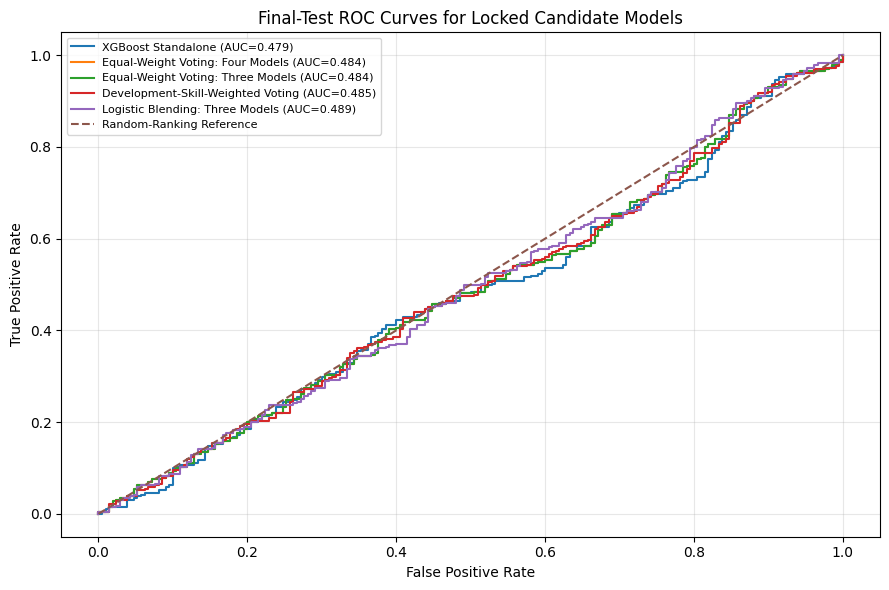

Figure saved to: /content/cqf_final_project/outputs/figures/final_test_candidate_roc_curves.png


In [129]:
# ------------------------------------------------------------
# Plot final-test ROC curves
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

for candidate_name in final_candidate_probabilities.columns:
    candidate_probability = (
        final_candidate_probabilities[candidate_name]
        .astype(float)
        .clip(1e-12, 1.0 - 1e-12)
    )

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_final_evaluation,
        candidate_probability,
    )

    candidate_auc = roc_auc_score(
        y_final_evaluation,
        candidate_probability,
    )

    ax.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{candidate_name} (AUC={candidate_auc:.3f})",
    )

ax.plot(
    [0.0, 1.0],
    [0.0, 1.0],
    linestyle="--",
    label="Random-Ranking Reference",
)

ax.set_title(
    "Final-Test ROC Curves for Locked Candidate Models"
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(
    loc="best",
    fontsize=8,
)
ax.grid(alpha=0.3)

fig.tight_layout()

final_roc_figure_path = (
    DIRECTORIES["figures"]
    / "final_test_candidate_roc_curves.png"
)

fig.savefig(
    final_roc_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{final_roc_figure_path}"
)

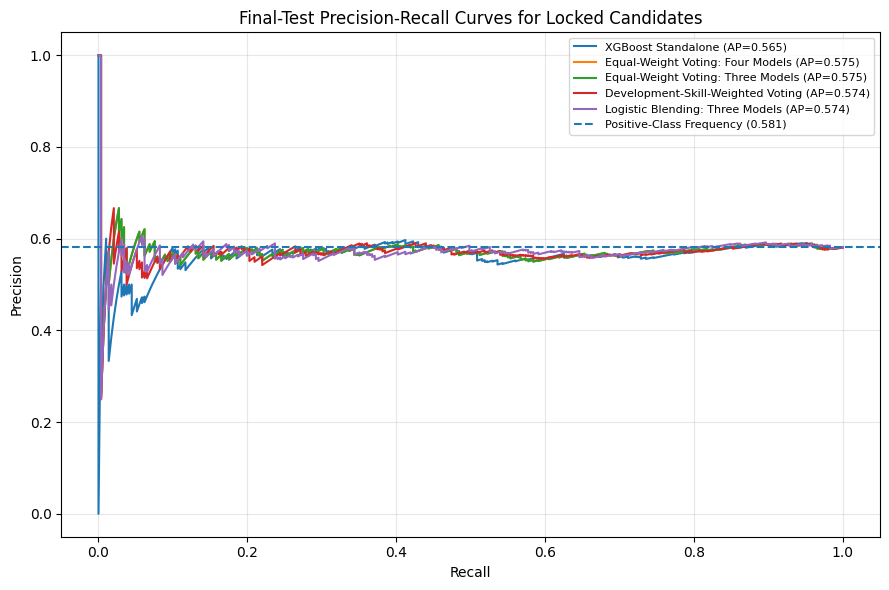

Figure saved to: /content/cqf_final_project/outputs/figures/final_test_candidate_precision_recall_curves.png


In [130]:
# ------------------------------------------------------------
# Plot final-test precision-recall curves
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

for candidate_name in final_candidate_probabilities.columns:
    candidate_probability = (
        final_candidate_probabilities[candidate_name]
        .astype(float)
        .clip(1e-12, 1.0 - 1e-12)
    )

    precision_values, recall_values, _ = (
        precision_recall_curve(
            y_final_evaluation,
            candidate_probability,
        )
    )

    candidate_average_precision = (
        average_precision_score(
            y_final_evaluation,
            candidate_probability,
        )
    )

    ax.plot(
        recall_values,
        precision_values,
        label=(
            f"{candidate_name} "
            f"(AP={candidate_average_precision:.3f})"
        ),
    )

ax.axhline(
    final_positive_rate,
    linestyle="--",
    label=(
        "Positive-Class Frequency "
        f"({final_positive_rate:.3f})"
    ),
)

ax.set_title(
    "Final-Test Precision-Recall Curves for Locked Candidates"
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(
    loc="best",
    fontsize=8,
)
ax.grid(alpha=0.3)

fig.tight_layout()

final_pr_figure_path = (
    DIRECTORIES["figures"]
    / "final_test_candidate_precision_recall_curves.png"
)

fig.savefig(
    final_pr_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{final_pr_figure_path}"
)

In [131]:
# ------------------------------------------------------------
# Archive final-test probability benchmarking results
# ------------------------------------------------------------

final_probability_benchmarks.to_csv(
    DIRECTORIES["tables"]
    / "final_test_probability_benchmarks.csv",
    header=True,
)

final_probability_comparison.to_csv(
    DIRECTORIES["tables"]
    / "final_test_probability_comparison.csv",
    index=True,
)

print(
    "Final-test probability benchmarks and "
    "comparison results archived successfully."
)

Final-test probability benchmarks and comparison results archived successfully.


## 8.5 Economic and Trading-Strategy Evaluation

Statistical classification performance does not necessarily translate directly into economic value. The locked final-test forecasts are therefore converted into implementable long-or-cash trading signals and evaluated against a passive buy-and-hold benchmark.

For each trading date \(t\), the probability forecast and the pre-selected classification threshold determine the position held over the subsequent close-to-close return interval from \(t\) to \(t+1\). A predicted positive return produces a fully invested long position, whereas a predicted non-positive return produces a cash position. Short selling and leverage are excluded.

The primary analysis assumes a one-way transaction cost of five basis points for each unit change in portfolio exposure. Performance is also recalculated under zero-, five-, and ten-basis-point cost assumptions. All models, thresholds, forecasts, and transaction-cost scenarios are fixed before economic performance is examined.

Annualised return, annualised volatility, Sharpe ratio, maximum drawdown, market exposure, and portfolio turnover are reported. The risk-free rate is set to zero for the Sharpe-ratio calculation.

In [132]:
# ------------------------------------------------------------
# Align locked forecasts with subsequent realised returns
# ------------------------------------------------------------

annualisation_factor = int(
    CONFIG.get("annualisation_factor", 252)
)

primary_transaction_cost_bps = 5.0

final_strategy_data = pd.DataFrame(
    index=final_candidate_probabilities.index
)

final_strategy_data["Forward_Log_Return"] = (
    model_data["Forward_Log_Return"]
    .reindex(final_strategy_data.index)
    .astype(float)
)

final_strategy_data["Underlying_Simple_Return"] = np.expm1(
    final_strategy_data["Forward_Log_Return"]
)

final_strategy_data["Target"] = (
    y_final_evaluation
    .reindex(final_strategy_data.index)
    .astype(int)
)

reconstructed_final_target = (
    final_strategy_data["Forward_Log_Return"] > 0.0
).astype(int)

target_identity_error = int(
    (
        reconstructed_final_target
        != final_strategy_data["Target"]
    ).sum()
)

assert final_strategy_data.index.equals(
    final_candidate_probabilities.index
)

assert final_strategy_data.notna().all().all()

assert np.isfinite(
    final_strategy_data.to_numpy()
).all()

assert target_identity_error == 0

final_strategy_alignment_audit = pd.Series(
    {
        "Observations": len(final_strategy_data),
        "Start date": final_strategy_data.index.min(),
        "End date": final_strategy_data.index.max(),
        "Missing return observations": int(
            final_strategy_data[
                "Forward_Log_Return"
            ].isna().sum()
        ),
        "Target-identity mismatches": (
            target_identity_error
        ),
        "Forecast matrix aligned": (
            final_strategy_data.index.equals(
                final_candidate_probabilities.index
            )
        ),
        "Models and thresholds modified": False,
    },
    name="Final-Test Strategy Alignment Audit",
)

display(final_strategy_alignment_audit)

,Final-Test Strategy Alignment Audit
Observations,501
Start date,2024-01-02 00:00:00
End date,2025-12-30 00:00:00
Missing return observations,0
Target-identity mismatches,0
Forecast matrix aligned,True
Models and thresholds modified,False


In [133]:
# ------------------------------------------------------------
# Define long-or-cash strategy and performance calculations
# ------------------------------------------------------------

def construct_long_cash_strategy(
    probability: pd.Series,
    threshold: float,
    underlying_return: pd.Series,
    transaction_cost_bps: float,
) -> pd.DataFrame:
    """Construct a locked long-or-cash strategy."""

    probability = probability.astype(float).copy()
    underlying_return = underlying_return.astype(float).copy()

    position = (
        probability >= float(threshold)
    ).astype(float)

    turnover = position.diff().abs()

    # The portfolio is assumed to begin in cash.
    turnover.iloc[0] = abs(position.iloc[0])

    transaction_cost = (
        turnover
        * float(transaction_cost_bps)
        / 10_000.0
    )

    gross_strategy_return = (
        position * underlying_return
    )

    net_strategy_return = (
        gross_strategy_return
        - transaction_cost
    )

    strategy_result = pd.DataFrame(
        {
            "Probability": probability,
            "Position": position,
            "Turnover": turnover,
            "Underlying_Return": underlying_return,
            "Gross_Strategy_Return": (
                gross_strategy_return
            ),
            "Transaction_Cost": transaction_cost,
            "Net_Strategy_Return": (
                net_strategy_return
            ),
        }
    )

    return strategy_result


def calculate_strategy_metrics(
    return_series: pd.Series,
    position_series: pd.Series,
    turnover_series: pd.Series,
    annualisation_factor: int = 252,
) -> pd.Series:
    """Calculate economic performance statistics."""

    return_series = (
        return_series
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    position_series = (
        position_series
        .reindex(return_series.index)
        .astype(float)
    )

    turnover_series = (
        turnover_series
        .reindex(return_series.index)
        .astype(float)
    )

    wealth_index = (
        1.0 + return_series
    ).cumprod()

    running_maximum = wealth_index.cummax()

    drawdown = (
        wealth_index / running_maximum - 1.0
    )

    observations = len(return_series)

    cumulative_return = (
        wealth_index.iloc[-1] - 1.0
    )

    annualised_return = (
        wealth_index.iloc[-1]
        ** (
            annualisation_factor
            / observations
        )
        - 1.0
    )

    annualised_volatility = (
        return_series.std(ddof=1)
        * np.sqrt(annualisation_factor)
    )

    if annualised_volatility > 0.0:
        sharpe_ratio = (
            return_series.mean()
            / return_series.std(ddof=1)
            * np.sqrt(annualisation_factor)
        )
    else:
        sharpe_ratio = np.nan

    active_mask = position_series > 0.0

    if active_mask.any():
        active_day_positive_rate = float(
            (
                return_series.loc[active_mask]
                > 0.0
            ).mean()
        )
    else:
        active_day_positive_rate = np.nan

    metrics = pd.Series(
        {
            "Observations": observations,
            "Exposure Rate": (
                position_series.mean()
            ),
            "Position Changes": int(
                (turnover_series > 0.0).sum()
            ),
            "Total Turnover": (
                turnover_series.sum()
            ),
            "Annualised Turnover": (
                turnover_series.mean()
                * annualisation_factor
            ),
            "Cumulative Return": (
                cumulative_return
            ),
            "Annualised Return": (
                annualised_return
            ),
            "Annualised Volatility": (
                annualised_volatility
            ),
            "Sharpe Ratio": sharpe_ratio,
            "Maximum Drawdown": drawdown.min(),
            "Active-Day Positive Rate": (
                active_day_positive_rate
            ),
        }
    )

    return metrics

In [134]:
# ------------------------------------------------------------
# Evaluate locked long-or-cash strategies
# ------------------------------------------------------------

final_strategy_results = {}
final_strategy_metric_records = []

underlying_final_return = (
    final_strategy_data[
        "Underlying_Simple_Return"
    ]
)

for candidate_name in (
    final_candidate_probabilities.columns
):
    candidate_threshold = float(
        final_locked_thresholds.loc[
            candidate_name
        ]
    )

    candidate_strategy = (
        construct_long_cash_strategy(
            probability=(
                final_candidate_probabilities[
                    candidate_name
                ]
            ),
            threshold=candidate_threshold,
            underlying_return=(
                underlying_final_return
            ),
            transaction_cost_bps=(
                primary_transaction_cost_bps
            ),
        )
    )

    final_strategy_results[
        candidate_name
    ] = candidate_strategy

    candidate_metrics = (
        calculate_strategy_metrics(
            return_series=(
                candidate_strategy[
                    "Net_Strategy_Return"
                ]
            ),
            position_series=(
                candidate_strategy["Position"]
            ),
            turnover_series=(
                candidate_strategy["Turnover"]
            ),
            annualisation_factor=(
                annualisation_factor
            ),
        )
    )

    candidate_metrics["Candidate"] = (
        candidate_name
    )

    final_strategy_metric_records.append(
        candidate_metrics
    )


# ------------------------------------------------------------
# Buy-and-hold benchmark
# ------------------------------------------------------------

buy_hold_position = pd.Series(
    1.0,
    index=underlying_final_return.index,
    name="Position",
)

buy_hold_turnover = pd.Series(
    0.0,
    index=underlying_final_return.index,
    name="Turnover",
)

# Initial purchase from cash into the asset.
buy_hold_turnover.iloc[0] = 1.0

buy_hold_transaction_cost = (
    buy_hold_turnover
    * primary_transaction_cost_bps
    / 10_000.0
)

buy_hold_net_return = (
    underlying_final_return
    - buy_hold_transaction_cost
)

buy_hold_metrics = calculate_strategy_metrics(
    return_series=buy_hold_net_return,
    position_series=buy_hold_position,
    turnover_series=buy_hold_turnover,
    annualisation_factor=annualisation_factor,
)

buy_hold_metrics["Candidate"] = (
    "Buy-and-Hold Benchmark"
)

final_strategy_metric_records.append(
    buy_hold_metrics
)


final_strategy_metrics = (
    pd.DataFrame(final_strategy_metric_records)
    .set_index("Candidate")
    .sort_values(
        "Sharpe Ratio",
        ascending=False,
    )
)

display(final_strategy_metrics)

,Observations,Exposure Rate,Position Changes,Total Turnover,Annualised Turnover,Cumulative Return,Annualised Return,Annualised Volatility,Sharpe Ratio,Maximum Drawdown,Active-Day Positive Rate
Candidate,,,,,,,,,,,
Buy-and-Hold Benchmark,501.000000,1.000000,1.000000,1.000000,0.502994,0.477680,0.217021,0.163791,1.280738,-0.187552,0.580838
Logistic Blending: Three Models,501.000000,0.974052,27.000000,27.000000,13.580838,0.468493,0.213209,0.162778,1.268403,-0.195039,0.581967
Development-Skill-Weighted Voting,501.000000,0.349301,174.000000,174.000000,87.520958,0.022627,0.011318,0.102679,0.161219,-0.186933,0.571429
Equal-Weight Voting: Three Models,501.000000,0.281437,164.000000,164.000000,82.491018,0.002661,0.001337,0.096935,0.062532,-0.156058,0.546099
XGBoost Standalone,501.000000,0.323353,158.000000,158.000000,79.473054,-0.009171,-0.004624,0.097603,0.001611,-0.182391,0.561728
Equal-Weight Voting: Four Models,501.000000,0.303393,178.000000,178.000000,89.532934,-0.018396,-0.009296,0.099090,-0.044421,-0.169237,0.559211


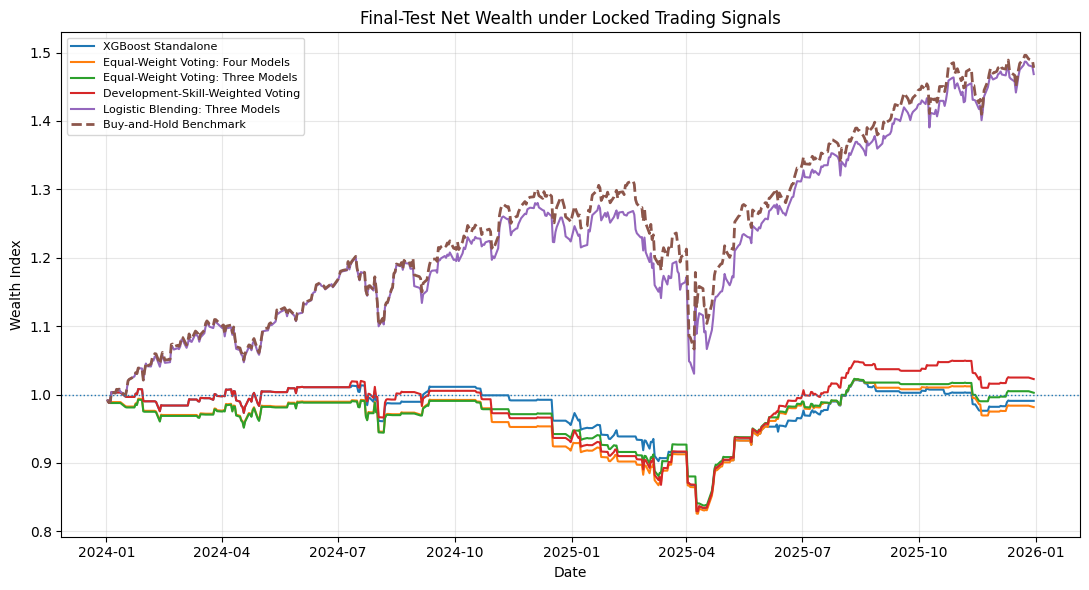

Figure saved to: /content/cqf_final_project/outputs/figures/final_test_locked_strategy_wealth.png


In [135]:
# ------------------------------------------------------------
# Plot final-test net wealth paths
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

for candidate_name, strategy_result in (
    final_strategy_results.items()
):
    candidate_wealth = (
        1.0
        + strategy_result[
            "Net_Strategy_Return"
        ]
    ).cumprod()

    ax.plot(
        candidate_wealth.index,
        candidate_wealth,
        label=candidate_name,
    )

buy_hold_wealth = (
    1.0 + buy_hold_net_return
).cumprod()

ax.plot(
    buy_hold_wealth.index,
    buy_hold_wealth,
    linestyle="--",
    linewidth=2.0,
    label="Buy-and-Hold Benchmark",
)

ax.axhline(
    1.0,
    linestyle=":",
    linewidth=1.0,
)

ax.set_title(
    "Final-Test Net Wealth under Locked Trading Signals"
)
ax.set_xlabel("Date")
ax.set_ylabel("Wealth Index")
ax.legend(
    loc="best",
    fontsize=8,
)
ax.grid(alpha=0.3)

fig.tight_layout()

final_strategy_wealth_figure_path = (
    DIRECTORIES["figures"]
    / "final_test_locked_strategy_wealth.png"
)

fig.savefig(
    final_strategy_wealth_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{final_strategy_wealth_figure_path}"
)

In [136]:
# ------------------------------------------------------------
# Evaluate transaction-cost sensitivity
# ------------------------------------------------------------

transaction_cost_scenarios_bps = [
    0.0,
    5.0,
    10.0,
]

transaction_cost_sensitivity_records = []

for transaction_cost_bps in (
    transaction_cost_scenarios_bps
):
    for candidate_name in (
        final_candidate_probabilities.columns
    ):
        candidate_threshold = float(
            final_locked_thresholds.loc[
                candidate_name
            ]
        )

        scenario_strategy = (
            construct_long_cash_strategy(
                probability=(
                    final_candidate_probabilities[
                        candidate_name
                    ]
                ),
                threshold=candidate_threshold,
                underlying_return=(
                    underlying_final_return
                ),
                transaction_cost_bps=(
                    transaction_cost_bps
                ),
            )
        )

        scenario_metrics = (
            calculate_strategy_metrics(
                return_series=(
                    scenario_strategy[
                        "Net_Strategy_Return"
                    ]
                ),
                position_series=(
                    scenario_strategy[
                        "Position"
                    ]
                ),
                turnover_series=(
                    scenario_strategy[
                        "Turnover"
                    ]
                ),
                annualisation_factor=(
                    annualisation_factor
                ),
            )
        )

        transaction_cost_sensitivity_records.append(
            {
                "Candidate": candidate_name,
                "Transaction Cost (bps)": (
                    transaction_cost_bps
                ),
                "Cumulative Return": (
                    scenario_metrics[
                        "Cumulative Return"
                    ]
                ),
                "Annualised Return": (
                    scenario_metrics[
                        "Annualised Return"
                    ]
                ),
                "Annualised Volatility": (
                    scenario_metrics[
                        "Annualised Volatility"
                    ]
                ),
                "Sharpe Ratio": (
                    scenario_metrics[
                        "Sharpe Ratio"
                    ]
                ),
                "Maximum Drawdown": (
                    scenario_metrics[
                        "Maximum Drawdown"
                    ]
                ),
                "Total Turnover": (
                    scenario_metrics[
                        "Total Turnover"
                    ]
                ),
            }
        )

transaction_cost_sensitivity = (
    pd.DataFrame(
        transaction_cost_sensitivity_records
    )
    .set_index(
        [
            "Candidate",
            "Transaction Cost (bps)",
        ]
    )
    .sort_index()
)

display(transaction_cost_sensitivity)

Cumulative Return  \
Candidate                         Transaction Cost (bps)                      
Development-Skill-Weighted Voting 0.000000                         0.115608   
                                  5.000000                         0.022627   
                                  10.000000                       -0.062645   
Equal-Weight Voting: Four Models  0.000000                         0.072989   
                                  5.000000                        -0.018396   
                                  10.000000                       -0.102038   
Equal-Weight Voting: Three Models 0.000000                         0.088350   
                                  5.000000                         0.002661   
                                  10.000000                       -0.076320   
Logistic Blending: Three Models   0.000000                         0.488475   
                                  5.000000                         0.468493   
                                  10.000000                        0.448770   
XGBoost Standalone                0.000000                         0.072309   
                                  5.000000                        -0.009171   
                                  10.000000                       -0.084496   

                                                          Annualised Return  \
Candidate                         Transaction Cost (bps)                      
Development-Skill-Weighted Voting 0.000000                         0.056569   
                                  5.000000                         0.011318   
                                  10.000000                       -0.032016   
Equal-Weight Voting: Four Models  0.000000                         0.036070   
                                  5.000000                        -0.009296   
                                  10.000000                       -0.052697   
Equal-Weight Voting: Three Models 0.000000                         0.043505   
                                  5.000000                         0.001337   
                                  10.000000                       -0.039146   
Logistic Blending: Three Models   0.000000                         0.221484   
                                  5.000000                         0.213209   
                                  10.000000                        0.204985   
XGBoost Standalone                0.000000                         0.035740   
                                  5.000000                        -0.004624   
                                  10.000000                       -0.043433   

                                                          Annualised Volatility  \
Candidate                         Transaction Cost (bps)                          
Development-Skill-Weighted Voting 0.000000                             0.102526   
                                  5.000000                             0.102679   
                                  10.000000                            0.102971   
Equal-Weight Voting: Four Models  0.000000                             0.099012   
                                  5.000000                             0.099090   
                                  10.000000                            0.099313   
Equal-Weight Voting: Three Models 0.000000                             0.096896   
                                  5.000000                             0.096935   
                                  10.000000                            0.097118   
Logistic Blending: Three Models   0.000000                             0.162697   
                                  5.000000                             0.162778   
                                  10.000000                            0.162877   
XGBoost Standalone                0.000000                             0.097457   
                                  5.000000                             0.097603   
                                  10.00000

In [137]:
# ------------------------------------------------------------
# Archive final-test economic-evaluation results
# ------------------------------------------------------------

final_strategy_alignment_audit.to_csv(
    DIRECTORIES["tables"]
    / "final_test_strategy_alignment_audit.csv",
    header=True,
)

final_strategy_metrics.to_csv(
    DIRECTORIES["tables"]
    / "final_test_locked_strategy_metrics.csv",
    index=True,
)

transaction_cost_sensitivity.to_csv(
    DIRECTORIES["tables"]
    / "final_test_transaction_cost_sensitivity.csv",
    index=True,
)

for candidate_name, strategy_result in (
    final_strategy_results.items()
):
    safe_candidate_name = (
        candidate_name
        .lower()
        .replace(" ", "_")
        .replace(":", "")
        .replace("-", "_")
    )

    strategy_result.to_csv(
        DIRECTORIES["tables"]
        / (
            "final_test_strategy_path_"
            f"{safe_candidate_name}.csv"
        ),
        index=True,
    )

print(
    "Final-test economic evaluation outputs "
    "archived successfully."
)

Final-test economic evaluation outputs archived successfully.


### Economic-Evaluation Results

All strategy-alignment checks are satisfied. The economic evaluation therefore uses exactly the same 501 locked final-test observations, forecasts, and classification thresholds as the preceding statistical evaluation.

The passive buy-and-hold benchmark produces the strongest overall economic result. After the initial five-basis-point purchase cost, it earns a cumulative return of 47.77%, an annualised return of 21.70%, and a Sharpe ratio of 1.281. Its maximum drawdown is approximately 18.76%.

The primary three-model logistic-blending strategy produces a similar cumulative return of 46.85% and a Sharpe ratio of 1.268. However, its market-exposure rate is 97.41%. Its wealth path therefore closely tracks the passive benchmark, and its slightly weaker result is largely explained by its additional position changes and transaction costs. The strategy's active-day positive-return rate is also almost identical to the unconditional final-test positive-return rate. Consequently, its economic performance should be interpreted primarily as persistent equity-market exposure rather than successful market timing.

The lower-exposure voting and standalone-XGBoost strategies produce substantially weaker results. Although their annualised volatility is approximately 9.7%–10.3%, their net cumulative returns at the five-basis-point cost assumption range from −1.84% to 2.26%. Their lower volatility and, in some cases, smaller drawdowns arise mainly because the strategies remain in cash for a large proportion of the evaluation period.

Transaction-cost sensitivity confirms that turnover is economically important. Before costs, the lower-exposure strategies generate cumulative returns of approximately 7%–12%. These returns are largely eliminated at five basis points and become negative at ten basis points because the strategies generate between 158 and 178 units of turnover. In contrast, the logistic-blending strategy is comparatively insensitive to transaction costs because it changes position only 27 times.

Overall, the locked forecasts do not demonstrate robust economic market-timing value. The strong return of the primary ensemble is predominantly attributable to near-continuous exposure to the rising underlying market, while the apparent gross returns of the more selective strategies are not robust to realistic trading costs.

## 8.6 Statistical Uncertainty and Robustness Assessment

Point estimates alone do not reveal whether the observed final-test differences are economically or statistically meaningful. Uncertainty is therefore assessed using a paired circular moving-block bootstrap.

The same bootstrap indices are applied simultaneously to realised labels, probability forecasts, strategy returns, and buy-and-hold returns. This paired design preserves the contemporaneous dependence between competing forecasts and their common market environment. Blocks of ten consecutive trading observations are sampled with replacement to retain short-run serial dependence and volatility clustering.

One thousand bootstrap replications are used to estimate percentile confidence intervals for final-test ROC-AUC, annualised strategy return, Sharpe ratio, and annualised return relative to buy-and-hold. Models, probability forecasts, classification thresholds, and trading rules remain locked throughout the analysis.

In [138]:
# ------------------------------------------------------------
# Configure paired circular moving-block bootstrap
# ------------------------------------------------------------

from sklearn.metrics import roc_auc_score

bootstrap_replications = 1_000
bootstrap_block_length = 10
bootstrap_confidence_level = 0.95

bootstrap_random_seed = int(
    CONFIG.get("random_seed", 42)
)

bootstrap_rng = np.random.default_rng(
    bootstrap_random_seed
)


def generate_circular_block_indices(
    number_of_observations: int,
    block_length: int,
    random_generator: np.random.Generator,
) -> np.ndarray:
    """Generate indices for a circular moving-block bootstrap."""

    number_of_blocks = int(
        np.ceil(
            number_of_observations
            / block_length
        )
    )

    block_start_indices = (
        random_generator.integers(
            low=0,
            high=number_of_observations,
            size=number_of_blocks,
        )
    )

    sampled_blocks = [
        (
            block_start
            + np.arange(block_length)
        )
        % number_of_observations
        for block_start in block_start_indices
    ]

    bootstrap_indices = np.concatenate(
        sampled_blocks
    )[:number_of_observations]

    return bootstrap_indices


def calculate_bootstrap_annualised_return(
    return_array: np.ndarray,
    annualisation_factor: int,
) -> float:
    """Calculate annualised compounded return."""

    terminal_wealth = np.prod(
        1.0 + return_array
    )

    return float(
        terminal_wealth
        ** (
            annualisation_factor
            / len(return_array)
        )
        - 1.0
    )


def calculate_bootstrap_sharpe_ratio(
    return_array: np.ndarray,
    annualisation_factor: int,
) -> float:
    """Calculate annualised zero-risk-free-rate Sharpe ratio."""

    return_standard_deviation = np.std(
        return_array,
        ddof=1,
    )

    if return_standard_deviation <= 0.0:
        return np.nan

    return float(
        np.mean(return_array)
        / return_standard_deviation
        * np.sqrt(annualisation_factor)
    )

In [139]:
# ------------------------------------------------------------
# Construct aligned bootstrap input matrices
# ------------------------------------------------------------

bootstrap_evaluation_index = (
    final_candidate_probabilities.index
)

bootstrap_target = (
    y_final_evaluation
    .reindex(bootstrap_evaluation_index)
    .astype(int)
    .to_numpy()
)

bootstrap_probability_matrix = (
    final_candidate_probabilities
    .reindex(bootstrap_evaluation_index)
    .astype(float)
)

bootstrap_strategy_return_matrix = pd.DataFrame(
    {
        candidate_name: (
            final_strategy_results[
                candidate_name
            ]["Net_Strategy_Return"]
            .reindex(bootstrap_evaluation_index)
            .astype(float)
        )
        for candidate_name in (
            final_candidate_probabilities.columns
        )
    },
    index=bootstrap_evaluation_index,
)

bootstrap_strategy_return_matrix[
    "Buy-and-Hold Benchmark"
] = (
    buy_hold_net_return
    .reindex(bootstrap_evaluation_index)
    .astype(float)
)

assert len(bootstrap_target) == 501

assert (
    bootstrap_probability_matrix
    .notna()
    .all()
    .all()
)

assert (
    bootstrap_strategy_return_matrix
    .notna()
    .all()
    .all()
)

assert np.isfinite(
    bootstrap_probability_matrix.to_numpy()
).all()

assert np.isfinite(
    bootstrap_strategy_return_matrix.to_numpy()
).all()

bootstrap_input_audit = pd.Series(
    {
        "Observations": len(
            bootstrap_evaluation_index
        ),
        "Candidate probability forecasts": (
            bootstrap_probability_matrix.shape[1]
        ),
        "Economic return series": (
            bootstrap_strategy_return_matrix.shape[1]
        ),
        "Bootstrap replications": (
            bootstrap_replications
        ),
        "Circular block length": (
            bootstrap_block_length
        ),
        "Confidence level": (
            bootstrap_confidence_level
        ),
        "Models or thresholds re-estimated": False,
    },
    name="Final-Test Bootstrap Input Audit",
)

display(bootstrap_input_audit)

,Final-Test Bootstrap Input Audit
Observations,501
Candidate probability forecasts,5
Economic return series,6
Bootstrap replications,1000
Circular block length,10
Confidence level,0.950000
Models or thresholds re-estimated,False


In [140]:
# ------------------------------------------------------------
# Run paired circular moving-block bootstrap
# ------------------------------------------------------------

candidate_names = list(
    bootstrap_probability_matrix.columns
)

economic_series_names = list(
    bootstrap_strategy_return_matrix.columns
)

bootstrap_auc_values = {
    candidate_name: []
    for candidate_name in candidate_names
}

bootstrap_annualised_returns = {
    strategy_name: []
    for strategy_name in economic_series_names
}

bootstrap_sharpe_ratios = {
    strategy_name: []
    for strategy_name in economic_series_names
}

number_of_observations = len(
    bootstrap_evaluation_index
)

for bootstrap_iteration in range(
    bootstrap_replications
):
    sampled_indices = (
        generate_circular_block_indices(
            number_of_observations=(
                number_of_observations
            ),
            block_length=(
                bootstrap_block_length
            ),
            random_generator=bootstrap_rng,
        )
    )

    sampled_target = bootstrap_target[
        sampled_indices
    ]

    # AUC is undefined if a resample contains one class only.
    if np.unique(sampled_target).size == 2:
        for candidate_name in candidate_names:
            sampled_probability = (
                bootstrap_probability_matrix[
                    candidate_name
                ]
                .to_numpy()[sampled_indices]
            )

            bootstrap_auc_values[
                candidate_name
            ].append(
                roc_auc_score(
                    sampled_target,
                    sampled_probability,
                )
            )

    for strategy_name in economic_series_names:
        sampled_returns = (
            bootstrap_strategy_return_matrix[
                strategy_name
            ]
            .to_numpy()[sampled_indices]
        )

        bootstrap_annualised_returns[
            strategy_name
        ].append(
            calculate_bootstrap_annualised_return(
                return_array=sampled_returns,
                annualisation_factor=(
                    annualisation_factor
                ),
            )
        )

        bootstrap_sharpe_ratios[
            strategy_name
        ].append(
            calculate_bootstrap_sharpe_ratio(
                return_array=sampled_returns,
                annualisation_factor=(
                    annualisation_factor
                ),
            )
        )

print(
    "Paired circular moving-block bootstrap "
    "completed successfully."
)

Paired circular moving-block bootstrap completed successfully.


In [141]:
# ------------------------------------------------------------
# Summarise final-test ROC-AUC uncertainty
# ------------------------------------------------------------

bootstrap_alpha = (
    1.0 - bootstrap_confidence_level
)

lower_percentile = (
    100.0 * bootstrap_alpha / 2.0
)

upper_percentile = (
    100.0
    * (1.0 - bootstrap_alpha / 2.0)
)

auc_uncertainty_records = []

for candidate_name in candidate_names:
    auc_distribution = np.asarray(
        bootstrap_auc_values[candidate_name],
        dtype=float,
    )

    observed_auc = roc_auc_score(
        bootstrap_target,
        bootstrap_probability_matrix[
            candidate_name
        ],
    )

    auc_uncertainty_records.append(
        {
            "Candidate": candidate_name,
            "Observed ROC-AUC": observed_auc,
            "Bootstrap Mean ROC-AUC": (
                np.mean(auc_distribution)
            ),
            "Bootstrap Standard Error": (
                np.std(
                    auc_distribution,
                    ddof=1,
                )
            ),
            "95% CI Lower": np.percentile(
                auc_distribution,
                lower_percentile,
            ),
            "95% CI Upper": np.percentile(
                auc_distribution,
                upper_percentile,
            ),
            "Probability ROC-AUC > 0.50": (
                np.mean(
                    auc_distribution > 0.50
                )
            ),
            "Valid Replications": len(
                auc_distribution
            ),
        }
    )

final_auc_uncertainty = (
    pd.DataFrame(auc_uncertainty_records)
    .set_index("Candidate")
    .sort_values(
        "Observed ROC-AUC",
        ascending=False,
    )
)

display(final_auc_uncertainty)

,Observed ROC-AUC,Bootstrap Mean ROC-AUC,Bootstrap Standard Error,95% CI Lower,95% CI Upper,Probability ROC-AUC > 0.50,Valid Replications
Candidate,,,,,,,
Logistic Blending: Three Models,0.488742,0.488293,0.023092,0.442259,0.532502,0.315000,1000
Development-Skill-Weighted Voting,0.484667,0.484940,0.026017,0.433748,0.533805,0.289000,1000
Equal-Weight Voting: Three Models,0.484258,0.484565,0.026200,0.432771,0.534905,0.289000,1000
Equal-Weight Voting: Four Models,0.484258,0.484565,0.026200,0.432771,0.534905,0.289000,1000
XGBoost Standalone,0.479267,0.478905,0.025307,0.430373,0.528090,0.205000,1000


In [142]:
# ------------------------------------------------------------
# Summarise economic-performance uncertainty
# ------------------------------------------------------------

buy_hold_bootstrap_returns = np.asarray(
    bootstrap_annualised_returns[
        "Buy-and-Hold Benchmark"
    ],
    dtype=float,
)

strategy_uncertainty_records = []

for strategy_name in economic_series_names:
    annual_return_distribution = np.asarray(
        bootstrap_annualised_returns[
            strategy_name
        ],
        dtype=float,
    )

    sharpe_distribution = np.asarray(
        bootstrap_sharpe_ratios[
            strategy_name
        ],
        dtype=float,
    )

    observed_annualised_return = float(
        final_strategy_metrics.loc[
            strategy_name,
            "Annualised Return",
        ]
    )

    observed_sharpe_ratio = float(
        final_strategy_metrics.loc[
            strategy_name,
            "Sharpe Ratio",
        ]
    )

    if strategy_name == "Buy-and-Hold Benchmark":
        excess_return_distribution = np.zeros(
            bootstrap_replications,
            dtype=float,
        )

        observed_excess_return = 0.0
        probability_outperforming = np.nan

    else:
        excess_return_distribution = (
            annual_return_distribution
            - buy_hold_bootstrap_returns
        )

        observed_excess_return = (
            observed_annualised_return
            - float(
                final_strategy_metrics.loc[
                    "Buy-and-Hold Benchmark",
                    "Annualised Return",
                ]
            )
        )

        probability_outperforming = np.mean(
            excess_return_distribution > 0.0
        )

    strategy_uncertainty_records.append(
        {
            "Candidate": strategy_name,
            "Observed Annualised Return": (
                observed_annualised_return
            ),
            "Annualised Return CI Lower": (
                np.percentile(
                    annual_return_distribution,
                    lower_percentile,
                )
            ),
            "Annualised Return CI Upper": (
                np.percentile(
                    annual_return_distribution,
                    upper_percentile,
                )
            ),
            "Observed Sharpe Ratio": (
                observed_sharpe_ratio
            ),
            "Sharpe CI Lower": np.nanpercentile(
                sharpe_distribution,
                lower_percentile,
            ),
            "Sharpe CI Upper": np.nanpercentile(
                sharpe_distribution,
                upper_percentile,
            ),
            "Observed Excess Annual Return": (
                observed_excess_return
            ),
            "Excess Return CI Lower": (
                np.percentile(
                    excess_return_distribution,
                    lower_percentile,
                )
            ),
            "Excess Return CI Upper": (
                np.percentile(
                    excess_return_distribution,
                    upper_percentile,
                )
            ),
            "Probability of Beating Buy-and-Hold": (
                probability_outperforming
            ),
        }
    )

final_strategy_uncertainty = (
    pd.DataFrame(
        strategy_uncertainty_records
    )
    .set_index("Candidate")
    .sort_values(
        "Observed Annualised Return",
        ascending=False,
    )
)

display(final_strategy_uncertainty)

,Observed Annualised Return,Annualised Return CI Lower,Annualised Return CI Upper,Observed Sharpe Ratio,Sharpe CI Lower,Sharpe CI Upper,Observed Excess Annual Return,Excess Return CI Lower,Excess Return CI Upper,Probability of Beating Buy-and-Hold
Candidate,,,,,,,,,,
Buy-and-Hold Benchmark,0.217021,-0.012853,0.458043,1.280738,0.005620,2.841227,0.000000,0.000000,0.000000,NaN
Logistic Blending: Three Models,0.213209,-0.015998,0.457060,1.268403,-0.015984,2.869918,-0.003812,-0.034451,0.030297,0.418000
Development-Skill-Weighted Voting,0.011318,-0.131494,0.165533,0.161219,-1.240484,1.638783,-0.205703,-0.380953,-0.039361,0.007000
Equal-Weight Voting: Three Models,0.001337,-0.135557,0.149202,0.062532,-1.348333,1.565186,-0.215683,-0.400052,-0.051529,0.006000
XGBoost Standalone,-0.004624,-0.140203,0.143929,0.001611,-1.346345,1.441032,-0.221644,-0.396830,-0.058012,0.004000
Equal-Weight Voting: Four Models,-0.009296,-0.152318,0.143429,-0.044421,-1.467271,1.467575,-0.226316,-0.407322,-0.057000,0.005000


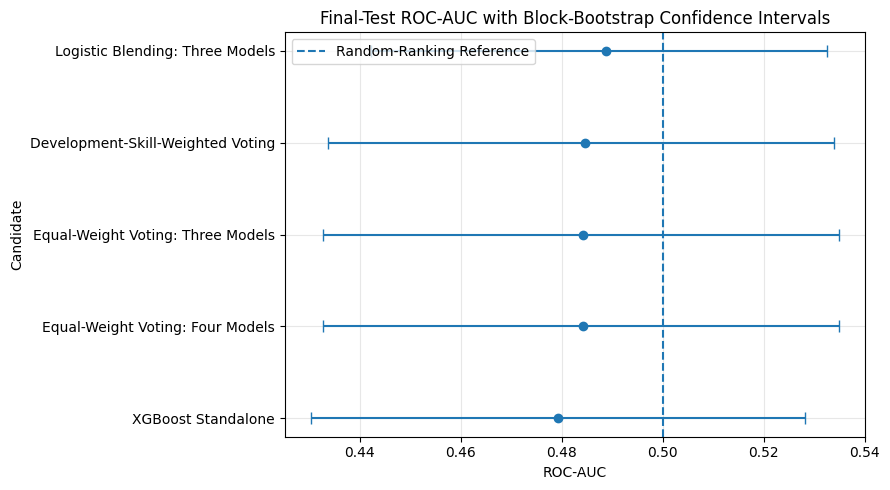

Figure saved to: /content/cqf_final_project/outputs/figures/final_test_auc_bootstrap_intervals.png


In [143]:
# ------------------------------------------------------------
# Plot final-test ROC-AUC confidence intervals
# ------------------------------------------------------------

auc_plot_data = (
    final_auc_uncertainty
    .sort_values("Observed ROC-AUC")
)

auc_lower_error = (
    auc_plot_data["Observed ROC-AUC"]
    - auc_plot_data["95% CI Lower"]
)

auc_upper_error = (
    auc_plot_data["95% CI Upper"]
    - auc_plot_data["Observed ROC-AUC"]
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    auc_plot_data["Observed ROC-AUC"],
    auc_plot_data.index,
    xerr=np.vstack(
        [
            auc_lower_error,
            auc_upper_error,
        ]
    ),
    fmt="o",
    capsize=4,
)

ax.axvline(
    0.50,
    linestyle="--",
    label="Random-Ranking Reference",
)

ax.set_title(
    "Final-Test ROC-AUC with Block-Bootstrap Confidence Intervals"
)
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Candidate")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

final_auc_uncertainty_figure_path = (
    DIRECTORIES["figures"]
    / "final_test_auc_bootstrap_intervals.png"
)

fig.savefig(
    final_auc_uncertainty_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{final_auc_uncertainty_figure_path}"
)

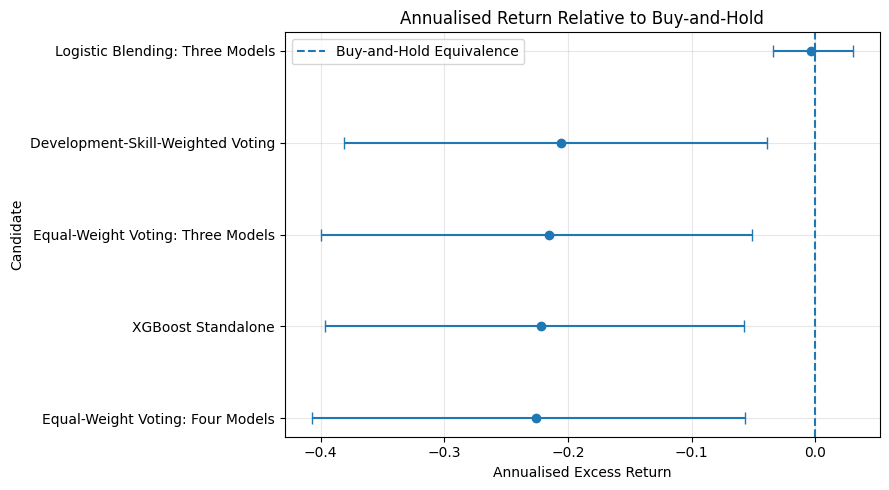

Figure saved to: /content/cqf_final_project/outputs/figures/final_test_excess_return_bootstrap_intervals.png


In [144]:
# ------------------------------------------------------------
# Plot annualised excess-return confidence intervals
# ------------------------------------------------------------

excess_return_plot_data = (
    final_strategy_uncertainty
    .drop(
        index="Buy-and-Hold Benchmark"
    )
    .sort_values(
        "Observed Excess Annual Return"
    )
)

excess_lower_error = (
    excess_return_plot_data[
        "Observed Excess Annual Return"
    ]
    - excess_return_plot_data[
        "Excess Return CI Lower"
    ]
)

excess_upper_error = (
    excess_return_plot_data[
        "Excess Return CI Upper"
    ]
    - excess_return_plot_data[
        "Observed Excess Annual Return"
    ]
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    excess_return_plot_data[
        "Observed Excess Annual Return"
    ],
    excess_return_plot_data.index,
    xerr=np.vstack(
        [
            excess_lower_error,
            excess_upper_error,
        ]
    ),
    fmt="o",
    capsize=4,
)

ax.axvline(
    0.0,
    linestyle="--",
    label="Buy-and-Hold Equivalence",
)

ax.set_title(
    "Annualised Return Relative to Buy-and-Hold"
)
ax.set_xlabel(
    "Annualised Excess Return"
)
ax.set_ylabel("Candidate")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

final_excess_return_uncertainty_path = (
    DIRECTORIES["figures"]
    / "final_test_excess_return_bootstrap_intervals.png"
)

fig.savefig(
    final_excess_return_uncertainty_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to: "
    f"{final_excess_return_uncertainty_path}"
)

In [145]:
# ------------------------------------------------------------
# Archive final-test uncertainty results
# ------------------------------------------------------------

bootstrap_input_audit.to_csv(
    DIRECTORIES["tables"]
    / "final_test_bootstrap_input_audit.csv",
    header=True,
)

final_auc_uncertainty.to_csv(
    DIRECTORIES["tables"]
    / "final_test_auc_bootstrap_intervals.csv",
    index=True,
)

final_strategy_uncertainty.to_csv(
    DIRECTORIES["tables"]
    / "final_test_strategy_bootstrap_intervals.csv",
    index=True,
)

print(
    "Final-test statistical-uncertainty outputs "
    "archived successfully."
)

Final-test statistical-uncertainty outputs archived successfully.


### Statistical-Uncertainty Results

The paired circular moving-block bootstrap confirms that the weak final-test results are not attributable merely to a single unfavourable point estimate.

For every locked candidate, the 95% confidence interval for ROC-AUC includes the random-ranking benchmark of 0.50. The primary three-model logistic ensemble records an observed ROC-AUC of approximately 0.489, while the remaining candidates lie between approximately 0.479 and 0.485. None therefore demonstrates statistically reliable out-of-sample ranking ability after allowing for short-run serial dependence and volatility clustering.

The economic uncertainty results distinguish the near-continuously invested logistic ensemble from the lower-exposure strategies. The primary logistic ensemble earns an observed annualised return of 21.32%, compared with 21.70% for buy-and-hold. Its annualised excess return is −0.38%, with a 95% bootstrap interval from approximately −3.45% to 3.03%. Its estimated probability of outperforming buy-and-hold is 41.8%. The strategy is therefore statistically indistinguishable from passive exposure rather than demonstrably superior to it.

In contrast, the annualised excess-return confidence intervals of the skill-weighted voting strategy, both equal-weight voting strategies, and standalone XGBoost lie entirely below zero. Their estimated probabilities of beating buy-and-hold range from only 0.4% to 0.7%. These results indicate robust economic underperformance relative to the passive benchmark during the locked final-test period.

The relatively wide confidence intervals for absolute annualised returns and Sharpe ratios reflect the limited two-year evaluation window and the path dependence of compounded market returns. They do not alter the central conclusion: no candidate exhibits reliable ranking skill, while only the near-continuously invested logistic ensemble avoids statistically clear underperformance relative to buy-and-hold.

## 8.7 Integrated Final-Test Evidence

The statistical and economic evidence is now consolidated into a single candidate-level summary. This section does not introduce any additional model selection, threshold adjustment, or parameter estimation.

A candidate would require both reliable ranking performance and positive incremental economic value to support a strong claim of forecasting usefulness. Confidence intervals are therefore considered together with point estimates rather than treating small numerical differences as substantive evidence.

In [146]:
# ------------------------------------------------------------
# Integrate final-test statistical and economic evidence
# ------------------------------------------------------------

final_auc_evidence = (
    final_auc_uncertainty[
        [
            "Observed ROC-AUC",
            "95% CI Lower",
            "95% CI Upper",
            "Probability ROC-AUC > 0.50",
        ]
    ]
    .rename(
        columns={
            "95% CI Lower": "ROC-AUC CI Lower",
            "95% CI Upper": "ROC-AUC CI Upper",
            "Probability ROC-AUC > 0.50": (
                "Probability ROC-AUC Above 0.50"
            ),
        }
    )
)

final_economic_evidence = (
    final_strategy_uncertainty[
        [
            "Observed Annualised Return",
            "Observed Excess Annual Return",
            "Excess Return CI Lower",
            "Excess Return CI Upper",
            "Probability of Beating Buy-and-Hold",
        ]
    ]
    .drop(
        index="Buy-and-Hold Benchmark",
        errors="ignore",
    )
)

final_evidence_summary = (
    final_auc_evidence
    .join(
        final_economic_evidence,
        how="left",
    )
)


def classify_final_evidence(
    evidence_row: pd.Series,
) -> str:
    """Assign a conservative evidence-based interpretation."""

    auc_interval_excludes_random = (
        evidence_row["ROC-AUC CI Lower"] > 0.50
    )

    excess_return_interval_positive = (
        evidence_row["Excess Return CI Lower"] > 0.0
    )

    excess_return_interval_negative = (
        evidence_row["Excess Return CI Upper"] < 0.0
    )

    if (
        auc_interval_excludes_random
        and excess_return_interval_positive
    ):
        return "Robust predictive and economic evidence"

    if excess_return_interval_negative:
        return "Economically inferior to buy-and-hold"

    return "No reliable incremental forecasting edge"


final_evidence_summary[
    "Final Evidence Assessment"
] = final_evidence_summary.apply(
    classify_final_evidence,
    axis=1,
)

final_evidence_summary = (
    final_evidence_summary
    .sort_values(
        "Observed ROC-AUC",
        ascending=False,
    )
)

display(final_evidence_summary)

,Observed ROC-AUC,ROC-AUC CI Lower,ROC-AUC CI Upper,Probability ROC-AUC Above 0.50,Observed Annualised Return,Observed Excess Annual Return,Excess Return CI Lower,Excess Return CI Upper,Probability of Beating Buy-and-Hold,Final Evidence Assessment
Candidate,,,,,,,,,,
Logistic Blending: Three Models,0.488742,0.442259,0.532502,0.315000,0.213209,-0.003812,-0.034451,0.030297,0.418000,No reliable incremental forecasting edge
Development-Skill-Weighted Voting,0.484667,0.433748,0.533805,0.289000,0.011318,-0.205703,-0.380953,-0.039361,0.007000,Economically inferior to buy-and-hold
Equal-Weight Voting: Three Models,0.484258,0.432771,0.534905,0.289000,0.001337,-0.215683,-0.400052,-0.051529,0.006000,Economically inferior to buy-and-hold
Equal-Weight Voting: Four Models,0.484258,0.432771,0.534905,0.289000,-0.009296,-0.226316,-0.407322,-0.057000,0.005000,Economically inferior to buy-and-hold
XGBoost Standalone,0.479267,0.430373,0.528090,0.205000,-0.004624,-0.221644,-0.396830,-0.058012,0.004000,Economically inferior to buy-and-hold


In [147]:
# ------------------------------------------------------------
# Summarise the passive final-test benchmark
# ------------------------------------------------------------

final_passive_benchmark_summary = pd.Series(
    {
        "Observations": int(
            final_strategy_metrics.loc[
                "Buy-and-Hold Benchmark",
                "Observations",
            ]
        ),
        "Observed Annualised Return": float(
            final_strategy_uncertainty.loc[
                "Buy-and-Hold Benchmark",
                "Observed Annualised Return",
            ]
        ),
        "Annualised Return CI Lower": float(
            final_strategy_uncertainty.loc[
                "Buy-and-Hold Benchmark",
                "Annualised Return CI Lower",
            ]
        ),
        "Annualised Return CI Upper": float(
            final_strategy_uncertainty.loc[
                "Buy-and-Hold Benchmark",
                "Annualised Return CI Upper",
            ]
        ),
        "Observed Sharpe Ratio": float(
            final_strategy_uncertainty.loc[
                "Buy-and-Hold Benchmark",
                "Observed Sharpe Ratio",
            ]
        ),
        "Sharpe CI Lower": float(
            final_strategy_uncertainty.loc[
                "Buy-and-Hold Benchmark",
                "Sharpe CI Lower",
            ]
        ),
        "Sharpe CI Upper": float(
            final_strategy_uncertainty.loc[
                "Buy-and-Hold Benchmark",
                "Sharpe CI Upper",
            ]
        ),
        "Interpretation": (
            "Passive market benchmark and "
            "economic reference strategy"
        ),
    },
    name="Buy-and-Hold Benchmark",
)

display(final_passive_benchmark_summary)

,Buy-and-Hold Benchmark
Observations,501
Observed Annualised Return,0.217021
Annualised Return CI Lower,-0.012853
Annualised Return CI Upper,0.458043
Observed Sharpe Ratio,1.280738
Sharpe CI Lower,0.005620
Sharpe CI Upper,2.841227
Interpretation,Passive market benchmark and economic referenc...


In [148]:
# ------------------------------------------------------------
# Archive the integrated final-test evidence
# ------------------------------------------------------------

final_evidence_summary.to_csv(
    DIRECTORIES["tables"]
    / "integrated_final_test_evidence.csv",
    index=True,
)

final_passive_benchmark_summary.to_csv(
    DIRECTORIES["tables"]
    / "final_test_passive_benchmark_summary.csv",
    header=True,
)

print(
    "Integrated final-test evidence archived successfully."
)

Integrated final-test evidence archived successfully.


### Integrated Interpretation

The integrated evidence provides no support for a claim of robust daily SPY direction forecasting.

None of the five locked candidates has a ROC-AUC confidence interval lying entirely above 0.50. Consequently, none demonstrates statistically reliable ranking skill on the previously untouched final-test sample.

The primary three-model logistic ensemble is the only candidate whose economic performance is not clearly inferior to buy-and-hold. Nevertheless, its annualised excess-return confidence interval contains zero, its probability of outperforming buy-and-hold is below one half, and its market exposure is approximately 97%. Its economic result therefore reflects passive-like market participation rather than incremental forecasting value.

The remaining candidates exhibit annualised excess-return confidence intervals lying entirely below zero. Their lower market exposure reduces volatility but also causes them to miss a substantial proportion of the positive market return. Frequent position changes further weaken their performance after transaction costs.

Accordingly, the final evidence assessment distinguishes between statistical failure and economic equivalence. The primary ensemble is economically similar to passive exposure but lacks forecasting skill, whereas the remaining strategies are both statistically uninformative and economically inferior to the passive benchmark.

# 9 Discussion, Bias–Variance, Robustness, Limitations, and Conclusions

This section integrates the development-stage, blending-stage, and one-time final-test evidence. The objective is not to select a model retrospectively on the basis of final-test performance, but to evaluate whether the pre-specified modelling process produced a reliable, economically meaningful, and statistically defensible forecasting system.

The discussion therefore distinguishes among four different concepts:

1. **ranking accuracy**, measured primarily by ROC-AUC;
2. **threshold-dependent classification performance**, evaluated using balanced accuracy, macro F1, sensitivity, and specificity;
3. **probability-forecast quality**, evaluated using the Brier score and log loss;
4. **economic usefulness**, evaluated through net returns, volatility, the Sharpe ratio, drawdown, turnover, transaction-cost sensitivity, and comparison with buy-and-hold.

All models, ensemble rules, probability thresholds, and economic decision rules were frozen before the final-test labels were released. Consequently, the results reported in this section constitute a genuinely out-of-sample assessment rather than a further stage of model selection.

In [149]:
# ------------------------------------------------------------
# Construct a compact final-evidence summary for the discussion
# ------------------------------------------------------------

primary_candidate = "Logistic Blending: Three Models"
benchmark_candidate = "Buy-and-Hold Benchmark"

discussion_summary = pd.DataFrame(
    {
        "Role": [
            "Primary Locked Ensemble",
            "Passive Economic Benchmark",
        ],
        "Final ROC-AUC": [
            float(
                final_evidence_summary.loc[
                    primary_candidate,
                    "Observed ROC-AUC",
                ]
            ),
            np.nan,
        ],
        "ROC-AUC CI Lower": [
            float(
                final_evidence_summary.loc[
                    primary_candidate,
                    "ROC-AUC CI Lower",
                ]
            ),
            np.nan,
        ],
        "ROC-AUC CI Upper": [
            float(
                final_evidence_summary.loc[
                    primary_candidate,
                    "ROC-AUC CI Upper",
                ]
            ),
            np.nan,
        ],
        "Balanced Accuracy": [
            float(
                final_classification_metrics.loc[
                    primary_candidate,
                    "Balanced Accuracy",
                ]
            ),
            np.nan,
        ],
        "Predicted Positive Rate": [
            float(
                final_classification_metrics.loc[
                    primary_candidate,
                    "Predicted Positive Rate",
                ]
            ),
            np.nan,
        ],
        "Annualised Return": [
            float(
                final_strategy_metrics.loc[
                    primary_candidate,
                    "Annualised Return",
                ]
            ),
            float(
                final_strategy_metrics.loc[
                    benchmark_candidate,
                    "Annualised Return",
                ]
            ),
        ],
        "Sharpe Ratio": [
            float(
                final_strategy_metrics.loc[
                    primary_candidate,
                    "Sharpe Ratio",
                ]
            ),
            float(
                final_strategy_metrics.loc[
                    benchmark_candidate,
                    "Sharpe Ratio",
                ]
            ),
        ],
        "Exposure Rate": [
            float(
                final_strategy_metrics.loc[
                    primary_candidate,
                    "Exposure Rate",
                ]
            ),
            float(
                final_strategy_metrics.loc[
                    benchmark_candidate,
                    "Exposure Rate",
                ]
            ),
        ],
        "Probability of Beating Buy-and-Hold": [
            float(
                final_evidence_summary.loc[
                    primary_candidate,
                    "Probability of Beating Buy-and-Hold",
                ]
            ),
            np.nan,
        ],
        "Evidence Assessment": [
            final_evidence_summary.loc[
                primary_candidate,
                "Final Evidence Assessment",
            ],
            "Passive market benchmark",
        ],
    },
    index=[
        primary_candidate,
        benchmark_candidate,
    ],
)

discussion_summary.index.name = "Candidate"

display(discussion_summary)

discussion_summary_path = (
    DIRECTORIES["tables"]
    / "final_discussion_summary.csv"
)

discussion_summary.to_csv(
    discussion_summary_path,
    header=True,
)

print(
    "Final discussion summary saved to: "
    f"{discussion_summary_path}"
)

,Role,Final ROC-AUC,ROC-AUC CI Lower,ROC-AUC CI Upper,Balanced Accuracy,Predicted Positive Rate,Annualised Return,Sharpe Ratio,Exposure Rate,Probability of Beating Buy-and-Hold,Evidence Assessment
Candidate,,,,,,,,,,,
Logistic Blending: Three Models,Primary Locked Ensemble,0.488742,0.442259,0.532502,0.506357,0.974052,0.213209,1.268403,0.974052,0.418000,No reliable incremental forecasting edge
Buy-and-Hold Benchmark,Passive Economic Benchmark,NaN,NaN,NaN,NaN,NaN,0.217021,1.280738,1.000000,NaN,Passive market benchmark


Final discussion summary saved to: /content/cqf_final_project/outputs/tables/final_discussion_summary.csv


## 9.1 Overall Empirical Findings

The development-stage analysis initially suggested that limited predictive structure might be present. Hyperparameter optimisation increased the mean walk-forward ROC-AUC of XGBoost from approximately 0.5143 to 0.5448, while the calibrated RBF support-vector machine and random forest achieved optimised mean ROC-AUC values of approximately 0.5275 and 0.5207, respectively. These improvements were obtained entirely within the development data and therefore represented legitimate model-selection evidence rather than final-test feedback.

The chronological blending analysis also indicated that the base learners generated partially distinct probability forecasts. In particular, the optimised probability correlations were not uniformly high, while the tree-based models remained more closely related to one another than to the linear and kernel-based models. This justified the construction of voting and logistic-blending candidates. The development-stage skill-weighted voting rule achieved the highest mean fold-level ROC-AUC among the ensemble candidates, whereas the three-model logistic blender provided a comparatively low-turnover decision rule.

The one-time final test produced a substantially weaker result. The primary locked ensemble, **Logistic Blending: Three Models**, achieved a final-test ROC-AUC of approximately 0.4887. Its block-bootstrap confidence interval, approximately 0.4423 to 0.5325, includes the random-ranking reference of 0.50. The estimated probability that its population ROC-AUC exceeds 0.50 is only approximately 31.5%. The remaining candidate models also generated ROC-AUC estimates below 0.50, with all associated confidence intervals covering the random-ranking benchmark.

Threshold-dependent results require additional care. The primary ensemble achieved an accuracy of approximately 0.5822, but its balanced accuracy was only approximately 0.5064. Its predicted-positive rate was approximately 0.9741, compared with an observed positive-class frequency of approximately 0.5808. The apparently acceptable raw accuracy was therefore produced primarily by predicting positive returns on almost every trading day rather than by separating positive and negative observations reliably.

The probability-forecast evidence leads to the same conclusion. The final-test ROC curves lie close to the random-ranking line, and the precision–recall curves remain close to the positive-class-frequency reference. The Brier scores and log losses provide no evidence that the active candidates produced materially superior probability forecasts relative to simple unconditional benchmarks.

Economic performance must also be distinguished from predictive accuracy. The primary logistic-blending strategy generated an annualised return of approximately 21.32% and a Sharpe ratio of approximately 1.27, close to the buy-and-hold values of approximately 21.70% and 1.28. However, the strategy maintained market exposure on approximately 97.4% of final-test observations. Its economic performance therefore largely replicated the passive equity premium rather than converting reliable forecasts into active excess returns.

The bootstrap estimate of the primary ensemble's annualised excess return is approximately -0.38 percentage points, with a confidence interval covering zero. Its estimated probability of beating buy-and-hold is approximately 41.8%. The correct interpretation is therefore not that the strategy discovered a profitable forecasting edge, but that a nearly fully invested strategy happened to track the passive benchmark closely during the final-test period.

The negative final-test conclusion does not invalidate the modelling exercise. Instead, it demonstrates why chronological validation, locked model selection, one-time label release, economic benchmarking, and uncertainty quantification are necessary. A conventional analysis based only on development-stage ROC-AUC or unadjusted final-test accuracy could have produced an excessively optimistic conclusion.



## 9.2 Bias–Variance Trade-Off and Model Complexity

For a fitted prediction rule \(\hat{f}(X)\), the classical bias–variance decomposition can be expressed conceptually as

$$
\mathbb{E}\left[\left(Y-\hat{f}(X)\right)^2\right]
=
\left(\operatorname{Bias}\left[\hat{f}(X)\right]\right)^2
+
\operatorname{Var}\left[\hat{f}(X)\right]
+
\sigma_{\varepsilon}^{2}.
$$

Although the project is a probabilistic classification problem rather than an ordinary least-squares regression problem, the same trade-off remains useful. A model with excessive structural restrictions may fail to capture genuine nonlinear relationships and therefore exhibit high bias. A highly flexible model may fit temporary patterns in the development sample and exhibit high variance when the market regime changes.

### Elastic-net logistic regression

The elastic-net logistic model represents the highest-bias candidate. After optimisation, its walk-forward ROC-AUC converged to exactly 0.50 and its probability forecasts became concentrated in a very narrow range. In the final test it predicted the positive class for every observation. This behaviour is consistent with a regularised linear model finding insufficient stable marginal signal in the engineered features.

The model has low variance in the sense that its outputs are highly stable, but that stability is obtained by collapsing towards an almost constant forecast. Low variance is therefore not equivalent to useful prediction. In this case, the reduction in variance is accompanied by substantial underfitting and high predictive bias.

### Random forest

The random forest provides substantially greater nonlinear flexibility. Its optimised development-stage ROC-AUC improved above the random-ranking reference, but its fold-level results varied materially, including at least one fold below 0.50. This pattern is consistent with a model that can capture interactions and nonlinearities but remains sensitive to the exact historical training window.

Bagging reduces the variance of individual decision trees, but it cannot eliminate instability caused by structural changes in the underlying data-generating process. The final-test deterioration suggests that some of the relationships learned by the forest were sample-specific rather than persistent.

### XGBoost

XGBoost achieved the strongest development-stage ranking result, with an optimised mean walk-forward ROC-AUC of approximately 0.5448. It also selected a relatively large number of boosting rounds, showing that the optimisation process benefited from a flexible additive tree structure.

However, its final-test ROC-AUC fell to approximately 0.4793. This development-to-test reversal is evidence of either estimation variance, temporal regime change, or both. The model did not necessarily overfit through an invalid validation procedure—the optimisation remained chronologically controlled—but its flexible structure appears to have captured patterns that were not stable after 2023.

XGBoost therefore illustrates an important distinction between **procedural overfitting** and **economic non-stationarity**. The modelling process controlled leakage and used walk-forward validation, yet the selected relationship still failed to generalise. Correct validation reduces overfitting risk but cannot guarantee that financial relationships remain stable.

### Calibrated RBF support-vector machine

The RBF support-vector machine occupies an intermediate position. Its nonlinear kernel permits more flexibility than logistic regression, while regularisation and margin maximisation can provide greater stability than unrestricted tree growth. Its optimised development-stage ROC-AUC was lower than that of XGBoost but displayed a smaller fold-level standard deviation.

Nevertheless, the model's probability forecasts shifted strongly upward in the blending and final-test periods. This produced extremely high predicted-positive rates at a conventional threshold of 0.50. Calibration improved the interpretation of the raw SVM scores, but it did not create stable discriminatory information where the underlying feature–target relationship was weak.

### Ensemble models

The purpose of blending was to reduce model-specific variance by combining heterogeneous learners. The base-model probability correlations confirmed that meaningful diversity existed, particularly between the elastic-net, kernel, and tree-based models. However, diversity is beneficial only when the component models contain at least some persistent signal.

The ensemble candidates reduced dependence on any single learner, but they could not overcome the common absence of stable out-of-sample ranking power. The primary logistic blender ultimately placed positive weight on XGBoost and the RBF SVM and a negative coefficient on the random forest. Despite this adaptive combination, its final ROC-AUC remained below 0.50.

The project therefore demonstrates the following principle:

> Ensemble learning can reduce estimation variance and model-specific error, but it cannot manufacture persistent predictive information from a collection of weak and regime-sensitive base learners.

Overall, the development results favour the more flexible models, whereas the final-test results favour a substantially more cautious interpretation. The evidence is consistent with a low signal-to-noise financial prediction problem in which additional complexity improves in-sample and development-stage ranking only modestly, while generalisation remains dominated by temporal instability.

## 9.3 Accuracy, Calibration, and Threshold Dependence

The evaluation results demonstrate why predictive performance cannot be represented adequately by a single accuracy statistic. In particular, raw classification accuracy, balanced accuracy, ranking performance, and probability quality measure different aspects of a forecasting system.

### Raw accuracy and class imbalance

The positive-return frequency in the final-test sample is approximately 58.08%. A classifier that predicts a positive return on every day would therefore achieve an accuracy of approximately 58.08% despite containing no discriminatory information.

The primary locked ensemble, Logistic Blending: Three Models, achieves a final-test accuracy of approximately 58.22%. At first sight, this appears to exceed the unconditional positive-class benchmark slightly. However, the model predicts the positive class on approximately 97.41% of observations. Its raw accuracy therefore reflects the predominance of positive market days rather than reliable separation between positive and negative outcomes.

This interpretation is confirmed by the model's balanced accuracy of approximately 50.64%. Balanced accuracy assigns equal importance to the positive and negative classes and is defined as

$$
\operatorname{Balanced\ Accuracy}
=
\frac{\operatorname{Sensitivity}+\operatorname{Specificity}}{2}.
$$

The primary ensemble achieves a positive-class recall of approximately 97.94% but a specificity of only approximately 3.33%. It identifies nearly all positive-return days because it classifies almost every observation as positive, but it fails to distinguish negative-return days. Consequently, its balanced accuracy remains close to the random-classification level.

### Ranking accuracy

ROC-AUC measures whether positive observations tend to receive higher probability scores than negative observations, independently of a particular classification threshold. It can be interpreted as

$$
\mathrm{ROC\!-\!AUC}
=
\Pr\!\left(
\hat{p}_{+}>\hat{p}_{-}
\right).
$$

where $\hat{p}_{+}$ and $\hat{p}_{-}$ denote the predicted probabilities assigned to randomly selected positive and negative observations.

The primary ensemble's final-test ROC-AUC is approximately 0.4887. The other locked candidates also achieve ROC-AUC values below 0.50. The final ROC curves remain close to the random-ranking diagonal, demonstrating that no candidate produces a reliable ordering of positive and negative market outcomes.

This result is more informative than raw accuracy. A model may achieve acceptable accuracy by exploiting the unconditional class frequency while still failing to rank observations correctly. The project therefore uses ROC-AUC as the principal threshold-free classification metric.

### Precision–recall performance

Precision–recall analysis is particularly informative when the positive and negative classes are not equally frequent. The positive-class frequency of approximately 0.5808 provides the relevant no-skill precision reference.

The average-precision values of the locked candidates remain close to this reference. None of the precision–recall curves displays a persistent improvement above the unconditional positive-class frequency. This supports the conclusion that the models do not identify a subset of high-confidence positive observations with reliably superior precision.

### Probability calibration

A probability forecast should be evaluated not only by the ordering it produces but also by the numerical quality of the probabilities themselves. The Brier score is

$$
\operatorname{Brier}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
\hat{p}_{i}-y_{i}
\right)^2,
$$

while binary log loss is

$$
\operatorname{LogLoss}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right].
$$

Lower values indicate better probability forecasts. The final-test climatological benchmark, which assigns the unconditional positive-class probability to every observation, produces a Brier score of approximately 0.2435 and a log loss of approximately 0.6800.

The active models do not provide a material and consistent improvement over these simple references. Some candidates generate strongly shifted probability distributions, including the elastic-net model's nearly constant positive forecast and the RBF SVM's high predicted-positive rate. These results show that probability calibration cannot compensate for a weak underlying ranking signal.

### Threshold selection

The classification thresholds were selected exclusively from the development sample and frozen before final-test labels were released. This prevents the final-test results from being improved retrospectively through threshold adjustment.

The primary ensemble uses a locked threshold of 0.40. Although this threshold improved development-stage balanced accuracy, the final probability distribution shifted sufficiently that almost all observations exceeded the threshold. This is evidence of temporal calibration drift.

The threshold failure does not imply that the development-stage selection procedure was invalid. Instead, it demonstrates that a threshold optimised under one market regime may not remain appropriate when the probability distribution changes. Threshold stability is therefore itself an out-of-sample property that must be tested rather than assumed.

Overall, the final-test evidence shows that:

1. raw accuracy is inflated by the prevalence of positive market returns;
2. balanced accuracy remains close to random;
3. ROC-AUC provides no evidence of useful ranking ability;
4. precision–recall performance remains near the unconditional baseline;
5. probability distributions and classification thresholds are not stable across time.

The models therefore fail to demonstrate reliable final-test classification accuracy, despite modest development-stage improvements.

## 9.4 Robustness and Statistical Uncertainty

The robustness analysis is designed to distinguish an observed sample result from evidence of a persistent population relationship. This distinction is especially important in financial data, where returns are noisy, serially dependent, non-stationary, and sensitive to the selected evaluation period.

### Chronological validation

All development-stage model comparisons use chronological walk-forward folds rather than random cross-validation. Each validation period occurs strictly after its corresponding training period. This design prevents future observations from entering the training sample and provides a more realistic approximation to sequential forecasting.

The fold-level results reveal material temporal instability. Even the strongest development-stage model, XGBoost, produces substantial variation across validation folds. Random forest and the ensemble candidates also contain folds with ROC-AUC values below 0.50. Performance is therefore not concentrated uniformly across time.

This instability is economically meaningful. A model that performs well only in selected historical windows may reflect temporary market regimes rather than a persistent forecasting relationship.

### Leakage controls

The project applies several explicit leakage controls:

- all features are generated using contemporaneous or historical information only;
- future-appended invariance tests verify that historical feature values are unchanged when later observations are added;
- exact structural identities are identified and removed before modelling;
- feature screening is performed using the base-training sample;
- hyperparameters are selected using development-stage walk-forward validation;
- ensemble rules and classification thresholds are frozen before the final-test labels are released;
- final-test labels are accessed only once;
- the final-test target hash and alignment checks provide an audit trail;
- no model or threshold is modified after label release.

These controls substantially reduce the risk that the reported results are caused by direct look-ahead bias or accidental target leakage.

### Correlated observations and block bootstrap

Daily financial observations are not necessarily independent. Returns, volatility, and model errors may exhibit serial dependence. A conventional independent and identically distributed bootstrap could therefore understate uncertainty.

The project instead uses a circular moving-block bootstrap with a block length of 10 observations and 1,000 replications. Consecutive observations are resampled in blocks, preserving short-range temporal dependence within each bootstrap sample.

For an estimated statistic \(\hat{\theta}\), the percentile confidence interval is obtained from the empirical bootstrap distribution:

For an estimated statistic $\hat{\theta}$, the percentile confidence interval is obtained from the empirical bootstrap distribution:

$$
\left[
\hat{\theta}^{*}_{\alpha/2},
\hat{\theta}^{*}_{1-\alpha/2}
\right],
$$

where $\hat{\theta}^{*}_{q}$ denotes the $q$-quantile of the bootstrap estimates.

### ROC-AUC uncertainty

The observed final-test ROC-AUC of the primary logistic-blending model is approximately 0.4887. Its 95% block-bootstrap confidence interval extends from approximately 0.4423 to 0.5325.

Because this interval includes 0.50, the null interpretation of random ranking cannot be rejected. The estimated bootstrap probability that the model's ROC-AUC exceeds 0.50 is approximately 31.5%, which is insufficient evidence of a positive forecasting relationship.

The confidence intervals of all other candidates also cross 0.50. Differences among their point estimates should therefore not be interpreted as reliable differences in population performance.

### Economic uncertainty

The primary ensemble achieves an observed annualised return of approximately 21.32%, close to the buy-and-hold return of approximately 21.70%. However, the appropriate economic comparison is the strategy's excess return relative to buy-and-hold.

The observed annualised excess return is approximately -0.38 percentage points. Its bootstrap confidence interval extends from approximately -3.45 percentage points to approximately 3.03 percentage points. The interval includes zero and therefore provides no evidence that the strategy generates positive incremental economic value.

The estimated probability that the primary ensemble beats buy-and-hold is approximately 41.8%. The other active candidates have substantially lower probabilities of outperforming the passive benchmark.

The strategy's Sharpe ratio is also close to that of buy-and-hold, but this is largely explained by its approximately 97.4% market exposure. Similar realised performance does not establish forecasting skill when the active strategy is almost continuously invested.

### Transaction-cost robustness

The economic results are evaluated under several transaction-cost assumptions. The higher-turnover voting and standalone candidates deteriorate materially as costs increase. At realistic positive transaction costs, most active strategies produce negligible or negative annualised returns.

The logistic-blending strategy is less sensitive to transaction costs because it changes position relatively infrequently. Nevertheless, its lower turnover does not imply forecasting superiority. Its apparent economic resilience primarily results from maintaining a nearly permanent long position.

### Robust conclusions and non-robust conclusions

The following conclusions are robust across the evaluation procedures:

- development-stage performance is stronger than final-test performance;
- no locked candidate demonstrates final-test ROC-AUC reliably above 0.50;
- raw accuracy overstates performance because of class imbalance;
- active economic returns do not reliably exceed buy-and-hold;
- additional model complexity does not overcome temporal instability;
- transaction costs weaken the economic performance of high-turnover strategies.

By contrast, the exact ranking of the active candidates is not robust. Differences of a few ROC-AUC points fall well inside the bootstrap uncertainty intervals. It would therefore be inappropriate to claim that one active model is definitively superior to another on the basis of the final-test point estimates alone.

The robustness analysis supports a conservative final conclusion: the modelling pipeline is methodologically controlled, but the available data do not provide statistically reliable evidence of persistent predictive or economic advantage.

## 9.5 Limitations

The results must be interpreted in light of several data, modelling, validation, and economic limitations. These limitations do not invalidate the empirical exercise. Instead, they define the range of conclusions that can be supported by the available evidence.

### Single-asset setting

The analysis focuses exclusively on the SPDR S&P 500 ETF Trust, or SPY. This provides a liquid and economically important market instrument, but it restricts the external validity of the conclusions.

The absence of reliable predictive performance for SPY does not imply that the same feature set and modelling framework would necessarily fail for:

- individual equities;
- international equity indices;
- fixed-income securities;
- foreign-exchange markets;
- commodities;
- volatility products;
- cross-sectional asset-selection problems.

SPY is highly liquid, widely followed, and informationally efficient. Predictability may be especially difficult to identify in such an instrument. Conversely, results obtained from a less liquid asset could also be affected by larger trading frictions and weaker data quality.

### Limited number of independent market regimes

Although the daily dataset contains several thousand observations, the effective amount of independent information is considerably smaller because financial observations are serially related and grouped into market regimes.

The development and final-test periods contain only a limited number of distinct episodes, including periods of:

- low and high volatility;
- monetary-policy transitions;
- risk-on and risk-off market conditions;
- strong market rallies;
- market corrections.

Consequently, the final-test result may depend partly on the regimes occurring between 2024 and 2025. A longer evaluation period containing additional economic cycles would provide stronger evidence about structural stability.

### Binary target simplification

The target variable records whether the next adjusted-price return is positive or non-positive. This binary formulation is transparent and suitable for classification, but it discards information about return magnitude.

For example, a return of \(0.01\%\) and a return of \(3\%\) receive the same positive label. Similarly, small negative returns and extreme market declines receive the same negative label.

The binary target therefore evaluates directional classification rather than the direct prediction of economically meaningful return magnitudes. Alternative targets could include:

- continuous next-period returns;
- volatility-adjusted returns;
- returns exceeding a transaction-cost threshold;
- multi-class return regimes;
- tail-event indicators;
- longer-horizon cumulative returns.

However, alternative target definitions would constitute separate modelling problems and would require new development and final-test procedures.

### Feature-set limitations

The candidate feature matrix consists primarily of price, return, volatility, momentum, trend, volume, liquidity, intraday-structure, and calendar variables derived from SPY market data.

The analysis does not incorporate broader sources of information such as:

- interest rates and yield-curve variables;
- inflation and macroeconomic announcements;
- monetary-policy expectations;
- options-implied volatility and skew;
- credit spreads;
- investor positioning;
- fund flows;
- textual sentiment;
- cross-asset information;
- firm-level fundamentals.

The absence of such variables may limit predictive performance. Nevertheless, adding more data sources would also increase the risk of data-mining, timestamp misalignment, publication-delay errors, and overfitting. Any extension would therefore require the same leakage-controlled chronological design used in the current project.

### Hyperparameter-search budget

The Optuna search provides a systematic comparison of model configurations, but the number of trials is finite. The optimisation procedure cannot guarantee that the global optimum has been identified.

This limitation is most relevant for models with relatively large search spaces, particularly XGBoost. Its selected number of boosting rounds reaches the upper boundary of the registered search space, suggesting that a wider range could potentially produce a different development-stage optimum.

However, expanding the search after observing final-test results would violate the locked-evaluation design. The current hyperparameters must therefore remain unchanged. A wider search could only be evaluated in a completely new experiment with a new untouched test period.

### Calibration and threshold instability

Several models display probability distributions that shift substantially between the development and final-test periods. The primary logistic-blending model, for example, produces a final-test predicted-positive rate of approximately 97.4% at its locked threshold.

This indicates that a threshold selected from historical data may not remain appropriate when the distribution of model scores changes. The current framework evaluates this instability honestly, but it does not implement dynamic recalibration or adaptive threshold updating.

Such procedures could potentially improve classification behaviour, but they would introduce additional estimation decisions and would require their own chronological validation design.

### Simplified trading strategy

The economic evaluation uses a long-or-cash strategy. A position is held in SPY when the predicted probability exceeds the locked threshold; otherwise, the strategy moves to cash.

This design is intentionally transparent, but it omits several practical considerations:

- interest earned on cash;
- bid–ask spread variation;
- market impact;
- slippage;
- execution delay;
- taxation;
- borrowing constraints;
- short selling;
- position sizing;
- volatility targeting;
- leverage;
- risk-management overlays.

The transaction-cost sensitivity analysis captures part of the implementation burden, but it does not reproduce the complete economics of live trading.

### Multiple-model and selection uncertainty

The project compares several model families, hyperparameter configurations, feature thresholds, and ensemble candidates. Although model selection is performed only within the development sample, the final reported candidate remains the outcome of a multi-stage selection process.

The block-bootstrap intervals quantify sampling uncertainty conditional on the locked modelling pipeline. They do not fully incorporate uncertainty arising from all possible alternative modelling pipelines that could have been considered.

For this reason, the final evidence should be interpreted conservatively. The analysis supports conclusions about the tested and pre-specified workflow, not about every possible machine-learning specification.

### Absence of causal interpretation

The models are predictive rather than causal. Feature importance, coefficients, correlations, and predictive relationships do not establish that a feature causes future market returns.

A technical indicator may be associated with model output because it proxies for a broader market regime or because it is correlated with another variable. The project therefore avoids interpreting model coefficients or feature importance as structural economic effects.

### Final-test reuse constraint

The final-test labels have now been released and analysed. The 2024–2025 period can no longer serve as an untouched test sample for subsequent modifications to the current project.

Any future improvement—including new features, alternative thresholds, revised hyperparameter ranges, recalibration procedures, or different ensembles—must be assessed using:

1. a new chronological development design; and
2. a genuinely new out-of-sample evaluation period.

This is an important limitation, but it is also a methodological strength. Treating the final test as a one-time evaluation prevents repeated experimentation from converting an out-of-sample period into another training sample.

## 9.6 Numerical and Computational Methods

The project combines statistical estimation, numerical optimisation, machine learning, chronological validation, probability evaluation, and simulation-based uncertainty quantification. This section records the principal computational methods and distinguishes between procedures implemented within the notebook and algorithms provided by external Python libraries.

### Data manipulation and numerical arrays

The core data-processing workflow uses:

- `pandas` for indexed time-series data, joins, rolling calculations, grouped summaries, missing-value checks, and tabular outputs;
- `NumPy` for vectorised numerical operations, finite-value checks, linear-algebra diagnostics, random-number generation, and array transformations;
- `pathlib` for reproducible directory and file management.

All modelling observations are aligned by date through pandas indices. Explicit index-equality checks are used before combining features, targets, probabilities, and returns.

### Return and feature construction

The notebook directly constructs the financial variables used in the analysis. These include:

- logarithmic returns;
- lagged returns;
- multi-period cumulative returns;
- overnight and intraday returns;
- moving-average ratios;
- exponentially weighted trends;
- momentum oscillators;
- rolling standard deviations;
- downside volatility;
- range-based volatility estimators;
- abnormal-volume ratios;
- volume z-scores;
- calendar indicators.

Rolling statistics are calculated chronologically so that each observation uses only information available at or before the corresponding date.

### Structural-identity diagnostics

Exact linear and affine identities among engineered features are tested directly in the notebook. Examples include identities connecting:

- daily, overnight, and intraday returns;
- multi-period returns and their component lags;
- the stochastic oscillator and Williams %R.

Maximum absolute identity errors are calculated numerically and compared with a tolerance of \(10^{-12}\).

Matrix rank and numerical conditioning are evaluated through singular-value decomposition. For a feature matrix \(X\),

$$
X = U\Sigma V^{\mathsf T},
$$

where the diagonal elements of \(\Sigma\) are the singular values.

The numerical rank is determined from the singular values, while the condition number is calculated as

$$
\kappa(X)
=
\frac{\sigma_{\max}(X)}
{\sigma_{\min}(X)}.
$$

These diagnostics identify exact dependence and severe numerical redundancy before model estimation.

### Correlation-based screening

Pearson and Spearman correlation matrices are calculated using pandas.

Pearson correlation measures linear dependence, while Spearman correlation measures monotonic dependence through ranked observations. Highly correlated feature pairs are identified from the upper triangle of the correlation matrix to avoid duplicate pair counting.

The reference correlation filter is fitted using the base-training sample only. When a pair exceeds the registered threshold, the retained feature is selected using its average absolute correlation with the remaining feature set. This screening rule is implemented directly in the notebook.

### Scaling and preprocessing pipelines

Model-specific preprocessing is implemented with `scikit-learn` pipelines.

Depending on the model, the workflow uses:

- `StandardScaler` for mean-zero, unit-variance standardisation;
- `RobustScaler` for median- and interquartile-range-based scaling;
- feature-selection steps fitted within each training fold;
- model estimators fitted only after fold-specific preprocessing.

Embedding preprocessing inside a pipeline prevents validation observations from influencing training-sample scaling or feature screening.

### Classification algorithms

The project evaluates four base-model families.

#### Elastic-net logistic regression

Elastic-net logistic regression is fitted with `sklearn.linear_model.LogisticRegression`. Its objective combines the logistic loss with \(L_1\) and \(L_2\) penalties:

$$
\min_{\beta_0,\beta}
\left\{
-\sum_{i=1}^{N}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
+
\lambda
\left[
\alpha\lVert\beta\rVert_1
+
\frac{1-\alpha}{2}\lVert\beta\rVert_2^2
\right]
\right\},
$$

where

$$
p_i
=
\frac{1}
{1+\exp\left[-(\beta_0+x_i^{\mathsf T}\beta)\right]}.
$$

#### Radial-basis-function support-vector machine

The nonlinear support-vector classifier is fitted with `sklearn.svm.SVC` using the radial-basis-function kernel

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma
\lVert x_i-x_j\rVert^2
\right).
$$

Probability estimates are obtained from the calibrated SVM specification used in the project pipeline.

#### Random forest

Random forest is fitted with `sklearn.ensemble.RandomForestClassifier`. The algorithm combines multiple decision trees estimated from bootstrap samples and random feature subsets.

Predicted probabilities are formed by averaging the class probabilities generated by the individual trees.

#### XGBoost

Gradient-boosted trees are fitted with `xgboost.XGBClassifier`. Each new tree is added sequentially to reduce the regularised objective based on the residual information left by the existing ensemble.

The fitted model incorporates learning-rate shrinkage, row subsampling, column subsampling, tree-depth controls, minimum-child-weight restrictions, split penalties, and $(L_1)$ and $(L_2)$ regularisation.

### Chronological walk-forward validation

The project implements chronological walk-forward evaluation rather than random train–test splitting.

For each fold:

1. the training observations occur before the validation observations;
2. feature screening and preprocessing are fitted using the training subset;
3. the estimator is fitted on the training subset;
4. probabilities are generated for the subsequent validation subset;
5. fold-level metrics are stored;
6. out-of-fold probabilities are aligned by date.

This procedure produces development-stage estimates that more closely represent genuine sequential forecasting.

### Hyperparameter optimisation

Hyperparameters are optimised with `Optuna`.

The objective function returns mean walk-forward ROC-AUC across the registered chronological folds. The search uses trial-based sampling and, where applicable, pruning of unpromising configurations.

The optimisation process stores:

- completed and pruned trials;
- best objective values;
- selected parameters;
- trial runtimes;
- fold-level results;
- parameter-importance estimates;
- best-so-far convergence paths.

Only development-stage observations are used during optimisation.

### Ensemble construction

The notebook directly implements several ensemble rules:

- equal-weight soft voting with four models;
- equal-weight soft voting with three models;
- development-skill-weighted voting;
- logistic blending using base-model probabilities as meta-features.

For equal-weight voting with \(M\) base models,

$$
\hat{p}_{t}^{\mathrm{EW}}
=
\frac{1}{M}
\sum_{m=1}^{M}
\hat{p}_{m,t}.
$$

For skill-weighted voting,

$$
\hat{p}_{t}^{\mathrm{SW}}
=
\sum_{m=1}^{M}
w_m\hat{p}_{m,t},
\qquad
\sum_{m=1}^{M}w_m=1.
$$

The weights are derived exclusively from development-stage out-of-fold performance.

The logistic meta-model is fitted using chronologically generated out-of-fold base-model probabilities. This prevents in-sample fitted probabilities from being used as second-stage training data.

### Classification-threshold selection

Classification thresholds are selected by grid search on development-stage out-of-fold probabilities.

For each candidate threshold, classification metrics are calculated and the threshold maximising the registered development criterion is retained. The selected thresholds are then frozen before final-test labels are released.

No final-test threshold re-estimation is performed.

### Probability and classification metrics

The project uses functions from `sklearn.metrics` together with notebook-level aggregation code to calculate:

- accuracy;
- balanced accuracy;
- precision;
- recall;
- specificity;
- macro F1;
- Matthews correlation coefficient;
- ROC-AUC;
- average precision;
- Brier score;
- log loss;
- ROC curves;
- precision–recall curves.

Pooled metrics are calculated from aligned out-of-fold predictions, while stability statistics are calculated from fold-level results.

### Economic-performance calculations

The long-or-cash strategy and its economic statistics are implemented directly in the notebook.

The strategy position is based on the locked probability threshold. Transaction costs are deducted when the position changes.

The cumulative wealth index is obtained from

$$
W_T
=
\prod_{t=1}^{T}
\left(
1+r_{p,t}
\right),
$$

where \(r_{p,t}\) is the strategy return net of the specified transaction cost.

Annualised return is calculated as

$$
R_{\mathrm{ann}}
=
\left(
\frac{W_T}{W_0}
\right)^{A/T}
-1,
$$

where \(A\) is the assumed number of trading observations per year.

Annualised volatility is

$$
\sigma_{\mathrm{ann}}
=
\sigma(r_p)\sqrt{A},
$$

and the Sharpe ratio is

$$
\operatorname{Sharpe}
=
\frac{\bar{r}_p A}
{\sigma(r_p)\sqrt{A}},
$$

under the project's zero-risk-free-rate simplification.

Maximum drawdown is obtained from the running wealth maximum:

$$
\operatorname{MDD}
=
\min_t
\left(
\frac{W_t}
{\max_{s\leq t}W_s}
-1
\right).
$$

The notebook also calculates exposure rates, position changes, turnover, active-day positive rates, and transaction-cost sensitivity.

### Circular moving-block bootstrap

Statistical uncertainty is evaluated with a circular moving-block bootstrap implemented directly in the notebook.

The procedure:

1. treats the observations as a circular sequence;
2. samples random starting locations;
3. extracts consecutive blocks of length 10;
4. concatenates blocks until the required sample length is reached;
5. applies the same resampled indices jointly to targets, forecasts, and returns;
6. recalculates classification and economic statistics;
7. repeats the procedure 1,000 times.

Joint resampling preserves the alignment among returns, labels, and model predictions while retaining short-range serial dependence.

Percentile confidence intervals and empirical probabilities are calculated from the resulting bootstrap distributions.

### Reproducibility and numerical safeguards

The project includes several safeguards designed to improve reproducibility:

- fixed random seeds;
- explicit date-index alignment;
- finite-value assertions;
- missing-value audits;
- feature-invariance tests;
- structural-identity tests;
- saved configuration dictionaries;
- archived Optuna studies;
- saved fitted models;
- frozen probability matrices;
- locked threshold tables;
- target hashes;
- CSV exports of principal results;
- PNG exports of figures;
- explicit output directories.

These procedures make it possible to trace the final conclusions back through the complete data-processing and modelling pipeline.

## 9.7 Final Conclusions

This project develops and evaluates a leakage-controlled machine-learning framework for forecasting the next-day direction of SPY adjusted-price returns. The workflow covers data validation, exploratory analysis, feature engineering, redundancy diagnostics, chronological validation, automated hyperparameter optimisation, ensemble construction, threshold selection, final-test evaluation, economic backtesting, and bootstrap uncertainty quantification.

### Development-stage evidence

The development-stage analysis initially suggests that a limited amount of predictive structure may be present.

After hyperparameter optimisation:

- XGBoost achieves the strongest mean walk-forward ROC-AUC of approximately 0.5448;
- the calibrated RBF SVM achieves approximately 0.5275;
- random forest achieves approximately 0.5207;
- elastic-net logistic regression converges to approximately 0.5000.

The optimisation process improves the mean validation ROC-AUC of all four model families relative to their initial specifications. Ensemble candidates also produce development-stage ROC-AUC values above 0.50, with the strongest candidates reaching approximately 0.55.

These results demonstrate that the modelling pipeline can identify configurations that perform better than random ranking within the development sample.

However, the fold-level dispersion remains substantial. The strongest models contain both favourable and unfavourable validation periods. Development-stage performance is therefore suggestive rather than conclusive.

### Final locked model

The primary candidate selected before final-test label release is the three-model logistic-blending ensemble based on:

- calibrated RBF SVM probabilities;
- random-forest probabilities;
- XGBoost probabilities.

The final meta-model is fitted using robustly scaled chronological out-of-fold probabilities. Its locked classification threshold is 0.40.

All base learners, the meta-model, ensemble rules, and classification thresholds are frozen before the 2024–2025 final-test labels are accessed.

### Final-test classification evidence

The final test contains 501 observations, of which approximately 58.08% have positive returns.

The primary ensemble achieves:

- ROC-AUC of approximately 0.4887;
- a 95% block-bootstrap ROC-AUC interval of approximately \([0.4423, 0.5325]\);
- accuracy of approximately 58.22%;
- balanced accuracy of approximately 50.64%;
- predicted-positive rate of approximately 97.41%;
- positive-class recall of approximately 97.94%;
- specificity of approximately 3.33%.

The raw accuracy is close to the unconditional positive-return frequency because the model predicts the positive class for nearly every observation. Balanced accuracy remains near 0.50, and ROC-AUC is below the random-ranking reference.

The estimated bootstrap probability that the primary model's ROC-AUC exceeds 0.50 is approximately 31.5%. Its confidence interval includes 0.50.

The alternative locked candidates also fail to produce final-test ROC-AUC reliably above 0.50. Their ROC and precision–recall curves remain close to the corresponding no-skill references.

The final-test evidence therefore provides no statistically reliable support for incremental directional forecasting skill.

### Probability behaviour

Probability forecasts are not stable across the development and final-test periods.

The elastic-net model collapses towards an almost constant positive forecast. The calibrated RBF SVM also produces probabilities concentrated above its classification threshold. Tree-based models generate wider probability distributions, but their final-test ranking performance remains weak.

The primary ensemble's high predicted-positive rate demonstrates that a threshold selected during development may become inappropriate when the distribution of forecast probabilities shifts.

This is an important result: threshold optimisation cannot substitute for stable probability ranking and calibration.

### Economic evidence

Under the locked long-or-cash strategy and the project's baseline transaction-cost assumption, the primary ensemble achieves:

- cumulative return of approximately 46.85%;
- annualised return of approximately 21.32%;
- annualised volatility of approximately 16.28%;
- Sharpe ratio of approximately 1.27;
- maximum drawdown of approximately 19.50%;
- market exposure of approximately 97.41%.

The buy-and-hold benchmark achieves:

- cumulative return of approximately 47.77%;
- annualised return of approximately 21.70%;
- annualised volatility of approximately 16.38%;
- Sharpe ratio of approximately 1.28;
- maximum drawdown of approximately 18.76%;
- market exposure of 100%.

The primary strategy therefore tracks buy-and-hold closely but does not improve upon it. Its observed annualised excess return is approximately \(-0.38\) percentage points.

The 95% block-bootstrap confidence interval for annualised excess return extends from approximately \(-3.45\) percentage points to \(3.03\) percentage points. The estimated probability of beating buy-and-hold is approximately 41.8%.

The strategy's apparently strong absolute return is therefore explained primarily by its nearly continuous exposure to a rising equity market rather than by successful market-timing forecasts.

The other active candidates produce substantially weaker economic results and are more sensitive to transaction costs because of their higher turnover.

### Bias, variance, and complexity

The project illustrates the bias–variance trade-off across several model classes.

Elastic-net logistic regression is highly stable but underfits, producing nearly constant probabilities and no ranking power. Random forest and XGBoost have greater nonlinear flexibility and stronger development-stage performance, but their estimates vary more across chronological folds and do not transfer successfully to the final period.

The RBF SVM occupies an intermediate position. It produces comparatively stable development results but experiences probability-distribution and threshold instability out of sample.

The ensemble models reduce dependence on a single model family, but model diversity alone is insufficient when the underlying predictive signals are weak and temporally unstable.

The results therefore do not support the proposition that increasing model complexity necessarily improves genuine out-of-sample forecasting performance.

### Robustness and uncertainty

The negative conclusion is supported by multiple forms of evidence:

- chronological walk-forward validation;
- exact feature-leakage and future-invariance audits;
- structural-redundancy removal;
- training-only correlation filtering;
- development-only hyperparameter optimisation;
- chronologically generated meta-model features;
- locked ensemble construction;
- frozen classification thresholds;
- one-time final-label release;
- ROC and precision–recall analysis;
- transaction-cost sensitivity;
- paired circular moving-block bootstrap;
- confidence intervals for predictive and economic statistics.

The final result is therefore not based on a single metric or a single model. Classification, probability, economic, and uncertainty analyses all lead to the same conservative interpretation.

### Research conclusion

The central empirical conclusion is:

> The tested technical, volatility, momentum, trend, volume, liquidity, intraday, and calendar features do not provide statistically reliable or economically superior next-day directional forecasts for SPY during the locked 2024–2025 final-test period.

This conclusion is specific to:

- the selected asset;
- the available data;
- the engineered feature set;
- the model families considered;
- the registered validation design;
- the final-test period.

It should not be interpreted as proof that financial markets are universally unpredictable or that machine learning has no application in asset management.

### Methodological conclusion

The most important contribution of the project is methodological rather than predictive.

A model can appear successful during exploratory analysis and development-stage optimisation while failing in a genuinely untouched period. Raw accuracy may look acceptable because of class imbalance. A trading strategy may appear profitable because it maintains almost complete market exposure. A point estimate may appear economically meaningful while its confidence interval includes no effect.

The project demonstrates the importance of:

1. respecting chronological order;
2. fitting all preprocessing within the training sample;
3. separating development and final evaluation;
4. locking models and thresholds before label release;
5. evaluating probability quality as well as classification labels;
6. comparing active strategies with a passive economic benchmark;
7. accounting for transaction costs;
8. quantifying statistical uncertainty;
9. reporting negative results honestly.

### Final assessment

The final evidence does not support deployment of the tested forecasting models as an active SPY timing strategy.

The three-model logistic-blending ensemble is retained as the primary locked candidate because it was selected legitimately during development and because its final-test behaviour is economically interpretable. However, it should not be described as possessing a reliable forecasting edge.

The appropriate final assessment is:

> The modelling pipeline is reproducible, leakage controlled, numerically audited, and economically evaluated, but the available out-of-sample evidence does not establish persistent predictive skill or incremental value relative to buy-and-hold.

A negative empirical conclusion is not a failure of the project. It is the result of applying a sufficiently strict research design to distinguish development-stage patterns from evidence that survives genuine out-of-sample evaluation.